# **Molecular States and Drug Sensitivities Associated with Gene Expression Changes in Recurrent Glioblastoma**

**Reference:** **Varn, F. S. et al. (2022). Glioma progression is shaped by genetic evolution and microenvironment interactions.** _Cell_, 185(12), **2184-2199.e16**. https://doi.org/10.1016/j.cell.2022.04.038
@articlevarnGliomaProgressionShaped2022



**Initial analysis**
1. Load GLASS data
2. Explore the dataset
3. Check raw gene expression data
4. Clean clinical data
5. Check patient–sample relationships — `glass_all_samples.xlsx`
6. Create primary–first recurrence pairs
7. Check gene expression data availability — `glass_primary_R1_pairs.xlsx`, `glass_primary_R1_pairs_all.xlsx`
8. Create the IDH-wildtype glioblastoma cohort — `glass_idhwt_gbm_primary_R1_pairs.xlsx`
9. Assess treatment group feasibility — `glass_treatment_variables.xlsx`
10. Summarise the initial analysis - `glass_patient_selection.png`, `treatment_overlap_venn.png`


**Gene expression processing and paired analysis**
1. Finalise the study cohort
2. Prepare the gene expression matrix - `glass_idhwt_gbm_primary_R1_TPM.tsv`
3. Perform initial quality control of gene expression data - `glass_expression_QC.xlsx`
4. Log-transform TPM data - `glass_idhwt_gbm_primary_R1_log2TPM.tvs`
5. Filter lowly expressed genes - `glass_gene_filter_summary.xlsx`, `glass_idhwt_gbm_primary_R1_log2TPM_filtered.tvs`
6. Assess global gene expression patterns across samples - `PCA_primary_recurrence.png`
7. Perform paired comparison of gene expression between primary and recurrent samples - `glass_primary_vs_R1_gene_statistics.xlsx`
8. Assess the consistency of expression changes
9. Generate an initial list of recurrence-associated genes -`glass_recurrence_UP_initial.xlsx`, `glass_recurrence_DOWN_initial.xlsx`
10. Generate initial result plots - `glass_recurrence_vulcano.png`, `glass_recurrence_heatmap.png` `glass_recurrence_paired_plots.png`

**Identifying biological processes associated with these changes**
1. Pathway analysis: Identifying biological processes that change during recurrence - `glass_GSEA_Hallmark.xlsx`, `glass_GSEA_Reactome.xlsx`
2. Summarising pathway analysis results
3. Assessing the stability of recurrence-associated genes using bootstrap analysis
4. Determining bootstrap selection frequency
5. Defining the recurrence signature
6. Creating the Recurrence Score
7. Initial assessment of the Recurrence Score in the full GLASS cohort
8. Out-of-fold validation using 5-fold cross-validation
9. Assessing the out-of-fold Recurrence Score
10. Sensitivity analysis in patients receiving standard therapy

**Can the transcriptional program associated with tumour recurrence be identified in glioblastoma cell lines?**
1. Solidifying Recurrence Score
2. Defining the final glioma cell-line cohort + quality check
3. Glioma cell-line master table
4. Merging GLASS signature and DepMap expression data
5. Calculating DepMap Recurrence Score
6. Verifying variance of DepMap Recurrence Score
7. Creating GDSC microarray Recurrence Score
8. Cross-platform validation of GDSC microarray and DepMap RNA-seq
9. Final check of sensitivity data availability

**Pharmacogenomic analysis of drug sensitivities associated with the glioblastoma recurrence program**
1. Define the final Step 5 analysis cohort
2. Prepare PRISM drug-response data
3. Perform the primary PRISM pharmacogenomic screen
4. Visualise PRISM screening results
5. Assess the stability of candidate drug sensitivities
6. Assess potential proliferation-related confounding
7. Perform independent validation using GDSC1 and GDSC2
8. Perform additional validation using CTD² and CTRPv2
9. Assess reproducibility at the compound and target levels
10. Select the final pharmacogenomic candidates

**HSP90 - Mechanism-level pharmacologic analysis**
1. Define HSP90-inhibitors in PRISM
2. HSP90 drug-class enrichment analysis
3. HSP90 enrichment robustness analysis
4. Independent results summary of HSP90-inhibitors

**DepMap CRISPR - orthogonal genetic support**
1. Preparing CRISPR Gene Effect
2. Relationship of Recurrence Score and genetic dependency
3. Relevance of CRISP results
4. Proliferation corrigated CRISPR sensitivity analysis

**GSE186332 - Clinical analysis of selinexor**
1. GSE186332 reconstruction of clinical metadata
2. GLASS_GSE186332 common gene universe and technical transfer
3. Calculating Frozen Recurrence Score in GSE186332
4. Primary clinical selinexor-analysis
5. Predefined clinical robustness analysis
    5.1 Clear-response cohort
    5.2 Interval-validation group
6. IDH-wildtyppe sensitivity analysis
7. Proliferation confounding analysis in selinexor cohort
8. Treatment-arm sensitivity analysis

**Integration of evidence**
1. Integrated evidence matrix.
2. TDK main summary figure

In [1]:
import pandas as pd
from graphviz import Digraph
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import math
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from scipy.stats import t, skew, ttest_rel, spearmanr, wilcoxon, rankdata
import seaborn as sns
import gseapy as gp
import re

# **Initial analysis**

## 1. Load GLASS data
- **Source:** https://www.cbioportal.org/study/summary?id=difg_glass
    - https://datahub.assets.cbioportal.org/difg_glass.tar.gz
- **Raw Data:** `digf_glass.tar.tar`
- `difg_glass`
    - `README.md`
    - `LICENSE`
    - `data_clinical_patient.txt`
    - `data_clinical_sample.txt`
    - `data_cna.txt`
    - `data_cna_hg19.seg`
    - `data_mrna_seq_tpm.txt`
    - `data_mrna_seq_tpm_zscores_ref_all_samples.txt`
    - `data_mutations.txt`
    - `data_mutations_1.txt`
    - `data_mutations_2.txt`
    - `data_resource_definition.txt`
    - `data_resource_sample.txt`
    - `data_timeline_surgery.txt`
    - `data_timeline_treatment.txt`
    - `meta_clinical_patient.txt`
    - `meta_clinical_sample.txt`
    - `meta_cna.txt`
    - `meta_cna_hg19_seg.txt`
    - `meta_mrna_seq_tpm.txt`
    - `meta_mrna_seq_tpm_zscores_ref_all_samples.txt`
    - `meta_mutations.txt`
    - `meta_resource_definition.txt`
    - `meta_resource_sample.txt`
    - `meta_study.txt`
    - `meta_timeline_surgery.txt`
    - `meta_timeline_treatment.txt`
    - `case_lists`
        - `cases_all.txt`
        - `cases_cna.txt`
        - `cases_cnaseq.txt`
        - `cases_RNA_Seq_mRNA.txt`
        - `cases_sequenced.txt`

In [2]:
data_clinical_patient = pd.read_csv(
    "../data/raw/difg_glass/data_clinical_patient.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

with open("../data/raw/difg_glass/data_clinical_patient.txt") as f:
    comments_p = [
        line[1:].rstrip("\n").split("\t")
        for line in f
        if line.startswith("#")
    ]

data_clinical_patient_comments = pd.DataFrame(comments_p[1:], columns=comments_p[0])

In [3]:
data_clinical_sample = pd.read_csv(
    "../data/raw/difg_glass/data_clinical_sample.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

with open("../data/raw/difg_glass/data_clinical_sample.txt") as f:
    comments_s = [
        line[1:].rstrip("\n").split("\t")
        for line in f
        if line.startswith("#")
    ]

data_clinical_sample_comments = pd.DataFrame(comments_s[1:], columns=comments_s[0])

In [4]:
data_cna = pd.read_csv(
    "../data/raw/difg_glass/data_cna.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [5]:
data_cna_hg19 = pd.read_csv(
    "../data/raw/difg_glass/data_cna_hg19.seg",
    sep="\t",
    comment="#",
    low_memory=False
)

In [6]:
data_mrna_seq_tpm = pd.read_csv(
    "../data/raw/difg_glass/data_mrna_seq_tpm.txt",
    sep="\t",
    comment="#",
    index_col=0,
    low_memory=False
)

In [7]:
data_mrna_seq_tpm_zscores_ref_all_samples = pd.read_csv(
    "../data/raw/difg_glass/data_mrna_seq_tpm_zscores_ref_all_samples.txt",
    sep="\t",
    comment="#",
    index_col=0,
    low_memory=False
)

In [8]:
data_mutations = pd.read_csv(
    "../data/raw/difg_glass/data_mutations.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [9]:
data_mutations_1 = pd.read_csv(
    "../data/raw/difg_glass/data_mutations_1.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [10]:
data_mutations_2 = pd.read_csv(
    "../data/raw/difg_glass/data_mutations_2.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [11]:
data_resource_definition = pd.read_csv(
    "../data/raw/difg_glass/data_resource_definition.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [12]:
data_resource_sample = pd.read_csv(
    "../data/raw/difg_glass/data_resource_sample.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [13]:
data_timeline_surgery = pd.read_csv(
    "../data/raw/difg_glass/data_timeline_surgery.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [14]:
data_timeline_treatment = pd.read_csv(
    "../data/raw/difg_glass/data_timeline_treatment.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [15]:
meta_clinical_patient = pd.read_csv(
    "../data/raw/difg_glass/meta_clinical_patient.txt",
    sep="\t",
    low_memory=False
)

In [16]:
meta_clinical_sample = pd.read_csv(
    "../data/raw/difg_glass/meta_clinical_sample.txt",
    sep="\t",
    low_memory=False
)

In [17]:
meta_cna = pd.read_csv(
    "../data/raw/difg_glass/meta_cna.txt",
    sep="\t",
    low_memory=False
)

In [18]:
meta_cna_hg19_seg = pd.read_csv(
    "../data/raw/difg_glass/meta_cna_hg19_seg.txt",
    sep="\t",
    low_memory=False
)

In [19]:
meta_mrna_seq_tpm = pd.read_csv(
    "../data/raw/difg_glass/meta_mrna_seq_tpm.txt",
    sep="\t",
    low_memory=False
)

In [20]:
meta_mrna_seq_tpm_zscores_ref_all_samples = pd.read_csv(
    "../data/raw/difg_glass/meta_mrna_seq_tpm_zscores_ref_all_samples.txt",
    sep="\t",
    low_memory=False
)

In [21]:
meta_mutations = pd.read_csv(
    "../data/raw/difg_glass/meta_mutations.txt",
    sep="\t",
    low_memory=False
)

In [22]:
meta_resource_definition = pd.read_csv(
    "../data/raw/difg_glass/meta_resource_definition.txt",
    sep="\t",
    low_memory=False
)

In [23]:
meta_resource_sample = pd.read_csv(
    "../data/raw/difg_glass/meta_resource_sample.txt",
    sep="\t",
    low_memory=False
)

In [24]:
meta_study = pd.read_csv(
    "../data/raw/difg_glass/meta_study.txt",
    sep="\t",
    low_memory=False
)

In [25]:
meta_timeline_surgery = pd.read_csv(
    "../data/raw/difg_glass/meta_timeline_surgery.txt",
    sep="\t",
    low_memory=False
)

In [26]:
meta_timeline_treatment = pd.read_csv(
    "../data/raw/difg_glass/meta_timeline_treatment.txt",
    sep="\t",
    low_memory=False
)

In [27]:
cases_all = pd.read_csv(
    "../data/raw/difg_glass/case_lists/cases_all.txt",
    low_memory=False
)

In [28]:
cases_cna = pd.read_csv(
    "../data/raw/difg_glass/case_lists/cases_cna.txt",
    low_memory=False
)

In [29]:
cases_cnaseq = pd.read_csv(
    "../data/raw/difg_glass/case_lists/cases_cnaseq.txt",
    low_memory=False
)

In [30]:
cases_RNA_Seq_mRNA = pd.read_csv(
    "../data/raw/difg_glass/case_lists/cases_RNA_Seq_mRNA.txt",
    low_memory=False
)

In [31]:
cases_sequenced = pd.read_csv(
    "../data/raw/difg_glass/case_lists/cases_sequenced.txt",
    low_memory=False
)

## 2. Explore the dataset
- `data_*` are data
- `meta_*` are metadata
- `cases_*` number of cases for which the condition is true
- `README.md` contains the resources and pipelines used to compile this dataset

In [32]:
meta_clinical_patient

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: PATIENT_ATTRIBUTES
2,data_filename: data_clinical_patient.txt


In [33]:
data_clinical_patient_comments

,Patient Identifier,Project ID,Sex,Age,Overall Survival,Overall Survival (months),Tissue Source
0,Unique patient identifier,Indicates whether the data was collected for t...,Sex,Patient's age at first diagnosis,Overall patient survival status,Overall survival in months since first diagnos...,Tissue source site for each subject
1,STRING,STRING,STRING,NUMBER,STRING,NUMBER,STRING
2,1,1,1,1,1,1,1


In [34]:
cols = ["PATIENT_ID",
        "CASE_PROJECT",
        "SEX",
        "AGE",
        "OS_STATUS",
        "TISSUE_SOURCE"]

num_cols = data_clinical_patient.columns[~data_clinical_patient.columns.isin(cols)]

data_clinical_patient[cols] = data_clinical_patient[cols].astype("string")

for col in num_cols:
    data_clinical_patient[col] = pd.to_numeric(
        data_clinical_patient[col],
        errors="coerce"
    )

In [35]:
data_clinical_patient.head()

,PATIENT_ID,CASE_PROJECT,SEX,AGE,OS_STATUS,OS_MONTHS,TISSUE_SOURCE
0,GLSS-19-0266,GLSS,Male,71.0,1:DECEASED,35.0,Case Western Reserve University
1,GLSS-19-0267,GLSS,Male,61.0,1:DECEASED,14.0,Case Western Reserve University
2,GLSS-19-0268,GLSS,Male,64.0,1:DECEASED,12.0,Case Western Reserve University
3,GLSS-19-0269,GLSS,Male,57.0,1:DECEASED,16.0,Case Western Reserve University
4,GLSS-19-0271,GLSS,Male,56.0,1:DECEASED,14.0,Case Western Reserve University


- `data_clinical_patient.txt` - Clinical patient attributes
    - `PATIENT_ID`
        - Unique patient identifier
    - `CASE_PROJECT`
        - Indicates whether the data was collected for the purpose of GLASS or TCGA
    - `SEX`
        - Sex
    - `AGE`
        - Patient's age at first diagnosis
    - `OS_STATUS`
        - Overall patient survival status
    - `OS_MONTHS`
        - Overall survival in months since first diagnosis to last known follow-up
    - `TISSUE_SOURCE`
        - Tissue source site for each subject

In [36]:
meta_clinical_sample

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: SAMPLE_ATTRIBUTES
2,data_filename: data_clinical_sample.txt


In [37]:
data_clinical_sample_comments

,Patient Identifier,Sample Identifier,Sample Type,Oncotree Code,Histology,Tumor Grade,IDH Status,IDH and Codeletion Status,Tumor Classification,Codeletion Status,...,MGMT Methylation Method,DNA Aliquot Barcode,RNA Aliquot Barcode,Analysis Type,Stromal Score,Immune Score,ESTIMATE Score,Purity,Cancer Type,Cancer Type Detailed
0,Unique patient identifier,Unique sample identifier,Sample Type,Oncotree code,Histology classification,Pathological tumor grade,Canonical mutation in IDH gene,Combination of the idh_status and codel_status...,Tumor classification according to WHO,Codeletion status of chromosomal arms 1p and 19q,...,MGMT methylation method,"A variable that stitches subject, sample type,...","A variable that stitches subject, sample type,...",Variable representing either whole genome sequ...,An ssGSEA-based enrichment score calculated fr...,An ssGSEA-based enrichment score calculated fr...,The ESTIMATE score that is calculated using bo...,The estimated tumor purity value calculated fr...,Cancer Type,Cancer Type Detailed
1,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,...,STRING,STRING,STRING,STRING,NUMBER,NUMBER,NUMBER,NUMBER,STRING,STRING
2,1,1,1,1,1,1,1,1,1,1,...,1,0,0,1,0,0,0,0,1,1


In [38]:
cases_all

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_all
1,case_list_name: All samples
2,case_list_description: All samples (693 samples)
3,case_list_category: all_cases_in_study
4,case_list_ids: \tGLSS-19-0266-R1\tGLSS-19-0266...


In [39]:
cols = ["PATIENT_ID",
        "SAMPLE_ID",
        "SAMPLE_TYPE",
        "ONCOTREE_CODE",
        "HISTOLOGY",
        "TUMOR_GRADE",
        "IDH_STATUS",
        "IDH_CODEL_STATUS",
        "TUMOR_CLASSIFICATION",
        "CODEL_STATUS",
        "MGMT_METHYLATION",
        "SURGERY_TYPE",
        "SURGERY_INDICATION",
        "SURGERY_EXTENT_OF_RESECTION",
        "SURGERY_LATERALITY",
        "SURGERY_LOCATION",
        "TREATMENT_TMZ",
        "TREATMENT_TMZ_CYCLES_6",
        "TREATMENT_CONCURRENT_TMZ",
        "TREATMENT_RADIOTHERAPY",
        "ALKYLATING_AGENT_TX",
        "MGMT_METHYLATION_METHOD",
        "DNA_ALIQUOT_BARCODE",
        "RNA_ALIQUOT_BARCODE",
        "ALIQUOT_ANALYSIS_TYPE",
        "CANCER_TYPE",
        "CANCER_TYPE_DETAILED"]

num_cols = data_clinical_sample.columns[~data_clinical_sample.columns.isin(cols)]

data_clinical_sample[cols] = data_clinical_sample[cols].astype("string")

for col in num_cols:
    data_clinical_sample[col] = pd.to_numeric(
        data_clinical_sample[col],
        errors="coerce"
    )

In [40]:
data_clinical_sample.groupby(["PATIENT_ID", "SAMPLE_TYPE"])["SAMPLE_ID"].nunique().value_counts()

SAMPLE_ID
1    693
Name: count, dtype: int64

- All samples are unique; each patient has at most one sample per sample type.

In [41]:
data_clinical_sample.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,ONCOTREE_CODE,HISTOLOGY,TUMOR_GRADE,IDH_STATUS,IDH_CODEL_STATUS,TUMOR_CLASSIFICATION,CODEL_STATUS,...,MGMT_METHYLATION_METHOD,DNA_ALIQUOT_BARCODE,RNA_ALIQUOT_BARCODE,ALIQUOT_ANALYSIS_TYPE,STROMAL_SCORE,IMMUNE_SCORE,ESTIMATE_SCORE,PURITY,CANCER_TYPE,CANCER_TYPE_DETAILED
0,GLSS-19-0266,GLSS-19-0266-R1,First Recurrence,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,<NA>,GLSS-19-0266-R1-01D-WXS-0AUVTN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
1,GLSS-19-0266,GLSS-19-0266-TP,Tumor Primary,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,Array,GLSS-19-0266-TP-01D-WXS-F78XXN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
2,GLSS-19-0267,GLSS-19-0267-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0267-R1-01D-WXS-2AVAZ0,GLSS-19-0267-R1-01R-RNA-NCCNA9,"WXS, RNA",-741.873952,-748.253426,-1490.127378,0.926327,Glioma,Glioblastoma
3,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,Array,GLSS-19-0267-TP-01D-WXS-CS4K8X,GLSS-19-0267-TP-01R-RNA-UETVPC,"WXS, RNA",-459.366877,5.800561,-453.566316,0.858526,Glioma,Glioblastoma
4,GLSS-19-0268,GLSS-19-0268-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0268-R1-01D-WXS-KDBRYM,GLSS-19-0268-R1-01R-RNA-A1U9K5,"WXS, RNA",-350.465476,644.321629,293.856153,0.797219,Glioma,Glioblastoma


- All unique samples in study: 693
- `data_clinical_sample.txt` - Clinical sample attributes
    - `PATIENT_ID`
        - Unique patient identifier
    - `SAMPLE_ID`
        - Unique sample identifier
    - `SAMPLE_TYPE`
        - Sample Type
    - `ONCOTREE_CODE`
        - Oncotree code
    - `HISTOLOGY`
        - Histology classification
    -  `TUMOR_GRADE`
        - Pathological tumor grade
    -  `IDH_STATUS`
        - IDH Status
    -  `IDH_CODEL_STATUS`
        - IDH and Codeletion Status
        - Combination of the idh_status and codel_status variables
    - `TUMOR_CLASSIFICATION`
        - Tumour classification according to WHO
    -  `CODEL_STATUS`
        - Codeletion status of chromosomal arms 1p and 19q
    -  `MGMT_METHYLATION`
        - Clinical assessment of MGMT methylation in samples
    - `SURGERY_TYPE`
        - Surgery type
    -  `SURGERY_INDICATION`
        - Surgery indication
    - `SURGERY_EXTENT_OF_RESECTION`
        - Indicated extent of resection needed for sample collection
    - `SURGERY_LATERALITY`
        - Hemisphere from which the tumour was resected
    - `SURGERY_LOCATION`
        - Brain region from which tumour was resected
    - `TREATMENT_TMZ`
        - Indicates whether a subject received temozolomide (tmz) for each surgical sample
    - `TREATMENT_TMZ_CYCLES`
        - Number of temozolomide treatment cycles
    -  `TREATMENT_TMZ_CYCLES_6`
        - Indicates whether a subject received at least six cycles of temozolomide
    -  `TREATMENT_CONCURRENT_TMZ`
        - Indicate whether temozolomide was administered concurrently with radiotherapy
    -  `TREATMENT_RADIOTHERAPY`
        - Indicates whether a subject received radiotherapy
    -  `TREATMENT_RADIATION_DOSE_GY`
        - Radiation Dose (Gy)
    - `ALKYLATING_AGENT_TX`
        - Treatment with alkylating agents
    - `MGMT_METHYLATION_METHOD`
        - MGMT methylation method
    - `DNA_ALIQUOT_BARCODE`
        - A variable that stitches subject, sample type, portion, sequencing type, and a unique identifier together
    - `RNA_ALIQUOT_BARCODE`
        - A variable that stitches subject, sample type, portion, sequencing type, and a unique identifier together
    - `ALIQUOT_ANALYSIS_TYPE`
        - Variable representing either whole genome sequencing (WGS) or whole exome sequencing (WXS)
    - `STROMAL_SCORE`
        - An ssGSEA-based enrichment score calculated from the ESTIMATE stromal signature. Represents stromal content in a given tumour.
    - `IMMUNE_SCORE`
        - An ssGSEA-based enrichment score calculated from the ESTIMATE immune signature. Represents general immune content in a given tumour.
    - `ESTIMATE_SCORE`
        - The ESTIMATE score that is calculated using both the stromal and immune score that represents non-tumour content in a tumour.
    - `PURITY`
        - The estimated tumour purity value calculated from the estimate_score.
    - `CANCER_TYPE`
        - Cancer Type
    - `CANCER_TYPE_DETAILED`
        - Cancer Type Detailed

In [42]:
meta_cna

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: COPY_NUMBER_ALTERATION
1,stable_id: cna
2,show_profile_in_analysis_tab: true
3,profile_name: Copy Number Alterations
4,profile_description: Copy number alterations b...
5,datatype: DISCRETE
6,data_filename: data_cna.txt


In [43]:
cases_cna

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_cna
1,case_list_name: Samples with CNA data
2,case_list_description: Samples with CNA data (...
3,case_list_category: all_cases_with_cna_data
4,case_list_ids: \tGLSS-19-0266-R1\tGLSS-19-0266...


In [44]:
data_cna.iloc[:5, :5]

,Hugo_Symbol,GLSS-19-0266-R1,GLSS-19-0266-TP,GLSS-19-0267-R1,GLSS-19-0267-TP
0,A1BG,0.0,1.0,0.0,0.0
1,A1BG-AS1,0.0,1.0,0.0,0.0
2,A1CF,2.0,0.0,2.0,-1.0
3,A2M,0.0,0.0,0.0,0.0
4,A2M-AS1,0.0,0.0,0.0,0.0


- Samples with CNA data: 629 samples (`cases_cna.txt`)
- `data_cna.txt`
    - Copy number alterations based on GATK segmentation output.

In [45]:
meta_cna_hg19_seg

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: COPY_NUMBER_ALTERATION
1,datatype: SEG
2,reference_genome_id: hg19
3,description: Segment data values
4,data_filename: data_cna_hg19.seg


In [46]:
cases_cnaseq

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_cnaseq
1,case_list_name: Samples with mutation and CNA ...
2,case_list_description: Samples with mutation a...
3,case_list_category: all_cases_with_mutation_an...
4,case_list_ids: GLSS-19-0266-R1\tGLSS-19-0266-T...


In [47]:
data_cna_hg19.head()

,ID,chrom,loc.start,loc.end,num.mark,seg.mean
0,GLSS-MD-0010-R3,4,20001,50001,3,-0.150682
1,GLSS-MD-0018-R1,4,20001,50001,3,-0.492790
2,GLSS-NS-0001-TP,4,20001,50001,3,-0.038827
3,TCGA-DU-7304-R1,4,20001,50001,3,-0.145085
4,GLSS-SN-0004-R1,18,10001,60001,2,-0.337525


- Samples with mutation and CNA data: 629 samples (`cases_cnaseq.txt`)
- `data_cna_hg19.seg`
    - Segment data values

In [48]:
meta_mrna_seq_tpm

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: MRNA_EXPRESSION
1,datatype: CONTINUOUS
2,stable_id: rna_seq_mrna
3,show_profile_in_analysis_tab: false
4,profile_description: Expression levels from 16...
5,profile_name: mRNA expression (RNA Seq TPM)
6,data_filename: data_mrna_seq_tpm.txt


In [49]:
cases_RNA_Seq_mRNA

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_rna_seq_mrna
1,case_list_name: Samples with mRNA data (RNA Seq)
2,case_list_description: Samples with mRNA expre...
3,case_list_category: all_cases_with_mrna_rnaseq...
4,case_list_ids: GLSS-19-0267-R1\tGLSS-19-0267-T...


In [50]:
data_mrna_seq_tpm.iloc[:5, :5]

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2
Hugo_Symbol,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472
STX16,15.492818,134.774214,24.971397,31.478907,25.971168
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882


- Samples with mRNA expression data: 355 samples (`cases_RNA_Seq_mRNA.txt`)
- `data_mrna_seq_tpm.txt`
    - Expression levels from 168 diffuse glioma cases (RNA-Seq TPM). Values as calculated by Kallisto.

In [51]:
meta_mrna_seq_tpm_zscores_ref_all_samples

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: MRNA_EXPRESSION
1,datatype: Z-SCORE
2,stable_id: mrna_seq_tpm_all_sample_Zscores
3,show_profile_in_analysis_tab: TRUE
4,profile_description: Log-transformed mRNA z-sc...
5,profile_name: mRNA expression z-scores relativ...
6,data_filename: data_mrna_seq_tpm_zscores_ref_a...


In [52]:
data_mrna_seq_tpm_zscores_ref_all_samples.iloc[:5, :5]

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2
Hugo_Symbol,,,,,
CMSS1,0.5000,0.0505,-1.3800,0.1992,0.6474
STX16,-1.5159,2.1312,-0.7304,-0.3435,-0.6650
TLE4,-1.8047,0.7764,-0.0734,-0.4021,2.1949
LRRN1,-0.0939,-0.4554,0.0737,0.7381,0.6178
YKT6,0.2750,0.4255,-1.1812,0.5292,-1.3739


- `data_mrna_seq_tpm_zscores_ref_all_samples.txt`
    - Log-transformed mRNA z-scores compared to the expression distribution of all samples (RNA Seq TPM).

In [53]:
meta_mutations

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: MUTATION_EXTENDED
1,datatype: MAF
2,stable_id: mutations
3,show_profile_in_analysis_tab: true
4,profile_description: Whole genome or whole exo...
5,profile_name: Mutations
6,data_filename: data_mutations.txt


In [54]:
cases_sequenced

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_sequenced
1,case_list_name: Samples with mutation data
2,case_list_description: Samples with mutation d...
3,case_list_category: all_cases_with_mutation_data
4,case_list_ids: GLSS-19-0266-R1\tGLSS-19-0266-T...


In [55]:
data_mutations.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Transcript,Transcript_Exon,Transcript_Position,Transcript_Strand,cdna_change,cds_change,gc_content,reference_context,ssm2_pass_call,Annotation_Status
0,MYH2,4620.0,NaN,GRCh37,17,10432606,10432606,+,intron_variant,Intron,...,ENST00000532183.2,NaN,NaN,-,c.e16-7241C>T,NaN,0.376559,AATTTAGTCCGTATCTAATGT,t,SUCCESS
1,ESPL1,9700.0,NaN,GRCh37,12,53676891,53676891,+,intron_variant,Intron,...,ENST00000257934.4,NaN,NaN,+,c.e15-22T>C,NaN,0.531172,ATCTTCTCCCTTTTTCACCCC,t,SUCCESS
2,AKNA,80709.0,NaN,GRCh37,9,117099535,117099535,+,synonymous_variant,Silent,...,ENST00000307564.4,22.0,4281,-,c.4119G>A,c.(4117-4119)ccG>ccA,0.635910,AGGCTGTGGGCGGCCACTTGG,t,SUCCESS
3,DNAJC1,64215.0,NaN,GRCh37,10,22209940,22209940,+,intron_variant,Intron,...,ENST00000376980.3,NaN,NaN,-,c.e4+48G>T,NaN,0.359102,AAAATAAAAACAAAAAAAACT,t,SUCCESS
4,Z95704.4,NaN,NaN,GRCh37,4,53692,53693,+,upstream_gene_variant,5'Flank,...,ENST00000509152.2,NaN,NaN,+,c.e1+307C>CG,NaN,0.652500,GCTGTGGTCCGGGGGTCCGG,t,SUCCESS


In [56]:
data_mutations_1.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Transcript,Transcript_Exon,Transcript_Position,Transcript_Strand,cdna_change,cds_change,gc_content,reference_context,ssm2_pass_call,Annotation_Status
0,Unknown,NaN,NaN,GRCh37,1,207597011,207597011,+,NaN,IGR,...,no_transcript,NaN,NaN,NaN,NaN,NaN,0.558603,CTTTATGGCGCGGACTTTCCG,t,SUCCESS
1,OCA2,4948.0,NaN,GRCh37,15,28208430,28208430,+,intron_variant,Intron,...,ENST00000353809.5,NaN,NaN,-,c.e14-3406C>T,NaN,0.304239,TCTGACCTAAGCTATATAATT,t,SUCCESS
2,Unknown,NaN,NaN,GRCh37,13,25655800,25655800,+,NaN,IGR,...,no_transcript,NaN,NaN,NaN,NaN,NaN,0.483791,TAGAGACGGGGTTTCACCGTG,t,SUCCESS
3,RP11-789C1.1,NaN,NaN,GRCh37,4,171197975,171197975,+,"intron_variant,non_coding_transcript_variant",Intron,...,ENST00000504509.1,NaN,NaN,+,c.e2+149G>A,NaN,0.458853,GCCGAGGCAGGTGCATCACTT,t,SUCCESS
4,AZI2,64343.0,NaN,GRCh37,3,28376949,28376949,+,intron_variant,Intron,...,ENST00000479665.1,NaN,NaN,-,c.e5-1279C>T,NaN,0.389027,GTGGCCACAAGCTCAAAGCTG,t,SUCCESS


In [57]:
data_mutations_2.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,cdna_change,cds_change,genome_change,genomic_location_explanation,ssm2_pass_call,transcript,transcript_exon,transcript_position,transcript_strand,Annotation_Status
0,AACS,65985.0,NaN,GRCh37,12,125587606,125587606,+,missense_variant,Missense_Mutation,...,c.746A>G,c.(745-747)gAc>gGc,g.chr12:125587606A>G,NaN,t,ENST00000316519.6,7.0,952,+,SUCCESS
1,AADACL2,344752.0,NaN,GRCh37,3,151453547,151453547,+,intron_variant,Intron,...,c.e1+1586A>C,NaN,g.chr3:151453547A>C,NaN,t,ENST00000356517.3,NaN,NaN,+,SUCCESS
2,AASS,10157.0,NaN,GRCh37,7,121732941,121732941,+,synonymous_variant,Silent,...,c.1831T>C,c.(1831-1833)Tta>Cta,g.chr7:121732941A>G,NaN,t,ENST00000393376.1,16.0,1927,-,SUCCESS
3,ABAT,18.0,NaN,GRCh37,16,8838100,8838100,+,intron_variant,Intron,...,c.e3-1758A>C,NaN,g.chr16:8838100A>C,NaN,t,ENST00000567812.1,NaN,NaN,+,SUCCESS
4,ABCA1,19.0,NaN,GRCh37,9,107663372,107663372,+,intron_variant,Intron,...,c.e2-2523T>G,NaN,g.chr9:107663372A>C,NaN,t,ENST00000374736.3,NaN,NaN,-,SUCCESS


- Samples with mutation data: 629 samples (`cases_sequenced.txt`)
- `data_mutations.txt`, `data_mutations_1.txt`, `data_mutations_2.txt`
    -  Whole genome or whole exome sequencing of diffuse glioma tumour/normal pairs from 299 patients.

In [58]:
meta_resource_sample

,cancer_study_identifier: difg_glass
0,resource_type: SAMPLE
1,data_filename: data_resource_sample.txt


In [59]:
data_resource_sample.head()

,PATIENT_ID,SAMPLE_ID,RESOURCE_ID,URL
0,GLSS-LU-00B9,GLSS-LU-00B9-R1,HE,https://styx.neurology.emory.edu/girder/histomics
1,GLSS-LU-00B9,GLSS-LU-00B9-TP,HE,https://styx.neurology.emory.edu/girder/histomics
2,GLSS-LU-00C2,GLSS-LU-00C2-R1,HE,https://styx.neurology.emory.edu/girder/histomics
3,GLSS-LU-00C2,GLSS-LU-00C2-TP,HE,https://styx.neurology.emory.edu/girder/histomics
4,GLSS-LU-0B10,GLSS-LU-0B10-R1,HE,https://styx.neurology.emory.edu/girder/histomics


- `data_resource_sample.txt`
    - Data Resources

In [60]:
meta_timeline_surgery

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: TIMELINE
2,data_filename: data_timeline_surgery.txt


In [61]:
cols = ["PATIENT_ID",
        "EVENT_TYPE",
        "SURGERY_TYPE",
        "SURGERY_INDICATION",
        "SURGERY_EXTENT_OF_RESECTION",
        "SURGERY_LATERALITY",
        "SURGERY_LOCATION",
        "SAMPLE_ID"]

num_cols = data_timeline_surgery.columns[~data_timeline_surgery.columns.isin(cols)]

data_timeline_surgery[cols] = data_timeline_surgery[cols].astype("string")

for col in num_cols:
   data_timeline_surgery[col] = pd.to_numeric(
        data_timeline_surgery[col],
        errors="coerce"
    )

In [62]:
data_timeline_surgery.head()

,PATIENT_ID,START_DATE,STOP_DATE,EVENT_TYPE,SURGERY_TYPE,SURGERY_INDICATION,SURGERY_EXTENT_OF_RESECTION,SURGERY_LATERALITY,SURGERY_LOCATION,SAMPLE_ID
0,GLSS-19-0266,0,NaN,Surgery,Craniotomy,<NA>,Total,Right,Occipital lobe,GLSS-19-0266-TP
1,GLSS-19-0266,548,NaN,Surgery,Craniotomy,<NA>,<NA>,<NA>,<NA>,GLSS-19-0266-R1
2,GLSS-19-0267,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Temporal lobe,GLSS-19-0267-TP
3,GLSS-19-0267,304,NaN,Surgery,Craniotomy,<NA>,Total,<NA>,<NA>,GLSS-19-0267-R1
4,GLSS-19-0268,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Parietal lobe,GLSS-19-0268-TP


- `data_timeline_surgery.txt`
    - Surgery timeline and information of patients

In [63]:
meta_timeline_treatment

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: TIMELINE
2,data_filename: data_timeline_treatment.txt


In [64]:
cols = [
    "PATIENT_ID",
    "EVENT_TYPE",
    "TREATMENT_TYPE",
    "TREATMENT_SUBTYPE",
    "AGENT",
    "TREATMENT_CYCLES_6",
    "TREATMENT_CYCLES_NOTES",
    "RADIATION_OTHER"
]

num_cols = data_timeline_treatment.columns[~data_timeline_treatment.columns.isin(cols)]

data_timeline_treatment[cols] = data_timeline_treatment[cols].astype("string")

for col in num_cols:
   data_timeline_treatment[col] = pd.to_numeric(
        data_timeline_treatment[col],
        errors="coerce"
    )

In [65]:
data_timeline_treatment.head()

,PATIENT_ID,START_DATE,STOP_DATE,EVENT_TYPE,TREATMENT_TYPE,TREATMENT_SUBTYPE,AGENT,TREATMENT_CYCLES,TREATMENT_CYCLES_6,TREATMENT_CYCLES_NOTES,RADIATION_DOSE_GY,RADIATION_FRACTIONS,RADIATION_OTHER
0,GLSS-19-0266,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,12.0,1.0,<NA>,NaN,NaN,<NA>
1,GLSS-19-0267,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,5.0,0.0,<NA>,NaN,NaN,<NA>
2,GLSS-19-0268,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,5.0,0.0,<NA>,NaN,NaN,<NA>
3,GLSS-19-0269,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,6.0,1.0,<NA>,NaN,NaN,<NA>
4,GLSS-19-0271,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,6.0,1.0,<NA>,NaN,NaN,<NA>


- `data_timeline_treatment.txt`
    - Treatment timeline and information of patients

## 3. Check raw gene expression data
- `data_mrna_seq_tpm.txt`

In [66]:
for col in data_mrna_seq_tpm.columns:
    data_mrna_seq_tpm[col] = pd.to_numeric(
        data_mrna_seq_tpm[col],
        errors="coerce"
    )

In [67]:
data_mrna_seq_tpm.head()

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2,TCGA-TQ-A8XE-TP,GLSS-LU-00C2-TP,GLSS-HF-CB66-TP,GLSS-LU-00B9-R1,TCGA-06-0210-TP,...,GLSS-SM-R061-R1,GLSS-SN-0015-R2,GLSS-SM-R065-R1,GLSS-HF-2934-R1,GLSS-SM-R102-R1,GLSS-SN-0016-R1,GLSS-CU-P100-R1,GLSS-CU-P020-R2,GLSS-SM-R104-R1,GLSS-SM-R063-R1
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472,37.354181,39.917940,41.513165,22.973755,28.642999,...,29.911310,53.248147,20.346213,27.148167,70.808588,43.082690,27.216500,30.286259,40.866360,25.832924
STX16,15.492818,134.774214,24.971397,31.478907,25.971168,48.398109,70.300232,31.536573,76.463906,30.736831,...,38.583038,55.493750,22.586294,39.445908,40.147123,28.627986,48.037664,41.587925,29.988264,37.020001
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938,7.480858,63.985062,56.806393,84.598521,9.326829,...,1.948282,22.971165,15.250171,6.654166,28.574135,11.702118,15.526567,23.847281,30.876945,10.591849
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214,101.129177,40.922450,50.047356,40.284390,17.337090,...,7.724712,3.803241,2.530560,5.285038,0.497294,3.147060,0.104066,7.411189,9.805628,6.299265
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882,65.099348,56.126976,62.249941,130.610080,106.560249,...,56.908614,90.844410,41.964471,108.408900,56.954560,21.263001,94.336060,70.022150,63.413351,147.654865


In [68]:
glass_expr = data_mrna_seq_tpm.copy()

In [69]:
glass_expr.head()

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2,TCGA-TQ-A8XE-TP,GLSS-LU-00C2-TP,GLSS-HF-CB66-TP,GLSS-LU-00B9-R1,TCGA-06-0210-TP,...,GLSS-SM-R061-R1,GLSS-SN-0015-R2,GLSS-SM-R065-R1,GLSS-HF-2934-R1,GLSS-SM-R102-R1,GLSS-SN-0016-R1,GLSS-CU-P100-R1,GLSS-CU-P020-R2,GLSS-SM-R104-R1,GLSS-SM-R063-R1
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472,37.354181,39.917940,41.513165,22.973755,28.642999,...,29.911310,53.248147,20.346213,27.148167,70.808588,43.082690,27.216500,30.286259,40.866360,25.832924
STX16,15.492818,134.774214,24.971397,31.478907,25.971168,48.398109,70.300232,31.536573,76.463906,30.736831,...,38.583038,55.493750,22.586294,39.445908,40.147123,28.627986,48.037664,41.587925,29.988264,37.020001
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938,7.480858,63.985062,56.806393,84.598521,9.326829,...,1.948282,22.971165,15.250171,6.654166,28.574135,11.702118,15.526567,23.847281,30.876945,10.591849
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214,101.129177,40.922450,50.047356,40.284390,17.337090,...,7.724712,3.803241,2.530560,5.285038,0.497294,3.147060,0.104066,7.411189,9.805628,6.299265
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882,65.099348,56.126976,62.249941,130.610080,106.560249,...,56.908614,90.844410,41.964471,108.408900,56.954560,21.263001,94.336060,70.022150,63.413351,147.654865


## 4. Clean clinical data
- `data_clinical_patient.txt`
- `data_clinical_sample.txt`
- Was done when loading dataset

## 5. Check patient–sample relationships - `glass_all_samples.xlsx`
- `data_clinical_sample`: `PATIENT_ID`, `SAMPLE_ID`, `SAMPLE_TYPE`,
  `TUMOR_GRADE`, `TUMOR_CLASSIFICATION`, `IDH_CODEL_STATUS`,
  `CANCER_TYPE_DETAILED`
- `data_timeline_surgery`:
    - use `START_DATE` to derive:
        - `SURGERY_NUMBER`
        - `COLLECTION_TIME`

In [70]:
data_clinical_sample.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,ONCOTREE_CODE,HISTOLOGY,TUMOR_GRADE,IDH_STATUS,IDH_CODEL_STATUS,TUMOR_CLASSIFICATION,CODEL_STATUS,...,MGMT_METHYLATION_METHOD,DNA_ALIQUOT_BARCODE,RNA_ALIQUOT_BARCODE,ALIQUOT_ANALYSIS_TYPE,STROMAL_SCORE,IMMUNE_SCORE,ESTIMATE_SCORE,PURITY,CANCER_TYPE,CANCER_TYPE_DETAILED
0,GLSS-19-0266,GLSS-19-0266-R1,First Recurrence,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,<NA>,GLSS-19-0266-R1-01D-WXS-0AUVTN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
1,GLSS-19-0266,GLSS-19-0266-TP,Tumor Primary,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,Array,GLSS-19-0266-TP-01D-WXS-F78XXN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
2,GLSS-19-0267,GLSS-19-0267-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0267-R1-01D-WXS-2AVAZ0,GLSS-19-0267-R1-01R-RNA-NCCNA9,"WXS, RNA",-741.873952,-748.253426,-1490.127378,0.926327,Glioma,Glioblastoma
3,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,Array,GLSS-19-0267-TP-01D-WXS-CS4K8X,GLSS-19-0267-TP-01R-RNA-UETVPC,"WXS, RNA",-459.366877,5.800561,-453.566316,0.858526,Glioma,Glioblastoma
4,GLSS-19-0268,GLSS-19-0268-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0268-R1-01D-WXS-KDBRYM,GLSS-19-0268-R1-01R-RNA-A1U9K5,"WXS, RNA",-350.465476,644.321629,293.856153,0.797219,Glioma,Glioblastoma


In [71]:
data_timeline_surgery.head()

,PATIENT_ID,START_DATE,STOP_DATE,EVENT_TYPE,SURGERY_TYPE,SURGERY_INDICATION,SURGERY_EXTENT_OF_RESECTION,SURGERY_LATERALITY,SURGERY_LOCATION,SAMPLE_ID
0,GLSS-19-0266,0,NaN,Surgery,Craniotomy,<NA>,Total,Right,Occipital lobe,GLSS-19-0266-TP
1,GLSS-19-0266,548,NaN,Surgery,Craniotomy,<NA>,<NA>,<NA>,<NA>,GLSS-19-0266-R1
2,GLSS-19-0267,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Temporal lobe,GLSS-19-0267-TP
3,GLSS-19-0267,304,NaN,Surgery,Craniotomy,<NA>,Total,<NA>,<NA>,GLSS-19-0267-R1
4,GLSS-19-0268,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Parietal lobe,GLSS-19-0268-TP


In [72]:
glass_all_samples_raw = pd.merge(
    data_clinical_sample,
    data_timeline_surgery,
    on=["SAMPLE_ID", "PATIENT_ID", "SURGERY_TYPE", "SURGERY_INDICATION", "SURGERY_EXTENT_OF_RESECTION", "SURGERY_LATERALITY", "SURGERY_LOCATION"],
    how="outer"
)

In [73]:
glass_all_samples_raw.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,ONCOTREE_CODE,HISTOLOGY,TUMOR_GRADE,IDH_STATUS,IDH_CODEL_STATUS,TUMOR_CLASSIFICATION,CODEL_STATUS,...,ALIQUOT_ANALYSIS_TYPE,STROMAL_SCORE,IMMUNE_SCORE,ESTIMATE_SCORE,PURITY,CANCER_TYPE,CANCER_TYPE_DETAILED,START_DATE,STOP_DATE,EVENT_TYPE
0,GLSS-19-0266,GLSS-19-0266-R1,First Recurrence,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma,548.0,NaN,Surgery
1,GLSS-19-0266,GLSS-19-0266-TP,Tumor Primary,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma,0.0,NaN,Surgery
2,GLSS-19-0267,GLSS-19-0267-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,"WXS, RNA",-741.873952,-748.253426,-1490.127378,0.926327,Glioma,Glioblastoma,304.0,NaN,Surgery
3,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,"WXS, RNA",-459.366877,5.800561,-453.566316,0.858526,Glioma,Glioblastoma,0.0,NaN,Surgery
4,GLSS-19-0268,GLSS-19-0268-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,"WXS, RNA",-350.465476,644.321629,293.856153,0.797219,Glioma,Glioblastoma,304.0,NaN,Surgery


In [74]:
glass_all_samples = glass_all_samples_raw[[
    "PATIENT_ID",
    "SAMPLE_ID",
    "SAMPLE_TYPE",
    "TUMOR_GRADE",
    "TUMOR_CLASSIFICATION",
    "IDH_CODEL_STATUS",
    "CANCER_TYPE_DETAILED",
    "START_DATE"
]].copy()

In [75]:
glass_all_samples["SURGERY_NUMBER"] = (
    glass_all_samples.groupby("PATIENT_ID")["START_DATE"]
      .rank(method="first", ascending=True)
      .astype("Int64")
)

In [76]:
glass_all_samples["COLLECTION_TIME"] = glass_all_samples["START_DATE"].copy()
glass_all_samples = glass_all_samples.drop(columns=["START_DATE"])

In [77]:
glass_all_samples[["DIAGNOSIS", "TUMOR_IDH_STATUS"]] = (
    glass_all_samples["TUMOR_CLASSIFICATION"]
    .str.split(",", n=1, expand=True)
)

glass_all_samples["DIAGNOSIS"] = glass_all_samples["DIAGNOSIS"].str.strip()
glass_all_samples["TUMOR_IDH_STATUS"] = glass_all_samples["TUMOR_IDH_STATUS"].str.strip()

In [78]:
# TUMOR_IDH_STATUS was changed to be data_clinical_sample[IDK_CODEL_STATUS]
glass_all_samples["TUMOR_IDH_STATUS"] = glass_all_samples["IDH_CODEL_STATUS"].copy()

In [79]:
glass_all_samples = glass_all_samples[[
    "PATIENT_ID",
    "SAMPLE_ID",
    "CANCER_TYPE_DETAILED",
    "SAMPLE_TYPE",
    "SURGERY_NUMBER",
    "COLLECTION_TIME",
    "DIAGNOSIS",
    "TUMOR_GRADE",
    "TUMOR_IDH_STATUS"
]]

In [80]:
glass_all_samples.head()

,PATIENT_ID,SAMPLE_ID,CANCER_TYPE_DETAILED,SAMPLE_TYPE,SURGERY_NUMBER,COLLECTION_TIME,DIAGNOSIS,TUMOR_GRADE,TUMOR_IDH_STATUS
0,GLSS-19-0266,GLSS-19-0266-R1,Glioblastoma,First Recurrence,2,548.0,Glioblastoma,IV,IDHwt
1,GLSS-19-0266,GLSS-19-0266-TP,Glioblastoma,Tumor Primary,1,0.0,Glioblastoma,IV,IDHwt
2,GLSS-19-0267,GLSS-19-0267-R1,Glioblastoma,First Recurrence,2,304.0,Glioblastoma,IV,IDHwt
3,GLSS-19-0267,GLSS-19-0267-TP,Glioblastoma,Tumor Primary,1,0.0,Glioblastoma,IV,IDHwt
4,GLSS-19-0268,GLSS-19-0268-R1,Glioblastoma,First Recurrence,2,304.0,Glioblastoma,IV,IDHwt


In [81]:
glass_all_samples.to_excel("../data/processed/glass_all_samples.xlsx", index=False)

- Final `glass_all_samples.xlsx` exported to `/data/processed` directory

## 6. Create primary-first recurrent pairs - `glass_primary_R1_pairs_all`
- One row per patient
- Must contain both:
    - `SAMPLE_TYPE = Tumor Primary`
    - `SAMPLE_TYPE = First Recurrence`
- Other recurrence types (R2, R3, R4, etc.) do not affect eligibility
- Retain:
    - `PATIENT_ID`
    - `PRIMARY_SAMPLE_ID`
    - `FIRST_RECURRENCE_SAMPLE_ID`

In [82]:
glass_primary_R1_pairs_all = glass_all_samples[[
    "PATIENT_ID",
    "SAMPLE_ID",
    "SAMPLE_TYPE"
]].copy()

In [83]:
glass_primary_R1_pairs_all = glass_primary_R1_pairs_all.loc[
    glass_primary_R1_pairs_all["SAMPLE_TYPE"].isin(
        ["Tumor Primary", "First Recurrence"]),
        ["PATIENT_ID", "SAMPLE_ID", "SAMPLE_TYPE"]].copy()

In [84]:
glass_primary_R1_pairs_all["PRIMARY_SAMPLE_ID"] = glass_primary_R1_pairs_all["SAMPLE_ID"].where(
    glass_primary_R1_pairs_all["SAMPLE_TYPE"] == "Tumor Primary"
)

glass_primary_R1_pairs_all["FIRST_RECURRENCE_SAMPLE_ID"] = glass_primary_R1_pairs_all["SAMPLE_ID"].where(
    glass_primary_R1_pairs_all["SAMPLE_TYPE"] == "First Recurrence"
)

In [85]:
glass_primary_R1_pairs_all.drop(
columns=["SAMPLE_TYPE", "SAMPLE_ID"],
inplace=True
)

In [86]:
glass_primary_R1_pairs_all = (
    glass_primary_R1_pairs_all
    .groupby("PATIENT_ID", as_index=False)
    .agg({
        "PRIMARY_SAMPLE_ID": "first",
        "FIRST_RECURRENCE_SAMPLE_ID": "first"
    })
    .dropna(subset=["PRIMARY_SAMPLE_ID", "FIRST_RECURRENCE_SAMPLE_ID"])
)

## 7. Check gene expression data availability - `glass_primary_R1_pairs_all.xlsx`, `glass_primary_R1_pairs.xlsx`
- Cross-reference `PRIMARY_SAMPLE_ID` and `FIRST_RECURRENCE_SAMPLE_ID`
  from `glass_primary_R1_pairs_all` with `glass_expr.columns`
- `primary_has_expression`, `recurrent_has_expression`
- `glass_primary_R1_pairs_all.xlsx`
    - All patients with both primary and first recurrent samples
    - Includes expression availability flags
- `glass_primary_R1_pairs.xlsx`
    - Patients for whom both primary and first recurrent samples have expression data

In [87]:
glass_expr.head()

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2,TCGA-TQ-A8XE-TP,GLSS-LU-00C2-TP,GLSS-HF-CB66-TP,GLSS-LU-00B9-R1,TCGA-06-0210-TP,...,GLSS-SM-R061-R1,GLSS-SN-0015-R2,GLSS-SM-R065-R1,GLSS-HF-2934-R1,GLSS-SM-R102-R1,GLSS-SN-0016-R1,GLSS-CU-P100-R1,GLSS-CU-P020-R2,GLSS-SM-R104-R1,GLSS-SM-R063-R1
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472,37.354181,39.917940,41.513165,22.973755,28.642999,...,29.911310,53.248147,20.346213,27.148167,70.808588,43.082690,27.216500,30.286259,40.866360,25.832924
STX16,15.492818,134.774214,24.971397,31.478907,25.971168,48.398109,70.300232,31.536573,76.463906,30.736831,...,38.583038,55.493750,22.586294,39.445908,40.147123,28.627986,48.037664,41.587925,29.988264,37.020001
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938,7.480858,63.985062,56.806393,84.598521,9.326829,...,1.948282,22.971165,15.250171,6.654166,28.574135,11.702118,15.526567,23.847281,30.876945,10.591849
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214,101.129177,40.922450,50.047356,40.284390,17.337090,...,7.724712,3.803241,2.530560,5.285038,0.497294,3.147060,0.104066,7.411189,9.805628,6.299265
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882,65.099348,56.126976,62.249941,130.610080,106.560249,...,56.908614,90.844410,41.964471,108.408900,56.954560,21.263001,94.336060,70.022150,63.413351,147.654865


In [88]:
glass_primary_R1_pairs_all["primary_has_expression"] = (
    glass_primary_R1_pairs_all["PRIMARY_SAMPLE_ID"]
    .isin(glass_expr.columns)
)

glass_primary_R1_pairs_all["recurrent_has_expression"] = (
    glass_primary_R1_pairs_all["FIRST_RECURRENCE_SAMPLE_ID"]
    .isin(glass_expr.columns)
)

In [89]:
glass_primary_R1_pairs_all["primary_and_recurrent_has_expression"] = (
    glass_primary_R1_pairs_all["primary_has_expression"]
    & glass_primary_R1_pairs_all["recurrent_has_expression"]
)

glass_primary_R1_pairs = glass_primary_R1_pairs_all.loc[
    glass_primary_R1_pairs_all["primary_and_recurrent_has_expression"]
].copy()

glass_primary_R1_pairs = glass_primary_R1_pairs[["PATIENT_ID", "PRIMARY_SAMPLE_ID", "FIRST_RECURRENCE_SAMPLE_ID"]].copy()

In [90]:
glass_primary_R1_pairs_all.to_excel(
    "../data/processed/glass_primary_R1_pairs_all.xlsx",
    index=False
)

- Final `glass_primary_R1_pairs_all.xlsx` exported to `/data/processed` directory

In [91]:
glass_primary_R1_pairs.to_excel(
    "../data/processed/glass_primary_R1_pairs.xlsx",
    index=False
)

- Final `glass_primary_R1_pairs.xlsx` exported to `/data/processed` directory


## 8. Create the IDH-wildtype glioblastoma cohort - `glass_idhwt_gbm_primary_R1_pairs.xlsx`
- Primary dataframe for analysis

In [92]:
glass_all_samples.head()

,PATIENT_ID,SAMPLE_ID,CANCER_TYPE_DETAILED,SAMPLE_TYPE,SURGERY_NUMBER,COLLECTION_TIME,DIAGNOSIS,TUMOR_GRADE,TUMOR_IDH_STATUS
0,GLSS-19-0266,GLSS-19-0266-R1,Glioblastoma,First Recurrence,2,548.0,Glioblastoma,IV,IDHwt
1,GLSS-19-0266,GLSS-19-0266-TP,Glioblastoma,Tumor Primary,1,0.0,Glioblastoma,IV,IDHwt
2,GLSS-19-0267,GLSS-19-0267-R1,Glioblastoma,First Recurrence,2,304.0,Glioblastoma,IV,IDHwt
3,GLSS-19-0267,GLSS-19-0267-TP,Glioblastoma,Tumor Primary,1,0.0,Glioblastoma,IV,IDHwt
4,GLSS-19-0268,GLSS-19-0268-R1,Glioblastoma,First Recurrence,2,304.0,Glioblastoma,IV,IDHwt


In [93]:
glass_primary_R1_pairs_diag_idh = glass_all_samples.copy()

glass_primary_R1_pairs_diag_idh["PRIMARY_DIAGNOSIS"] = glass_all_samples["DIAGNOSIS"].where(
    glass_all_samples["SAMPLE_TYPE"] == "Tumor Primary"
)

glass_primary_R1_pairs_diag_idh["FIRST_RECURRENCE_DIAGNOSIS"] = glass_all_samples["DIAGNOSIS"].where(
    glass_all_samples["SAMPLE_TYPE"] == "First Recurrence"
)

glass_primary_R1_pairs_diag_idh["PRIMARY_IDH"] = glass_all_samples["TUMOR_IDH_STATUS"].where(
    glass_all_samples["SAMPLE_TYPE"] == "Tumor Primary"
)

glass_primary_R1_pairs_diag_idh["FIRST_RECURRENCE_IDH"] = glass_all_samples["TUMOR_IDH_STATUS"].where(
    glass_all_samples["SAMPLE_TYPE"] == "First Recurrence"
)

In [94]:
glass_primary_R1_pairs_diag_idh.drop(
columns=["SAMPLE_TYPE", "SAMPLE_ID", "CANCER_TYPE_DETAILED", "SURGERY_NUMBER", "COLLECTION_TIME", "DIAGNOSIS", "TUMOR_GRADE", "TUMOR_IDH_STATUS"],
inplace=True
)

In [95]:
glass_primary_R1_pairs_diag_idh = (
    glass_primary_R1_pairs_diag_idh
    .groupby("PATIENT_ID", as_index=False)
    .agg({
        "PRIMARY_DIAGNOSIS": "first",
        "FIRST_RECURRENCE_DIAGNOSIS": "first",
        "PRIMARY_IDH": "first",
        "FIRST_RECURRENCE_IDH": "first",
    })
)

In [96]:
glass_idh_diag_primary_R1_pairs = glass_primary_R1_pairs.merge(
    glass_primary_R1_pairs_diag_idh,
    on="PATIENT_ID",
    how="left"
)

In [97]:
glass_idh_diag_primary_R1_pairs.head()

,PATIENT_ID,PRIMARY_SAMPLE_ID,FIRST_RECURRENCE_SAMPLE_ID,PRIMARY_DIAGNOSIS,FIRST_RECURRENCE_DIAGNOSIS,PRIMARY_IDH,FIRST_RECURRENCE_IDH
0,GLSS-19-0267,GLSS-19-0267-TP,GLSS-19-0267-R1,Glioblastoma,Glioblastoma,IDHwt,IDHwt
1,GLSS-19-0268,GLSS-19-0268-TP,GLSS-19-0268-R1,Glioblastoma,Glioblastoma,IDHwt,IDHwt
2,GLSS-19-0269,GLSS-19-0269-TP,GLSS-19-0269-R1,Glioblastoma,Glioblastoma,IDHwt,IDHwt
3,GLSS-19-0271,GLSS-19-0271-TP,GLSS-19-0271-R1,Glioblastoma,Glioblastoma,IDHwt,IDHwt
4,GLSS-19-0272,GLSS-19-0272-TP,GLSS-19-0272-R1,Glioblastoma,Glioblastoma,IDHwt,IDHwt


In [98]:
glass_gbm_primary_R1_pairs = glass_idh_diag_primary_R1_pairs.loc[
    (glass_idh_diag_primary_R1_pairs["PRIMARY_DIAGNOSIS"] == "Glioblastoma") &
    (glass_idh_diag_primary_R1_pairs["FIRST_RECURRENCE_DIAGNOSIS"] == "Glioblastoma"),
    ["PATIENT_ID", "PRIMARY_SAMPLE_ID", "FIRST_RECURRENCE_SAMPLE_ID", "PRIMARY_IDH", "FIRST_RECURRENCE_IDH"]
].copy()

glass_idhwt_gbm_primary_R1_pairs = glass_gbm_primary_R1_pairs.loc[
    (glass_gbm_primary_R1_pairs["PRIMARY_IDH"] == "IDHwt") &
    (glass_gbm_primary_R1_pairs["FIRST_RECURRENCE_IDH"] == "IDHwt"),
    ["PATIENT_ID", "PRIMARY_SAMPLE_ID", "FIRST_RECURRENCE_SAMPLE_ID"]
].copy()

In [99]:
glass_idhwt_gbm_primary_R1_pairs.head()

,PATIENT_ID,PRIMARY_SAMPLE_ID,FIRST_RECURRENCE_SAMPLE_ID
0,GLSS-19-0267,GLSS-19-0267-TP,GLSS-19-0267-R1
1,GLSS-19-0268,GLSS-19-0268-TP,GLSS-19-0268-R1
2,GLSS-19-0269,GLSS-19-0269-TP,GLSS-19-0269-R1
3,GLSS-19-0271,GLSS-19-0271-TP,GLSS-19-0271-R1
4,GLSS-19-0272,GLSS-19-0272-TP,GLSS-19-0272-R1


In [100]:
glass_idhwt_gbm_primary_R1_pairs.to_excel(
    "../data/processed/glass_idhwt_gbm_primary_R1_pairs.xlsx", index=False)

- Final `glass_idhwt_gbm_primary_R1_pairs.xlsx` exported to `/data/processed` directory.

## 9. Assess treatment group feasibility - `glass_treatment_variables.xlsx`
- Will be used later to create treatment groups
- Variables of interest: temozolomide, radiotherapy, concurrent TMZ + radiotherapy,  other systemic treatments
- Can treatment exposure between the primary and first recurrent samples be determined from the available clinical and treatment timeline data?

In [101]:
treatment_pairs = (glass_idhwt_gbm_primary_R1_pairs.copy())
assert treatment_pairs["PATIENT_ID"].is_unique

In [102]:
sample_treatment = (
    glass_all_samples
    .merge(
        data_clinical_sample[
            [
                "PATIENT_ID",
                "SAMPLE_ID",
                "TREATMENT_TMZ",
                "TREATMENT_RADIOTHERAPY",
                "TREATMENT_CONCURRENT_TMZ",
            ]
        ],
        on=["PATIENT_ID", "SAMPLE_ID"],
        how="left",
    )
)

sample_treatment = sample_treatment[
    [
        "PATIENT_ID",
        "SAMPLE_ID",
        "SAMPLE_TYPE",
        "COLLECTION_TIME",
        "TREATMENT_TMZ",
        "TREATMENT_RADIOTHERAPY",
        "TREATMENT_CONCURRENT_TMZ",
    ]
].copy()

sample_treatment = sample_treatment.loc[
    sample_treatment["PATIENT_ID"].isin(
        treatment_pairs["PATIENT_ID"]
    )
].copy()

In [103]:
sample_times = (
    sample_treatment[
        [
            "PATIENT_ID",
            "SAMPLE_ID",
            "SAMPLE_TYPE",
            "COLLECTION_TIME",
        ]
    ]
    .drop_duplicates()
)

primary_times = (
    sample_times.loc[
        sample_times["SAMPLE_TYPE"] == "Tumor Primary",
        [
            "PATIENT_ID",
            "SAMPLE_ID",
            "COLLECTION_TIME",
        ],
    ]
    .rename(
        columns={
            "SAMPLE_ID": "PRIMARY_SAMPLE_ID",
            "COLLECTION_TIME": "PRIMARY_COLLECTION_TIME",
        }
    )
)

r1_times = (
    sample_times.loc[
        sample_times["SAMPLE_TYPE"] == "First Recurrence",
        [
            "PATIENT_ID",
            "SAMPLE_ID",
            "COLLECTION_TIME",
        ],
    ]
    .rename(
        columns={
            "SAMPLE_ID": "FIRST_RECURRENCE_SAMPLE_ID",
            "COLLECTION_TIME": "FIRST_RECURRENCE_COLLECTION_TIME",
        }
    )
)

treatment_pairs = (
    treatment_pairs
    .merge(
        primary_times,
        on=["PATIENT_ID", "PRIMARY_SAMPLE_ID"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        r1_times,
        on=["PATIENT_ID", "FIRST_RECURRENCE_SAMPLE_ID"],
        how="left",
        validate="one_to_one",
    )
)

treatment_pairs["PRIMARY_COLLECTION_TIME"] = pd.to_numeric(
    treatment_pairs["PRIMARY_COLLECTION_TIME"],
    errors="coerce",
)

treatment_pairs["FIRST_RECURRENCE_COLLECTION_TIME"] = pd.to_numeric(
    treatment_pairs["FIRST_RECURRENCE_COLLECTION_TIME"],
    errors="coerce",
)

treatment_pairs["INTERVAL_ASSESSABLE"] = (
    treatment_pairs["PRIMARY_COLLECTION_TIME"].notna()
    & treatment_pairs["FIRST_RECURRENCE_COLLECTION_TIME"].notna()
    & (
        treatment_pairs["FIRST_RECURRENCE_COLLECTION_TIME"]
        > treatment_pairs["PRIMARY_COLLECTION_TIME"]
    )
)

In [104]:
sample_type_map = {
    "Tumor Primary": "PRIMARY",
    "First Recurrence": "FIRST_RECURRENCE",
}

treatment_map = {
    "TREATMENT_TMZ": "TMZ",
    "TREATMENT_RADIOTHERAPY": "RADIOTHERAPY",
    "TREATMENT_CONCURRENT_TMZ": "CONCURRENT_TMZ",
}

for sample_type, prefix in sample_type_map.items():

    for source_col, output_name in treatment_map.items():

        status = (
            sample_treatment.loc[
                sample_treatment["SAMPLE_TYPE"] == sample_type,
                ["PATIENT_ID", source_col],
            ]
            .drop_duplicates("PATIENT_ID")
            .set_index("PATIENT_ID")[source_col]
            .map({
                "Yes": True,
                "No": False,
            })
            .astype("boolean")
        )

        treatment_pairs[f"{prefix}_{output_name}"] = (
            treatment_pairs["PATIENT_ID"]
            .map(status)
            .astype("boolean")
        )

In [105]:
timeline = data_timeline_treatment.copy()

timeline["START_DATE"] = pd.to_numeric(
    timeline["START_DATE"],
    errors="coerce",
)

treatment_between = (
    timeline
    .merge(
        treatment_pairs[
            [
                "PATIENT_ID",
                "PRIMARY_COLLECTION_TIME",
                "FIRST_RECURRENCE_COLLECTION_TIME",
                "INTERVAL_ASSESSABLE",
            ]
        ],
        on="PATIENT_ID",
        how="inner",
    )
)

treatment_between = treatment_between.loc[
    treatment_between["INTERVAL_ASSESSABLE"]
    & treatment_between["START_DATE"].notna()
    & (
        treatment_between["START_DATE"]
        >= treatment_between["PRIMARY_COLLECTION_TIME"]
    )
    & (
        treatment_between["START_DATE"]
        < treatment_between["FIRST_RECURRENCE_COLLECTION_TIME"]
    )
].copy()

In [106]:
agent_clean = (
    treatment_between["AGENT"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

treatment_between["IS_TMZ"] = agent_clean.isin(
    [
        "temozolomide",
        "temodar",
        "tmz",
    ]
)

treatment_between["IS_RADIOTHERAPY"] = (
    treatment_between["TREATMENT_TYPE"]
    == "Radiation Therapy"
)

In [107]:
tmz_summary = (
    treatment_between
    .groupby("PATIENT_ID")["IS_TMZ"]
    .any()
    .rename("RECEIVED_TMZ_BETWEEN")
    .reset_index()
)

In [108]:
rt_summary = (
    treatment_between
    .groupby("PATIENT_ID")["IS_RADIOTHERAPY"]
    .any()
    .rename("RECEIVED_RADIOTHERAPY_BETWEEN")
    .reset_index()
)

In [109]:
tmz_dates = (
    treatment_between.loc[
        treatment_between["IS_TMZ"],
        ["PATIENT_ID", "START_DATE"],
    ]
    .drop_duplicates()
)

rt_dates = (
    treatment_between.loc[
        treatment_between["IS_RADIOTHERAPY"],
        ["PATIENT_ID", "START_DATE"],
    ]
    .drop_duplicates()
)

concurrent_patients = (
    tmz_dates
    .merge(
        rt_dates,
        on=["PATIENT_ID", "START_DATE"],
        how="inner",
    )["PATIENT_ID"]
    .drop_duplicates()
)

In [110]:
other_systemic = treatment_between.loc[
    (treatment_between["TREATMENT_TYPE"] == "Chemotherapy")
    & treatment_between["AGENT"].notna()
    & ~treatment_between["IS_TMZ"]
].copy()

other_systemic_summary = (
    other_systemic
    .groupby("PATIENT_ID")["AGENT"]
    .agg(
        lambda x: ", ".join(
            pd.unique(x.dropna().astype(str))
        )
    )
    .rename("OTHER_SYSTEMIC_AGENTS")
    .reset_index()
)

other_systemic_summary["OTHER_SYSTEMIC_TREATMENTS"] = True

In [111]:
treatment_variables = (
    treatment_pairs
    .merge(
        tmz_summary,
        on="PATIENT_ID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        rt_summary,
        on="PATIENT_ID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        other_systemic_summary,
        on="PATIENT_ID",
        how="left",
        validate="one_to_one",
    )
)

In [112]:
boolean_columns = [
    "PRIMARY_TMZ",
    "FIRST_RECURRENCE_TMZ",
    "RECEIVED_TMZ_BETWEEN",
    "PRIMARY_RADIOTHERAPY",
    "FIRST_RECURRENCE_RADIOTHERAPY",
    "RECEIVED_RADIOTHERAPY_BETWEEN",
    "PRIMARY_CONCURRENT_TMZ",
    "FIRST_RECURRENCE_CONCURRENT_TMZ",
]

for col in boolean_columns:
    treatment_variables[col] = (
        treatment_variables[col]
        .astype("boolean")
    )

treatment_variables["RECEIVED_TMZ"] = (
    treatment_variables["PRIMARY_TMZ"].fillna(False)
    | treatment_variables["FIRST_RECURRENCE_TMZ"].fillna(False)
    | treatment_variables["RECEIVED_TMZ_BETWEEN"].fillna(False)
)

treatment_variables["RECEIVED_RADIOTHERAPY"] = (
    treatment_variables["PRIMARY_RADIOTHERAPY"].fillna(False)
    | treatment_variables["FIRST_RECURRENCE_RADIOTHERAPY"].fillna(False)
    | treatment_variables["RECEIVED_RADIOTHERAPY_BETWEEN"].fillna(False)
)

treatment_variables["RECEIVED_CONCURRENT_TMZ"] = (
    treatment_variables["PRIMARY_CONCURRENT_TMZ"].fillna(False)
    | treatment_variables["FIRST_RECURRENCE_CONCURRENT_TMZ"].fillna(False)
    | treatment_variables["PATIENT_ID"].isin(concurrent_patients)
)

treatment_variables["OTHER_SYSTEMIC_TREATMENTS"] = (
    treatment_variables["OTHER_SYSTEMIC_TREATMENTS"]
    .astype("boolean")
    .fillna(False)
)

In [113]:
final_columns = [
    "PATIENT_ID",
    "PRIMARY_SAMPLE_ID",
    "FIRST_RECURRENCE_SAMPLE_ID",
    "RECEIVED_TMZ",
    "RECEIVED_RADIOTHERAPY",
    "RECEIVED_CONCURRENT_TMZ",
    "OTHER_SYSTEMIC_TREATMENTS",
    "OTHER_SYSTEMIC_AGENTS",
    "PRIMARY_COLLECTION_TIME",
    "FIRST_RECURRENCE_COLLECTION_TIME",
    "PRIMARY_TMZ",
    "PRIMARY_RADIOTHERAPY",
    "PRIMARY_CONCURRENT_TMZ",
    "FIRST_RECURRENCE_TMZ",
    "FIRST_RECURRENCE_RADIOTHERAPY",
    "FIRST_RECURRENCE_CONCURRENT_TMZ",
]

treatment_variables = treatment_variables[
    final_columns
].reset_index(drop=True)

In [114]:
treatment_variables.head()

,PATIENT_ID,PRIMARY_SAMPLE_ID,FIRST_RECURRENCE_SAMPLE_ID,RECEIVED_TMZ,RECEIVED_RADIOTHERAPY,RECEIVED_CONCURRENT_TMZ,OTHER_SYSTEMIC_TREATMENTS,OTHER_SYSTEMIC_AGENTS,PRIMARY_COLLECTION_TIME,FIRST_RECURRENCE_COLLECTION_TIME,PRIMARY_TMZ,PRIMARY_RADIOTHERAPY,PRIMARY_CONCURRENT_TMZ,FIRST_RECURRENCE_TMZ,FIRST_RECURRENCE_RADIOTHERAPY,FIRST_RECURRENCE_CONCURRENT_TMZ
0,GLSS-19-0267,GLSS-19-0267-TP,GLSS-19-0267-R1,True,True,True,False,<NA>,0.0,304.0,True,True,True,False,False,False
1,GLSS-19-0268,GLSS-19-0268-TP,GLSS-19-0268-R1,True,True,True,False,<NA>,0.0,304.0,True,True,True,False,False,False
2,GLSS-19-0269,GLSS-19-0269-TP,GLSS-19-0269-R1,True,True,True,False,<NA>,0.0,304.0,True,True,True,False,False,False
3,GLSS-19-0271,GLSS-19-0271-TP,GLSS-19-0271-R1,True,True,True,True,Bevacizumab,0.0,365.0,True,True,True,False,False,False
4,GLSS-19-0272,GLSS-19-0272-TP,GLSS-19-0272-R1,True,True,True,True,Bevasizumab,0.0,548.0,True,True,True,False,False,<NA>


In [115]:
glass_treatment_variables = treatment_variables.copy()

glass_treatment_variables_complex = glass_treatment_variables [[
    "PATIENT_ID",
    "PRIMARY_SAMPLE_ID",
    "FIRST_RECURRENCE_SAMPLE_ID",
    "RECEIVED_TMZ",
    "RECEIVED_RADIOTHERAPY",
    "RECEIVED_CONCURRENT_TMZ",
    "OTHER_SYSTEMIC_TREATMENTS",
    "OTHER_SYSTEMIC_AGENTS",
    "PRIMARY_COLLECTION_TIME",
    "FIRST_RECURRENCE_COLLECTION_TIME",
    "PRIMARY_TMZ",
    "PRIMARY_RADIOTHERAPY",
    "PRIMARY_CONCURRENT_TMZ",
    "FIRST_RECURRENCE_TMZ",
    "FIRST_RECURRENCE_RADIOTHERAPY",
    "FIRST_RECURRENCE_CONCURRENT_TMZ"
]]

In [116]:
glass_treatment_variables_simple = glass_treatment_variables [[
    "PATIENT_ID",
    "PRIMARY_SAMPLE_ID",
    "FIRST_RECURRENCE_SAMPLE_ID",
    "RECEIVED_TMZ",
    "RECEIVED_RADIOTHERAPY",
    "RECEIVED_CONCURRENT_TMZ",
    "OTHER_SYSTEMIC_TREATMENTS",
    "OTHER_SYSTEMIC_AGENTS"
]]

In [117]:
with pd.ExcelWriter("../data/processed/glass_treatment_variables.xlsx") as writer:
    glass_treatment_variables_simple.to_excel(
        writer,
        sheet_name="Simple treatment variables",
        index=False
    )

    glass_treatment_variables_complex.to_excel(
        writer,
        sheet_name="Complex Treatment variables",
        index=False
    )

## 10. Summarise the initial analysis - `glass_patient_selection.png`, `treatment_overlap_venn.png`

In [118]:
n_all = set(data_clinical_sample["PATIENT_ID"])

n_expr = set(glass_expr.columns)

sample_counts = (
    data_clinical_sample
    .groupby("PATIENT_ID")["SAMPLE_ID"]
    .nunique()
)

n_two_samples = set(sample_counts[sample_counts >= 2].index)

n_tp_r1 = set(glass_primary_R1_pairs_all["PATIENT_ID"])

n_tp_r1_expr = set(glass_primary_R1_pairs['PATIENT_ID'])

n_gbm = set(glass_gbm_primary_R1_pairs["PATIENT_ID"])

n_idhwt_gbm = set(glass_idhwt_gbm_primary_R1_pairs["PATIENT_ID"])

tmz = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["RECEIVED_TMZ"],
        "PATIENT_ID"
    ]
)

radiotherapy = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["RECEIVED_RADIOTHERAPY"],
        "PATIENT_ID"
    ]
)

other_systemic = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["OTHER_SYSTEMIC_TREATMENTS"],
        "PATIENT_ID"
    ]
)

concurrent_tmz = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["RECEIVED_CONCURRENT_TMZ"],
        "PATIENT_ID"
    ]
)

In [119]:
print("Total number of patients in the GLASS study:", len(n_all))

print("Total number of samples in the GLASS study:", data_clinical_sample["SAMPLE_ID"].nunique())

print("Total number of samples with available expression data:", len(n_expr))

print("Number of patients with at least two samples:", len(n_two_samples))

print("Number of patient with tumor primary and first recurrent samples:", len(n_tp_r1))

print("Number of patient with tumor primary and first recurrent samples, with available expression data:", len(n_tp_r1_expr))

print("Number of patient with tumor primary and first recurrent samples, with available expression data and glioblastoma diagnosis:", len(n_gbm))

print("Number of patient with tumor primary and first recurrent samples, with available expression data and IDH-wildtype glioblastoma:", len(n_idhwt_gbm))

print("Out of these patients, has received TMZ treatment:", len(tmz))

print("Out of these patients, has received radiotherapy:", len(radiotherapy))

print("Out of these patients, has received concurrent TMZ treatment and radiotherapy:", len(concurrent_tmz))

print("Out of these patients, has received other systemic treatments:", len(other_systemic))

Total number of patients in the GLASS study: 329
Total number of samples in the GLASS study: 693
Total number of samples with available expression data: 355
Number of patients with at least two samples: 329
Number of patient with tumor primary and first recurrent samples: 298
Number of patient with tumor primary and first recurrent samples, with available expression data: 145
Number of patient with tumor primary and first recurrent samples, with available expression data and glioblastoma diagnosis: 108
Number of patient with tumor primary and first recurrent samples, with available expression data and IDH-wildtype glioblastoma: 103
Out of these patients, has received TMZ treatment: 86
Out of these patients, has received radiotherapy: 97
Out of these patients, has received concurrent TMZ treatment and radiotherapy: 92
Out of these patients, has received other systemic treatments: 25


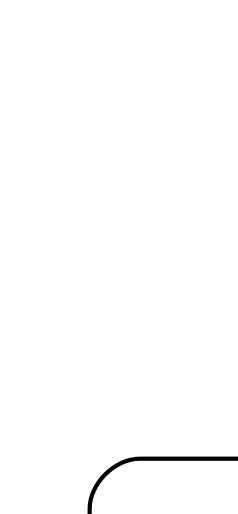

In [120]:
flow = Digraph()

flow.attr(
    rankdir="TB",
    nodesep="0.5",
    ranksep="0.7"
)

flow.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Helvetica Neue",
    fontsize="11",
    margin="0.15"
)

flow.attr(
    "edge",
    fontname="Helvetica Neue",
    fontsize="9",
    arrowsize="0.7"
)

flow.node("A", f"All GLASS patients\nn = {len(n_all)}")
flow.node("B", f"Patients with\nTumor Primary + First Recurrence\nn = {len(n_tp_r1)}")
flow.node("C", f"Patients with\nPrimary + First Recurrence\nwith expression data\nn = {len(n_tp_r1_expr)}")
flow.node("D", f"Patients with glioblastoma\nn = {len(n_gbm)}")
flow.node("E", f"Patients with IDH-wildtype glioblastoma\nn = {len(n_idhwt_gbm)}")

# Arrows + number excluded at each step
flow.edge("A", "B",
    label=f"−{len(n_all - n_tp_r1)} excluded")

flow.edge("B", "C",
    label=f"−{len(n_tp_r1 - n_tp_r1_expr)} excluded")

flow.edge("C", "D",
    label=f"−{len(n_tp_r1_expr - n_gbm)} excluded")

flow.edge( "D", "E",
    label=f"−{len(n_gbm - n_idhwt_gbm)} excluded")

flow.attr(dpi="300")

flow.render(
    "../figures/glass_patient_selection",
    format="png",
    cleanup=True
)

flow

- Plot `glass_patient_selection.png` exported to figures directory.

In [121]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica Neue', 'Helvetica', 'Arial', 'sans-serif']

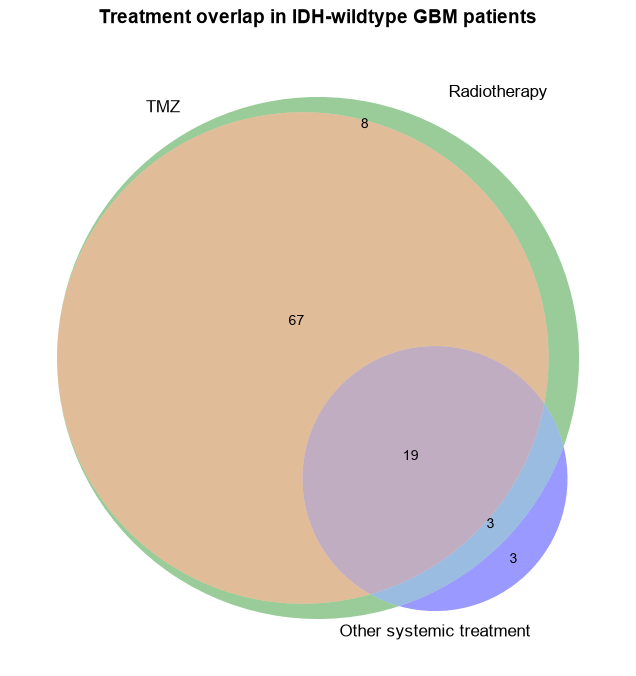

In [122]:
# noinspection PyTypeChecker
plt.figure(figsize=(8, 8))

venn3(
    (tmz, radiotherapy, other_systemic),
    set_labels=(
        "TMZ",
        "Radiotherapy",
        "Other systemic treatment"
    )
)

plt.title(
    "Treatment overlap in IDH-wildtype GBM patients",
    fontsize=14,
    fontweight="bold",
    y=1.03
)
plt.savefig(
    "../figures/treatment_overlap_venn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Plot `treatment_overlap_venn.png` exported to figures directory.

# **Gene expression processing and paired analysis**

## 1. Finalise the study cohort
- For further analysis `glass_idhwt_gbm_R1_pairs` will be used
- All patients have two samples
    - `PRIMARY_SAMPLE_ID`
    - `FIRST_RECURRENCE_SAMPLE_ID`

In [123]:
print("Number of patients in final cohort:", glass_idhwt_gbm_primary_R1_pairs["PATIENT_ID"].nunique())
print("Number of samples in final cohort:", (glass_idhwt_gbm_primary_R1_pairs["PRIMARY_SAMPLE_ID"].nunique() + glass_idhwt_gbm_primary_R1_pairs["FIRST_RECURRENCE_SAMPLE_ID"].nunique()))

Number of patients in final cohort: 103
Number of samples in final cohort: 206


- 206 gene expression samples will be needed

## 2. Prepare the gene expression matrix - `glass_idhwt_gbm_primary_R1_TPM.tsv`
- Only keep gene expression data for samples that are part of cohort

In [124]:
sample_ids = pd.concat([
    glass_idhwt_gbm_primary_R1_pairs["PRIMARY_SAMPLE_ID"],
    glass_idhwt_gbm_primary_R1_pairs["FIRST_RECURRENCE_SAMPLE_ID"],
])

glass_idhwt_gbm_primary_R1_TPM = data_mrna_seq_tpm.loc[
    :, data_mrna_seq_tpm.columns.isin(sample_ids)
].copy()

In [125]:
glass_idhwt_gbm_primary_R1_TPM.iloc[:5, :5]

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-LU-00C2-TP
Hugo_Symbol,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,39.917940
STX16,15.492818,134.774214,24.971397,31.478907,70.300232
TLE4,4.712733,43.182487,21.529454,16.362683,63.985062
LRRN1,19.218400,12.685700,23.226094,48.631390,40.922450
YKT6,85.501630,95.440750,29.212650,102.939150,56.126976


In [126]:
glass_idhwt_gbm_primary_R1_TPM.to_csv(
    "../data/processed/glass_idhwt_gbm_primary_R1_TPM.tsv",
    sep="\t",
    index=True)

- `glass_idhwt_gbm_primary_R1_TPM.tsv` exported to /data/processed directory.

## 3. Perform initial quality control of gene expression data - `glass_expression_QC.xlsx`
- Check:
    - Number of genes in expression matrix
    - Duplicate gene IDs
    - Missing TPM values
    - Negative TPM values
    - Number of genes with 0 expression
    - Do all samples have valid expression  data?
- Sample summary table: `glass_expression_QC.xlsx`
    - Mean TPM
    - Median TPM
    - Number of genes with 0 expression
    - Maximum TPM

In [127]:
glass_idhwt_gbm_primary_R1_TPM.iloc[:5, :5]

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-LU-00C2-TP
Hugo_Symbol,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,39.917940
STX16,15.492818,134.774214,24.971397,31.478907,70.300232
TLE4,4.712733,43.182487,21.529454,16.362683,63.985062
LRRN1,19.218400,12.685700,23.226094,48.631390,40.922450
YKT6,85.501630,95.440750,29.212650,102.939150,56.126976


In [128]:
n_genes = glass_idhwt_gbm_primary_R1_TPM.index.nunique()
n_genes_duplicate_ID = int(glass_idhwt_gbm_primary_R1_TPM.index.duplicated().sum())
duplicate_genes = glass_idhwt_gbm_primary_R1_TPM.loc[glass_idhwt_gbm_primary_R1_TPM.index.duplicated(keep = False)].copy()
n_tpm_missing = glass_idhwt_gbm_primary_R1_TPM.isna().sum().sum()
n_tpm_neg = (glass_idhwt_gbm_primary_R1_TPM < 0).sum().sum()

zero_gene_ids = glass_idhwt_gbm_primary_R1_TPM.index[
    (glass_idhwt_gbm_primary_R1_TPM == 0).all(axis=1)]
n_genes_zero = len(zero_gene_ids)

In [129]:
print("Total number of gene in expression matrix:", n_genes)
print("Number of duplicate gene symbols:", n_genes_duplicate_ID)
print("Number of missing TPM values:",  n_tpm_missing)
print("Number of negative TPM values:", n_tpm_neg)
print("Number of genes with 0 expression in all samples:", n_genes_zero)

Total number of gene in expression matrix: 35433
Number of duplicate gene symbols: 5
Number of missing TPM values: 0
Number of negative TPM values: 0
Number of genes with 0 expression in all samples: 417


In [130]:
glass_expression_QC = pd.DataFrame({
    "n_missing": glass_idhwt_gbm_primary_R1_TPM.isna().sum(axis=0),
    "n_negative": (glass_idhwt_gbm_primary_R1_TPM < 0).sum(axis=0),
    "n_0": (glass_idhwt_gbm_primary_R1_TPM == 0).sum(axis=0),
    "n_expressed": (glass_idhwt_gbm_primary_R1_TPM > 0).sum(axis=0),
    "mean_TPM": glass_idhwt_gbm_primary_R1_TPM.mean(axis=0),
    "median_TPM": glass_idhwt_gbm_primary_R1_TPM.median(axis=0),
    "max_TPM": glass_idhwt_gbm_primary_R1_TPM.max(axis=0)
})

glass_expression_QC

,n_missing,n_negative,n_0,n_expressed,mean_TPM,median_TPM,max_TPM
GLSS-SM-R109-TP,0,0,14599,20839,28.218296,0.175742,35532.000000
GLSS-19-0274-TP,0,0,12885,22553,28.218297,0.476228,52824.589583
GLSS-CU-R005-TP,0,0,9993,25445,28.218282,0.903331,223550.000000
GLSS-SM-R060-TP,0,0,13723,21715,28.218293,0.195759,26746.900000
GLSS-LU-00C2-TP,0,0,16207,19231,28.218297,0.909260,71333.136295
...,...,...,...,...,...,...,...
GLSS-HF-2934-R1,0,0,9869,25569,28.218298,0.427859,22819.991650
GLSS-SM-R102-R1,0,0,13945,21493,28.218296,0.277696,26113.100000
GLSS-SN-0016-R1,0,0,13154,22284,28.218297,0.354560,69470.700000
GLSS-SM-R104-R1,0,0,13591,21847,28.218293,0.404220,29728.800000


In [131]:
glass_expression_QC.to_excel(
    "../results/qc/glass_expression_QC.xlsx",
    index = True
)

- `glass_expression_QC.xlsx` exported to processed data directory.

## 4. Log-transform TPM data
- log2(TPM+1)

In [132]:
glass_idhwt_gbm_primary_R1_log2TPM = np.log2(glass_idhwt_gbm_primary_R1_TPM+1)

glass_idhwt_gbm_primary_R1_log2TPM = pd.DataFrame(
    glass_idhwt_gbm_primary_R1_log2TPM,
    index=glass_idhwt_gbm_primary_R1_TPM.index,
    columns=glass_idhwt_gbm_primary_R1_TPM.columns)

In [133]:
glass_idhwt_gbm_primary_R1_log2TPM.to_csv(
    "../data/processed/glass_idhwt_gbm_primary_R1_log2TPM.tvs",
    sep="\t",
    index=True)

- `glass_idhwt_gbm_primary_R1_log2TPM.tvs` exported to /data/processed directory.

## 5. Filter lowly expressed genes + duplicated gene IDs with different expression - `glass_gene_filter_summary.xlsx`,  `glass_idhwt_gbm_primary_R1_log2TPM_filtered.tvs`
- Only keep genes which have TPM ≥ 1 in at least 20% of samples

In [134]:
duplicate_genes

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-LU-00C2-TP,GLSS-LU-00B9-R1,TCGA-06-0210-TP,GLSS-SN-0001-R1,GLSS-MD-0022-TP,GLSS-19-0267-R1,...,GLSS-SM-R072-R1,GLSS-HF-3050-R1,GLSS-SN-0004-R1,GLSS-SM-R061-R1,GLSS-SM-R065-R1,GLSS-HF-2934-R1,GLSS-SM-R102-R1,GLSS-SN-0016-R1,GLSS-SM-R104-R1,GLSS-SM-R063-R1
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
MACF1,35.875793,345.421713,253.119833,82.250811,424.671342,523.716387,115.420647,113.660453,166.269005,364.119465,...,143.311885,181.001482,136.971422,106.376544,65.283010,81.502869,81.563805,146.910507,107.443032,113.789723
MYO18A,13.744899,201.052519,19.685016,44.196672,45.662992,86.553072,16.493010,34.196668,59.866167,161.712698,...,14.795592,41.982230,18.627676,23.272107,48.163651,17.333318,21.120542,12.625584,47.986422,31.277661
PALM2AKAP2,5.642198,84.328451,17.446511,8.773509,16.233740,20.098218,5.431518,9.517328,57.348854,49.875510,...,33.442011,11.486370,2.535017,13.646968,4.802581,16.911130,43.473879,7.392694,12.802884,13.012178
BTBD8,1.585767,11.767903,3.345687,0.620589,10.353100,7.384311,1.045340,7.531930,2.890840,45.246990,...,1.295480,2.498960,0.785762,0.861516,8.227520,0.765934,0.417101,13.334340,30.074080,2.071111
S1PR3,12.022653,14.633418,10.680630,4.963533,40.906740,25.097830,10.429453,2.628644,21.513649,9.654271,...,43.498256,12.579289,0.789166,5.178715,1.933323,27.435734,16.778229,3.832663,5.079324,5.248114
PALM2AKAP2,0.370068,6.701595,3.228221,0.505997,2.441030,3.956600,0.540228,7.850147,16.307479,21.970167,...,1.346136,1.175476,0.946776,0.153404,3.622467,0.691547,3.948100,2.981079,9.388189,0.209613
BTBD8,0.277189,7.778565,1.630685,0.108356,17.363860,6.794220,0.296627,1.011498,2.625314,15.517091,...,0.569568,0.298837,0.518280,0.156473,0.795930,0.103598,0.104546,1.188153,1.653882,0.257095
MACF1,0.289409,34.377800,23.275700,1.700110,21.219200,39.797100,1.423370,1.013510,7.489880,42.592100,...,3.231310,1.723060,2.318050,0.367752,0.533984,0.334008,1.548580,1.106420,1.657560,1.122860
MYO18A,2.735328,0.348697,2.492486,7.247900,6.595196,8.194554,6.437210,14.634530,0.216933,0.708112,...,2.595371,9.838400,13.089815,18.028210,10.602400,7.838190,7.521550,8.310420,3.146180,8.722710


In [135]:
glass_idhwt_gbm_primary_R1_TPM_filtered = (glass_idhwt_gbm_primary_R1_TPM.loc[~glass_idhwt_gbm_primary_R1_TPM.index.isin(duplicate_genes.index)].copy())

In [136]:
min_samples = math.ceil(0.20 * glass_idhwt_gbm_primary_R1_TPM_filtered.shape[1])

glass_idhwt_gbm_primary_R1_TPM_filtered = glass_idhwt_gbm_primary_R1_TPM_filtered.loc[
    (glass_idhwt_gbm_primary_R1_TPM_filtered >= 1).sum(axis=1) >= min_samples
]

In [137]:
glass_idhwt_gbm_primary_R1_log2TPM_filtered = glass_idhwt_gbm_primary_R1_log2TPM.loc[glass_idhwt_gbm_primary_R1_log2TPM.index.isin(glass_idhwt_gbm_primary_R1_TPM_filtered.index)].copy()

In [138]:
n_genes_before = glass_idhwt_gbm_primary_R1_log2TPM.index.nunique()
n_genes_after = glass_idhwt_gbm_primary_R1_log2TPM_filtered.index.nunique()
n_genes_excluded = n_genes_before - n_genes_after

glass_gene_filter_summary = pd.DataFrame({
    "n_genes_before_filtering": [n_genes_before],
    "n_genes_after_filtering": [n_genes_after],
    "n_genes_excluded": [n_genes_excluded],
})

glass_gene_filter_summary

,n_genes_before_filtering,n_genes_after_filtering,n_genes_excluded
0,35433,17789,17644


In [139]:
glass_gene_filter_summary.to_excel(
    "../results/qc/glass_gene_filter_summary.xlsx",
    index = False)

In [140]:
glass_idhwt_gbm_primary_R1_log2TPM_filtered.to_csv(
    "../data/processed/glass_idhwt_gbm_primary_R1_log2TPM_filtered.tvs",
    sep="\t",
    index=True)

- Final `glass_gene_filter_summary.xlsx` and `glass_idhwt_gbm_primary_R1_log2TPM_filtered.tvs` exported to /data/processed directory.

## 6. Assess global gene expression patterns across samples - `PCA_primary_recurrence.png`

In [141]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))])

glass_idhwt_gbm_primary_R1_pca = pca_pipeline.fit_transform(
    glass_idhwt_gbm_primary_R1_log2TPM_filtered.T)

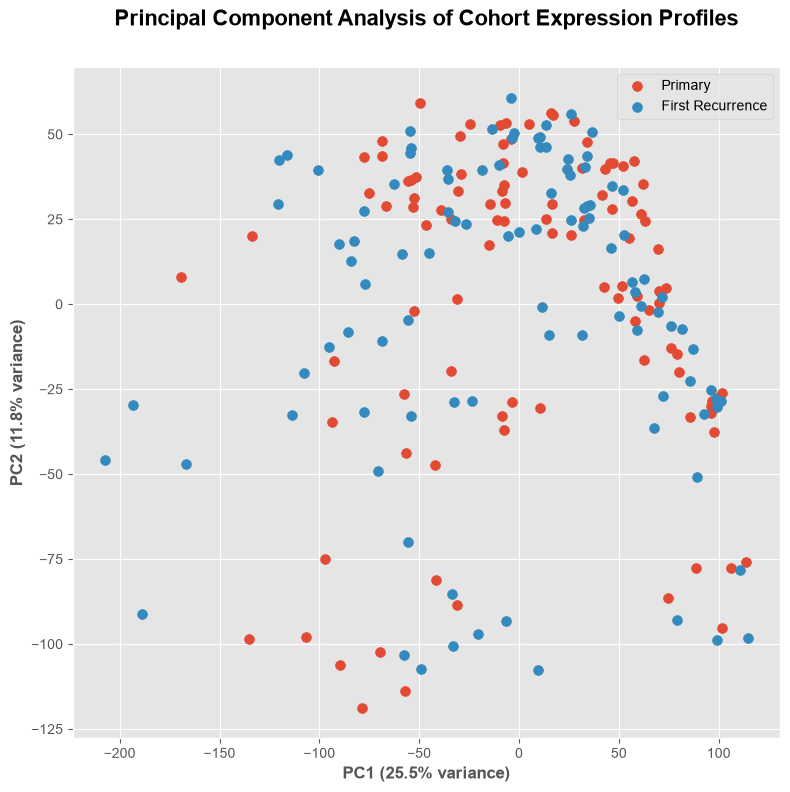

In [142]:
sample_types = [
    "Primary"
    if sample_id in glass_idhwt_gbm_primary_R1_pairs["PRIMARY_SAMPLE_ID"].values
    else "First Recurrence"
    for sample_id in glass_idhwt_gbm_primary_R1_log2TPM_filtered.columns]

plt.figure(figsize=(8, 8))
for sample_type, marker in [
    ("Primary", "o"),
    ("First Recurrence", "o")
]:
    mask = [sample_type == x for x in sample_types]
    plt.scatter(
        glass_idhwt_gbm_primary_R1_pca[mask, 0],
        glass_idhwt_gbm_primary_R1_pca[mask, 1],
        marker=marker,
        s=50,
        label=sample_type)
pca = pca_pipeline.named_steps["pca"]
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)", fontweight="bold")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)", fontweight="bold")
plt.title(
    "Principal Component Analysis of Cohort Expression Profiles",
    fontsize=16,
    fontweight="bold",
    loc='center',
    y=1.05)
plt.legend()
plt.tight_layout()
plt.savefig(
    "../figures/PCA_primary_recurrence.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

- Plot `PCA_primary_recurrence.png` exported to figures directory.

## 7. Perform paired comparison of gene expression between primary and recurrent samples - `glass_primary_vs_R1_gene_statistics.xlsx`
- delta_expression = R1 expression – Primary expression

In [143]:
primary = glass_idhwt_gbm_primary_R1_log2TPM_filtered[glass_idhwt_gbm_primary_R1_pairs["PRIMARY_SAMPLE_ID"]]
r1 = glass_idhwt_gbm_primary_R1_log2TPM_filtered[glass_idhwt_gbm_primary_R1_pairs["FIRST_RECURRENCE_SAMPLE_ID"]]
delta_expression = r1.to_numpy() - primary.to_numpy()

In [144]:
genes = glass_idhwt_gbm_primary_R1_log2TPM_filtered.index

print("Number of genes:", delta_expression.shape[0])
print("Number of patient pairs:", delta_expression.shape[1])

print("Primary samples:", primary.shape[1])
print("R1 samples:", r1.shape[1])

assert primary.shape[1] == r1.shape[1]

print( "Duplicated Primary IDs:", int(primary.columns.duplicated().sum()))

print("Duplicated R1 IDs:",int(r1.columns.duplicated().sum()))

Number of genes: 17789
Number of patient pairs: 103
Primary samples: 103
R1 samples: 103
Duplicated Primary IDs: 0
Duplicated R1 IDs: 0


In [145]:
genes = glass_idhwt_gbm_primary_R1_log2TPM_filtered.index

skewness :list[float] = []

for delta in delta_expression:
    valid_delta = delta[~np.isnan(delta)]

    if len(valid_delta) >= 3:
        skewness.append(skew(valid_delta))
    else:
        skewness.append(np.nan)

normality_check = pd.DataFrame({
    "GENE": genes,
    "SKEWNESS": skewness})

print(f"Genes: {len(genes)}")
print(f"Patient pairs: {delta_expression.shape[1]}")
print()
median_abs_skew = normality_check["SKEWNESS"].abs().median()

print(f"Median |skewness|: {median_abs_skew:.3f}")

abs_skewness = normality_check["SKEWNESS"].abs()
n_skew_gt_1 = int(np.count_nonzero(abs_skewness.to_numpy() > 1))
n_skew_gt_2 = int(np.count_nonzero(abs_skewness.to_numpy() > 2))

print(f"Genes with |skewness| > 1: {n_skew_gt_1}")
print(f"Genes with |skewness| > 2: {n_skew_gt_2}")

Genes: 17789
Patient pairs: 103

Median |skewness|: 0.294
Genes with |skewness| > 1: 1213
Genes with |skewness| > 2: 127


> **Methodological Note:** Following $\log_2$-transformation, paired expression differences exhibited low overall skewness across genes (median absolute skewness = 0.29). Combined with a sample size of $N = 103$ paired observations, this justified the use of parametric paired $t$-tests under the Central Limit Theorem.

In [146]:
genes = glass_idhwt_gbm_primary_R1_log2TPM_filtered.index

n_pairs = np.sum(~np.isnan(delta_expression), axis=1)

mean_primary = np.nanmean(primary.to_numpy(), axis=1)

mean_r1 = np.nanmean(r1.to_numpy(), axis=1)

mean_delta = np.nanmean(delta_expression, axis=1)

median_delta = np.nanmedian(delta_expression, axis=1)

sd_delta = np.nanstd(delta_expression, axis=1, ddof=1)

n_pairs = np.asarray(n_pairs, dtype=int)

t_statistic = mean_delta / (sd_delta / np.sqrt(n_pairs))

t_statistic = np.asarray(t_statistic, dtype=float)

p_value = np.asarray(
    2 * t.sf(
        np.abs(t_statistic),
        df=n_pairs - 1
    ),
    dtype=float
)

invalid = (
        (n_pairs < 2) |
        ~np.isfinite(t_statistic))

t_statistic[invalid] = np.nan
p_value[invalid] = np.nan

glass_primary_vs_R1_gene_statistics = pd.DataFrame({
    "GENE": genes,
    "N_PAIRS": n_pairs,
    "MEAN_PRIMARY": mean_primary,
    "MEAN_R1": mean_r1,
    "MEAN_DELTA": mean_delta,
    "MEDIAN_DELTA": median_delta,
    "SD_DELTA": sd_delta,
    "T_STATISTIC": t_statistic,
    "P_VALUE": p_value
})

glass_primary_vs_R1_gene_statistics["FDR"] = np.nan
valid_p = glass_primary_vs_R1_gene_statistics["P_VALUE"].notna()

In [147]:
glass_primary_vs_R1_gene_statistics.loc[valid_p, "FDR"] = (
    multipletests(
        glass_primary_vs_R1_gene_statistics.loc[valid_p, "P_VALUE"],
        method="fdr_bh"
    )[1])

In [148]:
glass_primary_vs_R1_gene_statistics

,GENE,N_PAIRS,MEAN_PRIMARY,MEAN_R1,MEAN_DELTA,MEDIAN_DELTA,SD_DELTA,T_STATISTIC,P_VALUE,FDR
0,CMSS1,103,5.227101,5.120401,-0.106700,-0.139256,0.779057,-1.390001,0.167555,0.321292
1,STX16,103,5.364055,5.375362,0.011307,-0.030965,0.708218,0.162028,0.871605,0.928024
2,TLE4,103,4.458565,4.746619,0.288054,0.120028,0.923852,3.164391,0.002049,0.017961
3,LRRN1,103,4.574455,3.751107,-0.823348,-0.830165,1.662280,-5.026871,0.000002,0.000189
4,YKT6,103,6.312393,6.135957,-0.176435,-0.167784,0.891261,-2.009092,0.047169,0.138214
...,...,...,...,...,...,...,...,...,...,...
17784,RP1-265C24.5,103,0.531361,0.782207,0.250847,0.169054,0.741857,3.431681,0.000868,0.010120
17785,AC009060.1,103,4.012625,4.003522,-0.009103,-0.090453,0.869126,-0.106299,0.915554,0.953504
17786,TMEM88B,103,1.092288,2.022297,0.930009,0.209741,1.954603,4.828887,0.000005,0.000318
17787,BMP2,103,2.178855,1.925957,-0.252899,-0.201903,1.159858,-2.212892,0.029134,0.100967


In [149]:
glass_primary_vs_R1_gene_statistics.to_excel(
    "../results/differential_expression/glass_primary_vs_R1_gene_statistics.xlsx",
    index=False
)

- `glass_primary_vs_R1_gene_statistics.xlsx` exported to /results/differential_expression directory.

## 8. Assess the consistency of expression changes
- FRACTION_UP = ratio of patients where R1 > Primary
- FRACTION_DOWN = ratio of patients where R1 < Primary

In [150]:
expr = glass_idhwt_gbm_primary_R1_log2TPM_filtered
pairs = glass_idhwt_gbm_primary_R1_pairs
up_counts = pd.Series(0, index=expr.index, dtype=float)
down_counts = pd.Series(0, index=expr.index, dtype=float)
n_valid = pd.Series(0, index=expr.index, dtype=float)

In [151]:
for _, row in pairs.iterrows():
    primary_id = row["PRIMARY_SAMPLE_ID"]
    r1_id = row["FIRST_RECURRENCE_SAMPLE_ID"]
    if primary_id not in expr.columns or r1_id not in expr.columns:
        continue
    primary = expr[primary_id]
    r1 = expr[r1_id]
    valid = primary.notna() & r1.notna()
    up_counts += ((r1 > primary) & valid)
    down_counts += ((r1 < primary) & valid)
    n_valid += valid

In [152]:
fractions_up = up_counts / n_valid
fractions_down = down_counts / n_valid

glass_primary_vs_R1_gene_statistics["FRACTION_UP"] = (glass_primary_vs_R1_gene_statistics["GENE"].map(fractions_up))
glass_primary_vs_R1_gene_statistics["FRACTION_DOWN"] = (glass_primary_vs_R1_gene_statistics["GENE"].map(fractions_down))

In [153]:
glass_primary_vs_R1_gene_statistics.head()

,GENE,N_PAIRS,MEAN_PRIMARY,MEAN_R1,MEAN_DELTA,MEDIAN_DELTA,SD_DELTA,T_STATISTIC,P_VALUE,FDR,FRACTION_UP,FRACTION_DOWN
0,CMSS1,103,5.227101,5.120401,-0.106700,-0.139256,0.779057,-1.390001,0.167555,0.321292,0.436893,0.563107
1,STX16,103,5.364055,5.375362,0.011307,-0.030965,0.708218,0.162028,0.871605,0.928024,0.485437,0.514563
2,TLE4,103,4.458565,4.746619,0.288054,0.120028,0.923852,3.164391,0.002049,0.017961,0.572816,0.427184
3,LRRN1,103,4.574455,3.751107,-0.823348,-0.830165,1.662280,-5.026871,0.000002,0.000189,0.262136,0.737864
4,YKT6,103,6.312393,6.135957,-0.176435,-0.167784,0.891261,-2.009092,0.047169,0.138214,0.359223,0.640777


## 9. Generate an initial list of recurrence-associated genes
- Recurrence-UP genes:
    - FDR < 0.05
    - MEAN_DELTA ≥ 0.5
    - FRACTION_UP ≥ 0.65
- Recurrence-DOWN genes:
    - FDR < 0.05
    - MEAN_DELTA ≤ -0.5
    - FRACTION_DOWN ≥ 0.65

In [154]:
glass_recurrence_UP_initial = glass_primary_vs_R1_gene_statistics[
    (glass_primary_vs_R1_gene_statistics["FDR"] < 0.05) &
    (glass_primary_vs_R1_gene_statistics["MEAN_DELTA"] >= 0.5) &
    (glass_primary_vs_R1_gene_statistics["FRACTION_UP"] >= 0.65)
].copy()

glass_recurrence_DOWN_initial = glass_primary_vs_R1_gene_statistics[
    (glass_primary_vs_R1_gene_statistics["FDR"] < 0.05) &
    (glass_primary_vs_R1_gene_statistics["MEAN_DELTA"] <= -0.5) &
    (glass_primary_vs_R1_gene_statistics["FRACTION_DOWN"] >= 0.65)
].copy()

In [155]:
glass_recurrence_UP_initial.head()

,GENE,N_PAIRS,MEAN_PRIMARY,MEAN_R1,MEAN_DELTA,MEDIAN_DELTA,SD_DELTA,T_STATISTIC,P_VALUE,FDR,FRACTION_UP,FRACTION_DOWN
12,FAM153C,103,1.700160,2.373487,0.673328,0.451208,1.765662,3.870236,0.000192,0.003732,0.650485,0.349515
59,RGS4,103,3.071584,3.844087,0.772503,0.984126,2.133532,3.674682,0.000382,0.005819,0.669903,0.330097
66,MICAL2,103,3.602032,4.212899,0.610867,0.501128,1.473130,4.208468,0.000055,0.001594,0.660194,0.339806
72,CRHBP,103,1.315011,2.092998,0.777987,0.715091,1.520816,5.191757,0.000001,0.000125,0.650485,0.339806
75,C16orf89,103,3.381400,4.001647,0.620247,0.572217,1.376968,4.571510,0.000014,0.000614,0.650485,0.349515


In [156]:
glass_recurrence_DOWN_initial.head()

,GENE,N_PAIRS,MEAN_PRIMARY,MEAN_R1,MEAN_DELTA,MEDIAN_DELTA,SD_DELTA,T_STATISTIC,P_VALUE,FDR,FRACTION_UP,FRACTION_DOWN
3,LRRN1,103,4.574455,3.751107,-0.823348,-0.830165,1.662280,-5.026871,2.137105e-06,1.894612e-04,0.262136,0.737864
243,TTK,103,2.826585,2.183419,-0.643165,-0.642103,1.434949,-4.548884,1.490681e-05,6.467738e-04,0.339806,0.660194
346,MEST,103,6.760819,6.202194,-0.558625,-0.496377,1.591468,-3.562388,5.603924e-04,7.638943e-03,0.349515,0.650485
405,SGOL1,103,2.618184,1.944617,-0.673567,-0.722484,1.463245,-4.671777,9.142486e-06,4.797513e-04,0.349515,0.650485
495,HIGD1B,103,4.127535,3.122056,-1.005479,-0.994245,1.157281,-8.817644,3.339109e-14,5.842423e-10,0.223301,0.776699


In [157]:
glass_recurrence_UP_initial.to_excel(
    "../results/recurrence/glass_recurrence_UP_initial.xlsx",
    index=False)

glass_recurrence_DOWN_initial.to_excel(
    "../results/recurrence/glass_recurrence_DOWN_initial.xlsx",
    index=False)

- `glass_recurrence_UP_initial.xlsx` and `glass_recurrence_DOWN_initial.xlsx` exported to /data/processed directory.

## 10. Generate initial result plots - `glass_recurrence_vulcano.png`, `glass_recurrence_heatmap.png` `glass_recurrence_paired_plots.png`
- Vulcano plot
- Heatmap
- Some top genes' paired plot

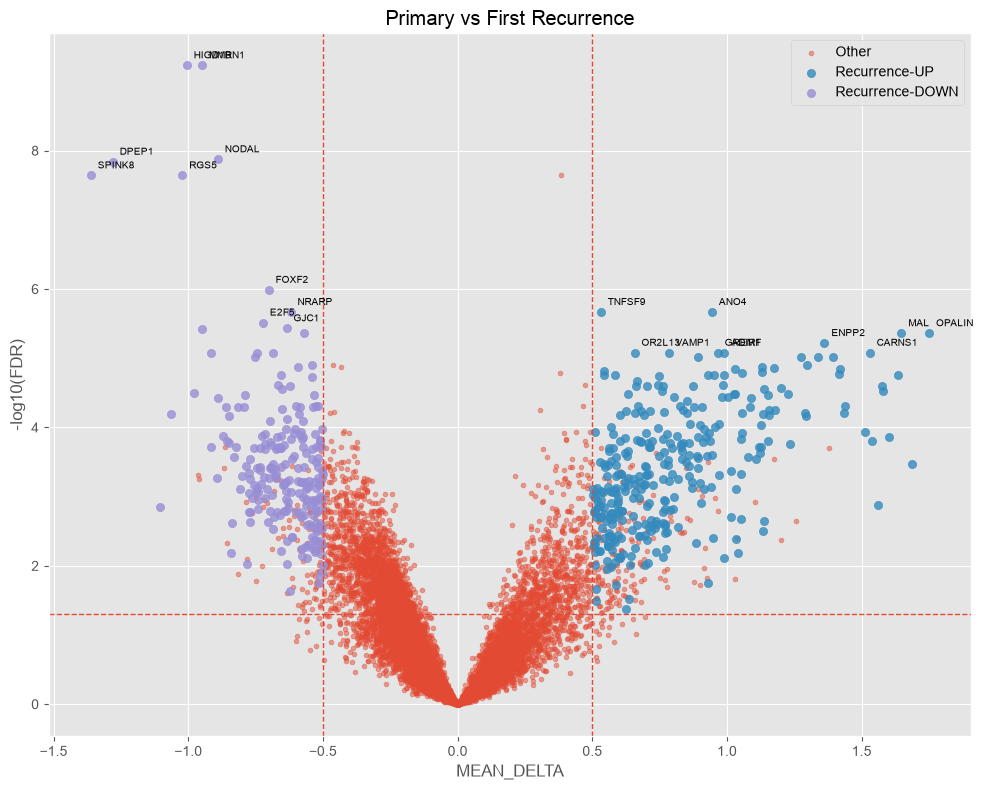

In [158]:
#Vulcano plot
stats = glass_primary_vs_R1_gene_statistics.copy()
stats["GENE"] = glass_idhwt_gbm_primary_R1_log2TPM_filtered.index.values
stats["NEG_LOG10_FDR"] = -np.log10(stats["FDR"].clip(lower=1e-300))

up_genes = set(glass_recurrence_UP_initial["GENE"])
down_genes = set(glass_recurrence_DOWN_initial["GENE"])

stats["CATEGORY"] = "Other"
stats.loc[stats["GENE"].isin(up_genes), "CATEGORY"] = "Recurrence-UP"
stats.loc[stats["GENE"].isin(down_genes), "CATEGORY"] = "Recurrence-DOWN"

fig, ax = plt.subplots(figsize=(10, 8))
other = stats["CATEGORY"] == "Other"
up = stats["CATEGORY"] == "Recurrence-UP"
down = stats["CATEGORY"] == "Recurrence-DOWN"
ax.scatter(
    stats.loc[other, "MEAN_DELTA"],
    stats.loc[other, "NEG_LOG10_FDR"],
    s=12,
    alpha=0.5,
    label="Other")
ax.scatter(
    stats.loc[up, "MEAN_DELTA"],
    stats.loc[up, "NEG_LOG10_FDR"],
    s=35,
    alpha=0.8,
    label="Recurrence-UP")
ax.scatter(
    stats.loc[down, "MEAN_DELTA"],
    stats.loc[down, "NEG_LOG10_FDR"],
    s=35,
    alpha=0.8,
    label="Recurrence-DOWN")
ax.axvline(0.5, linestyle="--", linewidth=1)
ax.axvline(-0.5, linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.05), linestyle="--", linewidth=1)
ax.set_xlabel("MEAN_DELTA")
ax.set_ylabel("-log10(FDR)")
ax.set_title("Primary vs First Recurrence")
ax.legend()
top_up = (
    stats[stats["CATEGORY"] == "Recurrence-UP"]
    .sort_values("FDR")
    .head(10))
top_down = (
    stats[stats["CATEGORY"] == "Recurrence-DOWN"]
    .sort_values("FDR")
    .head(10))
for _, row in pd.concat([top_up, top_down]).iterrows():
    ax.annotate(
        row["GENE"],
        (row["MEAN_DELTA"], row["NEG_LOG10_FDR"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7)
plt.tight_layout()
plt.savefig(
    "../figures/glass_recurrence_volcano.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

- Plot `glass_recurrence_vulcano.png` exported to figures directory.

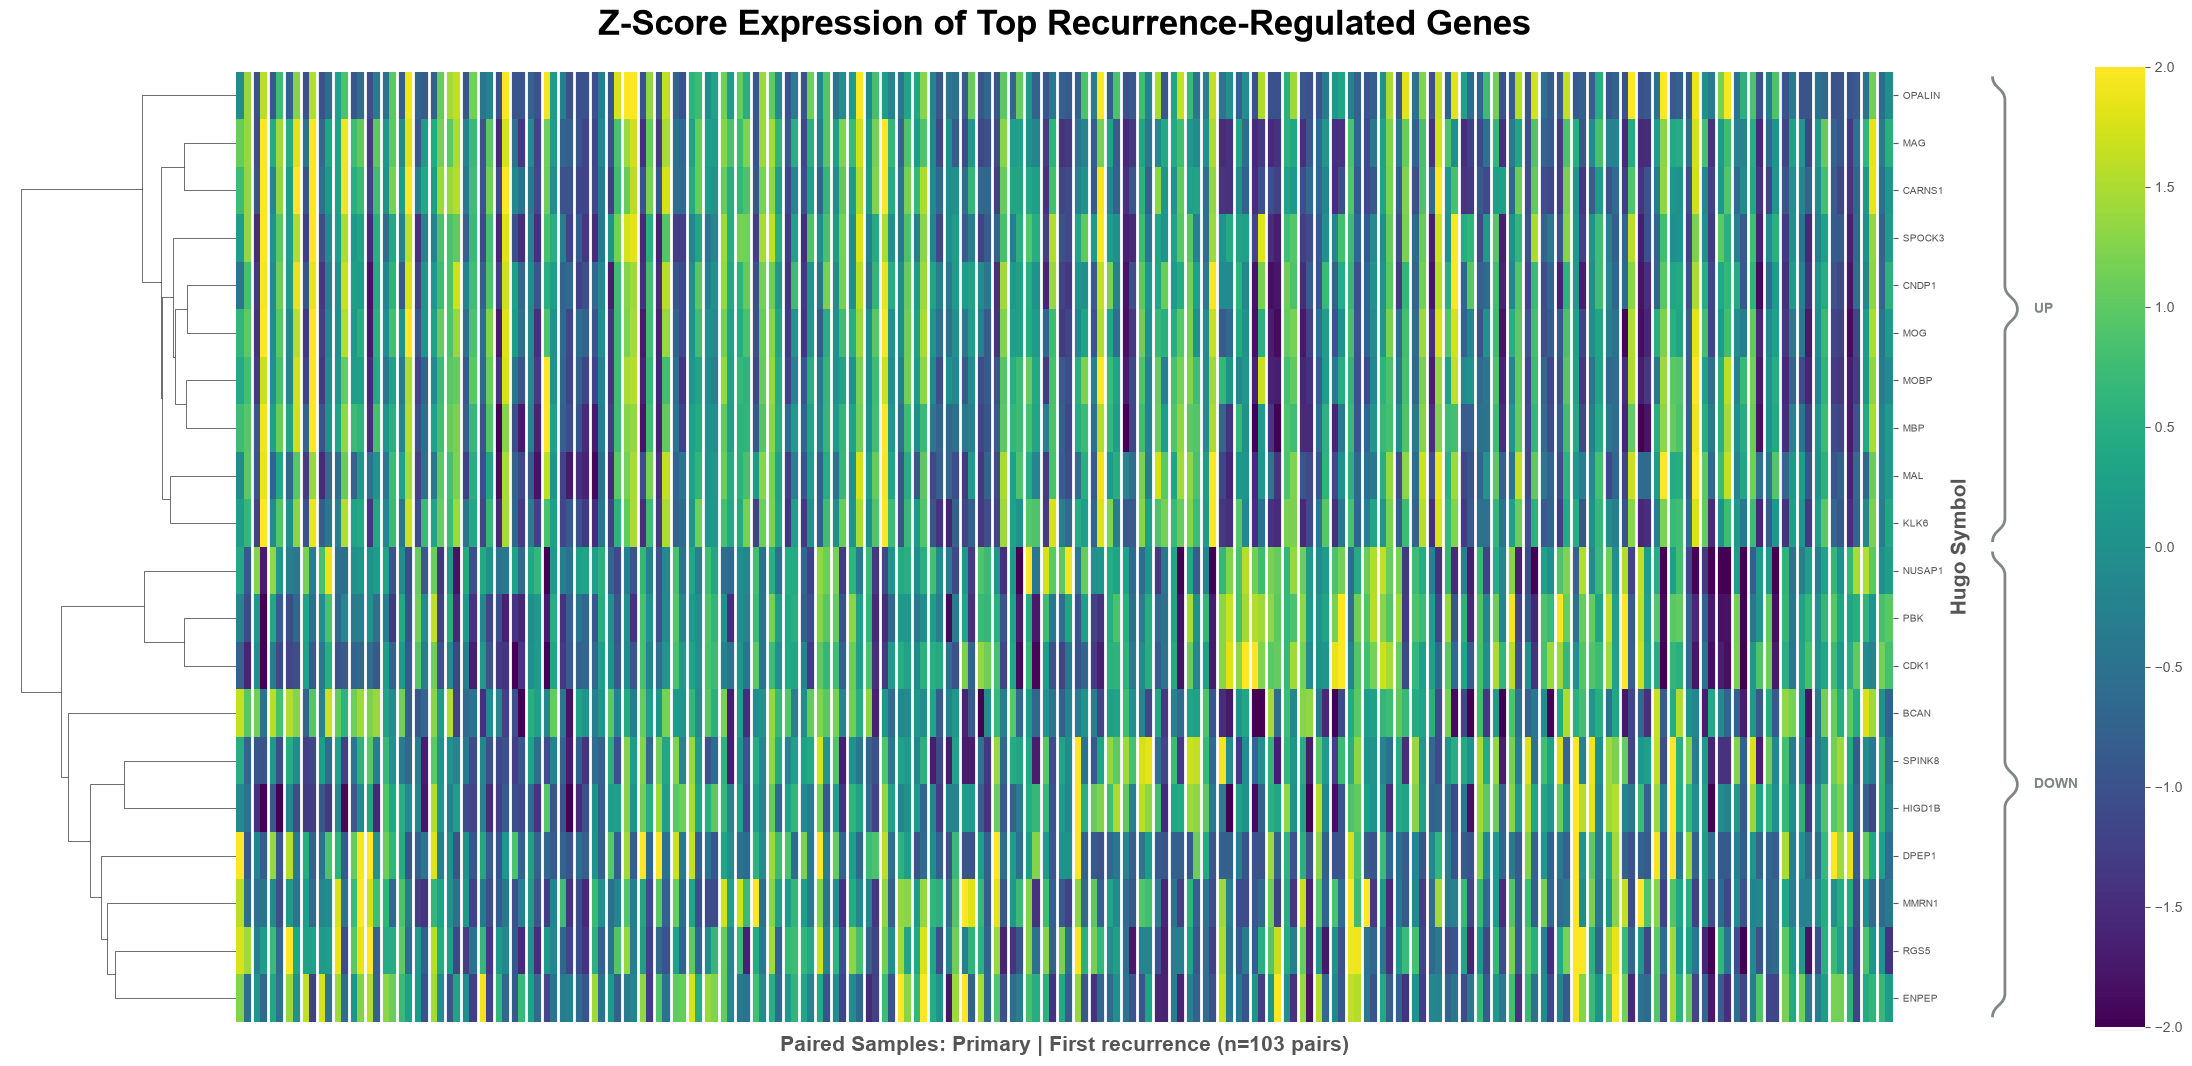

In [159]:
#Heatmap
top_up = (
    glass_recurrence_UP_initial
    .sort_values("MEAN_DELTA", ascending=False)
    .head(10)["GENE"]
    .tolist()
)
top_down = (
    glass_recurrence_DOWN_initial
    .sort_values("MEAN_DELTA", ascending=True)
    .head(10)["GENE"]
    .tolist()
)

heatmap_genes = top_up + top_down

heatmap_expr = glass_idhwt_gbm_primary_R1_log2TPM_filtered

ordered_samples = []

for _, row in glass_idhwt_gbm_primary_R1_pairs.iterrows():

    primary = row["PRIMARY_SAMPLE_ID"]
    recurrence = row["FIRST_RECURRENCE_SAMPLE_ID"]

    if primary in heatmap_expr.columns:
        ordered_samples.append(primary)

    if recurrence in heatmap_expr.columns:
        ordered_samples.append(recurrence)

ordered_samples = [
    sample
    for sample in ordered_samples
    if sample in heatmap_expr.columns
]

heatmap_expr = heatmap_expr.loc[heatmap_genes, ordered_samples]

heatmap_gene_order = [
    gene
    for gene in heatmap_genes
    if gene in heatmap_expr.index
]

heatmap_expr = heatmap_expr.loc[heatmap_gene_order]

def draw_curly_brace_right(
    ax, y_min, y_max, x_pos=1.08, w=0.015, color="black", label=""
):
    """Draws a right-facing curly brace '}' positioned at x_pos on the right side of the heatmap."""
    trans = ax.get_yaxis_transform()

    y1 = y_min + 0.1
    y2 = y_max + 0.9
    ymid = (y1 + y2) / 2.0
    r = min(0.5, (y2 - y1) / 4.0)

    verts = [
        (x_pos, y1),
        (x_pos, y1 + r / 2),
        (x_pos + w / 2, y1 + r / 2),
        (x_pos + w / 2, y1 + r),
        (x_pos + w / 2, ymid - r),
        (x_pos + w / 2, ymid - r / 2),
        (x_pos + w, ymid - r / 2),
        (x_pos + w, ymid),
        (x_pos + w, ymid + r / 2),
        (x_pos + w / 2, ymid + r / 2),
        (x_pos + w / 2, ymid + r),
        (x_pos + w / 2, y2 - r),
        (x_pos + w / 2, y2 - r / 2),
        (x_pos, y2 - r / 2),
        (x_pos, y2),
    ]

    codes = [
        mpath.Path.MOVETO,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.LINETO,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.LINETO,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
        mpath.Path.CURVE4,
    ]

    path = mpath.Path(verts, codes)
    patch = mpatches.PathPatch(
        path,
        facecolor="none",
        edgecolor=color,
        lw=2,
        transform=trans,
        clip_on=False,
    )
    ax.add_patch(patch)

    if label:
        ax.text(
            x_pos + w + 0.01,
            ymid,
            label,
            transform=trans,
            color=color,
            fontweight="bold",
            fontsize=10,
            va="center",
            ha="left",
        )

gene_direction = pd.Series("UP", index=top_up)
gene_direction = pd.concat([
    gene_direction,
    pd.Series(
        "DOWN",
        index=top_down
    )
])
gene_direction = gene_direction.loc[
    heatmap_expr.index
]

p = sns.clustermap(
    heatmap_expr,
    z_score=0,
    row_cluster=True,
    col_cluster=False,
    cmap="viridis",
    center=0,
    vmin=-2,
    vmax=2,
    figsize=(20, 10),
    dendrogram_ratio=(
        0.12,
        0.02,
    ),
    colors_ratio=0.02,
    cbar_pos=(1.05, 0.01, 0.025, 0.96),
    xticklabels=False,
    yticklabels=True,
)

for i in range(2, heatmap_expr.shape[1], 2):
    p.ax_heatmap.axvline(i, color="white", linewidth=2)

if p.dendrogram_row is None:
    raise RuntimeError("Row dendrogram was not created.")
reordered_genes = heatmap_expr.index[p.dendrogram_row.reordered_ind]

up_indices = [i for i, gene in enumerate(reordered_genes) if gene in top_up]
down_indices = [i for i, gene in enumerate(reordered_genes) if gene in top_down]

if up_indices:
    draw_curly_brace_right(
        p.ax_heatmap,
        min(up_indices),
        max(up_indices),
        x_pos=1.06,
        color="#808588",
        label="UP",
    )

if down_indices:
    draw_curly_brace_right(
        p.ax_heatmap,
        min(down_indices),
        max(down_indices),
        x_pos=1.06,
        color="#808588",
        label="DOWN",
    )

p.ax_heatmap.tick_params(axis="y", labelsize=7)
p.ax_heatmap.set_xlabel(
    f"Paired Samples: Primary | First recurrence (n={heatmap_expr.shape[1] // 2} pairs)",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)
p.ax_heatmap.set_ylabel(
    f"Hugo Symbol",
    fontweight="bold",
    fontsize=15
)
p.ax_heatmap.set_title(
    f"Z-Score Expression of Top Recurrence-Regulated Genes",
    fontsize=25,
    fontweight="bold",
    y=1.03
)

plt.savefig(
    "../figures/glass_recurrence_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

- Plot `glass_recurrence_heatmap.png` exported to figures directory.

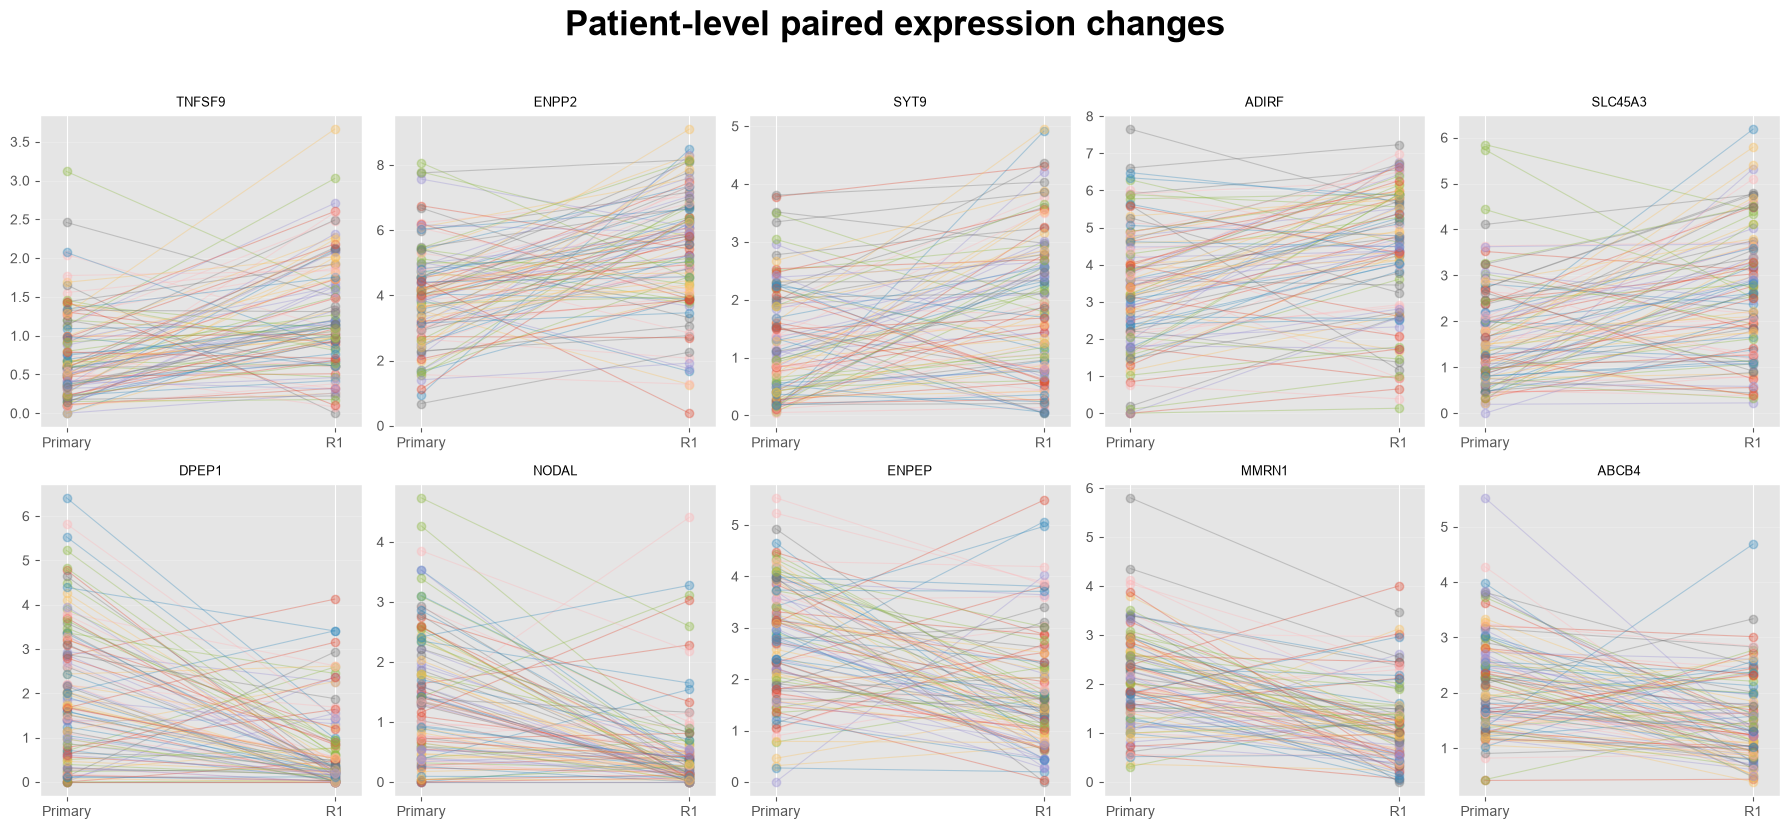

In [160]:
#Paired plot
expr=glass_idhwt_gbm_primary_R1_log2TPM_filtered

top_up_plot = (
    glass_recurrence_UP_initial
    .sort_values(
        ["FRACTION_UP", "MEAN_DELTA"],
        ascending=[False, False])
    .head(5)["GENE"]
    .tolist())

top_down_plot = (
    glass_recurrence_DOWN_initial
    .sort_values(
        ["FRACTION_DOWN", "MEAN_DELTA"],
        ascending=[False, True])
    .head(5)["GENE"]
    .tolist())

plot_genes = top_up_plot + top_down_plot


fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, gene in zip(axes.flat, plot_genes):
    is_up = gene in top_up_plot
    for _, row in pairs.iterrows():
        primary_id = row["PRIMARY_SAMPLE_ID"]
        r1_id = row["FIRST_RECURRENCE_SAMPLE_ID"]
        if primary_id not in expr.columns or r1_id not in expr.columns:
            continue
        primary_value = expr.loc[gene, primary_id]
        r1_value = expr.loc[gene, r1_id]
        if pd.isna(primary_value) or pd.isna(r1_value):
            continue
        ax.plot(
            [0, 1],
            [primary_value, r1_value],
            marker="o",
            alpha=0.35,
            linewidth=0.8
        )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Primary", "R1"])
    ax.set_title(gene, fontsize=9)
    ax.set_xlim(-0.1, 1.1)
    ax.grid(axis="y", alpha=0.2)

plt.suptitle(
    "Patient-level paired expression changes",
    fontsize=25,
    fontweight="bold",
    y=1.03)
plt.tight_layout()
plt.savefig(
    "../figures/glass_recurrence_paired_plots.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

- Plot `glass_recurrence_paired_plots.png` exported to figures directory.

# **Identifying biological processes associated with these changes**
- Input data: `glass_primary_vs_R1_gene_statistics`

## 1. Pathway analysis: Biological processes associated with recurrence

Gene-level paired $t$-statistics were used to rank genes for pre-ranked gene set enrichment analysis (GSEA).
MSigDB Hallmark (2020) and Reactome (2022) gene sets were analysed using the multilevel algorithm implemented in GSEApy (v1.3.1).

Outputs:
- `glass_GSEA_Hallmark.xlsx`
- `glass_GSEA_Reactome.xlsx`

In [161]:
glass_primary_vs_R1_gene_statistics = pd.read_excel(
    "../results/differential_expression/glass_primary_vs_R1_gene_statistics.xlsx", sheet_name=0)

### 1.1 Generate ranked gene list

Genes were ranked according to the t-statistic from the primary tumour vs.
R1 comparison. Genes with missing statistics were removed, duplicate gene
symbols were removed, and the remaining genes were ranked from highest to
lowest t-statistic.

In [162]:
stats = glass_primary_vs_R1_gene_statistics.copy()

ranked_stats = (
    stats[["GENE", "T_STATISTIC"]]
    .dropna()
    .drop_duplicates("GENE")
    .sort_values("T_STATISTIC", ascending=False)
)

rnk = ranked_stats.set_index("GENE")["T_STATISTIC"]

In [163]:
rnk.head()

GENE
P2RY2     7.751049
ANO4      6.704227
TNFSF9    6.679159
MAL       6.442460
OPALIN    6.430496
Name: T_STATISTIC, dtype: float64

In [164]:
rnk.tail()

GENE
RGS5     -7.733102
DPEP1    -7.906913
NODAL    -7.980845
MMRN1    -8.683950
HIGD1B   -8.817644
Name: T_STATISTIC, dtype: float64

In [165]:
print("Number of ranked genes:", len(rnk))

Number of ranked genes: 17789


### 1.2 Preranked GSEA

In [166]:
hallmark = gp.get_library(
    name="MSigDB_Hallmark_2020",
    organism="Human")

print(len(hallmark))
print(list(hallmark.keys())[:5])

50
['TNF-alpha Signaling via NF-kB', 'Hypoxia', 'Cholesterol Homeostasis', 'Mitotic Spindle', 'Wnt-beta Catenin Signaling']


In [167]:
# noinspection bad-argument-type
gsea = gp.prerank(
    rnk=rnk,
    gene_sets=hallmark,
    outdir=None,
    seed=42,
    verbose=True,
    method='multilevel'
)

2026-09-19 23:26:46,424 [WARNING] Duplicated values found in preranked stats: 0.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-19 23:26:46,424 [INFO] Parsing data files for GSEA.............................
2026-09-19 23:26:46,481 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-09-19 23:26:46,487 [INFO] 0050 gene_sets used for further statistical testing.....
2026-09-19 23:26:46,487 [INFO] Start to run GSEA...Might take a while..................
2026-09-19 23:26:49,678 [INFO] Congratulations. GSEApy runs successfully................



In [168]:
hallmark_results = gsea.res2d[["Term", "NES", "NOM p-val", "FDR q-val", "Lead_genes"]].copy()
hallmark_results = (hallmark_results.rename(
    columns={"Term": "PATHWAY",
             "NOM p-val": "NOMINAL_P",
             "FDR q-val": "FDR",
             "Lead_genes": "LEADING_EDGE_GENES"})
                    .sort_values("FDR"))

In [169]:
reactome = gp.get_library(
    name="Reactome_2022",
    organism="Human")

print(len(reactome))
print(list(reactome.keys())[:5])

1816
['2-LTR Circle Formation R-HSA-164843', 'GAG Synthesis Requires Tetrasaccharide Linker Sequence R-HSA-1971475', 'ABC Transporter Disorders R-HSA-5619084', 'ABC Transporters In Lipid Homeostasis R-HSA-1369062', 'ABC-family Proteins Mediated Transport R-HSA-382556']


In [170]:
# noinspection bad-argument-type
gsea = gp.prerank(
    rnk=rnk,
    gene_sets=reactome,
    outdir=None,
    seed=42,
    verbose=True,
    method='multilevel'
)

2026-09-19 23:26:51,745 [WARNING] Duplicated values found in preranked stats: 0.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-19 23:26:51,745 [INFO] Parsing data files for GSEA.............................
2026-09-19 23:26:51,795 [INFO] 0740 gene_sets have been filtered out when max_size=500 and min_size=15
2026-09-19 23:26:51,796 [INFO] 1076 gene_sets used for further statistical testing.....
2026-09-19 23:26:51,796 [INFO] Start to run GSEA...Might take a while..................
2026-09-19 23:27:17,498 [INFO] Congratulations. GSEApy runs successfully................



In [171]:
reactome_results = gsea.res2d[["Term", "NES", "NOM p-val", "FDR q-val", "Lead_genes"]].copy()
reactome_results =  ((reactome_results.rename(
    columns={"Term": "PATHWAY",
             "NOM p-val": "NOMINAL_P",
             "FDR q-val": "FDR",
             "Lead_genes": "LEADING_EDGE_GENES"}))
                     .sort_values("FDR"))

In [172]:
hallmark_results.to_excel(
    "../results/GSEA/glass_GSEA_Hallmark.xlsx",
    index=False
)

In [173]:
reactome_results.to_excel(
    "../results/GSEA/glass_GSEA_Reactome.xlsx",
    index=False
)

The resulting pathway-level statistics include:
- **NES:** normalized enrichment score
- **NOMINAL_P:** nominal enrichment p-value
- **FDR:** false discovery rate

Results exported as Excel files:
- `/results/GSEA/glass_GSEA_Hallmark.xlsx`
- `/results/GSEA/glass_GSEA_Reactome.xlsx`

## 2. Summarising pathway analysis results

In [174]:
def get_top_pathways(dataframe, number=10) -> pd.DataFrame:
    sig = dataframe[dataframe["FDR"] < 0.05].copy()
    positive = (
        sig[sig["NES"] > 0]
        .sort_values("NES", ascending=False)
        .head(number))
    negative = (
        sig[sig["NES"] < 0]
        .sort_values("NES", ascending=True)
        .head(number))
    return pd.concat([negative, positive])


hallmark_top = get_top_pathways(hallmark_results, number=10)
reactome_top = get_top_pathways(reactome_results, number=10)

In [175]:
print("Significant:", (hallmark_results["FDR"] < 0.05).sum())
print("Positive significant:", ((hallmark_results["FDR"] < 0.05) & (hallmark_results["NES"] > 0)).sum())
print("Negative significant:", ((hallmark_results["FDR"] < 0.05) & (hallmark_results["NES"] < 0)).sum())

Significant: 18
Positive significant: 4
Negative significant: 14


> **Methodological Note:** As only four positive Hallmark pathways reached statistical significance, all four were included in the analysis instead of selecting the top ten positive pathways.

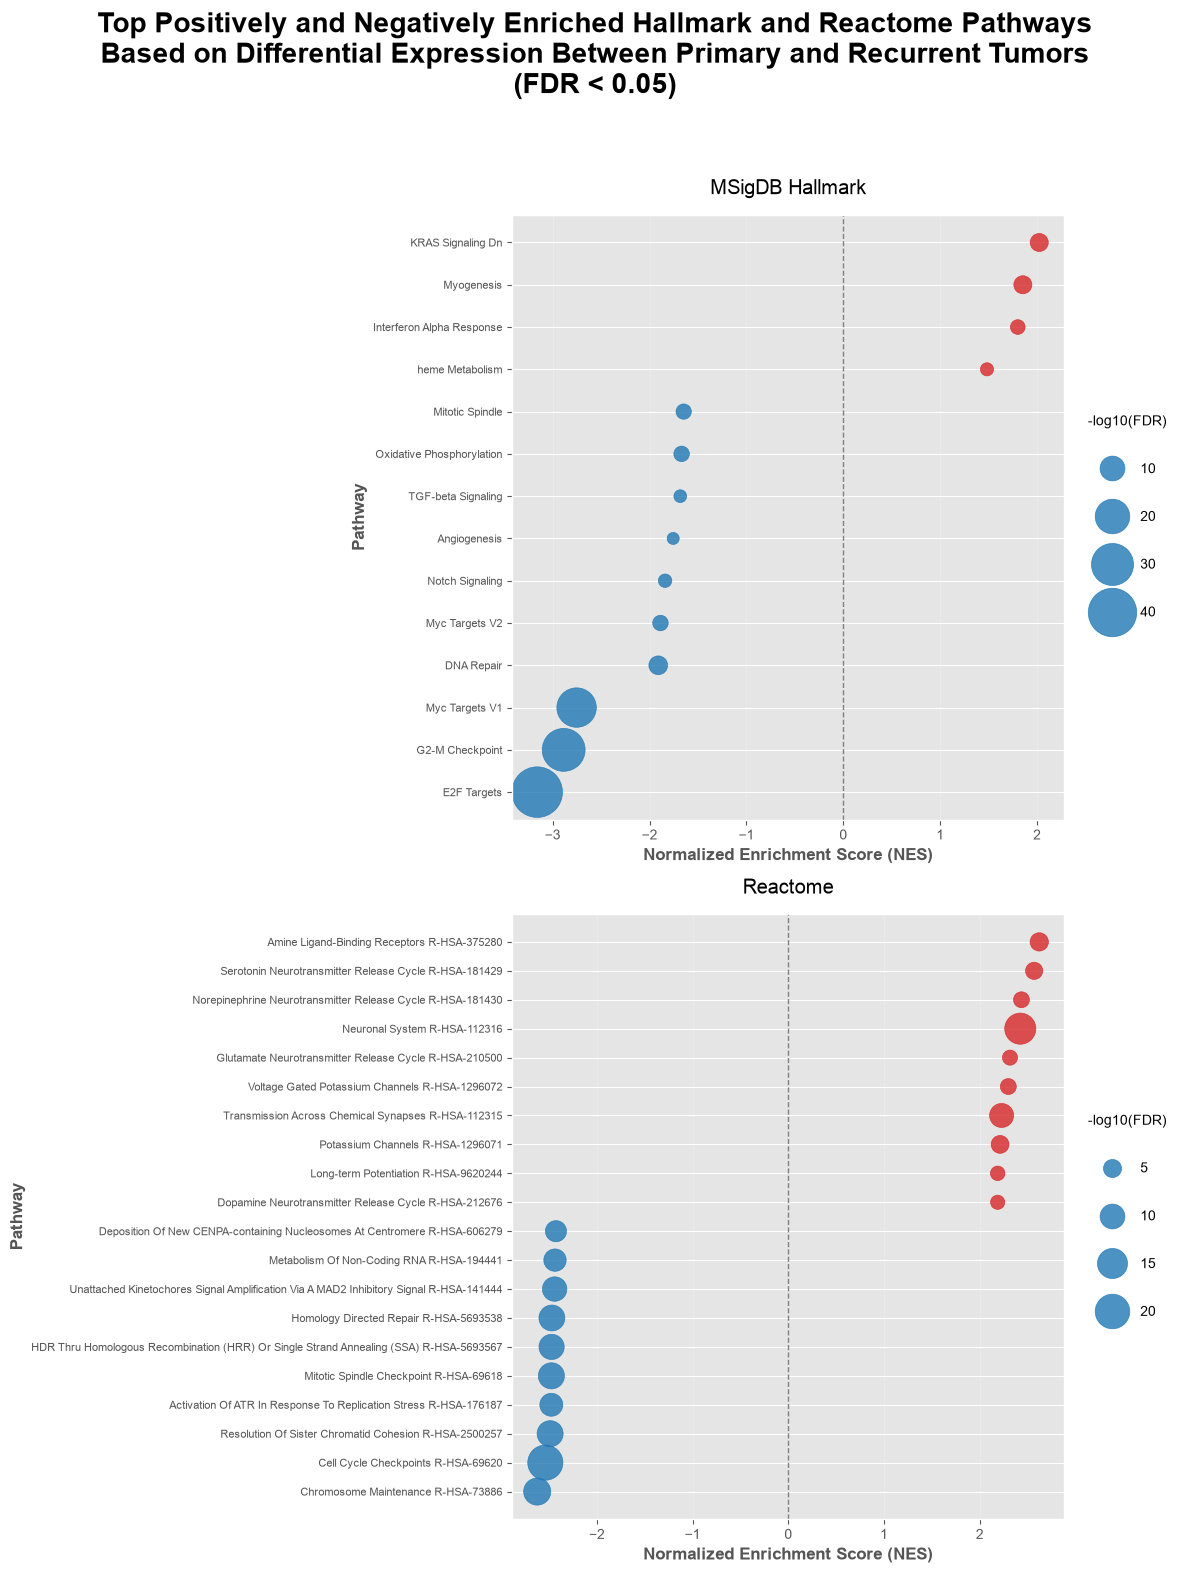

In [176]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 16))

datasets = [
    (hallmark_top, axes[0], "MSigDB Hallmark"),
    (reactome_top, axes[1], "Reactome")]

for df, ax, title in datasets:
    if df.empty:
        ax.text(
            0.5, 0.5,
            "No pathways with FDR < 0.05",
            ha="center",
            va="center",
            transform=ax.transAxes)
        ax.set_title(title)
        continue
    df = df.sort_values("NES")
    df["NEG_LOG10_FDR"] = -np.log10(
        df["FDR"].clip(lower=1e-300))
    y = range(len(df))
    colors = ['#d62728' if nes > 0 else '#1f77b4' for nes in df["NES"]]
    scatter = ax.scatter(
        df["NES"],
        y,
        s=df["NEG_LOG10_FDR"] * 30 + 20,
        c=colors,
        alpha=0.8)
    ax.axvline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1)
    ax.set_yticks(list(y))
    ax.set_yticklabels(
        df["PATHWAY"],
        fontsize=8)
    ax.set_xlabel("Normalized Enrichment Score (NES)", fontweight="bold")
    ax.set_ylabel("Pathway", fontweight="bold")
    ax.set_title(title, pad=15)
    ax.grid(
        axis="x",
        alpha=0.2)
    handles, labels = scatter.legend_elements(
        prop="sizes",
        alpha=0.8,
        num=4,
        func=lambda s: (s - 20) / 30,
        color=scatter.get_facecolors()[0])
    ax.legend(
        handles,
        labels,
        title="-log10(FDR)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        labelspacing=2.5,
        handletextpad=1.0)

plt.suptitle(
    "Top Positively and Negatively Enriched Hallmark and Reactome Pathways\nBased on Differential Expression Between Primary and Recurrent Tumors\n(FDR < 0.05)",
    fontsize=20,
    fontweight="bold",
    y=0.98)

plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig(
    "../figures/glass_GSEA_top_pathways.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [177]:
def format_pvalue(val):
    val = float(val)
    if val < 0.000001:
        return "<0.000001"
    return f"{val:.6f}"

def format_nes(val):
    return f"{float(val):.6f}"

In [178]:
column_formatters = {
    "NES": format_nes,
    "NOMINAL_P": format_pvalue,
    "FDR": format_pvalue
}

In [179]:
print("TOP HALLMARK PATHWAYS")
print(hallmark_top[["PATHWAY", "NES", "NOMINAL_P", "FDR"]].to_string(index=False))

TOP HALLMARK PATHWAYS
                  PATHWAY       NES    NOMINAL_P          FDR
              E2F Targets -3.160205 5.428275e-46 2.714138e-44
          G2-M Checkpoint -2.887096 2.613210e-33 6.533024e-32
           Myc Targets V1 -2.753717 3.314955e-28 5.524925e-27
               DNA Repair -1.910751 3.028536e-07 3.785670e-06
           Myc Targets V2 -1.887909 4.925536e-05 3.116461e-04
          Notch Signaling -1.840243 8.073027e-04 3.363761e-03
             Angiogenesis -1.756645 4.124829e-03 1.374943e-02
       TGF-beta Signaling -1.683286 1.867009e-03 6.667891e-03
Oxidative Phosphorylation -1.669803 4.986338e-05 3.116461e-04
          Mitotic Spindle -1.648381 7.271060e-05 4.039478e-04
        KRAS Signaling Dn  2.021822 1.175931e-06 1.036300e-05
               Myogenesis  1.852663 1.243560e-06 1.036300e-05
Interferon Alpha Response  1.800211 1.703951e-04 8.519757e-04
          heme Metabolism  1.482313 1.234432e-03 4.747814e-03


In [180]:
print("TOP REACTOME PATHWAYS")
print(reactome_top[["PATHWAY", "NES", "NOMINAL_P", "FDR"]].to_string(index=False))

TOP REACTOME PATHWAYS
                                                                               PATHWAY       NES    NOMINAL_P          FDR
                                                    Chromosome Maintenance R-HSA-73886 -2.624170 1.019638e-14 8.439464e-13
                                                    Cell Cycle Checkpoints R-HSA-69620 -2.539201 3.283452e-24 1.766497e-21
                                 Resolution Of Sister Chromatid Cohesion R-HSA-2500257 -2.489224 1.280635e-13 8.612269e-12
                      Activation Of ATR In Response To Replication Stress R-HSA-176187 -2.476915 1.150984e-10 3.440162e-09
                                                Mitotic Spindle Checkpoint R-HSA-69618 -2.475875 1.037725e-13 7.443950e-12
HDR Thru Homologous Recombination (HRR) Or Single Strand Annealing (SSA) R-HSA-5693567 -2.473861 9.783156e-13 4.386115e-11
                                                Homology Directed Repair R-HSA-5693538 -2.470761 1.894350e-13 1.13240

In [181]:
print("TOP HALLMARK PATHWAYS FORMATTED TO DECIMALS")
print(hallmark_top[["PATHWAY", "NES", "NOMINAL_P", "FDR"]].to_string(index=False, formatters=column_formatters))

TOP HALLMARK PATHWAYS FORMATTED TO DECIMALS
                  PATHWAY       NES NOMINAL_P       FDR
              E2F Targets -3.160205 <0.000001 <0.000001
          G2-M Checkpoint -2.887096 <0.000001 <0.000001
           Myc Targets V1 -2.753717 <0.000001 <0.000001
               DNA Repair -1.910751 <0.000001  0.000004
           Myc Targets V2 -1.887909  0.000049  0.000312
          Notch Signaling -1.840243  0.000807  0.003364
             Angiogenesis -1.756645  0.004125  0.013749
       TGF-beta Signaling -1.683286  0.001867  0.006668
Oxidative Phosphorylation -1.669803  0.000050  0.000312
          Mitotic Spindle -1.648381  0.000073  0.000404
        KRAS Signaling Dn  2.021822  0.000001  0.000010
               Myogenesis  1.852663  0.000001  0.000010
Interferon Alpha Response  1.800211  0.000170  0.000852
          heme Metabolism  1.482313  0.001234  0.004748


In [182]:
print("TOP REACTOME PATHWAYS FORMATTED TO 6 DECIMALS")
print(reactome_top[["PATHWAY", "NES", "NOMINAL_P", "FDR"]].to_string(index=False, formatters=column_formatters))

TOP REACTOME PATHWAYS FORMATTED TO 6 DECIMALS
                                                                               PATHWAY       NES NOMINAL_P       FDR
                                                    Chromosome Maintenance R-HSA-73886 -2.624170 <0.000001 <0.000001
                                                    Cell Cycle Checkpoints R-HSA-69620 -2.539201 <0.000001 <0.000001
                                 Resolution Of Sister Chromatid Cohesion R-HSA-2500257 -2.489224 <0.000001 <0.000001
                      Activation Of ATR In Response To Replication Stress R-HSA-176187 -2.476915 <0.000001 <0.000001
                                                Mitotic Spindle Checkpoint R-HSA-69618 -2.475875 <0.000001 <0.000001
HDR Thru Homologous Recombination (HRR) Or Single Strand Annealing (SSA) R-HSA-5693567 -2.473861 <0.000001 <0.000001
                                                Homology Directed Repair R-HSA-5693538 -2.470761 <0.000001 <0.000001
Unattached Kinetoc

### 2.1. Biological relevance of top pathways:
**Overview:** Recurrent samples show a strong shift toward a less proliferative transcriptional state, with marked suppression of cell-cycle, DNA-repair, and genome-maintenance programs. In contrast, neuronal/synaptic and interferon-associated signatures are enriched in recurrent samples.

#### Key downregulated pathways
- **Cell cycle and proliferation:** Strong suppression of E2F Targets (NES: -3.16, FDR: <0.000001), G2-M Checkpoint (NES: -2.89, FDR: <0.000001), Myc Targets V1 (NES: -2.75, FDR: <0.000001), and Mitotic Spindle (NES: -1.65, FDR: 0.000404).
- **DNA repair and genome maintenance:** DNA Repair (NES: -1.91, FDR: 0.000004) is supported by Reactome enrichment of Chromosome Maintenance (NES: -2.62, FDR: <0.000001), Activation Of ATR In Response To Replication Stress (NES: -2.48, FDR: <0.000001), Homology Directed Repair (NES: -2.47, FDR: <0.000001) and other related pathways (all FDR: <0.000001).
- **Other pathways:** Notch Signaling (NES: -1.84, FDR: 0.003364), TGF-beta Signaling (NES: -1.68, FDR: 0.006668), and Oxidative Phosphorylation (NES: -1.67, FDR: 0.000312) are also reduced.

#### Key upregulated pathways
- **Signalling and neuronal programs:** Reactome shows strong enrichment of Amine Ligand-Binding Receptors (NES: 2.62, FDR: 0.000007), Serotonin Neurotransmitter Release (NES: 2.56, FDR: 0.000034), Neuronal System (NES: 2.42, FDR: <0.000001), and Transmission Across Chemical Synapses (NES: 2.22, FDR: <0.000001).
- **Other enriched programs:** KRAS Signaling Dn (NES: 2.02, FDR: 0.000010), Myogenesis (1.91, 0.000011), Interferon Alpha Response (NES: 1.80, FDR: 0.000852), and Heme Metabolism (NES: 1.48, FDR: 0.004748).

#### Biological Implication
- **Reduced proliferation:** The dominant feature of recurrence is suppression of E2F/Myc-driven proliferation, G2/M progression, mitosis, and DNA-repair/genome-maintenance programs.
- **Altered signalling and cellular programs:** Recurrent samples show enrichment of interferon-associated and neuronal/synaptic signatures, together with changes in metabolic and signalling pathways.
- **Interpretation:** The overall profile is consistent with a **low-proliferative recurrent state**. A senescence-like phenotype is a possible interpretation, but would require independent validation and should not be concluded from GSEA alone.


## 3. Assessing the stability of recurrence-associated genes using bootstrap analysis

In [183]:
up_initial = glass_recurrence_UP_initial["GENE"]
down_initial = glass_recurrence_DOWN_initial["GENE"]
bootstrap_genes = pd.Index(up_initial.tolist() + down_initial.tolist()).drop_duplicates()
original_direction = pd.Series("UP", index=up_initial)
original_direction = pd.concat([original_direction, pd.Series("DOWN", index=down_initial)])

print("Initial UP genes:", len(up_initial))
print("Initial DOWN genes:", len(down_initial))

Initial UP genes: 315
Initial DOWN genes: 220


In [184]:
len(genes) == delta_expression.shape[0]

True

In [185]:
bootstrap_up_counts = pd.Series(
    0,
    index=bootstrap_genes,
    dtype=int)
bootstrap_down_counts = pd.Series(
    0,
    index=bootstrap_genes,
    dtype=int)
bootstrap_same_direction_counts = pd.Series(
    0,
    index=bootstrap_genes,
    dtype=int)

rng = np.random.default_rng(42)

n_patients = delta_expression.shape[1]
n_genes = delta_expression.shape[0]

print(f"Genes: {n_genes}")
print(f"Patient pairs: {n_patients}")
print(f"Original recurrence genes: {len(bootstrap_genes)}")
genes = glass_idhwt_gbm_primary_R1_log2TPM_filtered.index

original_up = bootstrap_genes[original_direction.loc[bootstrap_genes].eq("UP")]
original_down = bootstrap_genes[original_direction.loc[bootstrap_genes].eq("DOWN")]

for b in range(1000):
    sampled_idx = rng.integers(
        0,
        n_patients,
        size=n_patients)

    boot_delta = delta_expression[:, sampled_idx]

    n = np.sum(~np.isnan(boot_delta), axis=1)

    mean_delta = np.nanmean(
        boot_delta,
        axis=1)

    sd_delta = np.nanstd(
        boot_delta,
        axis=1,
        ddof=1)

    t_statistic = (mean_delta/(sd_delta/np.sqrt(n)))

    p_values = np.full(n_genes,np.nan)

    valid_tests = ((n >= 2) & np.isfinite(t_statistic))

    p_values[valid_tests] = (2 * t.sf(np.abs(t_statistic[valid_tests]), df=n[valid_tests] - 1))

    fdr = np.full(n_genes,np.nan)

    valid_p = np.isfinite(p_values)

    fdr[valid_p] = multipletests(
        p_values[valid_p],
        method="fdr_bh"
    )[1]

    fraction_up = np.divide(
    np.sum((boot_delta > 0) & ~np.isnan(boot_delta), axis=1),
    n,
    out=np.full(n.shape, np.nan, dtype=float),
    where=n > 0
    )

    fraction_down = np.divide(
    np.sum((boot_delta < 0) & ~np.isnan(boot_delta), axis=1),
    n,
    out=np.full(n.shape, np.nan, dtype=float),
    where=n > 0
    )

    boot_up = ((fdr < 0.05) &
          (mean_delta >= 0.5) &
          (fraction_up >= 0.65))
    boot_down = ((fdr < 0.05) &
            (mean_delta <= -0.5) &
            (fraction_down >= 0.65))

    up_genes = genes[boot_up]
    down_genes = genes[boot_down]

    selected_up = bootstrap_genes.intersection(pd.Index(up_genes))
    selected_down = bootstrap_genes.intersection(pd.Index(down_genes))

    same_up = original_up.intersection(pd.Index(up_genes))
    same_down = original_down.intersection(pd.Index(down_genes))

    bootstrap_up_counts.loc[selected_up] += 1
    bootstrap_down_counts.loc[selected_down] += 1

    bootstrap_same_direction_counts.loc[same_up] += 1
    bootstrap_same_direction_counts.loc[same_down] += 1

    if (b + 1) % 100 == 0:
        print(f"Bootstrap {b + 1}/1000 completed")

Genes: 17789
Patient pairs: 103
Original recurrence genes: 535
Bootstrap 100/1000 completed
Bootstrap 200/1000 completed
Bootstrap 300/1000 completed
Bootstrap 400/1000 completed
Bootstrap 500/1000 completed
Bootstrap 600/1000 completed
Bootstrap 700/1000 completed
Bootstrap 800/1000 completed
Bootstrap 900/1000 completed
Bootstrap 1000/1000 completed


## 4. Determining bootstrap selection frequency
- BOOTSTRAP_UP_FREQUENCY = n_up_count/1000
- BOOTSTRAP_DOWN_FREQUENCY = n_down_count/1000
- BOOTSTRAP_SAME_DIRECTION_FREQUENCY = n_same_direction/1000

In [186]:
bootstrap_stability = pd.DataFrame({
    "GENE": bootstrap_genes,
    "BOOTSTRAP_UP_FREQUENCY": bootstrap_up_counts.loc[bootstrap_genes].values / 1000,
    "BOOTSTRAP_DOWN_FREQUENCY": bootstrap_down_counts.loc[bootstrap_genes].values / 1000,
    "BOOTSTRAP_SAME_DIRECTION_FREQUENCY": bootstrap_same_direction_counts.loc[bootstrap_genes].values / 1000
})

In [187]:
original_stats = pd.concat([
    glass_recurrence_UP_initial[
        ["GENE",
         "MEAN_DELTA",
         "FDR",
         "FRACTION_UP",
         "FRACTION_DOWN"]],
    glass_recurrence_DOWN_initial[
        ["GENE",
         "MEAN_DELTA",
         "FDR",
         "FRACTION_UP",
         "FRACTION_DOWN"]]], ignore_index=True)

original_stats = original_stats.rename(columns={
    "MEAN_DELTA": "ORIGINAL_MEAN_DELTA",
    "FDR": "ORIGINAL_FDR",
    "FRACTION_UP": "ORIGINAL_FRACTION_UP",
    "FRACTION_DOWN": "ORIGINAL_FRACTION_DOWN"})

In [188]:
glass_recurrence_bootstrap_stability = (
    original_stats
    .merge(
        bootstrap_stability,
        on="GENE",
        how="left" ))

glass_recurrence_bootstrap_stability["ORIGINAL_DIRECTION"] = (glass_recurrence_bootstrap_stability["GENE"].map(original_direction))

In [189]:
glass_recurrence_bootstrap_stability.head(20)

,GENE,ORIGINAL_MEAN_DELTA,ORIGINAL_FDR,ORIGINAL_FRACTION_UP,ORIGINAL_FRACTION_DOWN,BOOTSTRAP_UP_FREQUENCY,BOOTSTRAP_DOWN_FREQUENCY,BOOTSTRAP_SAME_DIRECTION_FREQUENCY,ORIGINAL_DIRECTION
0,FAM153C,0.673328,0.003732,0.650485,0.349515,0.538,0.0,0.538,UP
1,RGS4,0.772503,0.005819,0.669903,0.330097,0.688,0.0,0.688,UP
2,MICAL2,0.610867,0.001594,0.660194,0.339806,0.608,0.0,0.608,UP
3,CRHBP,0.777987,0.000125,0.650485,0.339806,0.526,0.0,0.526,UP
4,C16orf89,0.620247,0.000614,0.650485,0.349515,0.519,0.0,0.519,UP
5,AKR1C1,0.705713,0.000170,0.679612,0.320388,0.762,0.0,0.762,UP
6,ADAP1,1.128064,0.000014,0.728155,0.271845,0.971,0.0,0.971,UP
7,KLK6,1.580467,0.000030,0.728155,0.271845,0.968,0.0,0.968,UP
8,MBP,1.559155,0.001340,0.689320,0.310680,0.813,0.0,0.813,UP
9,TUBB4A,1.034620,0.004110,0.679612,0.320388,0.758,0.0,0.758,UP


In [190]:
glass_recurrence_bootstrap_stability = (
    glass_recurrence_bootstrap_stability
    .sort_values(
        "BOOTSTRAP_SAME_DIRECTION_FREQUENCY",
        ascending=False))

glass_recurrence_bootstrap_stability.to_excel(
    "../results/recurrence/glass_recurrence_bootstrap_stability.xlsx",
    index=False)

- `glass_recurrence_bootstrap_stability.xlsx` exported to `/results/recurrence/`

## 5. Defining the recurrence signature
### Gene-level differential expression and recurrence classification

For each gene $g$ and patient $i$, the paired expression difference between the first recurrence (R1) and primary tumour was calculated as:

$$
\Delta_{ig} = X_{ig}^{R1} - X_{ig}^{Primary}
$$

where $X_{ig}^{R1}$ and $X_{ig}^{Primary}$ denote the expression of gene $g$ in the R1 and primary tumour samples, respectively.

For each gene, $N_g$ denotes the number of patients with non-missing paired measurements.

#### Fraction of patients with increased expression at recurrence

$$
\mathrm{FRACTION\_UP}_g =
\frac{
\sum_{i=1}^{N_g} \mathbf{1}(\Delta_{ig} > 0)
}{
N_g
}
$$

#### Fraction of patients with decreased expression at recurrence

$$
\mathrm{FRACTION\_DOWN}_g =
\frac{
\sum_{i=1}^{N_g} \mathbf{1}(\Delta_{ig} < 0)
}{
N_g
}
$$

where $\mathbf{1}(\cdot)$ is the indicator function, equal to 1 when the specified condition is true and 0 otherwise.

The mean paired expression difference was calculated as:

$$
\overline{\Delta}_g =
\frac{1}{N_g}
\sum_{i=1}^{N_g} \Delta_{ig}
$$

### Recurrence-UP genes

A gene was classified as **Recurrence-UP** if all the following criteria were satisfied:

- **FDR < 0.05**
- **Mean difference $\overline{\Delta}_g \geq 0.5$**
- **FRACTION_UP $\geq 0.65$**

### Recurrence-DOWN genes

A gene was classified as **Recurrence-DOWN** if all the following criteria were satisfied:

- **FDR < 0.05**
- **Mean difference $\overline{\Delta}_g \leq -0.5$**
- **FRACTION_DOWN $\geq 0.65$**

### Bootstrap stability

Bootstrap stability was assessed using 1,000 patient-level bootstrap samples. In each bootstrap iteration, 103 patients were sampled with replacement, with the primary and R1 samples of each patient retained as a paired observation. For each bootstrap sample, gene-level paired differences, statistical test statistics, and FDR values were recalculated, and the same criteria used for the original Recurrence-UP and Recurrence-DOWN gene lists were applied.

For each gene, the **bootstrap same-direction frequency** was calculated as:

$$
\mathrm{BOOTSTRAP\_SAME\_DIRECTION\_FREQUENCY}_g =
\frac{B_g}{B}
$$

where $B = 1000$ is the total number of bootstrap iterations and $B_g$ is the number of bootstrap iterations in which the gene was identified in the same direction as in the original analysis.

A gene was considered **bootstrap-stable** if:

$$
\mathrm{BOOTSTRAP\_SAME\_DIRECTION\_FREQUENCY}_g \geq 0.70
$$

In [191]:
STABILITY_THRESHOLD = 0.70

consensus = glass_recurrence_bootstrap_stability[
    glass_recurrence_bootstrap_stability[
        "BOOTSTRAP_SAME_DIRECTION_FREQUENCY"
    ] >= STABILITY_THRESHOLD
    ].copy()

consensus_up = consensus[
    consensus["ORIGINAL_DIRECTION"] == "UP"
    ].copy()

consensus_down = consensus[
    consensus["ORIGINAL_DIRECTION"] == "DOWN"
    ].copy()
n_original_up = len(glass_recurrence_UP_initial)
n_original_down = len(glass_recurrence_DOWN_initial)

n_consensus_up = len(consensus_up)
n_consensus_down = len(consensus_down)

n_consensus = len(consensus)
n_original = len(bootstrap_genes)

print("\nConsensus signature retention:")
print(f"UP:   {n_consensus_up}/{n_original_up} "f"({100 * n_consensus_up / n_original_up:.1f}%)")
print(f"DOWN: {n_consensus_down}/{n_original_down} "f"({100 * n_consensus_down / n_original_down:.1f}%)")
print(f"Overall: {n_consensus}/{n_original} "f"({100 * n_consensus / n_original:.1f}%)")


Consensus signature retention:
UP:   168/315 (53.3%)
DOWN: 97/220 (44.1%)
Overall: 265/535 (49.5%)


> **Summary Note:** Patient-level bootstrap analysis demonstrated that 168 of 315 (53.3%) Recurrence-UP genes and 97 of 220 (44.1%) Recurrence-DOWN genes were consistently selected in the same direction in at least 70% of bootstrap samples. Overall, 265 of 535 (49.5%) initially identified recurrence-associated genes met the predefined stability criterion.

In [192]:
stability = glass_recurrence_bootstrap_stability.copy()

stability["OPPOSITE_DIRECTION_FREQUENCY"] = np.where(
    stability["ORIGINAL_DIRECTION"] == "UP",
    stability["BOOTSTRAP_DOWN_FREQUENCY"],
    stability["BOOTSTRAP_UP_FREQUENCY"]
)

consensus_inspection = stability.loc[
    stability["BOOTSTRAP_SAME_DIRECTION_FREQUENCY"] >= 0.70
].copy()

consensus_inspection[
    [
        "GENE",
        "ORIGINAL_DIRECTION",
        "BOOTSTRAP_SAME_DIRECTION_FREQUENCY",
        "OPPOSITE_DIRECTION_FREQUENCY"
    ]
].sort_values(
    "OPPOSITE_DIRECTION_FREQUENCY",
    ascending=False
).head(20)

,GENE,ORIGINAL_DIRECTION,BOOTSTRAP_SAME_DIRECTION_FREQUENCY,OPPOSITE_DIRECTION_FREQUENCY
389,DPEP1,DOWN,1.000,0.0
319,HIGD1B,DOWN,0.999,0.0
499,MMRN1,DOWN,0.999,0.0
525,NODAL,DOWN,0.999,0.0
45,ENPP2,UP,0.999,0.0
511,SPINK8,DOWN,0.996,0.0
355,ENPEP,DOWN,0.996,0.0
258,MAL,UP,0.995,0.0
111,SLC45A3,UP,0.993,0.0
451,RGS5,DOWN,0.992,0.0


In [193]:
for threshold in [0.05, 0.10, 0.20, 0.30]:
    opposite_freq = consensus_inspection["OPPOSITE_DIRECTION_FREQUENCY"]
    n = int(np.count_nonzero(opposite_freq.to_numpy() >= threshold))
    print(f"Opposite-direction frequency >= {threshold:.0%}: "
          f"{n}/{len(consensus_inspection)}")

Opposite-direction frequency >= 5%: 0/265
Opposite-direction frequency >= 10%: 0/265
Opposite-direction frequency >= 20%: 0/265
Opposite-direction frequency >= 30%: 0/265


> **Summary Note:**  None of the 265 consensus genes showed evidence of meaningful direction switching during bootstrap resampling. For all consensus genes, opposite-direction selection occurred in <5% of bootstrap samples, supporting the stability of the UP/DOWN direction assignment.

In [194]:
consensus_up.to_excel(
    "../results/recurrence/"
    "glass_recurrence_UP_consensus.xlsx",
    index=False)

consensus_down.to_excel(
    "../results/recurrence/"
    "glass_recurrence_DOWN_consensus.xlsx",
    index=False)

- `glass_recurrence_UP_consensus.xlsx` and `glass_recurrence_DOWN_consensus.xlsx` exported to `/results/recurrence/`

## 6. Creating the Recurrence Score
- Rank all genes within each sample
- rank(pct=True) gives percentile ranks from approximately 0 to 1.
- Higher expression → higher percentile.
- UP_SCORE = mean percentile rank of Consensus Recurrence-UP genes in sample
- DOWN_SCORE = mean percentile rank of Consensus Recurrence-DOWN genes in sample
- Uses frozen consensus signatures from section 5.
- High recurrence score = expression characteristic of R1 GBM
- Low recurrence score = expression characteristic of TP GBM

In [195]:
def calculate_recurrence_score(expr, up_genes, down_genes):
    """Calculates sample-wise Recurrence Scores using gene percentile ranks.

    Parameters:
    -----------
    expr : pd.DataFrame
        Gene expression matrix with genes as rows and samples as columns.
    up_genes : list-like
        Gene symbols for consensus UP signature.
    down_genes : list-like
        Gene symbols for consensus DOWN signature.

    Returns:
    --------
    pd.Series
        Recurrence Score indexed by sample ID.
    """
    valid_up = [g for g in up_genes if g in expr.index]
    valid_down = [g for g in down_genes if g in expr.index]
    percentile_ranks = expr.rank(axis=0, method="average", pct=True)
    up_score = percentile_ranks.loc[valid_up].mean(axis=0)
    down_score = percentile_ranks.loc[valid_down].mean(axis=0)

    return pd.DataFrame({
        "UP_SCORE": up_score,
        "DOWN_SCORE": down_score,
        "RECURRENCE_SCORE": up_score - down_score
    })

In [196]:
consensus_up_genes = pd.Index(consensus_up["GENE"]).intersection(expr.index)
consensus_down_genes = pd.Index(consensus_down["GENE"]).intersection(expr.index)

print(f"Consensus UP genes available: {len(consensus_up_genes)}")
print(f"Consensus DOWN genes available: {len(consensus_down_genes)}")

Consensus UP genes available: 168
Consensus DOWN genes available: 97


In [197]:
scores_df = calculate_recurrence_score(glass_idhwt_gbm_primary_R1_log2TPM_filtered, consensus_up_genes, consensus_down_genes)
scores_df = scores_df.reset_index().rename(columns={"index": "SAMPLE_ID"})

In [198]:
pairs = glass_idhwt_gbm_primary_R1_pairs
sample_info:pd.DataFrame = pd.concat([
    pairs[["PATIENT_ID", "PRIMARY_SAMPLE_ID"]].rename(columns={"PRIMARY_SAMPLE_ID": "SAMPLE_ID"}).assign(SAMPLE_TYPE="Tumor Primary"),
    pairs[["PATIENT_ID", "FIRST_RECURRENCE_SAMPLE_ID"]].rename(columns={"FIRST_RECURRENCE_SAMPLE_ID": "SAMPLE_ID"}).assign(SAMPLE_TYPE="First Recurrence")
], ignore_index=True)

In [199]:
glass_recurrence_scores = sample_info.merge(scores_df, on="SAMPLE_ID", how="inner")
glass_recurrence_scores_full_cohort = glass_recurrence_scores[
    ["PATIENT_ID", "SAMPLE_ID", "SAMPLE_TYPE", "UP_SCORE", "DOWN_SCORE", "RECURRENCE_SCORE"]
].copy()

In [200]:
glass_recurrence_scores_full_cohort.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,UP_SCORE,DOWN_SCORE,RECURRENCE_SCORE
0,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,0.432377,0.582453,-0.150076
1,GLSS-19-0268,GLSS-19-0268-TP,Tumor Primary,0.288376,0.564849,-0.276473
2,GLSS-19-0269,GLSS-19-0269-TP,Tumor Primary,0.366178,0.605090,-0.238912
3,GLSS-19-0271,GLSS-19-0271-TP,Tumor Primary,0.409954,0.559938,-0.149983
4,GLSS-19-0272,GLSS-19-0272-TP,Tumor Primary,0.310627,0.595148,-0.284521


In [201]:
glass_recurrence_scores_full_cohort.to_excel(
    "../results/recurrence/glass_recurrence_scores_full_cohort.xlsx",
    index=False
)

- `glass_recurrence_scores_full_cohort.xlsx` exported to `/results/recurrence` directory.

In [202]:
print(f"Recurrence scores calculated for "f"{len(glass_recurrence_scores)} samples.")

Recurrence scores calculated for 206 samples.


In [203]:
glass_recurrence_scores[["UP_SCORE", "DOWN_SCORE", "RECURRENCE_SCORE"]].describe()

,UP_SCORE,DOWN_SCORE,RECURRENCE_SCORE
count,206.000000,206.000000,206.000000
mean,0.454595,0.538159,-0.083564
std,0.149878,0.089456,0.214807
min,0.220247,0.312966,-0.399699
25%,0.330497,0.477997,-0.244482
50%,0.420333,0.541263,-0.150030
75%,0.573606,0.605338,0.055446
max,0.785751,0.711834,0.448837


## 7. Initial assessment of the Recurrence Score in the full GLASS cohort

- DELTA_RECURRENCE_SCORE = SCORE_R1 – SCORE_PRIMARY

In [204]:
glass_recurrence_scores.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,UP_SCORE,DOWN_SCORE,RECURRENCE_SCORE
0,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,0.432377,0.582453,-0.150076
1,GLSS-19-0268,GLSS-19-0268-TP,Tumor Primary,0.288376,0.564849,-0.276473
2,GLSS-19-0269,GLSS-19-0269-TP,Tumor Primary,0.366178,0.605090,-0.238912
3,GLSS-19-0271,GLSS-19-0271-TP,Tumor Primary,0.409954,0.559938,-0.149983
4,GLSS-19-0272,GLSS-19-0272-TP,Tumor Primary,0.310627,0.595148,-0.284521


In [205]:
score_pairs = glass_recurrence_scores.pivot(
    index="PATIENT_ID",
    columns="SAMPLE_TYPE",
    values="RECURRENCE_SCORE"
)

score_pairs["DELTA_RECURRENCE_SCORE"] = (
    score_pairs["First Recurrence"] -
    score_pairs["Tumor Primary"]
)

In [206]:
score_pairs.head()

SAMPLE_TYPE,First Recurrence,Tumor Primary,DELTA_RECURRENCE_SCORE
PATIENT_ID,,,
GLSS-19-0267,0.240398,-0.150076,0.390474
GLSS-19-0268,0.421321,-0.276473,0.697795
GLSS-19-0269,0.104102,-0.238912,0.343014
GLSS-19-0271,0.114246,-0.149983,0.264229
GLSS-19-0272,0.284158,-0.284521,0.568680


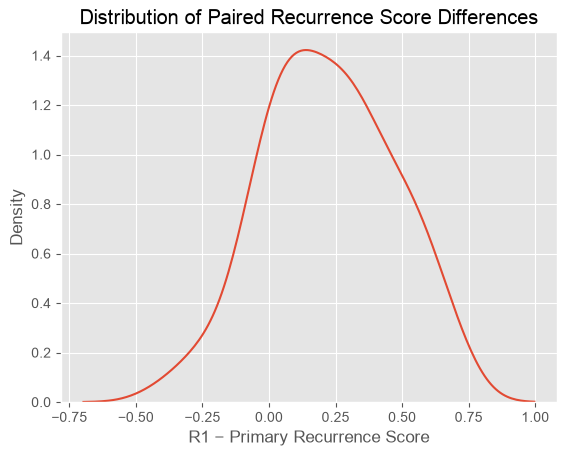

In [207]:
sns.kdeplot(np.array(score_pairs["DELTA_RECURRENCE_SCORE"]))

plt.title("Distribution of Paired Recurrence Score Differences")
plt.xlabel("R1 − Primary Recurrence Score")
plt.ylabel("Density")
plt.show()

In [208]:
delta_skew_rs = float(skew(score_pairs["DELTA_RECURRENCE_SCORE"], nan_policy="omit"))

print("Patient pairs:", glass_recurrence_scores["PATIENT_ID"].nunique())
print(f"Skewness:{float(delta_skew_rs):.3f}")

Patient pairs: 103
Skewness:-0.045


> **Methodological Note:** The paired recurrence score differences exhibited minimal skewness (skewness = -0.045). Given the near-symmetric distribution of the differences and the sample size of $N = 103$ paired observations, the paired $t$-test was considered appropriate. The sample size also provides robustness to moderate deviations from normality through the Central Limit Theorem.

In [209]:
mean_delta_rs = score_pairs["DELTA_RECURRENCE_SCORE"].mean()
median_delta_rs = score_pairs["DELTA_RECURRENCE_SCORE"].median()

t_statistic_rs, p_value_rs = ttest_rel(
    score_pairs["First Recurrence"],
    score_pairs["Tumor Primary"]
)

valid_rs = (
    score_pairs["First Recurrence"].notna()
    & score_pairs["Tumor Primary"].notna()
)

r1_higher_rs = (
    score_pairs.loc[valid_rs, "First Recurrence"]
    > score_pairs.loc[valid_rs, "Tumor Primary"]
).copy()

n_r1_higher_rs = score_pairs.loc[r1_higher_rs].index.nunique()
n_pairs_rs = int(valid_rs.sum())

fraction_r1_higher_rs = n_r1_higher_rs / n_pairs_rs
percent_r1_higher_rs = (
    score_pairs.loc[valid_rs, "First Recurrence"]
    > score_pairs.loc[valid_rs, "Tumor Primary"]
).mean()

In [210]:
print("Recurrence Score paired comparison")
print(f"Mean delta: {mean_delta_rs:.4f}")
print(f"Median delta: {median_delta_rs:.4f}")
print(f"Paired t-test: t = {float(t_statistic_rs):.3f}, p = {float(p_value_rs):.3e}, {format_pvalue(p_value_rs)}")

print(
    f"R1 > Primary: "
    f"{n_r1_higher_rs}/{n_pairs_rs} "
    f"({100 * percent_r1_higher_rs:.1f}%)"
)

Recurrence Score paired comparison
Mean delta: 0.2227
Median delta: 0.2270
Paired t-test: t = 9.249, p = 3.735e-15, <0.000001
R1 > Primary: 82/103 (79.6%)


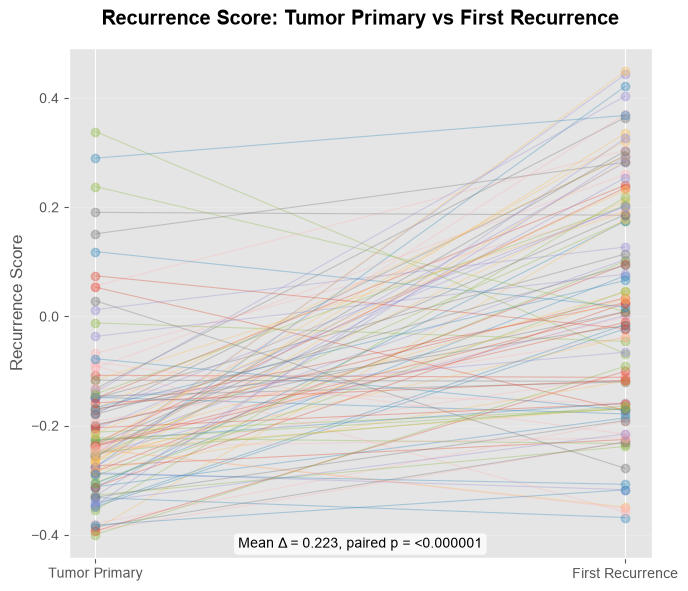

In [211]:
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in score_pairs.iterrows():
    ax.plot(
        ["Tumor Primary", "First Recurrence"],
        [row["Tumor Primary"], row["First Recurrence"]],
        marker="o",
        linewidth=0.8,
        alpha=0.35
    )

ax.set_ylabel("Recurrence Score")
ax.set_title("Recurrence Score: Tumor Primary vs First Recurrence", fontweight="bold", y=1.03)
ax.text(
    0.5,
    0.02,
    f"Mean Δ = {mean_delta_rs:.3f}, "
    f"paired p = {format_pvalue(p_value_rs)}",
    transform=ax.transAxes,
    ha="center",
    bbox=dict(
            boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8
        )
)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../figures/glass_recurrence_score_paired.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

> **Summary Note:** The Recurrence Score increased substantially from Primary to first recurrence across the GLASS cohort (mean Δ = +0.223; median Δ = +0.227). The increase was statistically significant in the paired analysis (paired t-test, t = 9.249, p = 3.74 × 10⁻¹⁵), with 82/103 patients (79.6%) showing a higher Recurrence Score in their first recurrent samples than in their primary tumour sample. These findings support the ability of the rank-based Recurrence Score to capture a transcriptional program associated with tumour recurrence.

## 8. Out-of-fold validation using 5-fold cross-validation
- Is it possible to recognise recurrence in patients that were not part of creating the recurrence signature?
- out-of-fold recurrence score

In [212]:
expr = glass_idhwt_gbm_primary_R1_log2TPM_filtered
pairs = glass_idhwt_gbm_primary_R1_pairs
genes = expr.index
n_patients = len(pairs)

In [213]:
glass_idhwt_gbm_primary_R1_pairs.head()

,PATIENT_ID,PRIMARY_SAMPLE_ID,FIRST_RECURRENCE_SAMPLE_ID
0,GLSS-19-0267,GLSS-19-0267-TP,GLSS-19-0267-R1
1,GLSS-19-0268,GLSS-19-0268-TP,GLSS-19-0268-R1
2,GLSS-19-0269,GLSS-19-0269-TP,GLSS-19-0269-R1
3,GLSS-19-0271,GLSS-19-0271-TP,GLSS-19-0271-R1
4,GLSS-19-0272,GLSS-19-0272-TP,GLSS-19-0272-R1


In [214]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_scores = []

assert len(pairs) == 103
assert pairs["PATIENT_ID"].nunique() == 103
assert pairs["PATIENT_ID"].is_unique

for fold, (train_idx, test_idx) in enumerate(
    kf.split(pairs),
    start=1
):
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    print(f"\nFold {fold}/5")
    print(f"Training patients: {len(train_idx)}")
    print(f"Test patients: {len(pd.DataFrame(test_idx))}")

    # -------------------------
    # TRAINING SET
    # -------------------------

    train_pairs = pairs.iloc[train_idx]

    primary_ids = train_pairs["PRIMARY_SAMPLE_ID"].tolist()
    r1_ids = train_pairs["FIRST_RECURRENCE_SAMPLE_ID"].tolist()

    primary_train = expr.loc[:, primary_ids]
    r1_train = expr.loc[:, r1_ids]

    delta_train = (
        r1_train.to_numpy() -
        primary_train.to_numpy()
    )

    n_train_genes = delta_train.shape[0]

    n = np.sum(
        ~np.isnan(delta_train),
        axis=1
    )

    mean_delta = np.nanmean(
        delta_train,
        axis=1
    )

    sd_delta = np.nanstd(
        delta_train,
        axis=1,
        ddof=1
    )

    t_statistic = (
        mean_delta /
        (sd_delta / np.sqrt(n))
    )

    p_values = np.full(
        n_train_genes,
        np.nan,
        dtype=float
    )

    valid_tests = (
        (n >= 2) &
        np.isfinite(t_statistic)
    )

    p_values[valid_tests] = (
        2 *
        t.sf(
            np.abs(t_statistic[valid_tests]),
            df=n[valid_tests] - 1
        )
    )

    fdr = np.full(
        n_train_genes,
        np.nan,
        dtype=float
    )

    valid_p = np.isfinite(p_values)

    fdr[valid_p] = multipletests(
        p_values[valid_p],
        method="fdr_bh"
    )[1]

    fraction_up = np.divide(
        np.sum(
            (delta_train > 0) &
            ~np.isnan(delta_train),
            axis=1
        ),
        n,
        out=np.full(
            n.shape,
            np.nan,
            dtype=float
        ),
        where=n > 0
    )

    fraction_down = np.divide(
        np.sum(
            (delta_train < 0) &
            ~np.isnan(delta_train),
            axis=1
        ),
        n,
        out=np.full(
            n.shape,
            np.nan,
            dtype=float
        ),
        where=n > 0
    )

    train_up = (
        (fdr < 0.05) &
        (mean_delta >= 0.5) &
        (fraction_up >= 0.65)
    )

    train_down = (
        (fdr < 0.05) &
        (mean_delta <= -0.5) &
        (fraction_down >= 0.65)
    )

    up_genes = genes[train_up]
    down_genes = genes[train_down]

    print(f"Training UP genes: {len(up_genes)}")
    print(f"Training DOWN genes: {len(down_genes)}")

    # -------------------------
    # TEST SET
    # -------------------------

    test_pairs = pairs.iloc[test_idx]

    test_sample_ids = (
        test_pairs["PRIMARY_SAMPLE_ID"].tolist()
        +
        test_pairs["FIRST_RECURRENCE_SAMPLE_ID"].tolist()
    )

    test_expr = expr.loc[:, test_sample_ids]

    test_percentile_ranks = test_expr.rank(
        axis=0,
        method="average",
        pct=True
    )

    up_score = test_percentile_ranks.loc[
        test_percentile_ranks.index.intersection(
            up_genes
        )
    ].mean(axis=0)
    up_scores = up_score.to_numpy()

    down_score = test_percentile_ranks.loc[
        test_percentile_ranks.index.intersection(
            down_genes
        )
    ].mean(axis=0)
    down_scores = down_score.to_numpy()

    recurrence_score = (
        up_score -
        down_score
    )

    fold_scores = pd.DataFrame({
        "SAMPLE_ID": test_sample_ids,
        "UP_SCORE": up_score,
        "DOWN_SCORE": down_score,
        "RECURRENCE_SCORE": recurrence_score.to_numpy(),
        "FOLD": fold
    })

    fold_sample_info: pd.DataFrame = pd.concat([
        test_pairs.loc[:, ["PATIENT_ID", "PRIMARY_SAMPLE_ID"]
        ].rename({"PRIMARY_SAMPLE_ID": "SAMPLE_ID"},
                 axis="columns"
        ).assign(SAMPLE_TYPE="Tumor Primary"),
        test_pairs.loc[:, ["PATIENT_ID", "FIRST_RECURRENCE_SAMPLE_ID"]
        ].rename({"FIRST_RECURRENCE_SAMPLE_ID": "SAMPLE_ID"},
                 axis="columns",
        ).assign(SAMPLE_TYPE="First Recurrence")
    ],ignore_index=True
    )

    fold_scores = fold_sample_info.merge(
        fold_scores,
        on="SAMPLE_ID",
        how="left",
        validate="one_to_one"
    )

    oof_scores.append(fold_scores)


Fold 1/5
Training patients: 82
Test patients: 21
Training UP genes: 348
Training DOWN genes: 186

Fold 2/5
Training patients: 82
Test patients: 21
Training UP genes: 217
Training DOWN genes: 342

Fold 3/5
Training patients: 82
Test patients: 21
Training UP genes: 351
Training DOWN genes: 189

Fold 4/5
Training patients: 83
Test patients: 20
Training UP genes: 336
Training DOWN genes: 202

Fold 5/5
Training patients: 83
Test patients: 20
Training UP genes: 242
Training DOWN genes: 191


In [215]:
glass_recurrence_scores_out_of_fold: pd.DataFrame = pd.concat(
    oof_scores,
    ignore_index=True
)

In [216]:
glass_recurrence_scores_out_of_fold.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,UP_SCORE,DOWN_SCORE,RECURRENCE_SCORE,FOLD
0,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,0.445157,0.552165,-0.107008,1
1,GLSS-19-0272,GLSS-19-0272-TP,Tumor Primary,0.348267,0.597626,-0.249359,1
2,GLSS-CU-P046,GLSS-CU-P046-TP,Tumor Primary,0.409731,0.522059,-0.112328,1
3,GLSS-CU-P069,GLSS-CU-P069-TP,Tumor Primary,0.433734,0.660279,-0.226545,1
4,GLSS-CU-R005,GLSS-CU-R005-TP,Tumor Primary,0.370635,0.603193,-0.232557,1


In [217]:
print(f"\nOut-of-fold scores calculated for "
      f"{len(glass_recurrence_scores_out_of_fold)} samples "
      f"from {n_patients} patients.")

print(glass_recurrence_scores_out_of_fold[
        ["UP_SCORE",
         "DOWN_SCORE",
         "RECURRENCE_SCORE"]].describe())


Out-of-fold scores calculated for 206 samples from 103 patients.
         UP_SCORE  DOWN_SCORE  RECURRENCE_SCORE
count  206.000000  206.000000        206.000000
mean     0.452375    0.530004         -0.077629
std      0.127431    0.083768          0.188732
min      0.231240    0.315442         -0.355102
25%      0.354253    0.476431         -0.224113
50%      0.428000    0.540677         -0.133603
75%      0.533735    0.593634          0.041626
max      0.750986    0.692567          0.435544


In [218]:
glass_recurrence_scores_out_of_fold.to_excel(
    "../results/recurrence/glass_recurrence_scores_out_of_fold.xlsx",
    index=False
)

- `glass_recurrence_scores_out_of_fold.xlsx` exported to `/results/recurrence` directory.

## 9. Assessing the out-of-fold Recurrence Score
- OOF_DELTA_SCORE = OOF_SCORE_R1 – OOF_SCORE_PRIMARY

In [219]:
oof_pairs = pd.DataFrame(glass_recurrence_scores_out_of_fold.pivot(
    index="PATIENT_ID",
    columns="SAMPLE_TYPE",
    values="RECURRENCE_SCORE"
))

oof_pairs["OOF_DELTA_SCORE"] = (
    oof_pairs["First Recurrence"] -
    oof_pairs["Tumor Primary"]
)

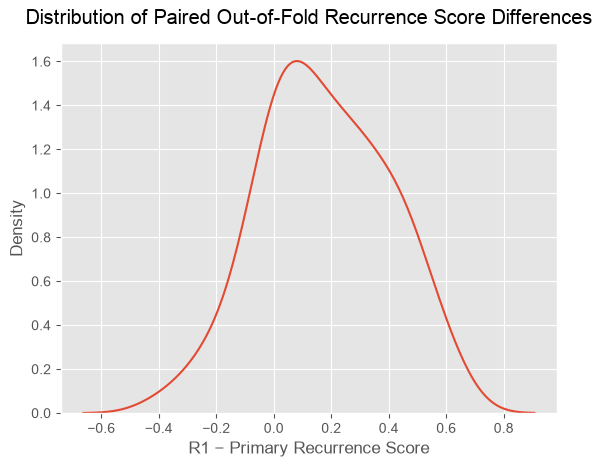

In [220]:
sns.kdeplot(np.array(oof_pairs["OOF_DELTA_SCORE"]))

plt.title("Distribution of Paired Out-of-Fold Recurrence Score Differences", y=1.03)
plt.xlabel("R1 − Primary Recurrence Score")
plt.ylabel("Density")
plt.show()

In [221]:
oof_delta_skew = float(skew(oof_pairs["OOF_DELTA_SCORE"], nan_policy="omit"))

print("Patient pairs:", glass_recurrence_scores_out_of_fold["PATIENT_ID"].nunique())
print(f"Skewness:{float(oof_delta_skew):.3f}")

Patient pairs: 103
Skewness:-0.027


> **Methodological Note:** The paired out-of-fold recurrence score differences exhibited minimal skewness (skewness = -0.027). Given the near-symmetric distribution of the differences and the sample size of $N = 103$ paired observations, the paired $t$-test was considered appropriate. The sample size also provides robustness to moderate deviations from normality through the Central Limit Theorem.

In [222]:
mean_delta_oof = oof_pairs["OOF_DELTA_SCORE"].mean()
median_delta_oof = oof_pairs["OOF_DELTA_SCORE"].median()

t_statistic_oof, p_value_oof = ttest_rel(
    oof_pairs["First Recurrence"],
    oof_pairs["Tumor Primary"]
)

valid_oof = (
    oof_pairs["First Recurrence"].notna()
    & oof_pairs["Tumor Primary"].notna()
)

r1_higher_oof = (
    oof_pairs.loc[valid_oof, "First Recurrence"]
    > oof_pairs.loc[valid_oof, "Tumor Primary"]
).copy()

n_r1_higher_oof = oof_pairs.loc[r1_higher_oof].index.nunique()
n_pairs_oof = int(valid_oof.sum())

fraction_r1_higher_oof = n_r1_higher_oof / n_pairs_oof
percent_r1_higher_oof = (
    oof_pairs.loc[valid_oof, "First Recurrence"]
    > oof_pairs.loc[valid_oof, "Tumor Primary"]
).mean()

In [223]:
t_statistic_oof = float(t_statistic_oof)
p_value_oof = float(p_value_oof)

print("Out-of-fold Recurrence Score evaluation")
print(f"Patients: {len(oof_pairs)}")
print(f"Mean OOF delta: {mean_delta_oof:.4f}")
print(f"Median OOF delta: {median_delta_oof:.4f}")
print(
    f"Paired t-test: "
f"t = {t_statistic_oof:.3f}, "
f"p = {p_value_oof:.3e} {format_pvalue(p_value_oof)}")

print(
    f"R1 > Primary: "
    f"{n_r1_higher_oof}/{n_pairs_oof} "
    f"({100 * percent_r1_higher_oof:.1f}%)"
)

Out-of-fold Recurrence Score evaluation
Patients: 103
Mean OOF delta: 0.1758
Median OOF delta: 0.1680
Paired t-test: t = 8.004, p = 2.001e-12 <0.000001
R1 > Primary: 80/103 (77.7%)


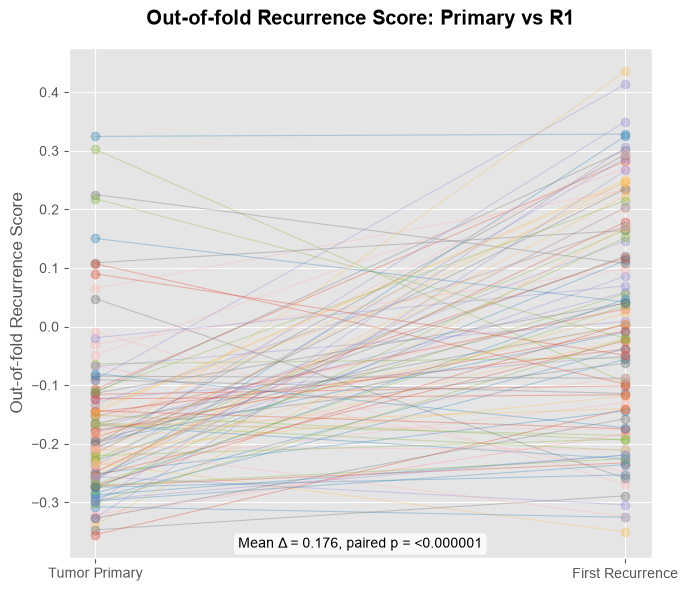

In [224]:
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in oof_pairs.iterrows():
    ax.plot(
        ["Tumor Primary", "First Recurrence"],
        [row["Tumor Primary"], row["First Recurrence"]],
        marker="o",
        linewidth=0.8,
        alpha=0.35
    )

ax.set_ylabel("Out-of-fold Recurrence Score")
ax.set_title("Out-of-fold Recurrence Score: Primary vs R1", fontweight="bold", y=1.03)

ax.text(
    0.5,
    0.02,
    f"Mean Δ = {mean_delta_oof:.3f}, "
    f"paired p = {format_pvalue(p_value_oof)}",
    transform=ax.transAxes,
    ha="center",
    bbox=dict(
            boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8
        )
)

plt.tight_layout()

plt.savefig(
    "../figures/glass_recurrence_score_out_of_fold_paired.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [225]:
roc_data = glass_recurrence_scores_out_of_fold.copy()

roc_data["LABEL"] = (
        roc_data["SAMPLE_TYPE"] == "First Recurrence"
).astype(int)

oof_auc = roc_auc_score(
    roc_data["LABEL"],
    roc_data["RECURRENCE_SCORE"]
)

print(f"OOF ROC AUC: {oof_auc:.3f}")

OOF ROC AUC: 0.770


> **Summary Note:** The Recurrence Score was consistently higher at first recurrence than in the corresponding Primary samples (mean Δ = 0.176; median Δ = 0.168; paired t = 8.004, p = 2.00 × 10⁻¹²), with 77.7% of patients showing an increased score at R1. The out-of-fold Recurrence Score also discriminated between Primary and R1 samples with an ROC AUC of 0.770. These findings support the ability of the Recurrence Signature to identify recurrence-associated transcriptional patterns in patients who were not used to construct the corresponding signature.

## 10. Sensitivity analysis in patients receiving standard therapy

- Treatment selection and interval mapping
    - Assessable window: Only treatments initiated strictly between primary and recurrent sampling dates (`PRIMARY_DATE` < `START_DATE` $\le$ `RECURRENCE_DATE`) were included.
    - Invalid or non-chronological dates were marked `pd.NA`.
    - Standard therapies:
        - Radiotherapy (RT): Any radiation initiated within the window.
        - Temozolomide (TMZ): Standard monotherapy (`temozolomide`, `temodar`, `tmz`).
        - Concurrent TMZ+RT: Simultaneous initiation of TMZ and RT on the exact same date (`START_DATE`).
        - Other Systemic: Includes all non-TMZ chemotherapy, modified dosing (e.g., LD TMZ), combination regimens (e.g., TMZ + Lomustine), and completely different regimens (e.g., Bevacizumab, PCV).

In [226]:
print("From cohort, has received TMZ treatment:", len(tmz))
print("From cohort, has received radiotherapy:", len(radiotherapy))
print("From cohort, has received concurrent TMZ treatment and radiotherapy:", len(concurrent_tmz))
print("From cohort, has received other systemic treatments:", len(other_systemic))

From cohort, has received TMZ treatment: 86
From cohort, has received radiotherapy: 97
From cohort, has received concurrent TMZ treatment and radiotherapy: 92
From cohort, has received other systemic treatments: 25


In [227]:
expr_matrix = glass_idhwt_gbm_primary_R1_log2TPM_filtered.copy()

scores_series = calculate_recurrence_score(expr_matrix, consensus_up_genes, consensus_down_genes)

scores_df = pd.DataFrame(
    {"SAMPLE_ID": scores_series.index, "RECURRENCE_SCORE": scores_series["RECURRENCE_SCORE"]}
)

scores_df = scores_df.merge(
    glass_recurrence_scores_full_cohort[["SAMPLE_ID", "PATIENT_ID"]].drop_duplicates(),
    on="SAMPLE_ID",
    how="left",
)

In [228]:
subgroups = {
    "Standard TMZ + RT":  (tmz & radiotherapy),
    "Standard TMZ + RT (No Other Systemic)": (tmz & radiotherapy - other_systemic)
}

paired_dfs = {}

for title, patient_ids in subgroups.items():
    sub_df = treatment_pairs.loc[treatment_pairs["PATIENT_ID"].isin(patient_ids)].copy()

    samples:pd.DataFrame = pd.concat(
        [sub_df[["PATIENT_ID", "PRIMARY_SAMPLE_ID"]
            ].rename(columns={"PRIMARY_SAMPLE_ID": "SAMPLE_ID"}
            ).assign(SAMPLE_TYPE="Tumor Primary"),
            sub_df[["PATIENT_ID", "FIRST_RECURRENCE_SAMPLE_ID"]
            ].rename(columns={"FIRST_RECURRENCE_SAMPLE_ID": "SAMPLE_ID"}
            ).assign(SAMPLE_TYPE="First Recurrence"),
        ],ignore_index=True,)

    merged = samples.merge(
        scores_df,
        on=["PATIENT_ID", "SAMPLE_ID"],
        how="left",)

    paired = (
        merged
        .pivot(
            index="PATIENT_ID",
            columns="SAMPLE_TYPE",
            values="RECURRENCE_SCORE",).reset_index())

    paired["DELTA_RECURRENCE_SCORE"] = (
        paired["First Recurrence"]
        - paired["Tumor Primary"])

    paired_dfs[title] = paired

In [229]:
with pd.ExcelWriter(
    "../results/recurrence/glass_recurrence_score_standard_treatment.xlsx"
) as writer:
    for title, df in paired_dfs.items():
        sheet = (
            "Standard_TMZ_RT"
            if "No Other" not in title
            else "Standard_TMZ_RT_No_Other"
        )
        df.to_excel(writer, sheet_name=sheet, index=False)

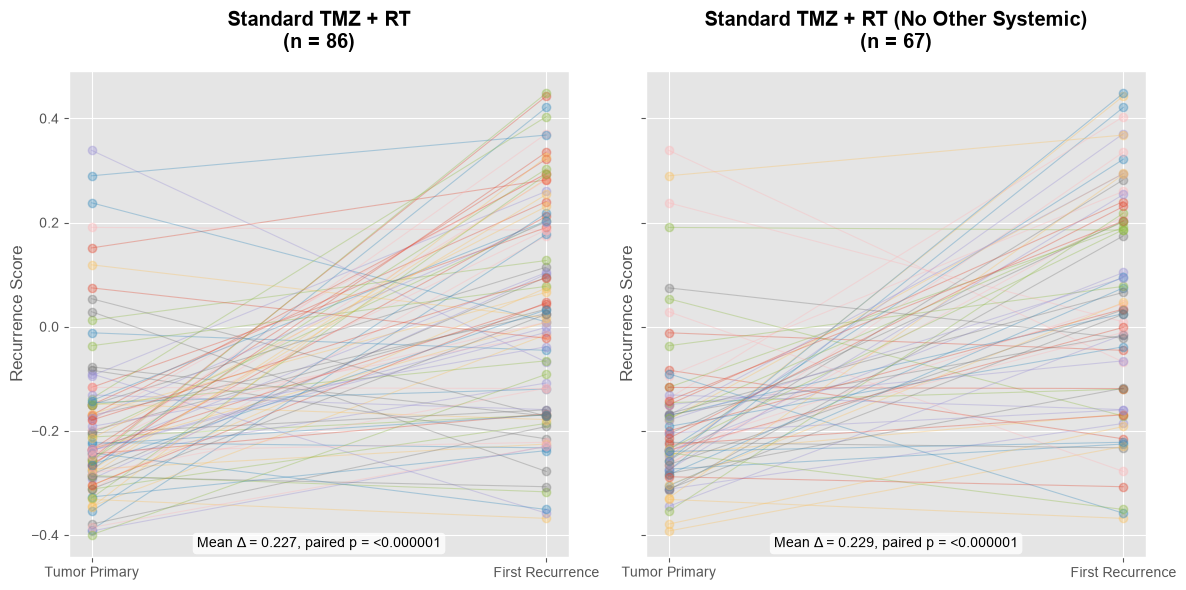

In [230]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, (title, paired) in zip(axes, paired_dfs.items()):
    mean_delta = paired["DELTA_RECURRENCE_SCORE"].mean()
    _, p_val = ttest_rel(paired["First Recurrence"], paired["Tumor Primary"])

    for _, row in paired.iterrows():
        ax.plot(
            ["Tumor Primary", "First Recurrence"],
            [row["Tumor Primary"], row["First Recurrence"]],
            marker="o",
            linewidth=0.8,
            alpha=0.35,
        )

    ax.set_ylabel("Recurrence Score")
    ax.set_title(f"{title}\n(n = {len(paired)})", fontweight="bold", y=1.03)

    ax.text(
        0.5,
        0.02,
        f"Mean Δ = {mean_delta:.3f}, paired p = {format_pvalue(p_val)}",
        transform=ax.transAxes,
        ha="center",
        bbox=dict(
            boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8
        ),
    )

plt.tight_layout()

plt.savefig(
    "../figures/glass_recurrence_score_standard_treatment.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

> **Summary Note:** Sensitivity analyses confirmed that the observed increase in Recurrence Score is not driven by non-standard treatment regimens.
>
> - **Standard TMZ + RT Cohort:** Recurrence Scores increased significantly from Primary to R1 (mean Δ = 227, paired t-test p < 0.000001).
> - **Standard TMZ + RT (No Other Systemic Therapy):** The Recurrence Score increase remained robust and statistically significant when excluding patients who received non-standard systemic agents (mean Δ = 229, paired t-test p < 0.000001).
>
> These results confirm that the consensus Recurrence Signature tracks intrinsic glioblastoma progression under standard treatment.

# **Can the transcriptional program associated with tumour recurrence be identified in glioblastoma cell lines?**

## 1. Solidifying Recurrence Score

In [231]:
glass_recurrence_UP_consensus = consensus_up.copy()
glass_recurrence_DOWN_consensus = consensus_down.copy()

In [232]:
glass_recurrence_signature_final = pd.concat(
    [
        glass_recurrence_UP_consensus,
        glass_recurrence_DOWN_consensus,
    ],
    ignore_index=True,
).rename(
    columns={
        "ORIGINAL_DIRECTION": "DIRECTION",
        "ORIGINAL_MEAN_DELTA": "MEAN_DELTA",
        "ORIGINAL_FDR": "FDR",
    }
)

glass_recurrence_signature_final = glass_recurrence_signature_final[
    [
        "GENE",
        "DIRECTION",
        "MEAN_DELTA",
        "FDR",
        "BOOTSTRAP_SAME_DIRECTION_FREQUENCY",
    ]
].copy()

In [233]:
glass_recurrence_signature_final.head()

,GENE,DIRECTION,MEAN_DELTA,FDR,BOOTSTRAP_SAME_DIRECTION_FREQUENCY
0,ENPP2,UP,1.361706,0.000006,0.999
1,MAL,UP,1.647429,0.000004,0.995
2,SLC45A3,UP,0.892563,0.000010,0.993
3,ADIRF,UP,0.990164,0.000008,0.991
4,GREM1,UP,0.965628,0.000008,0.985


In [234]:
glass_recurrence_signature_final.to_excel(
    "../results/recurrence/glass_recurrence_signature_final.xlsx",
    index = False
)

- `glass_recurrence_signature_final.xlsx` exported to `/results/recurrence` directory

## 2. Defining the final glioma cell-line cohort

### Load and filter expression data
* Model.cvs was used for identification of cell line oncotree lineages
* Source: https://depmap.org/portal/data_page/?tab=allData&releasename=DepMap%20Public%2026Q1&filename=Model.csv
* Two expression datasets were used:

In [235]:
model = pd.read_csv(
    "../data/raw/annotation/Model.csv",
    index_col=0,
    low_memory=False,
)

model.index.name = "ModelID"

In [236]:
model_metadata = (
    model[
        [
            "CellLineName",
            "StrippedCellLineName",
            "COSMICID",
            "CCLEName",
            "SangerModelID",
            "ModelIDAlias",
            "OncotreeLineage",
            "OncotreePrimaryDisease"
        ]
    ]
    .copy()
)

model_metadata.index.name = "ModelID"

In [237]:
glioma_model_ids = model.index[
    model["OncotreePrimaryDisease"]
    .str.contains("glioma", case=False, na=False)
]

print("Total glioma cell lines in Model.csv:", len(glioma_model_ids))

Total glioma cell lines in Model.csv: 96


#### DepMap - Log-transformed TPM (Transcripts Per Million) values at gene level derived from unstranded RNA-seq for all genes in human
- Reference: DepMap, Broad (2026). DepMap Public 26Q1. Dataset. depmap.org
- **Raw Data:** `OmicsExpressionTPMLogp1HumanAllGenes.csv`
- **Source:** [https://depmap.org/portal/download/all/?release=DepMap+Public+26Q1&file=OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv&tab=allData](https://depmap.org/portal/data_page/?tab=allData&releasename=DepMap%20Public%2026Q1&filename=OmicsExpressionTPMLogp1HumanAllGenes.csv)

In [238]:
OmicsExpressionTPMLogp1HumanAllGenes = pd.read_csv(
    "../data/raw/DepMap/expression/OmicsExpressionTPMLogp1HumanAllGenes.csv",
    index_col=0,
)

gene = pd.read_csv(
    "../data/raw/annotation/Gene.csv",
    index_col=0,
    low_memory=False
)

In [239]:
OmicsExpressionTPMLogp1HumanAllGenes.iloc[:5,:20]

,SequencingID,ModelConditionID,ModelID,IsDefaultEntryForMC,IsDefaultEntryForModel,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),STPG1 (90529),NIPAL3 (57185),LAS1L (81887),ENPP4 (22875),SEMA3F (6405)
0,CDS-010xbm,MC-001113-k2lR,ACH-001113,Yes,Yes,4.956577,0.000000,7.577648,3.179411,4.765742,0.037483,1.510547,3.103039,6.697482,4.852303,3.497101,4.253384,5.039358,2.873880,3.226268
1,CDS-02TzJp,MC-001289-BpdI,ACH-001289,Yes,Yes,4.955015,0.617117,7.333933,2.782935,3.735371,0.000000,0.148922,3.855123,4.376707,3.465922,1.977529,3.223240,4.790318,4.280221,1.461932
2,CDS-0693hw,MC-001339-5nRN,ACH-001339,Yes,Yes,3.421952,0.000000,7.546069,2.615880,4.476233,0.064571,1.397491,6.833915,3.980336,3.437155,3.078680,3.620422,4.155158,1.102793,0.262396
3,CDS-07Plat,MC-001619-IR6I,ACH-001619,No,No,5.196729,0.000000,6.362268,2.144996,3.087183,0.036001,5.118850,7.013295,6.177005,3.509987,3.317112,3.998484,5.645440,2.898895,2.774494
4,CDS-08FOcu,MC-001979-E3qW,ACH-001979,Yes,Yes,4.651643,0.000000,5.946408,2.454515,1.852111,0.000000,7.680796,6.156866,5.042574,3.258451,3.194224,5.207666,4.629963,0.000000,0.419227


In [240]:
depmap_exp = OmicsExpressionTPMLogp1HumanAllGenes.copy()

depmap_exp = depmap_exp[
    depmap_exp["IsDefaultEntryForModel"].eq("Yes")
].copy()

depmap_exp = depmap_exp.drop(
    columns=[
        "SequencingID",
        "ModelConditionID",
        "IsDefaultEntryForMC",
        "IsDefaultEntryForModel"
    ]
).copy()


depmap_exp = depmap_exp.set_index("ModelID")
depmap_exp = depmap_exp.rename(columns=lambda x: re.sub(r"\s*\(.*?\)", "", x))

In [241]:
gene_map = (
    gene
    .dropna(subset=["ensembl_gene_id", "symbol"])
    .drop_duplicates("ensembl_gene_id")
    .set_index("ensembl_gene_id")["symbol"]
)

In [242]:
mapped = depmap_exp.columns.to_series().map(gene_map)

print("Total genes:", len(depmap_exp.columns))
print("Mapped:", mapped.notna().sum())
print("Unmapped:", mapped.isna().sum())

Total genes: 60649
Mapped: 183
Unmapped: 60466


In [243]:
duplicates = depmap_exp.columns[depmap_exp.columns.duplicated()]

print("Duplicate symbols:", len(duplicates))
print(duplicates.tolist())

Duplicate symbols: 0
[]


In [244]:
original_columns = depmap_exp.columns.to_series()

depmap_exp.columns = (
    original_columns
    .map(gene_map)
    .fillna(original_columns)
)

In [245]:
depmap_exp.iloc[:5, :5]

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM
ModelID,,,,,
ACH-001113,4.956577,0.000000,7.577648,3.179411,4.765742
ACH-001289,4.955015,0.617117,7.333933,2.782935,3.735371
ACH-001339,3.421952,0.000000,7.546069,2.615880,4.476233
ACH-001979,4.651643,0.000000,5.946408,2.454515,1.852111
ACH-002438,4.336705,0.000000,6.879387,2.262824,3.256491


In [246]:
depmap_default_entry_ids = OmicsExpressionTPMLogp1HumanAllGenes["ModelID"][
    OmicsExpressionTPMLogp1HumanAllGenes["IsDefaultEntryForModel"]
    == "Yes"
]

depmap_exp = depmap_exp.loc[
    depmap_exp.index.isin(depmap_default_entry_ids)
].copy()


In [247]:
depmap_exp_metadata = model.reindex(depmap_exp.index)

depmap_glioma_ids = depmap_exp_metadata.index[
    depmap_exp_metadata["OncotreePrimaryDisease"]
    .str.contains("glioma", case=False, na=False)
]

depmap_glioma_exp = depmap_exp.loc[
    depmap_exp.index.isin(depmap_glioma_ids)
].copy()

print("DepMap total:", depmap_exp.index.nunique())
print("DepMap glioma:", depmap_glioma_exp.index.nunique())
print("DepMap expression variables:", depmap_glioma_exp.columns.nunique())

DepMap total: 1719
DepMap glioma: 74
DepMap expression variables: 60649


### DepMap expression data quality check

In [248]:
# noinspection dict-creation
depmap_expression_qc = {}

depmap_expression_qc["Dataset"] = (
    "OmicsExpressionTPMLogp1HumanAllGenes.csv"
)

depmap_expression_qc["Platform"] = (
    "Log-Transformed  RNA-seq"
)

depmap_expression_qc["Total_cell_lines"] = (
    depmap_exp.index.nunique()
)

depmap_expression_qc["Total_expression_variables"] = (
    depmap_exp.columns.nunique()
)

depmap_expression_qc["Minimum_expression"] = (
    np.nanmin(depmap_exp.to_numpy(dtype=float))
)

depmap_expression_qc["Maximum_expression"] = (
    np.nanmax(depmap_exp.to_numpy(dtype=float))
)

In [249]:
missing_depmap_expression = glioma_model_ids.difference(depmap_exp.index)

print("Glioma cell lines according to Model.csv:", len(glioma_model_ids))
print("Glioma cell lines with DepMap expression:", depmap_glioma_exp.index.nunique())
print("Glioma cell lines missing DepMap expression:", len(missing_depmap_expression))

Glioma cell lines according to Model.csv: 96
Glioma cell lines with DepMap expression: 74
Glioma cell lines missing DepMap expression: 22


In [250]:
depmap_missing_metadata = model.loc[
    missing_depmap_expression,
    [
        "CellLineName",
        "COSMICID",
        "OncotreeLineage",
        "OncotreePrimaryDisease",
        "OncotreeSubtype",
    ]
].copy()

In [251]:
depmap_expression_available = depmap_exp.index.nunique()

depmap_expression_qc["Glioma_cohort_size"] = len(glioma_model_ids)

depmap_expression_qc["Glioma_with_DepMap_expression"] = (
    depmap_expression_available
)

depmap_expression_qc["Glioma_missing_DepMap_expression"] = (
    len(missing_depmap_expression)
)

depmap_expression_qc["Expression_variable_type"] = (
    "Gene symbols"
)

In [252]:
depmap_expression_qc["Duplicate_ModelIDs"] = (
    depmap_exp.index.duplicated().sum()
)

In [253]:
all_missing_profiles = depmap_exp.index[
    depmap_exp.isna().all(axis=1)
]

depmap_expression_qc["Completely_missing_profiles"] = (
    len(all_missing_profiles)
)

print(
    "Completely missing expression profiles:",
    all_missing_profiles.tolist()
)

Completely missing expression profiles: []


In [254]:
depmap_expression_qc["Duplicated_gene_variables"] = (
    depmap_exp.columns.duplicated().sum()
)

In [255]:
depmap_qc_summary = pd.DataFrame(
    {
        "Metric": [
            "Dataset",
            "Platform",
            "Total DepMap cell lines",
            "Glioma cell lines (Model.csv)",
            "Glioma cell lines with DepMap expression",
            "Glioma cell lines missing DepMap expression",
            "Expression variables",
            "Expression variable type",
            "Duplicated cell-line IDs",
            "Completely missing expression profiles",
            "Duplicated expression variables",
            "Minimum expression value",
            "Maximum expression value",
        ],
        "Value": [
            depmap_expression_qc["Dataset"],
            depmap_expression_qc["Platform"],
            depmap_expression_qc["Total_cell_lines"],
            depmap_expression_qc["Glioma_cohort_size"],
            depmap_expression_qc["Glioma_with_DepMap_expression"],
            depmap_expression_qc["Glioma_missing_DepMap_expression"],
            depmap_expression_qc["Total_expression_variables"],
            depmap_expression_qc["Expression_variable_type"],
            depmap_expression_qc["Duplicate_ModelIDs"],
            depmap_expression_qc["Completely_missing_profiles"],
            depmap_expression_qc["Duplicated_gene_variables"],
            depmap_expression_qc["Minimum_expression"],
            depmap_expression_qc["Maximum_expression"],
        ],
    }
)

In [256]:
depmap_qc_summary

,Metric,Value
0,Dataset,OmicsExpressionTPMLogp1HumanAllGenes.csv
1,Platform,Log-Transformed RNA-seq
2,Total DepMap cell lines,1719
3,Glioma cell lines (Model.csv),96
4,Glioma cell lines with DepMap expression,1719
5,Glioma cell lines missing DepMap expression,22
6,Expression variables,60649
7,Expression variable type,Gene symbols
8,Duplicated cell-line IDs,0
9,Completely missing expression profiles,0


In [257]:
depmap_glioma = model.loc[
    model["OncotreePrimaryDisease"]
    .str.contains("glioma", case=False, na=False),
    ["CellLineName"]
].copy()


depmap_glioma = depmap_glioma.rename(
    columns={
        "CellLineName": "CELL_LINE_NAME"
    }
)

In [258]:
depmap_glioma_qc = pd.DataFrame(
    index=depmap_glioma.index
)

depmap_glioma_qc.index.name = "ModelID"

depmap_glioma_qc["DEPMAP_EXPRESSION_AVAILABLE"] = (
    depmap_glioma_qc.index.isin(depmap_exp.index)
)

depmap_glioma_qc["CELL_LINE_NAME"] = (
    depmap_glioma["CELL_LINE_NAME"]
)

In [259]:
duplicate_model_ids = (
    depmap_exp.index[
        depmap_exp.index.duplicated(keep=False)
    ]
    .unique()
)

In [260]:
with pd.ExcelWriter(
    "../results/qc/depmap_expression_QC.xlsx"
) as writer:

    depmap_qc_summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False,
    )

    depmap_glioma_qc.to_excel(
        writer,
        sheet_name="Glioma_Cohort",
    )

    if len(missing_depmap_expression) > 0:
        pd.DataFrame(
            {"ModelID": missing_depmap_expression}
        ).to_excel(
            writer,
            sheet_name="Missing_Expression",
            index=False,
        )

    if len(duplicate_model_ids) > 0:
        pd.DataFrame(
            {"ModelID": duplicate_model_ids}
        ).to_excel(
            writer,
            sheet_name="Duplicate_Model_IDs",
            index=False,
        )

#### **GDSC1/GDSC2 RNA-normalized Affymetrix HGU-219 Expression Matrix:**
- As of 19/7/2026, the preprocessed expression data released by the Sanger Institute is not available on the original website any more.
- This source was used to trace back the original link: https://github.com/BorgwardtLab/Kernelized-Rank-Learning/blob/master/URLs_to_GDSC_datasets.txt
- **Raw Data ArrayExpress Accession:** `E-MTAB-3610`
- **Preprocessed Data:** `data/raw/GDSC/expression/Cell_line_RMA_proc_basalExp.txt`
- **Original Source:** http://www.cancerrxgene.org/gdsc1000/GDSC1000_WebResources/Data/preprocessed/Cell_line_RMA_proc_basalExp.txt.zip
- **Currently Available Source:** https://web.archive.org/web/20260209143748/http://www.cancerrxgene.org/gdsc1000/GDSC1000_WebResources/Data/preprocessed/Cell_line_RMA_proc_basalExp.txt.zip

In [261]:
gdsc_exp = pd.read_csv(
    "../data/raw/GDSC/expression/Cell_line_RMA_proc_basalExp.txt",
    sep="\t",
    low_memory=False,
)

In [262]:
gdsc_gene_metadata = gdsc_exp[
    ["GENE_SYMBOLS", "GENE_title"]
].copy()

gdsc_gene_metadata["SOURCE"] = (
    gdsc_gene_metadata["GENE_title"]
    .str.extract(r"\[Source:([^;\]]+)", expand=False)
    .str.strip()
    .str.replace(r"\s+Symbol$", "", regex=True)
)

gdsc_gene_metadata["GENE_SYMBOL"] = (
    gdsc_gene_metadata["GENE_SYMBOLS"]
    .str.strip()
)

gdsc_gene_metadata = gdsc_gene_metadata[
    ["GENE_SYMBOL", "SOURCE"]
].drop_duplicates()

gdsc_gene_metadata.head()

,GENE_SYMBOL,SOURCE
0,TSPAN6,HGNC
1,TNMD,HGNC
2,DPM1,HGNC
3,SCYL3,HGNC
4,C1orf112,HGNC


In [263]:
expression_columns = [
    col for col in gdsc_exp.columns
    if col not in {"GENE_SYMBOLS", "GENE_title"}
]

gdsc_exp[expression_columns] = (
    gdsc_exp[expression_columns]
    .apply(pd.to_numeric, errors="coerce")
)

In [264]:
gdsc_exp = (
    gdsc_exp
    .dropna(subset=["GENE_SYMBOLS"])
    .drop(columns=["GENE_title"])
    .set_index("GENE_SYMBOLS")
    .T
)

gdsc_exp.index = (
    gdsc_exp.index
    .astype(str)
    .str.replace(r"^DATA\.", "", regex=True)
    .str.strip()
)

gdsc_exp.columns.name = None
gdsc_exp.index.name = "COSMICID"

In [265]:
model_cosmic = (
    model[["COSMICID"]]
    .dropna()
    .copy()
)

model_cosmic["COSMICID"] = (
    model_cosmic["COSMICID"]
    .astype("Int64")
    .astype("string")
)

cosmic_model_counts = (
    model_cosmic
    .reset_index()
    .groupby("COSMICID")["ModelID"]
    .nunique()
)

ambiguous_cosmic_ids = cosmic_model_counts[
    cosmic_model_counts > 1
]

print(
    "COSMICIDs mapping to multiple ModelIDs:",
    len(ambiguous_cosmic_ids),
)

COSMICIDs mapping to multiple ModelIDs: 0


In [266]:
cosmic_to_model = (
    model_cosmic
    .reset_index()
    .drop_duplicates("COSMICID")
    .set_index("COSMICID")["ModelID"]
)

gdsc_exp["ModelID"] = (
    pd.Series(gdsc_exp.index, index=gdsc_exp.index)
    .map(cosmic_to_model)
)

In [267]:
gdsc_exp = (
    gdsc_exp
    .set_index("ModelID")
)

gdsc_exp.index.name = "ModelID"

### GDSC expression data quality check

In [268]:
#noinspection dict-creation
gdsc_expression_qc = {}

gdsc_expression_qc["Dataset"] = (
    "Cell_line_RMA_proc_basalExp"
)

gdsc_expression_qc["Platform"] = (
    "Affymetrix Human Genome U219"
)

gdsc_expression_qc["Total_cell_lines"] = (
    gdsc_exp.index.nunique()
)

gdsc_expression_qc["Total_expression_variables"] = (
    len(gdsc_exp.columns)
)

gdsc_expression_qc["Minimum_expression"] = (
    np.nanmin(gdsc_exp.to_numpy(dtype=float))
)

gdsc_expression_qc["Maximum_expression"] = (
    np.nanmax(gdsc_exp.to_numpy(dtype=float))
)

In [269]:
gdsc_glioma_expression_ids = gdsc_exp.index.intersection(glioma_model_ids)

In [270]:
missing_gdsc_expression = glioma_model_ids.difference(gdsc_exp.index)

print("Glioma cell lines according to Model.csv:", len(glioma_model_ids))
print("Glioma cell lines with GDSC expression:", len(gdsc_glioma_expression_ids))
print("Glioma cell lines missing GDSC expression:", len(missing_gdsc_expression))

Glioma cell lines according to Model.csv: 96
Glioma cell lines with GDSC expression: 52
Glioma cell lines missing GDSC expression: 44


In [271]:
gdsc_glioma_exp = gdsc_exp.loc[
    gdsc_exp.index.isin(gdsc_glioma_expression_ids)
].copy()

In [272]:
gdsc_missing_metadata = model.loc[
    missing_gdsc_expression,
    [
        "CellLineName",
        "COSMICID",
        "OncotreeLineage",
        "OncotreePrimaryDisease",
        "OncotreeSubtype",
    ]
].copy()

In [273]:
gdsc_expression_available = gdsc_glioma_expression_ids[
    gdsc_glioma_expression_ids.isin(gdsc_exp.index)
]

gdsc_expression_qc["Glioma_cohort_size"] = gdsc_glioma_expression_ids.nunique()

gdsc_expression_qc["Glioma_with_expression"] = (
    gdsc_expression_available.nunique()
)

gdsc_expression_qc["Glioma_missing_expression"] = (
    gdsc_glioma_expression_ids.nunique()
    - gdsc_expression_available.nunique()
)

gdsc_expression_qc["Expression_variable_type"] = (
    "Gene symbols"
)

In [274]:
gdsc_expression_qc["Duplicate_ModelIDs"] = (
    gdsc_exp.index[gdsc_exp.index.duplicated(keep=False)].nunique()
)

gdsc_expression_qc["Duplicate_glioma_ModelIDs"] = (
    gdsc_expression_available[
        gdsc_expression_available.duplicated(keep=False)
    ].nunique()
)

In [275]:
all_missing_profiles = gdsc_exp.index[
    gdsc_exp.isna().all(axis=1)
]

gdsc_expression_qc["Completely_missing_profiles"] = (
    len(all_missing_profiles)
)

print(
    "Completely missing expression profiles:",
    all_missing_profiles.tolist()
)

Completely missing expression profiles: []


In [276]:
gdsc_expression_qc["Duplicated_gene_variables"] = (
    gdsc_exp.columns.duplicated().sum()
)

In [277]:
gdsc_qc_summary = pd.DataFrame(
    {
        "Metric": [
            "Dataset",
            "Platform",
            "Total cell lines",
            "Glioma cell lines",
            "Glioma cell lines with expression",
            "Glioma cell lines missing expression",
            "Expression variables",
            "Expression variable type",
            "Duplicated cell-line IDs",
            "Duplicated glioma cell-line IDs",
            "Completely missing expression profiles",
            "Duplicated expression variables",
            "Minimum expression value",
            "Maximum expression value",
        ],
        "Value": [
            gdsc_expression_qc["Dataset"],
            gdsc_expression_qc["Platform"],
            gdsc_expression_qc["Total_cell_lines"],
            gdsc_expression_qc["Glioma_cohort_size"],
            gdsc_expression_qc["Glioma_with_expression"],
            gdsc_expression_qc["Glioma_missing_expression"],
            gdsc_expression_qc["Total_expression_variables"],
            gdsc_expression_qc["Expression_variable_type"],
            gdsc_expression_qc["Duplicate_ModelIDs"],
            gdsc_expression_qc["Duplicate_glioma_ModelIDs"],
            gdsc_expression_qc["Completely_missing_profiles"],
            gdsc_expression_qc["Duplicated_gene_variables"],
            gdsc_expression_qc["Minimum_expression"],
            gdsc_expression_qc["Maximum_expression"],
        ],
    }
)

In [278]:
gdsc_qc_summary

,Metric,Value
0,Dataset,Cell_line_RMA_proc_basalExp
1,Platform,Affymetrix Human Genome U219
2,Total cell lines,945
3,Glioma cell lines,52
4,Glioma cell lines with expression,52
5,Glioma cell lines missing expression,0
6,Expression variables,17419
7,Expression variable type,Gene symbols
8,Duplicated cell-line IDs,0
9,Duplicated glioma cell-line IDs,0


In [279]:
gdsc_glioma = model.loc[
    model["OncotreePrimaryDisease"]
    .str.contains("glioma", case=False, na=False),
    ["CellLineName", "COSMICID"]
].copy()


gdsc_glioma = gdsc_glioma.rename(
    columns={
        "CellLineName": "CELL_LINE_NAME",
        "COSMICID": "GDSC_COSMIC_ID",
    }
)

In [280]:
gdsc_glioma_qc = pd.DataFrame(
    index=gdsc_glioma.index
)

gdsc_glioma_qc.index.name = "ModelID"

gdsc_glioma_qc["GDSC_EXPRESSION_AVAILABLE"] = (
    gdsc_glioma_qc.index.isin(gdsc_exp.index)
)

gdsc_glioma_qc["CELL_LINE_NAME"] = (
    gdsc_glioma["CELL_LINE_NAME"]
)

gdsc_glioma_qc["GDSC_COSMIC_ID"] = (
    gdsc_glioma["GDSC_COSMIC_ID"]
)

In [281]:
duplicate_model_ids = (
    gdsc_exp.index[
        gdsc_exp.index.duplicated(keep=False)
    ]
    .unique()
)

In [282]:
with pd.ExcelWriter(
    "../results/qc/gdsc_expression_QC.xlsx"
) as writer:

    gdsc_qc_summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False,
    )

    gdsc_glioma_qc.to_excel(
        writer,
        sheet_name="Glioma_Cohort",
    )

    if len(missing_gdsc_expression) > 0:
        pd.DataFrame(
            {"ModelID": missing_gdsc_expression}
        ).to_excel(
            writer,
            sheet_name="Missing_Expression",
            index=False,
        )

    if len(duplicate_model_ids) > 0:
        pd.DataFrame(
            {"ModelID": duplicate_model_ids}
        ).to_excel(
            writer,
            sheet_name="Duplicate_Model_IDs",
            index=False,
        )

### Load and filter sensitivity data
Checking if there's sensitivity data for all the expression data

#### Drug sensitivity data
- Reference: DepMap, Broad (2026). DepMap Public 26Q1. Dataset. depmap.org
- AUC is normalised to 1:
- **CTD^2 Raw Data:** `data/raw/Drug_sensitivity_AUC_(CTD^2)_subsetted.csv`
- **DepMap Raw Data:** `data/raw/Drug_sensitivity_AUC_(PRISM_Repurposing_Secondary_Screen)_subsetted.csv`
- **GDSC1 Raw Data:** `data/raw/Drug_sensitivity_AUC_(Sanger_GDSC1)_subsetted.csv`
- **GDSC2 Raw Data:** `data/raw/Drug_sensitivity_AUC_(Sanger_GDSC2)_subsetted.csv`
- **Sources:**
    - https://depmap.org/portal/download/all/?release=Harmonized+CTD%5E2+25Q2&file=CTRPAUCMatrix.csv&tab=allData
    - https://depmap.org/portal/download/all/?release=Harmonized+PRISM+Repurposing+Secondary+Screen+25Q2&file=REPURPOSINGAUCMatrix.csv&tab=allData
    - https://depmap.org/portal/download/all/?release=Harmonized+GDSC+25Q2&file=GDSC1AUCMatrix.csv&tab=allData
    - https://depmap.org/portal/download/all/?release=Harmonized+GDSC+25Q2&file=GDSC2AUCMatrix.csv&tab=allData
- AUC isn't normalised:
- **CTRPv2 Raw Data:**
    -  `../data/raw/old/sensitivity/glioma/CTRPv2.2_2015_pub_CancerDisc_5_1210.zip`
        - `v22.data.auc_sensitivities.txt`
        - `v22.meta.per_cell_line.txt`
        - `v22.meta.per_compound.txt`
- **Source:** https://d1hp0ufb0xxisr.cloudfront.net/CTD2/Broad/CTRPv2.2_2015_pub_CancerDisc_5_1210.zip

In [283]:
ctd2 = pd.read_csv(
    "../data/raw/DepMap/sensitivity/"
    "Drug_sensitivity_AUC_(CTD^2)_subsetted.csv",
    index_col=0,
)

prism = pd.read_csv(
    "../data/raw/DepMap/sensitivity/"
    "Drug_sensitivity_AUC_(PRISM_Repurposing_Secondary_Screen)_subsetted.csv",
    index_col=0,
)

gdsc1 = pd.read_csv(
    "../data/raw/GDSC/sensitivity/"
    "Drug_sensitivity_AUC_(Sanger_GDSC1)_subsetted.csv",
    index_col=0,
)

gdsc2 = pd.read_csv(
    "../data/raw/GDSC/sensitivity/"
    "Drug_sensitivity_AUC_(Sanger_GDSC2)_subsetted.csv",
    index_col=0,
)

#### Formatting CTRPv2 sensitivity data to match the others

In [284]:
auc = pd.read_csv(
    "../data/raw/DepMap/sensitivity/CTRPv2.2_2015_pub_CancerDisc_5_1210/"
    "v22.data.auc_sensitivities.txt",
    sep="\t",
)

cell_metadata = pd.read_csv(
    "../data/raw/DepMap/sensitivity/CTRPv2.2_2015_pub_CancerDisc_5_1210/"
    "v22.meta.per_cell_line.txt",
    sep="\t",
)

compound_metadata = pd.read_csv(
    "../data/raw/DepMap/sensitivity/CTRPv2.2_2015_pub_CancerDisc_5_1210/"
    "v22.meta.per_compound.txt",
    sep="\t",
)

In [285]:
def normalize_name(value):
    if pd.isna(value):
        return ""

    return re.sub(
        r"[^A-Z0-9]",
        "",
        str(value).upper(),
    )

In [286]:
model_for_mapping = model_metadata.reset_index()

model_name_mapping = pd.concat(
    [
        model_for_mapping[["ModelID", "CellLineName"]].rename(
            columns={"CellLineName": "model_name"}
        ),
        model_for_mapping[["ModelID", "StrippedCellLineName"]].rename(
            columns={"StrippedCellLineName": "model_name"}
        ),
        model_for_mapping[["ModelID", "CCLEName"]]
        .assign(
            CCLEName=lambda x: x["CCLEName"]
            .fillna("")
            .str.split("_")
            .str[0]
        )
        .rename(columns={"CCLEName": "model_name"}),
    ],
    ignore_index=True,
)

model_name_mapping["normalized_name"] = (
    model_name_mapping["model_name"].map(normalize_name)
)

model_name_mapping = (
    model_name_mapping
    .loc[model_name_mapping["normalized_name"] != ""]
    .drop_duplicates(
        subset=["normalized_name", "ModelID"]
    )
)

model_name_mapping.head()

,ModelID,model_name,normalized_name
0,ACH-000001,NIH:OVCAR-3,NIHOVCAR3
1,ACH-000002,HL-60,HL60
2,ACH-000003,CACO2,CACO2
3,ACH-000004,HEL,HEL
4,ACH-000005,HEL 92.1.7,HEL9217


In [287]:
ambiguous_names = (
    model_name_mapping
    .groupby("normalized_name")["ModelID"]
    .unique()
    .loc[lambda x: x.str.len() > 1]
)

print("Ambiguous cell-line names:", len(ambiguous_names))

if len(ambiguous_names) > 0:
    print(ambiguous_names)

Ambiguous cell-line names: 19
normalized_name
A375       [ACH-000219, ACH-002001, ACH-002002, ACH-002003]
COLO829                            [ACH-000644, ACH-002380]
HCC1143                            [ACH-000374, ACH-002378]
HCC1187                            [ACH-000111, ACH-002373]
HCC1395                            [ACH-000699, ACH-002382]
HCC1599                            [ACH-000196, ACH-002374]
HCC1937                            [ACH-000223, ACH-002375]
HCC1954                            [ACH-000859, ACH-002384]
HCC2157                            [ACH-000691, ACH-002381]
HCC2218                            [ACH-000755, ACH-002383]
HCC38                              [ACH-000276, ACH-002377]
HT144      [ACH-000322, ACH-002458, ACH-002459, ACH-002460]
J82                                [ACH-000396, ACH-002379]
KMH2                               [ACH-000815, ACH-002397]
LS1034                             [ACH-000252, ACH-002376]
MS1                                [ACH-001131, ACH-00

In [288]:
name_to_model = (
    model_name_mapping
    .groupby("normalized_name")["ModelID"]
    .agg(lambda x: list(x))
)


def choose_model_id(ccl_name):
    normalized_name = normalize_name(ccl_name)
    matches = name_to_model.get(normalized_name, [])

    if len(matches) == 1:
        return matches[0]

    return pd.NA


cell_metadata["ModelID"] = (
    cell_metadata["ccl_name"]
    .map(choose_model_id)
)

In [289]:
print(
    "CTRPv2 profiles:",
    cell_metadata["index_ccl"].nunique()
)

print(
    "Mapped CTRPv2 profiles:",
    cell_metadata["ModelID"].notna().sum()
)

print(
    "Unmapped/ambiguous CTRPv2 profiles:",
    cell_metadata["ModelID"].isna().sum()
)

CTRPv2 profiles: 664
Mapped CTRPv2 profiles: 647
Unmapped/ambiguous CTRPv2 profiles: 17


In [290]:
ctrpv2_unresolved = (
    cell_metadata.loc[
        cell_metadata["ModelID"].isna(),
        ["index_ccl", "ccl_name"]
    ]
    .drop_duplicates()
    .copy()
)

print(
    "Unique unresolved CTRPv2 cell lines:",
    len(ctrpv2_unresolved)
)

Unique unresolved CTRPv2 cell lines: 17


In [291]:
compound_metadata["compound_label"] = (
    compound_metadata["cpd_name"].str.upper()
    + " (CTRP:"
    + compound_metadata["master_cpd_id"]
        .astype("Int64")
        .astype("string")
    + ")"
)

if compound_metadata["compound_label"].duplicated().any():
    raise ValueError(
        "Compound labels are not unique."
    )

In [292]:
ambiguous_ctrpv2_metadata = (
    cell_metadata
    .dropna(subset=["ModelID"])
    .groupby("ModelID")["ccl_name"]
    .nunique()
)

ambiguous_ctrpv2_metadata = (
    ambiguous_ctrpv2_metadata[
        ambiguous_ctrpv2_metadata > 1
    ]
)

print(
    "ModelIDs with multiple distinct CTRPv2 names:",
    len(ambiguous_ctrpv2_metadata)
)

ModelIDs with multiple distinct CTRPv2 names: 0


In [293]:
ctrpv2_metadata = (
    cell_metadata[
        ["ModelID", "ccl_name"]
    ]
    .dropna(subset=["ModelID"])
    .drop_duplicates()
    .sort_values("ModelID")
    .drop_duplicates(subset=["ModelID"], keep="first")
    .set_index("ModelID")
)

ctrpv2_metadata.index.name = "ModelID"

In [294]:
auc = auc.merge(
    cell_metadata[["index_ccl", "ModelID"]],
    on="index_ccl",
    how="left",
    validate="many_to_one",
)

auc = auc.merge(
    compound_metadata[["index_cpd", "compound_label"]],
    on="index_cpd",
    how="left",
    validate="many_to_one",
)

In [295]:
auc = auc.dropna(
    subset=["ModelID"]
)

In [296]:
ctrpv2 = (
    auc
    .pivot_table(
        index="ModelID",
        columns="compound_label",
        values="area_under_curve",
        aggfunc="mean",
    )
    .sort_index()
    .sort_index(axis=1)
)

ctrpv2.columns.name = None
ctrpv2.index.name = "ModelID"

In [297]:
ctrpv2.head()

,16-BETA-BROMOANDROSTERONE (CTRP:411726),"1S,3R-RSL-3 (CTRP:609060)",3-CL-AHPC (CTRP:660796),968 (CTRP:660080),A-804598 (CTRP:661033),AA-COCF3 (CTRP:411724),ABIRATERONE (CTRP:660363),ABT-199 (CTRP:666541),ABT-737 (CTRP:411738),AC55649 (CTRP:375487),...,VX-680 (CTRP:340501),WAY-362450 (CTRP:660821),WP1130 (CTRP:660432),WZ4002 (CTRP:640366),WZ8040 (CTRP:628614),XL765 (CTRP:660304),YK 4-279 (CTRP:632103),YM-155 (CTRP:417979),ZEBULARINE (CTRP:411739),ZSTK474 (CTRP:606144)
ModelID,,,,,,,,,,,,,,,,,,,,,
ACH-000004,14.079,4.5275,8.1324,14.871,NaN,13.1790,NaN,NaN,13.769,15.558,...,NaN,15.162,12.293,NaN,11.291,14.328,11.732,13.087,13.461,14.2330
ACH-000007,15.355,8.9164,9.6490,13.430,NaN,12.7450,NaN,NaN,13.868,15.000,...,NaN,15.113,11.132,NaN,11.280,15.000,11.930,11.160,14.346,13.4210
ACH-000008,14.803,9.2353,12.8000,NaN,15.367,14.9600,NaN,15.000,NaN,15.000,...,NaN,15.177,12.362,12.416,11.311,14.495,14.530,10.237,14.942,14.5560
ACH-000009,13.803,8.3567,13.2710,NaN,14.624,9.4753,NaN,14.815,11.832,14.547,...,NaN,14.652,11.741,11.891,10.698,14.826,13.832,10.354,14.335,10.0910
ACH-000011,14.839,7.5951,11.0770,NaN,NaN,12.8750,NaN,NaN,13.252,14.604,...,NaN,14.008,10.976,NaN,10.830,14.628,12.272,11.988,14.303,8.4013


In [298]:
ctrpv2_metadata.head()

,ccl_name
ModelID,
ACH-000004,HEL
ACH-000007,LS513
ACH-000008,A101D
ACH-000009,C2BBE1
ACH-000011,253J


In [299]:
print("\nCTRPv2 formatted:")
print("Cell lines:", ctrpv2.shape[0])
print("Compounds:", ctrpv2.shape[1])
print("Shape:", ctrpv2.shape)


CTRPv2 formatted:
Cell lines: 629
Compounds: 481
Shape: (629, 481)


In [300]:
ctrpv2.to_csv(
    "../data/raw/DepMap/sensitivity/"
    "Drug_sensitivity_AUC_(CTRPv2.2)_wide.csv",
    index=True,
)

## 3. Glioma Cell Line Masterdoc

In [301]:
cell_line_master = pd.DataFrame(
    index=model.index
)

cell_line_master.index.name = "ModelID"

In [302]:
model_metadata = model_metadata.rename(
    columns={
        "CellLineName": "CELL_LINE_NAME",
        "StrippedCellLineName": "STRIPPED_CELL_LINE_NAME",
        "COSMICID": "GDSC_COSMIC_ID",
        "SangerModelID": "SANGER_MODEL_ID",
        "CCLEName": "CCLE_NAME",
        "ModelIDAlias": "DEPMAP_MODEL_ID_ALIAS"
    }
)

model_metadata = model_metadata.join(
    ctrpv2_metadata[["ccl_name"]].rename(
        columns={"ccl_name": "CTRPV2_NAME"}
    ),
    how="left",
    validate="one_to_one",
)

In [303]:
databases = {
    "CTD2": ctd2,
    "PRISM": prism,
    "CTRPV2": ctrpv2,
    "GDSC1": gdsc1,
    "GDSC2": gdsc2,
}

cell_line_master = model_metadata.copy()


for name, df in databases.items():
    cell_line_master[f"{name}_AVAILABLE"] = (
        cell_line_master.index.isin(df.index)
    )

cell_line_master["GDSC_EXPRESSION_AVAILABLE"] = (
    cell_line_master.index.isin(gdsc_exp.index)
)

cell_line_master["DEPMAP_EXPRESSION_AVAILABLE"] = (
    cell_line_master.index.isin(depmap_exp.index)
)


prism_numeric = prism.select_dtypes(include="number")

prism_nonmissing = prism_numeric.notna().sum(axis=1)

cell_line_master["PRISM_NONMISSING_MEASUREMENTS"] = (
    cell_line_master.index.map(prism_nonmissing).fillna(0).astype(int)
)

cell_line_master["PRISM_NONMISSING_MEASUREMENTS"] = ( cell_line_master.index .map(prism_nonmissing) .fillna(0) .astype(int) )
cell_line_master["PRISM_HAS_MEASUREMENTS"] = ( cell_line_master["PRISM_NONMISSING_MEASUREMENTS"] > 0 )

In [304]:
gdsc_sensitivity_available = (cell_line_master["GDSC1_AVAILABLE"] | cell_line_master["GDSC2_AVAILABLE"])

depmap_sensitivity_available =  (cell_line_master["CTRPV2_AVAILABLE"]
    | cell_line_master["PRISM_AVAILABLE"]
    | cell_line_master["CTD2_AVAILABLE"])

gdsc_complete = gdsc_sensitivity_available & cell_line_master["GDSC_EXPRESSION_AVAILABLE"]
depmap_complete = depmap_sensitivity_available & cell_line_master["DEPMAP_EXPRESSION_AVAILABLE"]

either_complete = gdsc_complete | depmap_complete
both_complete = gdsc_complete & depmap_complete

print("GDSC has expression and sensitivity:", gdsc_complete.sum())
print("DepMap has expression and sensitivity:", depmap_complete.sum())
print("Has expression and sensitivity in either:", either_complete.sum())
print("Has expression and sensitivity in both:", both_complete.sum())

GDSC has expression and sensitivity: 925
DepMap has expression and sensitivity: 911
Has expression and sensitivity in either: 1249
Has expression and sensitivity in both: 587


In [305]:
availability_cols = [
    "GDSC1_AVAILABLE",
    "GDSC2_AVAILABLE",
    "CTD2_AVAILABLE",
    "CTRPV2_AVAILABLE",
    "PRISM_AVAILABLE",
    "PRISM_HAS_MEASUREMENTS",
    "GDSC_EXPRESSION_AVAILABLE",
    "DEPMAP_EXPRESSION_AVAILABLE",
]

metadata_cols = [
    "CELL_LINE_NAME",
    "STRIPPED_CELL_LINE_NAME",
    "GDSC_COSMIC_ID",
    "SANGER_MODEL_ID",
    "CCLE_NAME",
    "DEPMAP_MODEL_ID_ALIAS",
    "OncotreeLineage",
    "OncotreePrimaryDisease",
    "CTRPV2_NAME",
]

cell_line_master = (
    cell_line_master
    .groupby(level="ModelID")
    .agg({
        **{col: "any" for col in availability_cols},
        "PRISM_NONMISSING_MEASUREMENTS": "max",
        **{col: "first" for col in metadata_cols},
    })
)

In [306]:
cell_line_master["GDSC_SENSITIVITY_AVAILABLE"] = (
    gdsc_sensitivity_available
    .groupby(level="ModelID")
    .any()
)
cell_line_master["DEPMAP_SENSITIVITY_AVAILABLE"] = (
    depmap_sensitivity_available
    .groupby(level="ModelID")
    .any()
)
cell_line_master["GDSC_COMPLETE"] = (
    gdsc_complete
    .groupby(level="ModelID")
    .any()
)
cell_line_master["DEPMAP_COMPLETE"] = (
    depmap_complete
    .groupby(level="ModelID")
    .any()
)
cell_line_master["EITHER_COMPLETE"] = (
    either_complete
    .groupby(level="ModelID")
    .any()
)
cell_line_master["BOTH_COMPLETE"] = (
    both_complete
    .groupby(level="ModelID")
    .any()
)

In [307]:
cell_line_master = (
    cell_line_master
    .reset_index()
    .rename(columns={"ModelID": "DEPMAP_ID"})
)

cell_line_master = cell_line_master.set_index("CELL_LINE_NAME")

In [308]:
column_order = [
    "STRIPPED_CELL_LINE_NAME",
    "DEPMAP_ID",
    "GDSC_COSMIC_ID",
    "SANGER_MODEL_ID",
    "CCLE_NAME",
    "CTRPV2_NAME",
    "DEPMAP_MODEL_ID_ALIAS",
    "OncotreeLineage",
    "OncotreePrimaryDisease",
    "GDSC1_AVAILABLE",
    "GDSC2_AVAILABLE",
    "CTD2_AVAILABLE",
    "CTRPV2_AVAILABLE",
    "PRISM_AVAILABLE",
    "PRISM_HAS_MEASUREMENTS",
    "PRISM_NONMISSING_MEASUREMENTS",
    "GDSC_EXPRESSION_AVAILABLE",
    "DEPMAP_EXPRESSION_AVAILABLE"
]

cell_line_master = cell_line_master[column_order]
cell_line_master["NOTES"] = ""

In [309]:
cell_line_master

,STRIPPED_CELL_LINE_NAME,DEPMAP_ID,GDSC_COSMIC_ID,SANGER_MODEL_ID,CCLE_NAME,CTRPV2_NAME,DEPMAP_MODEL_ID_ALIAS,OncotreeLineage,OncotreePrimaryDisease,GDSC1_AVAILABLE,GDSC2_AVAILABLE,CTD2_AVAILABLE,CTRPV2_AVAILABLE,PRISM_AVAILABLE,PRISM_HAS_MEASUREMENTS,PRISM_NONMISSING_MEASUREMENTS,GDSC_EXPRESSION_AVAILABLE,DEPMAP_EXPRESSION_AVAILABLE,NOTES
CELL_LINE_NAME,,,,,,,,,,,,,,,,,,,
NIH:OVCAR-3,NIHOVCAR3,ACH-000001,905933.0,SIDM00105,NIHOVCAR3_OVARY,NaN,NaN,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,True,True,False,False,True,True,192,True,True,
HL-60,HL60,ACH-000002,905938.0,SIDM00829,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Myeloid,Acute Myeloid Leukemia,True,True,True,False,False,False,0,True,True,
CACO2,CACO2,ACH-000003,NaN,SIDM00891,CACO2_LARGE_INTESTINE,NaN,NaN,Bowel,Colorectal Adenocarcinoma,False,False,False,False,False,False,0,False,True,
HEL,HEL,ACH-000004,907053.0,SIDM00594,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,HEL,NaN,Myeloid,Acute Myeloid Leukemia,True,True,True,True,True,True,192,True,True,
HEL 92.1.7,HEL9217,ACH-000005,NaN,SIDM00593,HEL9217_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Myeloid,Acute Myeloid Leukemia,False,False,True,False,True,True,191,False,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCLF_HNSC_0002_T,CCLFHNSC0002T,ACH-003476,NaN,NaN,NaN,NaN,NaN,Esophagus/Stomach,Esophageal Squamous Cell Carcinoma,False,False,False,False,False,False,0,False,True,
CCLF_THYR_0001_T,CCLFTHYR0001T,ACH-003480,NaN,NaN,NaN,NaN,NaN,Thyroid,Anaplastic Thyroid Cancer,False,False,False,False,False,False,0,False,False,
C337,C337,ACH-003573,NaN,NaN,NaN,NaN,NaN,Bone,Osteosarcoma,False,False,False,False,False,False,0,False,True,


In [310]:
cell_line_master.to_excel(
    "../results/cell_lines/cell_line_master.xlsx"
)

In [311]:
glioma_cell_line_master = cell_line_master[
    cell_line_master["OncotreePrimaryDisease"]
    .str.contains("glioma", case=False, na=False)
].copy()

In [312]:
glioma_cell_line_master.to_excel(
    "../results/cell_lines/glioma_cell_line_master.xlsx"
)

- `cell_line_master.xlsx` and `glioma_cell_line_master.xlsx` saved to `/results/cell_lines`

## 4. Merging GLASS signature and DepMap expression data

In [313]:
depmap_glioma_exp.columns = depmap_glioma_exp.columns.str.replace(r"\s*\(.*?\)", "", regex=True)

In [314]:
GLASS_genes = glass_idhwt_gbm_primary_R1_log2TPM_filtered.index
DepMap_genes = depmap_glioma_exp.columns
consensus_UP_genes = pd.Index(glass_recurrence_UP_consensus["GENE"])
consensus_DOWN_genes = pd.Index(glass_recurrence_DOWN_consensus["GENE"])
consensus_genes = consensus_UP_genes.union(consensus_DOWN_genes)

In [315]:
DepMap_genes

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'ENSG00000288716', 'ENSG00000288717', 'ENSG00000288718',
       'ENSG00000288719', 'ENSG00000288720', 'ENSG00000288721', 'F8A1',
       'ENSG00000288723', 'ENSG00000288724', 'ENSG00000288725'],
      dtype='str', length=60649)

In [316]:
depmap_glioma_exp.iloc[:5, :5:]

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM
ModelID,,,,,
ACH-000570,5.590108,0.0,6.951250,3.093989,4.372597
ACH-000075,3.531294,0.0,7.220059,2.084190,3.673636
ACH-000269,3.667699,0.0,6.589735,2.132554,4.264063
ACH-000376,3.875613,0.0,6.739726,2.391449,4.395762
ACH-000887,5.099859,0.0,7.046415,1.851015,4.692756


In [317]:
glass_depmap_common_gene_universe = GLASS_genes.intersection(DepMap_genes)

In [318]:
glass_depmap_common_gene_universe_documentation = pd.DataFrame(
    {
        "Metric": [
            "GLASS filtered genes",
            "DepMap genes",
            "Common genes",
            "Signature UP genes",
            "Signature DOWN genes available"
        ],
        "Value": [
            GLASS_genes.nunique(),
            DepMap_genes.nunique(),
            glass_depmap_common_gene_universe.nunique(),
            glass_depmap_common_gene_universe.intersection(consensus_UP_genes).nunique(),
            glass_depmap_common_gene_universe.intersection(consensus_DOWN_genes).nunique()
        ],
    }
)

In [319]:
glass_depmap_common_gene_universe_documentation

,Metric,Value
0,GLASS filtered genes,17789
1,DepMap genes,60649
2,Common genes,15121
3,Signature UP genes,162
4,Signature DOWN genes available,93


In [320]:
glass_depmap_common_gene_universe_documentation.to_csv(
    "../results/DepMap/glass_depmap_common_gene_universe_documentation.csv",
    sep = "\t",
    index = False
)

In [321]:
with open(
    "../results/DepMap/glass_depmap_common_gene_universe.txt",
    "w",
) as f:
    f.write("\n".join(glass_depmap_common_gene_universe.astype(str)))

- `glass_depmap_common_gene_universe.txt` and `glass_depmap_common_gene_universe_documentation.csv` exported to `/results/DepMap` directory.

## 5. Calculating DepMap Recurrence Score

In [322]:
depmap_glioma_common_exp = depmap_glioma_exp[
    depmap_glioma_exp.columns.intersection(
        glass_depmap_common_gene_universe
    )
].copy()

depmap_glioma_common_exp = depmap_glioma_common_exp.T

In [323]:
UP_common = pd.Index(depmap_glioma_common_exp.index.intersection(consensus_UP_genes))

In [324]:
DOWN_common = pd.Index(depmap_glioma_common_exp.index.intersection(consensus_DOWN_genes))

In [325]:
depmap_glioma_common_exp.iloc[:5, :5]

ModelID,ACH-000570,ACH-000075,ACH-000269,ACH-000376,ACH-000887
TSPAN6,5.590108,3.531294,3.667699,3.875613,5.099859
DPM1,6.951250,7.220059,6.589735,6.739726,7.046415
SCYL3,3.093989,2.084190,2.132554,2.391449,1.851015
FGR,0.165156,0.013002,0.039199,0.027807,0.000000
CFH,6.288552,3.490288,3.086011,5.643949,0.109025


In [326]:
depmap_glioma_recurrence_scores = calculate_recurrence_score(depmap_glioma_common_exp, UP_common, DOWN_common)

In [327]:
up_genes_present = pd.Index(UP_common).intersection(
    depmap_glioma_common_exp.index
)

n_up_genes = (
    depmap_glioma_common_exp
    .loc[up_genes_present, :]
    .notna()
    .sum(axis=0)
)

n_up_genes.index.name = "DEPMAP_ID"

depmap_glioma_recurrence_scores["N_UP_GENES"] = (
    n_up_genes.reindex(
        depmap_glioma_recurrence_scores.index
    )
)

down_genes_present = pd.Index(DOWN_common).intersection(
    depmap_glioma_common_exp.index
)

n_down_genes = (
    depmap_glioma_common_exp
    .loc[down_genes_present, :]
    .notna()
    .sum(axis=0)
)

n_down_genes.index.name = "DEPMAP_ID"

depmap_glioma_recurrence_scores["N_DOWN_GENES"] = (
    n_down_genes.reindex(
        depmap_glioma_recurrence_scores.index
    )
)


In [328]:
depmap_glioma_recurrence_scores["CELL_LINE_NAME"] = model["CellLineName"].reindex(depmap_glioma_recurrence_scores.index)

depmap_glioma_recurrence_scores = depmap_glioma_recurrence_scores.reset_index()

depmap_glioma_recurrence_scores = depmap_glioma_recurrence_scores.set_index("CELL_LINE_NAME")

depmap_glioma_recurrence_scores["DEPMAP_RECURRENCE_SCORE"] = depmap_glioma_recurrence_scores["RECURRENCE_SCORE"]

col_order = [
    "ModelID",
    "N_UP_GENES",
    "N_DOWN_GENES",
    "UP_SCORE",
    "DOWN_SCORE",
    "DEPMAP_RECURRENCE_SCORE",
]

depmap_glioma_recurrence_scores = (depmap_glioma_recurrence_scores[col_order])

In [329]:
depmap_glioma_recurrence_scores

,ModelID,N_UP_GENES,N_DOWN_GENES,UP_SCORE,DOWN_SCORE,DEPMAP_RECURRENCE_SCORE
CELL_LINE_NAME,,,,,,
YKG1,ACH-000570,162,93,0.259558,0.464742,-0.205184
U-87 MG,ACH-000075,162,93,0.269172,0.434810,-0.165638
AM-38,ACH-000269,162,93,0.261562,0.455253,-0.193691
SF-295,ACH-000376,162,93,0.233810,0.469597,-0.235786
SF-172,ACH-000887,162,93,0.301533,0.430382,-0.128849
...,...,...,...,...,...,...
CCLF_NEURO_0006_T,ACH-002409,162,93,0.240121,0.496880,-0.256760
Onda 7,ACH-001622,162,93,0.253094,0.439753,-0.186659
KG-1-C,ACH-000126,162,93,0.265102,0.427927,-0.162825


In [330]:
depmap_glioma_recurrence_scores.to_excel(
    "../results/DepMap/depmap_glioma_recurrence_scores.xlsx",
    index = True
)

- `depmap_glioma_recurrence_scores.xlsx` exported to `/results/DepMap/` directory.

## 6. Verifying variance of DepMap Recurrence Score

In [331]:
score = depmap_glioma_recurrence_scores["DEPMAP_RECURRENCE_SCORE"]

depmap_recurrence_score_stats = pd.DataFrame()

depmap_recurrence_score_stats["N"] = [score.notna().sum()]
depmap_recurrence_score_stats["MEAN_SCORE"] = [score.mean()]
depmap_recurrence_score_stats["SD_SCORE"] = [score.std()]
depmap_recurrence_score_stats["MEDIAN_SCORE"] = [score.median()]
depmap_recurrence_score_stats["IQR"] = [score.quantile(0.75) - score.quantile(0.25)]
depmap_recurrence_score_stats["MIN"] = [score.min()]
depmap_recurrence_score_stats["MAX"] = [score.max()]
depmap_recurrence_score_stats = depmap_recurrence_score_stats.T
depmap_recurrence_score_stats.columns = [""]

In [332]:
depmap_recurrence_score_stats

,
N,74.000000
MEAN_SCORE,-0.201748
SD_SCORE,0.031831
MEDIAN_SCORE,-0.201472
IQR,0.042611
MIN,-0.259532
MAX,-0.127466


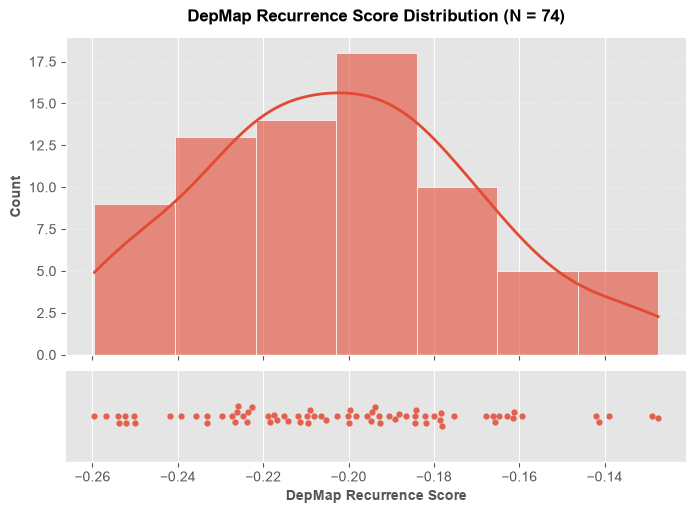

In [333]:
fig, (ax_hist, ax_swarm) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 5.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1], "hspace": 0.08},
)

sns.histplot(
    score,
    bins="fd",
    kde=True,
    ax=ax_hist,
    edgecolor="white",
    alpha=0.6,
    line_kws={"linewidth": 2},
)

ax_hist.set_ylabel("Count", fontsize=10, fontweight="bold")
ax_hist.set_title(
    f"DepMap Recurrence Score Distribution (N = {len(score)})",
    fontweight="bold",
    fontsize=12,
    pad=12,
)
ax_hist.grid(True, linestyle=":", alpha=0.5, axis="y")

sns.swarmplot(
    x=score,
    ax=ax_swarm,
    size=4.5,
    alpha=0.85,
)

ax_swarm.set_xlabel("DepMap Recurrence Score", fontsize=10, fontweight="bold")

sns.despine(ax=ax_hist)
sns.despine(ax=ax_swarm, left=True)
ax_swarm.set_yticks([])

plt.savefig(
    "../figures/depmap_glioma_recurrence_score_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

- `depmap_glioma_recurrence_score_distribution.png` saved to `/figures` directory

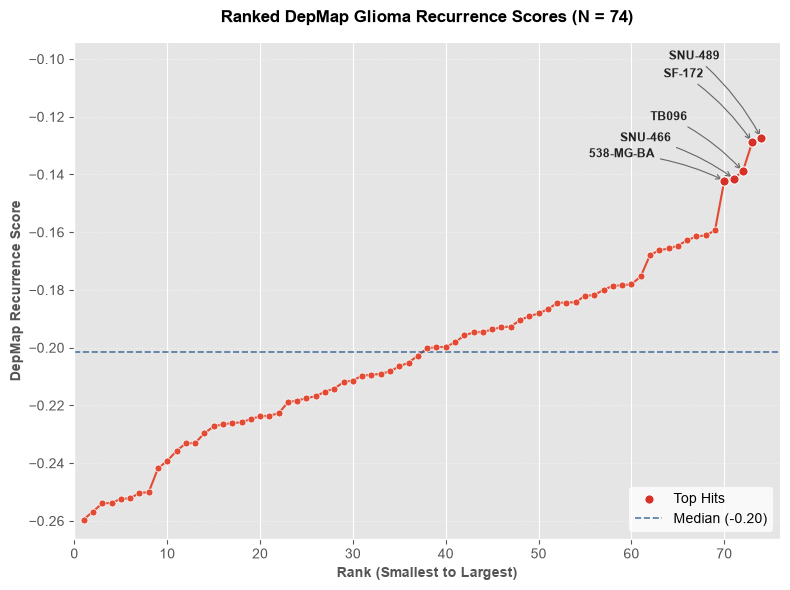

In [334]:
sorted_score = score.sort_values()
sorted_scores = sorted_score.to_numpy()
sorted_names = sorted_score.index
ranks = np.arange(1, len(sorted_scores) + 1)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(ranks, sorted_scores, linewidth=1.5, zorder=2)

ax.scatter(
    ranks[:-5],
    sorted_scores[:-5],
    edgecolor="white",
    s=25,
    linewidth=0.5,
    zorder=3,
)

ax.scatter(
    ranks[-5:],
    sorted_scores[-5:],
    color="#d73027",
    edgecolor="white",
    s=45,
    linewidth=0.8,
    zorder=4,
    label="Top Hits",
)

median_val = float(np.median(sorted_scores))
ax.axhline(
    median_val,
    color="#2b5c8f",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label=f"Median ({median_val:.2f})",
)

sorted_scores_min = float(sorted_scores.min())
sorted_scores_max = float(sorted_scores.max())

score_range = sorted_scores_max - sorted_scores_min
ax.set_ylim(
    sorted_scores_min - (score_range * 0.05),
    sorted_scores_max + (score_range * 0.25),
)

n_labels = 5
top_indices = np.arange(len(sorted_scores) - n_labels, len(sorted_scores))

label_offsets = [
    (-50, 15),
    (-45, 25),
    (-40, 35),
    (-35, 45),
    (-30, 55),
]

for i, (dx, dy) in zip(top_indices, label_offsets):
    ax.annotate(
        sorted_names[i],
        xy=(ranks[i], sorted_scores[i]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8.5,
        fontweight="bold",
        color="#222222",
        ha="right",
        va="bottom",
        arrowprops=dict(
            arrowstyle="->",
            color="#666666",
            linewidth=0.8,
            connectionstyle="arc3,rad=-0.1",
        ),
    )

ax.set_title(
    f"Ranked DepMap Glioma Recurrence Scores (N = {len(sorted_scores)})",
    fontweight="bold",
    fontsize=12,
    pad=15,
)

ax.set_xlabel("Rank (Smallest to Largest)", fontsize=10, fontweight="bold")
ax.set_ylabel("DepMap Recurrence Score", fontsize=10, fontweight="bold")

ax.grid(True, linestyle=":", alpha=0.6, axis="y")
ax.set_xlim(0, len(sorted_scores) + 2)

ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

sns.despine(ax=ax)
plt.tight_layout()

plt.savefig(
    "../figures/depmap_glioma_recurrence_score_ranked.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

- `gdsc_glioma_recurrence_score_ranked.png` saved to `/figures` directory

## 7. Preparing to create GDSC microarray Recurrence Score
- gdsc_depmap_cell_line_mapping.xlsx
    - CELL_LINE_NAME
    - GDSC_ID
    - DEPMAP_MODEL_ID
    - GDSC_EXPRESSION_AVAILABLE
    - DEPMAP_RNASEQ_AVAILABLE
- checking signature genes in GDSC expression

In [335]:
gdsc_depmap_glioma_exp = gdsc_glioma_exp.loc[gdsc_glioma_exp.index.isin(depmap_glioma_exp.index)].copy()

In [336]:
glioma_cell_line_master.head()

,STRIPPED_CELL_LINE_NAME,DEPMAP_ID,GDSC_COSMIC_ID,SANGER_MODEL_ID,CCLE_NAME,CTRPV2_NAME,DEPMAP_MODEL_ID_ALIAS,OncotreeLineage,OncotreePrimaryDisease,GDSC1_AVAILABLE,GDSC2_AVAILABLE,CTD2_AVAILABLE,CTRPV2_AVAILABLE,PRISM_AVAILABLE,PRISM_HAS_MEASUREMENTS,PRISM_NONMISSING_MEASUREMENTS,GDSC_EXPRESSION_AVAILABLE,DEPMAP_EXPRESSION_AVAILABLE,NOTES
CELL_LINE_NAME,,,,,,,,,,,,,,,,,,,
GOS-3,GOS3,ACH-000027,NaN,NaN,GOS3_CENTRAL_NERVOUS_SYSTEM,GOS3,NaN,CNS/Brain,Adult-Type Diffuse Glioma,False,False,True,True,True,True,1408,False,True,
U343,U343,ACH-000036,NaN,NaN,U343_CENTRAL_NERVOUS_SYSTEM,NaN,NaN,CNS/Brain,Adult-Type Diffuse Glioma,False,False,False,False,True,True,190,False,True,
U-118 MG,U118MG,ACH-000040,687588.0,SIDM01193,U118MG_CENTRAL_NERVOUS_SYSTEM,U118MG,NaN,CNS/Brain,Adult-Type Diffuse Glioma,True,True,True,True,True,True,1398,True,True,
Hs 683,HS683,ACH-000067,1240150.0,SIDM00666,HS683_CENTRAL_NERVOUS_SYSTEM,HS683,NaN,CNS/Brain,Adult-Type Diffuse Glioma,True,True,True,True,True,True,190,True,True,
U-87 MG,U87MG,ACH-000075,687590.0,SIDM01189,U87MG_CENTRAL_NERVOUS_SYSTEM,U87MG,NaN,CNS/Brain,Adult-Type Diffuse Glioma,True,True,True,True,True,True,190,True,True,


In [337]:
gdsc_depmap_cell_line_mapping = glioma_cell_line_master[glioma_cell_line_master["DEPMAP_ID"].isin(gdsc_glioma_exp.index)].copy()

In [338]:
len(gdsc_depmap_cell_line_mapping)

52

In [339]:
print("Signature genes available in GDSC:", int(gdsc_glioma_exp.columns.isin(consensus_genes).sum()))

Signature genes available in GDSC: 250


## 8. Cross-platform validation of GDSC microarray and DepMap RNA-seq

In [340]:
GDSC_genes = gdsc_glioma_exp.columns

In [341]:
glass_gdsc_depmap_common_gene_universe = pd.Index(GLASS_genes.intersection(DepMap_genes).intersection(GDSC_genes))

In [342]:
glass_gdsc_depmap_common_gene_universe_documentation = pd.DataFrame(
    {
        "Metric": [
            "GLASS filtered genes",
            "GDSC genes",
            "Common genes",
            "Signature UP genes",
            "Signature DOWN genes available"
        ],
        "Value": [
            GLASS_genes.nunique(),
            DepMap_genes.nunique(),
            glass_gdsc_depmap_common_gene_universe.nunique(),
            glass_gdsc_depmap_common_gene_universe.intersection(consensus_UP_genes).nunique(),
            glass_gdsc_depmap_common_gene_universe.intersection(consensus_DOWN_genes).nunique()
        ],
    }
)

In [343]:
glass_gdsc_depmap_common_gene_universe_documentation

,Metric,Value
0,GLASS filtered genes,17789
1,GDSC genes,60649
2,Common genes,13004
3,Signature UP genes,152
4,Signature DOWN genes available,90


In [344]:
glass_gdsc_depmap_common_gene_universe_documentation.to_csv(
    "../results/cross_platform/glass_gdsc_depmap_common_gene_universe_documentation.csv",
    sep = "\t",
    index = False
)

In [345]:
with open(
    "../results/cross_platform/glass_depmap_common_gene_universe.txt",
    "w",
) as f:
    f.write("\n".join(glass_depmap_common_gene_universe.astype(str)))

- `glass_gdsc_depmap_common_gene_universe.txt` and `glass_gdsc_depmap_common_gene_universe_documentation.csv` saved to `/results/cross_platform` directory

In [346]:
gdsc_depmap_common_signature_genes = pd.Index(glass_gdsc_depmap_common_gene_universe.intersection(consensus_genes))

In [347]:
depmap_glioma_exp_common = depmap_glioma_exp.loc[:, depmap_glioma_exp.columns.isin(gdsc_depmap_common_signature_genes)
].copy()

In [348]:
gdsc_glioma_exp_common = gdsc_glioma_exp.loc[:, gdsc_glioma_exp.columns.isin(gdsc_depmap_common_signature_genes)
].copy()

In [349]:
UP_GDSC_DepMap = pd.Index(glass_gdsc_depmap_common_gene_universe.intersection(consensus_UP_genes))
DOWN_GDSC_DepMap = pd.Index(glass_gdsc_depmap_common_gene_universe.intersection(consensus_DOWN_genes))

In [350]:
glass_crossplatform_recurrence_score_gdsc = calculate_recurrence_score(gdsc_glioma_exp_common.T, UP_GDSC_DepMap, DOWN_GDSC_DepMap)
glass_crossplatform_recurrence_score_gdsc = glass_crossplatform_recurrence_score_gdsc.drop(columns=["UP_SCORE", "DOWN_SCORE"])
glass_crossplatform_recurrence_score_gdsc = glass_crossplatform_recurrence_score_gdsc.rename(columns={"RECURRENCE_SCORE": "GDSC_RECURRENCE_SCORE_CROSSPLATFORM"})

glass_crossplatform_recurrence_score_depmap = calculate_recurrence_score(depmap_glioma_exp_common.T, UP_GDSC_DepMap, DOWN_GDSC_DepMap)
glass_crossplatform_recurrence_score_depmap = glass_crossplatform_recurrence_score_depmap.drop(columns=["UP_SCORE", "DOWN_SCORE"])
glass_crossplatform_recurrence_score_depmap = glass_crossplatform_recurrence_score_depmap.rename(columns={"RECURRENCE_SCORE": "DEPMAP_RECURRENCE_SCORE_CROSSPLATFORM"})

In [351]:
glass_crossplatform_recurrence_score_gdsc.head()

,GDSC_RECURRENCE_SCORE_CROSSPLATFORM
ModelID,
ACH-000883,-0.169298
ACH-000437,-0.196491
ACH-001016,-0.087281
ACH-002257,-0.241082
ACH-000098,-0.097661


In [352]:
depmap_gdsc_glioma_recurrence_scores = glass_crossplatform_recurrence_score_gdsc.merge(
    glass_crossplatform_recurrence_score_depmap,
    on="ModelID",
    how="inner"
)

In [353]:
gdsc_exp_common = (
    gdsc_glioma_exp_common.loc[
        gdsc_glioma_exp_common.index.isin(
            depmap_gdsc_glioma_recurrence_scores.index
        )
    ].copy()
)

depmap_exp_common = (
    depmap_glioma_exp_common.loc[
        depmap_glioma_exp_common.index.isin(
            depmap_gdsc_glioma_recurrence_scores.index
        )
    ].copy()
)

In [354]:
up_genes_present = (
    pd.Index(UP_GDSC_DepMap)
    .intersection(depmap_exp_common.columns)
    .intersection(gdsc_exp_common.columns)
)

depmap_up_present = depmap_exp_common.loc[:, up_genes_present].notna()
gdsc_up_present = gdsc_exp_common.loc[:, up_genes_present].notna()

n_up_genes = (
    (depmap_up_present & gdsc_up_present)
    .sum(axis=1)
)

n_up_genes.index.name = "DEPMAP_ID"

depmap_gdsc_glioma_recurrence_scores["N_UP_GENES"] = (
    n_up_genes.reindex(
        depmap_gdsc_glioma_recurrence_scores.index
    )
)

down_genes_present = (
    pd.Index(DOWN_GDSC_DepMap)
    .intersection(depmap_exp_common.columns)
    .intersection(gdsc_exp_common.columns)
)

depmap_down_present = depmap_exp_common.loc[:, down_genes_present].notna()
gdsc_down_present = gdsc_exp_common.loc[:, down_genes_present].notna()

n_down_genes = (
    (depmap_down_present & gdsc_down_present)
    .sum(axis=1)
)

n_down_genes.index.name = "DEPMAP_ID"

depmap_gdsc_glioma_recurrence_scores["N_DOWN_GENES"] = (
    n_down_genes.reindex(
        depmap_gdsc_glioma_recurrence_scores.index
    )
)

In [355]:
depmap_gdsc_glioma_recurrence_scores.head()

,GDSC_RECURRENCE_SCORE_CROSSPLATFORM,DEPMAP_RECURRENCE_SCORE_CROSSPLATFORM,N_UP_GENES,N_DOWN_GENES
ModelID,,,,
ACH-000883,-0.169298,-0.196491,152,90
ACH-000437,-0.196491,-0.157383,152,90
ACH-001016,-0.087281,-0.157675,152,90
ACH-000098,-0.097661,-0.160526,152,90
ACH-000102,-0.193640,-0.195906,152,90


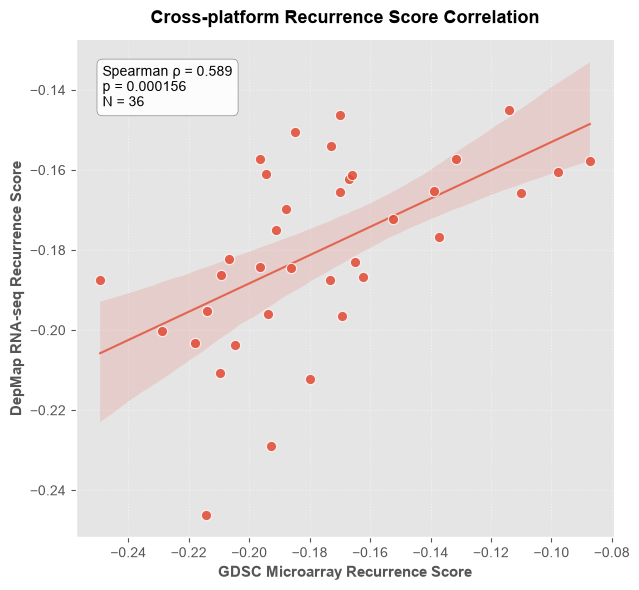

In [356]:
plot_data = (
    depmap_gdsc_glioma_recurrence_scores[
        [
            "GDSC_RECURRENCE_SCORE_CROSSPLATFORM",
            "DEPMAP_RECURRENCE_SCORE_CROSSPLATFORM",
        ]
    ]
    .dropna()
)

x = plot_data["GDSC_RECURRENCE_SCORE_CROSSPLATFORM"]
y = plot_data["DEPMAP_RECURRENCE_SCORE_CROSSPLATFORM"]

rho, p_value = spearmanr(x, y)
n = len(plot_data)

fig, ax = plt.subplots(figsize=(6.5, 6))

ax.scatter(
    x,
    y,
    s=55,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85,
    zorder=3,
)

sns.regplot(
    x=x,
    y=y,
    scatter=False,
    ax=ax,
    line_kws={
        "linewidth": 1.5,
        "alpha": 0.8,
    },
)

stats_text = (
    f"Spearman ρ = {float(rho):.3f}\n"
    f"p = {format_pvalue(p_value)}\n"
    f"N = {n}"
)
ax.text(
    0.05,
    0.95,
    stats_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9,
    ),
)
ax.set_xlabel(
    "GDSC Microarray Recurrence Score",
    fontsize=11,
    fontweight="bold",
)
ax.set_ylabel(
    "DepMap RNA-seq Recurrence Score",
    fontsize=11,
    fontweight="bold",
)
ax.set_title(
    "Cross-platform Recurrence Score Correlation",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
    zorder=0,
)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(
    "../figures/gdsc_vs_depmap_recurrence_score",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

- `glass_crossplatform_recurrence_score_check.xlsx` saved to `/figures/` directory

In [357]:
glass_crossplatform_recurrence_score = calculate_recurrence_score(glass_idhwt_gbm_primary_R1_TPM_filtered, UP_GDSC_DepMap, DOWN_GDSC_DepMap)

In [358]:
glass_crossplatform_recurrence_score.iloc[:5, :5]

,UP_SCORE,DOWN_SCORE,RECURRENCE_SCORE
GLSS-SM-R109-TP,0.407707,0.655074,-0.247367
GLSS-19-0274-TP,0.429723,0.507738,-0.078015
GLSS-CU-R005-TP,0.348835,0.598411,-0.249576
GLSS-SM-R060-TP,0.411103,0.644235,-0.233132
GLSS-LU-00C2-TP,0.327331,0.478289,-0.150958


In [359]:
new_scores = glass_crossplatform_recurrence_score.copy()

new_scores.index.name = "SAMPLE_ID"
new_scores = new_scores.reset_index()

In [360]:
comparison = glass_recurrence_scores_full_cohort[
    ["PATIENT_ID", "SAMPLE_ID", "SAMPLE_TYPE", "RECURRENCE_SCORE"]
].merge(
    new_scores[["SAMPLE_ID", "UP_SCORE", "DOWN_SCORE", "RECURRENCE_SCORE"]],
    on="SAMPLE_ID",
    how="inner",
    suffixes=("_OLD", "_NEW"),
)

In [361]:
comparison["SCORE_CHANGE"] = (comparison["RECURRENCE_SCORE_NEW"] - comparison["RECURRENCE_SCORE_OLD"])

comparison["SCORE_INCREASED"] = (comparison["SCORE_CHANGE"] > 0)

comparison["SCORE_DECREASED"] = (comparison["SCORE_CHANGE"] < 0)

comparison["SCORE_UNCHANGED"] = (comparison["SCORE_CHANGE"] == 0)

In [362]:
corr_data = comparison.dropna(
    subset=["RECURRENCE_SCORE_OLD", "RECURRENCE_SCORE_NEW"]
)

rho, p_value = spearmanr(
    corr_data["RECURRENCE_SCORE_OLD"],
    corr_data["RECURRENCE_SCORE_NEW"],
)

In [363]:
summary = pd.DataFrame(
    {
        "Metric": [
            "Matched samples",
            "Spearman correlation",
            "Spearman p-value",
            "Median OLD recurrence score",
            "Median NEW recurrence score",
            "Median score change (NEW - OLD)",
            "Fraction increased",
            "Fraction decreased",
            "Fraction unchanged",
        ],
        "Value": [
            len(corr_data),
            float(rho),
            float(p_value),
            corr_data["RECURRENCE_SCORE_OLD"].median(),
            corr_data["RECURRENCE_SCORE_NEW"].median(),
            corr_data["SCORE_CHANGE"].median(),
            corr_data["SCORE_INCREASED"].mean(),
            corr_data["SCORE_DECREASED"].mean(),
            corr_data["SCORE_UNCHANGED"].mean(),
        ],
    }
)

In [364]:
r1_primary = (
    comparison[
        comparison["SAMPLE_TYPE"].isin(["Tumor Primary", "First Recurrence"])
    ]
    .pivot(
        index="PATIENT_ID",
        columns="SAMPLE_TYPE",
        values=["RECURRENCE_SCORE_OLD", "RECURRENCE_SCORE_NEW"],
    )
)

r1_primary["OLD_DIFF"] = (
    r1_primary[("RECURRENCE_SCORE_OLD", "First Recurrence")]
    - r1_primary[("RECURRENCE_SCORE_OLD", "Tumor Primary")]
)

r1_primary["NEW_DIFF"] = (
    r1_primary[("RECURRENCE_SCORE_NEW", "First Recurrence")]
    - r1_primary[("RECURRENCE_SCORE_NEW", "Tumor Primary")]
)

In [365]:
old_test = wilcoxon(r1_primary["OLD_DIFF"].dropna())
new_test = wilcoxon(r1_primary["NEW_DIFF"].dropna())

In [366]:
r1_summary = pd.DataFrame(
    {
        "Metric": [
            "Paired patients",
            "OLD median R1 - Primary",
            "NEW median R1 - Primary",
            "OLD fraction R1 > Primary",
            "NEW fraction R1 > Primary",
            "OLD Wilcoxon p-value",
            "NEW Wilcoxon p-value",
        ],
        "Value": [
            len(r1_primary),
            r1_primary["OLD_DIFF"].median(),
            r1_primary["NEW_DIFF"].median(),
            (r1_primary["OLD_DIFF"] > 0).mean(),
            (r1_primary["NEW_DIFF"] > 0).mean(),
            float(old_test.pvalue),
            float(new_test.pvalue),
        ],
    }
)

In [367]:
output_file = "../results/cross_platform/glass_crossplatform_recurrence_score_check.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False,
    )
    r1_summary.to_excel(
        writer,
        sheet_name="R1_vs_Primary",
        index=False,
    )
    comparison.to_excel(
        writer,
        sheet_name="Score_Comparison",
        index=False,
    )
    r1_primary.to_excel(
        writer,
        sheet_name="R1_Primary_Paired",
    )

- `glass_crossplatform_recurrence_score_check.xlsx` saved to `/results/cross_platform` directory

## 9. Final check of sensitivity data availability

In [368]:
glioma_drug_data_availability = glioma_cell_line_master[["GDSC1_AVAILABLE", "GDSC2_AVAILABLE", "CTD2_AVAILABLE", "CTRPV2_AVAILABLE", "PRISM_AVAILABLE"]].copy()
glioma_drug_data_availability = glioma_drug_data_availability.merge(depmap_glioma_recurrence_scores["DEPMAP_RECURRENCE_SCORE"],
                                    on = "CELL_LINE_NAME",
                                    how = "outer")
col_order = ["DEPMAP_RECURRENCE_SCORE", "GDSC1_AVAILABLE", "GDSC2_AVAILABLE", "CTD2_AVAILABLE", "CTRPV2_AVAILABLE", "PRISM_AVAILABLE"]
glioma_drug_data_availability = glioma_drug_data_availability[col_order]

In [369]:
glioma_drug_data_availability.head()

,DEPMAP_RECURRENCE_SCORE,GDSC1_AVAILABLE,GDSC2_AVAILABLE,CTD2_AVAILABLE,CTRPV2_AVAILABLE,PRISM_AVAILABLE
CELL_LINE_NAME,,,,,,
1321N1,NaN,False,False,False,False,False
170-MG-BA,-0.161424,False,False,False,False,False
42-MG-BA,-0.178365,True,True,True,True,True
538-MG-BA,-0.142115,False,False,False,False,False
8-MG-BA,-0.166265,True,True,True,True,True


In [370]:
glioma_drug_data_availability.to_excel(
    "../results/data_availability/glioma_drug_data_availability.xlsx",
    index=True
)

- `glioma_drug_data_availability.xlsx` saved to `/results/data_availability` directory

In [371]:
gdsc_sensitivity_available = (
    glioma_cell_line_master["GDSC1_AVAILABLE"]
    | glioma_cell_line_master["GDSC2_AVAILABLE"]
)

depmap_sensitivity_available = (
    glioma_cell_line_master["CTD2_AVAILABLE"]
    | glioma_cell_line_master["CTRPV2_AVAILABLE"]
    | glioma_cell_line_master["PRISM_AVAILABLE"]
)

gdsc_complete = (
    glioma_cell_line_master["GDSC_EXPRESSION_AVAILABLE"]
    & gdsc_sensitivity_available
)

depmap_complete = (
    glioma_cell_line_master["DEPMAP_EXPRESSION_AVAILABLE"]
    & depmap_sensitivity_available
)

gdsc_depmap_complete = gdsc_complete & depmap_complete

summary = pd.DataFrame({
    "Expression_available": [
        glioma_cell_line_master["GDSC_EXPRESSION_AVAILABLE"].sum(),
        glioma_cell_line_master["DEPMAP_EXPRESSION_AVAILABLE"].sum(),
    ],
    "Sensitivity_available": [
        gdsc_sensitivity_available.sum(),
        depmap_sensitivity_available.sum(),
    ],
    "Expression_and_sensitivity": [
        gdsc_complete.sum(),
        depmap_complete.sum(),
    ],
}, index=["GDSC", "DepMap"])

summary["Sensitivity_fraction_among_expression"] = (
    summary["Expression_and_sensitivity"]
    / summary["Expression_available"]
)

summary["N_COMMON_COMPLETE"] = int(gdsc_depmap_complete.sum())

summary

,Expression_available,Sensitivity_available,Expression_and_sensitivity,Sensitivity_fraction_among_expression,N_COMMON_COMPLETE
GDSC,52,51,50,0.961538,32
DepMap,74,51,51,0.689189,32


In [372]:
def drug_response_qc(df, dataset_name):
    return {
        "DATASET": dataset_name,
        "N_CELL_LINES": df.shape[0],
        "N_DRUGS": df.shape[1],
        "MIN_AUC": df.min().min(),
        "MEDIAN_AUC": df.stack().median(),
        "MAX_AUC": df.max().max(),
        "N_MISSING": df.isna().sum().sum(),
        "PERCENT_MISSING": df.isna().mean().mean() * 100,
    }

In [373]:
gdsc1_glioma = gdsc1.loc[
    gdsc1.index.isin(glioma_model_ids)
].copy()

gdsc2_glioma = gdsc2.loc[
    gdsc2.index.isin(glioma_model_ids)
].copy()

ctd2_glioma = ctd2.loc[
    ctd2.index.isin(glioma_model_ids)
].copy()

ctrpv2_glioma = ctrpv2.loc[
    ctrpv2.index.isin(glioma_model_ids)
].copy()

prism_glioma = prism.loc[
    prism.index.isin(glioma_model_ids)
].copy()

In [374]:
qc_results = [
    drug_response_qc(gdsc1_glioma, "GDSC1"),
    drug_response_qc(gdsc2_glioma, "GDSC2"),
    drug_response_qc(ctd2_glioma, "CTD2"),
    drug_response_qc(ctrpv2_glioma, "CTRPv2"),
    drug_response_qc(prism_glioma, "PRISM"),
]

sensitivity_qc = pd.DataFrame(qc_results)

sensitivity_qc

,DATASET,N_CELL_LINES,N_DRUGS,MIN_AUC,MEDIAN_AUC,MAX_AUC,N_MISSING,PERCENT_MISSING
0,GDSC1,50,316,0.032263,0.895180,1.000,1597,10.107595
1,GDSC2,51,286,0.017723,0.913346,1.000,2873,19.696970
2,CTD2,42,545,0.035965,0.915818,1.000,4334,18.934032
3,CTRPv2,44,481,0.535740,13.898000,19.387,3896,18.408618
4,PRISM,46,1482,0.021643,0.926168,1.000,21994,32.262512


In [375]:
output_file = "../results/qc/cell_lines_sensitivity_QC.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    summary.to_excel(
        writer,
        sheet_name="Summary",
        index=True,
    )
    sensitivity_qc.to_excel(
        writer,
        sheet_name="Drug Sensitivity Quality Check",
        index=False
    )

- `cell_lines_sensitivity_QC.xlsx` exported to `/results/qc` directory

# **Pharmacogenomic analysis of drug sensitivities associated with the glioblastoma recurrence program**

## 1. Define the final Step 5 analysis cohort
- Cell lines included in PRISM discovery analysis:
    - has DEPMAP_RECURRENCE_SCORE
    - has PRISM drug-response data
    - OncotreePrimaryDisease == Adult-Type Diffuse Glioma
- prism_recurrence_analysis_cohort
    - ModelID
    - CELL_LINE_NAME
    - OncotreePrimaryDisease
    - DEPMAP_RECURRENCE_SCORE
    - PRISM_AVAILABLE

In [376]:
prism_recurrence_analysis_cohort = glioma_cell_line_master[["DEPMAP_ID", "OncotreePrimaryDisease", "PRISM_AVAILABLE"]].copy()

prism_recurrence_analysis_cohort = prism_recurrence_analysis_cohort.merge(depmap_glioma_recurrence_scores["DEPMAP_RECURRENCE_SCORE"],
                                    on = "CELL_LINE_NAME",
                                    how = "outer")

In [377]:
prism_recurrence_analysis_cohort.head()

,DEPMAP_ID,OncotreePrimaryDisease,PRISM_AVAILABLE,DEPMAP_RECURRENCE_SCORE
CELL_LINE_NAME,,,,
1321N1,ACH-001000,Adult-Type Diffuse Glioma,False,NaN
170-MG-BA,ACH-002680,Adult-Type Diffuse Glioma,False,-0.161424
42-MG-BA,ACH-000323,Adult-Type Diffuse Glioma,True,-0.178365
538-MG-BA,ACH-002681,Adult-Type Diffuse Glioma,False,-0.142115
8-MG-BA,ACH-000137,Adult-Type Diffuse Glioma,True,-0.166265


In [378]:
prism_avail_mask = prism_recurrence_analysis_cohort["PRISM_AVAILABLE"].fillna(False).astype(bool)

prism_recurrence_analysis_cohort_summary = pd.DataFrame({
    "N_PRISM_ALL_GLIOMA": [
        prism_recurrence_analysis_cohort.loc[prism_avail_mask, "DEPMAP_ID"].nunique()
    ],
    "N_PRISM_ADULT_DIFFUSE_GLIOMA": [
        prism_recurrence_analysis_cohort.loc[
            prism_avail_mask & (prism_recurrence_analysis_cohort["OncotreePrimaryDisease"] == "Adult-Type Diffuse Glioma"),
            "DEPMAP_ID"
        ].nunique()
    ],
})

prism_recurrence_analysis_cohort_summary

,N_PRISM_ALL_GLIOMA,N_PRISM_ADULT_DIFFUSE_GLIOMA
0,46,44


In [379]:
prism_recurrence_analysis_cohort = prism_recurrence_analysis_cohort.loc[
    prism_recurrence_analysis_cohort["PRISM_AVAILABLE"]
    & (prism_recurrence_analysis_cohort["OncotreePrimaryDisease"] == "Adult-Type Diffuse Glioma")
    & prism_recurrence_analysis_cohort["DEPMAP_RECURRENCE_SCORE"].notna()
].copy()

In [380]:
with pd.ExcelWriter("../results/PRISM/prism_recurrence_analysis_cohort.xlsx") as writer:
    prism_recurrence_analysis_cohort_summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    prism_recurrence_analysis_cohort.to_excel(
        writer,
        sheet_name="PRISM RA Cohort",
        index=True
    )

- `prism_recurrence_analysis_cohort.xlsx` exported to `/results/PRISM` directory

## 2. Prepare PRISM drug-response data
- prism_drug_coverage_QC
    - N_TOTAL
    - N_WITH_AUC
    - N_MISSING
    - PERCENT_MISSING
    - MIN_AUC
    - MEDIAN_AUC
    - MAX_AUC

In [381]:
def drug_response_qc_per_compound(df, dataset_name):
    qc = pd.DataFrame({
        "DATASET": dataset_name,
        "N_CELL_LINES_TOTAL": df.shape[0],
        "N_CELL_LINES_AVAILABLE": df.notna().sum(axis=0),
        "N_MISSING": df.isna().sum(axis=0),
        "PERCENT_MISSING": df.isna().mean(axis=0) * 100,
        "MIN_AUC": df.min(axis=0),
        "MEDIAN_AUC": df.median(axis=0),
        "MAX_AUC": df.max(axis=0),
    })

    qc.index.name = "COMPOUND"

    return qc

In [382]:
prism_cohort = prism.loc[
    prism.index.isin(prism_recurrence_analysis_cohort["DEPMAP_ID"])
].copy()

In [383]:
prism_drug_coverage_QC = drug_response_qc_per_compound(prism_cohort, "PRISM")

In [384]:
prism_drug_coverage_QC.head()

,DATASET,N_CELL_LINES_TOTAL,N_CELL_LINES_AVAILABLE,N_MISSING,PERCENT_MISSING,MIN_AUC,MEDIAN_AUC,MAX_AUC
COMPOUND,,,,,,,,
(+)-CAMPTOTHECIN (BRD:BRD-K37890730-001-15-1),PRISM,44,30,14,31.818182,0.060965,0.327112,0.901369
1-AZAKENPAULLONE (BRD:BRD-K03273112-001-01-8),PRISM,44,30,14,31.818182,0.856010,0.910309,1.000000
1-NAPHTHYL-PP1 (BRD:BRD-K29542628-001-03-9),PRISM,44,30,14,31.818182,0.681012,0.868215,0.991522
1-PHENYLBIGUANIDE (BRD:BRD-K31491153-003-05-9),PRISM,44,26,18,40.909091,0.764956,0.976171,0.991963
10-DEACETYLBACCATIN (BRD:BRD-K96631475-001-02-4),PRISM,44,30,14,31.818182,0.717816,0.863772,0.990626


In [385]:
prism_drug_coverage_QC.to_excel(
    "../results/PRISM/prism_drug_coverage_QC.xlsx",
    index=True
)

- `prism_drug_coverage_QC.xlsx` exported to `/results/PRISM` directory

## 3. Perform the primary PRISM pharmacogenomic screen
- Spearman correlation between DEPMAP_RECURRENCE_SCORE and PRISM_AUC
- prism_recurrence_drug_screen
    - DRUG
    - N
    - SPEARMAN_RHO
    - P_VALUE
    - FDR

In [386]:
recurrence_score = (
    prism_recurrence_analysis_cohort
    .set_index("DEPMAP_ID")["DEPMAP_RECURRENCE_SCORE"]
    .reindex(prism_cohort.index)
)

eligible_drugs = prism_drug_coverage_QC.index[
    prism_drug_coverage_QC["N_CELL_LINES_AVAILABLE"] >= 20
]

In [387]:
results = []
for drug in eligible_drugs:
    valid = (recurrence_score.notna() & prism_cohort[drug].notna())
    recurrence_values = recurrence_score.loc[valid]
    auc_values = prism_cohort.loc[valid, drug]
    n = valid.sum()
    if n < 20 or recurrence_values.nunique() < 2 or auc_values.nunique() < 2:
        rho, p_value = np.nan, np.nan
    else:
        rho, p_value = spearmanr(recurrence_values, auc_values)
    results.append({
        "DRUG": drug,
        "N": n,
        "SPEARMAN_RHO": rho,
        "P_VALUE": p_value,
    })

prism_recurrence_drug_screen = pd.DataFrame(results)

In [388]:
tested = (prism_recurrence_drug_screen["P_VALUE"].notna())

prism_recurrence_drug_screen.loc[tested, "FDR"] = multipletests(
    prism_recurrence_drug_screen.loc[tested, "P_VALUE"],
    method="fdr_bh",
)[1]

In [389]:
prism_recurrence_drug_screen["CANDIDATE"] = (
    (prism_recurrence_drug_screen["N"] >= 20)
    & (prism_recurrence_drug_screen["SPEARMAN_RHO"] <= -0.30)
    & (prism_recurrence_drug_screen["FDR"] < 0.10)
)

In [390]:
prism_recurrence_drug_screen = prism_recurrence_drug_screen.sort_values(
    "SPEARMAN_RHO"
)

In [391]:
prism_recurrence_drug_screen["BRD_ID"] = (
    prism_recurrence_drug_screen["DRUG"]
    .str.extract(r"\((BRD:.*?)\)", expand=False)
    .str.replace(r"^BRD:", "", regex=True)
)

prism_recurrence_drug_screen["DRUG"] = (
    prism_recurrence_drug_screen["DRUG"]
    .str.split(" (", n=1, regex=False)
    .str[0]
)
col_order = ["DRUG", "BRD_ID", "N", "SPEARMAN_RHO", "P_VALUE", "FDR", "CANDIDATE"]
prism_recurrence_drug_screen = prism_recurrence_drug_screen[col_order]

In [392]:
prism_recurrence_drug_screen.head()

,DRUG,BRD_ID,N,SPEARMAN_RHO,P_VALUE,FDR,CANDIDATE
609,GS-39783,BRD-K75478907-001-02-3,23,-0.611552,0.001931,0.350796,False
87,ALVESPIMYCIN,BRD-K83988098-001-02-0,43,-0.605557,0.000017,0.023769,True
4,10-DEACETYLBACCATIN,BRD-K96631475-001-02-4,30,-0.575973,0.000866,0.243787,False
451,DOCETAXEL,BRD-K30577245-001-05-0,43,-0.575657,0.000054,0.037816,True
962,PACLITAXEL,BRD-K62008436-001-23-9,43,-0.551495,0.000127,0.059350,True


In [393]:
prism_recurrence_drug_screen.to_excel(
    "../results/PRISM/prism_recurrence_drug_screen.xlsx",
    index=False,
)

- `prism_recurrence_drug_screen.xlsx` exported to `/results/PRISM` directory

## 4. Visualise PRISM screening results

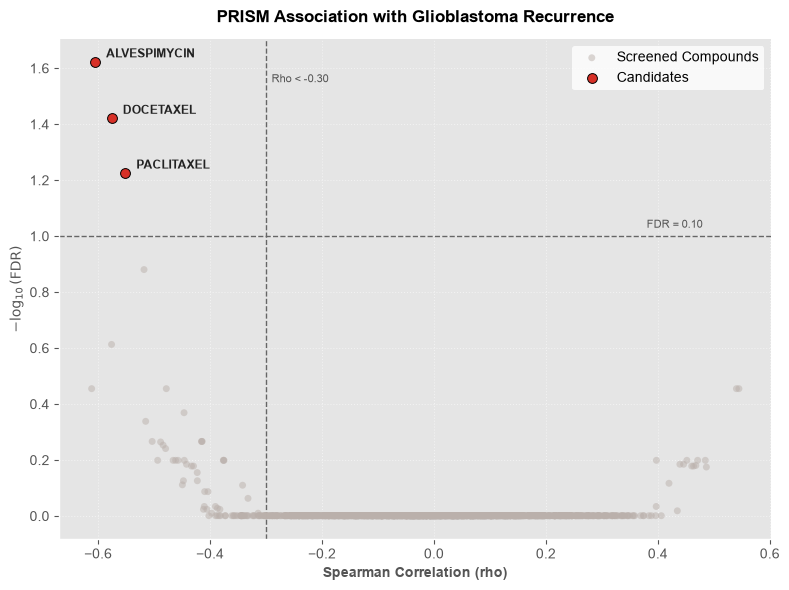

In [394]:
plot_df = prism_recurrence_drug_screen.dropna(
    subset=["SPEARMAN_RHO", "FDR"]
).copy()

plot_df["NEG_LOG10_FDR"] = -np.log10(plot_df["FDR"].clip(lower=1e-300))
candidate_df = plot_df[plot_df["CANDIDATE"]].copy()
top_candidates = candidate_df.sort_values("SPEARMAN_RHO").head(3)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    plot_df["SPEARMAN_RHO"],
    plot_df["NEG_LOG10_FDR"],
    color="#bab0ab",
    alpha=0.5,
    s=25,
    edgecolor="none",
    label="Screened Compounds",
    zorder=2,
)

ax.scatter(
    candidate_df["SPEARMAN_RHO"],
    candidate_df["NEG_LOG10_FDR"],
    color="#d73027",
    edgecolor="black",
    linewidth=0.7,
    s=50,
    label="Candidates",
    zorder=3,
)

for _, row in top_candidates.iterrows():
    clean_name = str(row["DRUG"]).split(" (")[0]
    ax.annotate(
        clean_name,
        (row["SPEARMAN_RHO"], row["NEG_LOG10_FDR"]),
        xytext=(8, 3),
        textcoords="offset points",
        fontsize=8.5,
        fontweight="bold",
        color="#222222",
    )

fdr_thresh = -np.log10(0.10)
ax.axvline(-0.30, linestyle="--", color="#666666", linewidth=1, zorder=1)
ax.axhline(fdr_thresh, linestyle="--", color="#666666", linewidth=1, zorder=1)

ax.text(-0.29, 1.55, "Rho < -0.30", fontsize=8, color="#555555")
ax.text(0.38, fdr_thresh + 0.03, "FDR = 0.10", fontsize=8, color="#555555")

ax.set_xlabel("Spearman Correlation (rho)", fontweight="bold", fontsize=10)
ax.set_ylabel(r"$-\log_{10}(\text{FDR})$", fontweight="bold", fontsize=10)
ax.set_title(
    "PRISM Association with Glioblastoma Recurrence",
    fontweight="bold",
    fontsize=12,
    pad=12,
)

ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

sns.despine(ax=ax)
plt.tight_layout()

plt.savefig("../figures/prism_recurrence_drug_screen.png", dpi=300, bbox_inches="tight")
plt.show()

In [395]:
prism_cohort.head()

,(+)-CAMPTOTHECIN (BRD:BRD-K37890730-001-15-1),1-AZAKENPAULLONE (BRD:BRD-K03273112-001-01-8),1-NAPHTHYL-PP1 (BRD:BRD-K29542628-001-03-9),1-PHENYLBIGUANIDE (BRD:BRD-K31491153-003-05-9),10-DEACETYLBACCATIN (BRD:BRD-K96631475-001-02-4),10-HYDROXYCAMPTOTHECIN (BRD:BRD-K63784565-001-06-2),AZD4547 (BRD:BRD-K28392481-001-05-1),12-O-TETRADECANOYLPHORBOL-13-ACETATE (BRD:BRD-K68552125-001-05-3),TANESPIMYCIN (BRD:BRD-K81473043-001-19-5),2'-MECCPA (BRD:BRD-K63932022-001-01-5),...,ZK-811752 (BRD:BRD-K91825936-001-01-2),ZK-93423 (BRD:BRD-K33882852-003-02-8),ZK-93426 (BRD:BRD-K68392338-003-02-0),ZLN005 (BRD:BRD-K73073971-001-01-7),ZM 447439 (BRD:BRD-K72703948-001-10-1),ZM-306416 (BRD:BRD-K41337261-001-03-0),ZOLANTIDINE (BRD:BRD-K08996725-332-01-7),ZOLMITRIPTAN (BRD:BRD-K54314721-001-10-2),SIROLIMUS (BRD:BRD-K84937637-001-09-9),TEMSIROLIMUS (BRD:BRD-K42898655-001-01-8)
ACH-000027,0.705806,0.981444,0.871238,0.972453,0.885546,0.428726,1.000000,1.0,0.886856,1.000000,...,0.899724,0.881097,0.997758,0.997308,0.954276,1.0,0.997546,0.990884,0.652816,0.549969
ACH-000036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676336,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.684939
ACH-000040,0.243679,0.984955,0.869594,0.981178,0.901915,0.167499,0.934131,1.0,0.821991,0.993357,...,1.000000,0.875656,0.884366,1.000000,0.915258,1.0,0.957643,0.945964,0.422183,0.504002
ACH-000067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.757590,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.653638
ACH-000075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.761486,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.593650


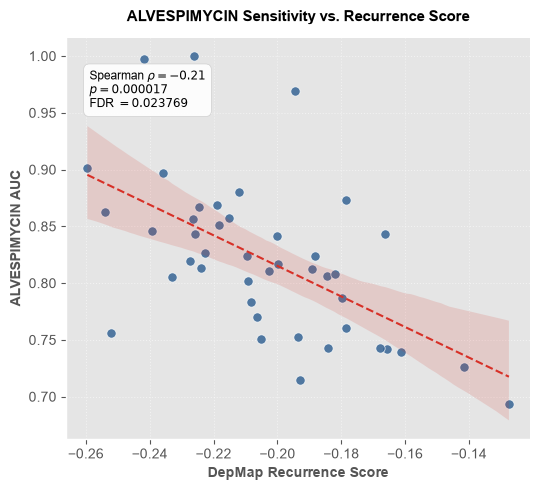

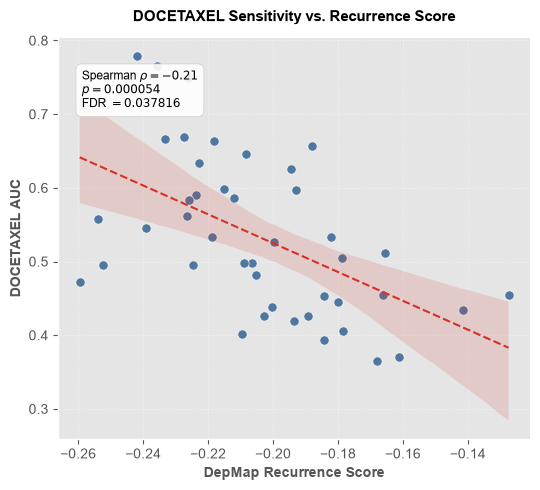

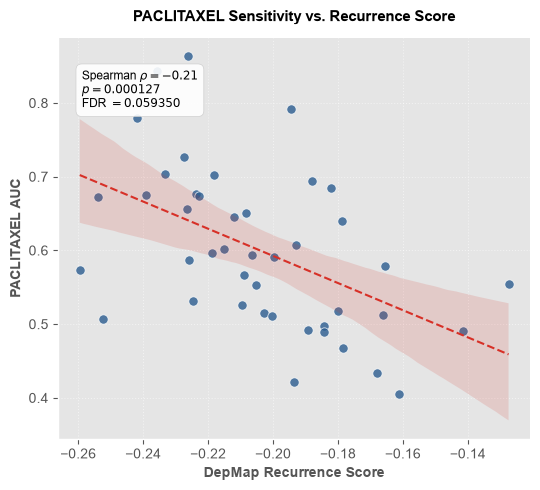

In [396]:
top_candidates = (
    prism_recurrence_drug_screen[prism_recurrence_drug_screen["CANDIDATE"]]
    .sort_values("SPEARMAN_RHO")
    .head(3)
)

for _, row in top_candidates.iterrows():
    drug_id = row["DRUG"]
    drug_id = f"{row['DRUG']} (BRD:{row['BRD_ID']})"
    p_val = row["P_VALUE"]
    fdr = row["FDR"]

    valid_mask = recurrence_score.notna() & prism_cohort[drug_id].notna()
    x_vals = recurrence_score.loc[valid_mask]
    y_vals = prism_cohort.loc[valid_mask, drug_id]

    clean_display_name = str(drug_id).split(" (")[0]

    fig, ax = plt.subplots(figsize=(5.5, 5))

    sns.regplot(
        x=x_vals,
        y=y_vals,
        ax=ax,
        color="#2b5c8f",
        scatter_kws={
            "alpha": 0.8,
            "s": 45,
            "edgecolor": "white",
            "linewidths": 0.6,
        },
        line_kws={"color": "#d73027", "linewidth": 1.5, "linestyle": "--"},
    )

    ax.set_title(
        f"{clean_display_name} Sensitivity vs. Recurrence Score",
        fontweight="bold",
        fontsize=11,
        pad=12,
    )
    ax.set_xlabel("DepMap Recurrence Score", fontweight="bold", fontsize=10)
    ax.set_ylabel(f"{clean_display_name} AUC", fontweight="bold", fontsize=10)

    stat_text = (
        f"Spearman $\\rho = {float(rho):.2f}$\n$p = {format_pvalue(p_val)}$\nFDR $= {format_pvalue(fdr)}$"
    )
    ax.text(
        0.05,
        0.92,
        stat_text,
        transform=ax.transAxes,
        fontsize=8.5,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="#cccccc",
            alpha=0.9,
        ),
    )

    ax.grid(True, linestyle=":", alpha=0.5)
    sns.despine(ax=ax)
    plt.tight_layout()

    safe_filename_drug = re.sub(
        r"[^\w\-]", "_", clean_display_name.lower()
    ).strip("_")
    filename = f"prism_candidate_{safe_filename_drug}_scatter.png"

    plt.savefig(
        f"../figures/{filename}",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

- figures saved to `/figures` directory

## 5. Assess the stability of candidate drug sensitivities

In [397]:
N_BOOTSTRAP = 1000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

bootstrap_results = []

candidate_df = prism_recurrence_drug_screen.loc[
    prism_recurrence_drug_screen["CANDIDATE"], ["DRUG", "BRD_ID"]
]

for _, row in candidate_df.iterrows():
    drug_name = row["DRUG"]
    brd_id = row["BRD_ID"]

    cohort_col = f"{drug_name} (BRD:{brd_id})"

    if cohort_col not in prism_cohort.columns:
        continue

    valid = recurrence_score.notna() & prism_cohort[cohort_col].notna()
    recurrence_values = recurrence_score.loc[valid].to_numpy()
    auc_values = prism_cohort.loc[valid, cohort_col].to_numpy()
    n = len(recurrence_values)

    if n < 3:
        continue

    original_rho, _ = spearmanr(recurrence_values, auc_values)

    boot_indices = rng.integers(0, n, size=(N_BOOTSTRAP, n))

    boot_x = recurrence_values[boot_indices]
    boot_y = auc_values[boot_indices]
    rank_x = rankdata(boot_x, axis=1)
    rank_y = rankdata(boot_y, axis=1)
    mean_x = rank_x.mean(axis=1, keepdims=True)
    mean_y = rank_y.mean(axis=1, keepdims=True)
    cov = ((rank_x - mean_x) * (rank_y - mean_y)).sum(axis=1)
    var_x = ((rank_x - mean_x) ** 2).sum(axis=1)
    var_y = ((rank_y - mean_y) ** 2).sum(axis=1)

    valid_mask = (var_x > 0) & (var_y > 0)
    bootstrap_rhos = np.full(N_BOOTSTRAP, np.nan)
    bootstrap_rhos[valid_mask] = cov[valid_mask] / np.sqrt(
        var_x[valid_mask] * var_y[valid_mask]
    )

    clean_rhos = bootstrap_rhos[np.isfinite(bootstrap_rhos)]

    if len(clean_rhos) == 0:
        continue

    bootstrap_results.append(
        {
            "DRUG": drug_name,
            "BRD_ID": brd_id,
            "N_CELL_LINES": n,
            "ORIGINAL_RHO": original_rho,
            "BOOTSTRAP_MEDIAN_RHO": np.median(clean_rhos),
            "BOOTSTRAP_2.5_PERCENTILE": np.percentile(clean_rhos, 2.5),
            "BOOTSTRAP_97.5_PERCENTILE": np.percentile(clean_rhos, 97.5),
            "FRACTION_NEGATIVE": np.mean(clean_rhos < 0),
            "N_BOOTSTRAP_VALID": len(clean_rhos),
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_results)

In [398]:
prism_candidate_bootstrap_stability = pd.DataFrame(
    bootstrap_results
)
prism_candidate_bootstrap_stability = (
    prism_candidate_bootstrap_stability
    .sort_values("ORIGINAL_RHO")
    .reset_index(drop=True)
)

In [399]:
prism_candidate_bootstrap_stability

,DRUG,BRD_ID,N_CELL_LINES,ORIGINAL_RHO,BOOTSTRAP_MEDIAN_RHO,BOOTSTRAP_2.5_PERCENTILE,BOOTSTRAP_97.5_PERCENTILE,FRACTION_NEGATIVE,N_BOOTSTRAP_VALID
0,ALVESPIMYCIN,BRD-K83988098-001-02-0,43,-0.605557,-0.608547,-0.805551,-0.340396,1.0,1000
1,DOCETAXEL,BRD-K30577245-001-05-0,43,-0.575657,-0.570337,-0.741298,-0.322081,1.0,1000
2,PACLITAXEL,BRD-K62008436-001-23-9,43,-0.551495,-0.556692,-0.747216,-0.295604,1.0,1000


In [400]:
prism_candidate_bootstrap_stability.to_excel(
    "../results/PRISM/prism_candidate_bootstrap_stability.xlsx",
    index=False,
)

- `prism_candidate_bootstrap_stability.xlsx` exported to `/results/PRISM` directory

## 6. Assess potential proliferation-related confounding

In [401]:
target_pathways = ["E2F Targets", "G2-M Checkpoint"]
prolif_df = hallmark_results[hallmark_results["PATHWAY"].isin(target_pathways)]

In [402]:
proliferation_genes = set()
for raw_str in prolif_df["LEADING_EDGE_GENES"]:
    genes = [g.strip() for g in str(raw_str).replace(",", ";").split(";") if g.strip()]
    proliferation_genes.update(genes)

valid_prolif_genes = [g for g in proliferation_genes if g in depmap_glioma_exp.columns]

In [403]:
exp_subset = depmap_glioma_exp[valid_prolif_genes]
z_scores = (exp_subset - exp_subset.mean()) / exp_subset.std()
proliferation_score = z_scores.mean(axis=1)

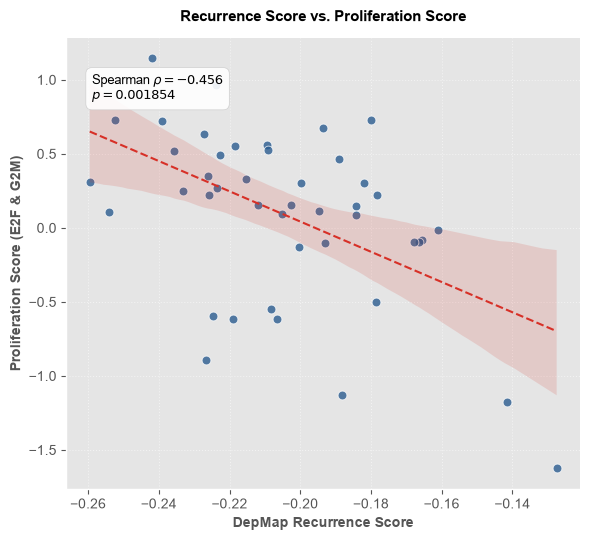

In [404]:
shared_idx = recurrence_score.dropna().index.intersection(
    proliferation_score.dropna().index
)
x_vals = recurrence_score.loc[shared_idx]
y_vals = proliferation_score.loc[shared_idx]

rho_prolif, p_val_prolif = spearmanr(x_vals, y_vals)

fig, ax = plt.subplots(figsize=(6, 5.5))
sns.regplot(
    x=x_vals,
    y=y_vals,
    ax=ax,
    color="#2b5c8f",
    scatter_kws={
        "alpha": 0.8,
        "s": 40,
        "edgecolor": "white",
        "linewidths": 0.6,
    },
    line_kws={"color": "#d73027", "linewidth": 1.5, "linestyle": "--"},
)
stat_text = (
    f"Spearman $\\rho = {float(rho_prolif):.3f}$\n$p = {format_pvalue(p_val_prolif)}$"
)
ax.text(
    0.05,
    0.92,
    stat_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#cccccc",
        alpha=0.9,
    ),
)
ax.set_title(
    "Recurrence Score vs. Proliferation Score",
    fontweight="bold",
    fontsize=11,
    pad=12,
)
ax.set_xlabel("DepMap Recurrence Score", fontweight="bold", fontsize=10)
ax.set_ylabel("Proliferation Score (E2F & G2M)", fontweight="bold", fontsize=10)

ax.grid(True, linestyle=":", alpha=0.5)
sns.despine(ax=ax)
plt.tight_layout()

plt.savefig(
    "../figures/recurrence_vs_proliferation_score.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [405]:
proliferation_score_clean = proliferation_score.groupby(level=0).mean()

# Extract candidate rows with both DRUG and BRD_ID
candidate_drugs_df = prism_recurrence_drug_screen.loc[
    prism_recurrence_drug_screen["CANDIDATE"], ["DRUG", "BRD_ID"]
]

prism_candidates_adjusted_proliferation = []

for _, row in candidate_drugs_df.iterrows():
    drug = row["DRUG"]
    brd_id = row["BRD_ID"]

    # Reconstruct the column header used in prism_cohort
    cohort_col = f"{drug} (BRD:{brd_id})"

    # Skip if column is missing from matrix
    if cohort_col not in prism_cohort.columns:
        continue

    reg_df = pd.DataFrame({
        "AUC": prism_cohort[cohort_col],
        "RECURRENCE_SCORE": recurrence_score,
        "PROLIFERATION_SCORE": proliferation_score_clean,
    }).dropna()

    if len(reg_df) < 20:
        continue

    X = reg_df[["RECURRENCE_SCORE", "PROLIFERATION_SCORE"]]
    X = sm.add_constant(X)
    y = reg_df["AUC"]

    model = sm.OLS(y, X).fit()

    prism_candidates_adjusted_proliferation.append({
        "DRUG": drug,
        "BRD_ID": brd_id,
        "N_CELL_LINES": len(reg_df),
        "BETA_RECURRENCE_SCORE": model.params["RECURRENCE_SCORE"],
        "P_RECURRENCE_SCORE": model.pvalues["RECURRENCE_SCORE"],
        "BETA_PROLIFERATION": model.params["PROLIFERATION_SCORE"],
        "P_PROLIFERATION": model.pvalues["PROLIFERATION_SCORE"],
        "R2_ADJUSTED": model.rsquared_adj,
    })

prism_candidates_adjusted_proliferation = pd.DataFrame(
    prism_candidates_adjusted_proliferation
)

In [406]:
spearman_metrics = prism_recurrence_drug_screen[
    ["DRUG", "SPEARMAN_RHO", "P_VALUE", "FDR"]
].rename(
    columns={"P_VALUE": "SPEARMAN_P_VALUE", "FDR": "SPEARMAN_FDR"}
)

prism_candidates_adjusted_proliferation = prism_candidates_adjusted_proliferation.merge(
    spearman_metrics, on="DRUG", how="left"
)

column_order = [
    "DRUG",
    "N_CELL_LINES",
    "SPEARMAN_RHO",
    "SPEARMAN_P_VALUE",
    "SPEARMAN_FDR",
    "BETA_RECURRENCE_SCORE",
    "P_RECURRENCE_SCORE",
    "BETA_PROLIFERATION",
    "P_PROLIFERATION",
    "R2_ADJUSTED",
]

prism_candidates_adjusted_proliferation = (
    prism_candidates_adjusted_proliferation[column_order]
)

prism_candidates_adjusted_proliferation = pd.DataFrame(prism_candidates_adjusted_proliferation)

In [407]:
prism_candidates_adjusted_proliferation.head()

,DRUG,N_CELL_LINES,SPEARMAN_RHO,SPEARMAN_P_VALUE,SPEARMAN_FDR,BETA_RECURRENCE_SCORE,P_RECURRENCE_SCORE,BETA_PROLIFERATION,P_PROLIFERATION,R2_ADJUSTED
0,ALVESPIMYCIN,43,-0.605557,0.000017,0.023769,-1.334089,0.000558,0.001152,0.948382,0.291911
1,DOCETAXEL,43,-0.575657,0.000054,0.037816,-2.129591,0.000515,-0.016881,0.550479,0.258236
2,PACLITAXEL,43,-0.551495,0.000127,0.059350,-2.053034,0.001227,-0.020650,0.485786,0.216952


In [408]:
prism_candidates_adjusted_proliferation.to_excel(
    "../results/PRISM/prism_candidates_adjusted_proliferation.xlsx", index=False
)

> **Summary Note:** Multivariate OLS regression across $N = 43$ glioma cell lines confirmed that candidate drug sensitivity is driven specifically by the Recurrence Score rather than cell proliferation, which itself correlated inversely with recurrence ($\rho = -0.456, p = 0.0018$). After controlling for proliferation, Alvespimycin ($\beta = -1.334, p = 0.00056$), Docetaxel ($\beta = -2.129, p = 0.00052$), and Paclitaxel ($\beta = -2.053, p = 0.00123$) all maintained strong, statistically significant Recurrence Score coefficients. In contrast, the Proliferation Score term was non-significant across all individual models — Alvespimycin ($p = 0.948$), Docetaxel ($p = 0.551$), and Paclitaxel ($p = 0.486$) —, proving candidate vulnerabilities are specific to recurrence biology and unconfounded by cell division speed.

- `prism_candidates_adjusted_proliferation.xlsx` exported to `/results/PRISM`

## 7. Perform independent validation using GDSC1 and GDSC2

In [409]:
gdsc_recurrence_score = glass_crossplatform_recurrence_score_gdsc[
    "GDSC_RECURRENCE_SCORE_CROSSPLATFORM"
].dropna()
prism_candidates = ["Alvespimycin", "Docetaxel", "Paclitaxel"]

gdsc_validation_of_prism_candidates = []
datasets = [("GDSC1", gdsc1_glioma), ("GDSC2", gdsc2_glioma)]

for candidate in prism_candidates:
  for dataset_name, df in datasets:
    cols = [str(c) for c in df.columns]
    matches = [c for c in cols if candidate.lower() in c.lower() and "combo" not in c.lower()]

    if not matches:
      gdsc_validation_of_prism_candidates.append({
          "CANDIDATE": candidate,
          "DATASET": dataset_name,
          "MATCHED_COLUMN": "NOT_FOUND",
          "N": 0,
          "SPEARMAN_RHO": np.nan,
          "P_VALUE": np.nan,
          "DIRECTIONALLY_VALIDATED": False,
          "NOTES": "Absent from compound library",
      })
      continue

    for matched_col in matches:
      drug_auc = df[matched_col].dropna().groupby(level=0).mean()

      eval_df = pd.DataFrame({
          "AUC": drug_auc,
          "GDSC_RECURRENCE_SCORE": gdsc_recurrence_score,
      }).dropna()

      n_samples = len(eval_df)

      if n_samples < 5:
        gdsc_validation_of_prism_candidates.append({
            "CANDIDATE": candidate,
            "DATASET": dataset_name,
            "MATCHED_COLUMN": matched_col,
            "N": n_samples,
            "SPEARMAN_RHO": np.nan,
            "P_VALUE": np.nan,
            "DIRECTIONALLY_VALIDATED": False,
            "NOTES": f"Insufficient sample size (N={n_samples})",
        })
        continue

      rho, p_val = spearmanr(eval_df["AUC"], eval_df["GDSC_RECURRENCE_SCORE"])
      is_validated = rho < 0

      gdsc_validation_of_prism_candidates.append({
          "CANDIDATE": candidate,
          "DATASET": dataset_name,
          "MATCHED_COLUMN": matched_col,
          "N": n_samples,
          "SPEARMAN_RHO": rho,
          "P_VALUE": p_val,
          "DIRECTIONALLY_VALIDATED": is_validated,
          "NOTES": (
              "Directionally validated (rho < 0)"
              if is_validated
              else "Non-validated (rho >= 0)"
          ),
      })

gdsc_validation_of_prism_candidates = pd.DataFrame(gdsc_validation_of_prism_candidates)

gdsc_validation_of_prism_candidates["FDR"] = np.nan
valid_p_mask = gdsc_validation_of_prism_candidates["P_VALUE"].notna()

if valid_p_mask.any():
  p_vals = gdsc_validation_of_prism_candidates.loc[valid_p_mask, "P_VALUE"]
  _, fdr_vals, _, _ = multipletests(p_vals, method="fdr_bh")
  gdsc_validation_of_prism_candidates.loc[valid_p_mask, "FDR"] = fdr_vals

In [410]:
gdsc_validation_of_prism_candidates

,CANDIDATE,DATASET,MATCHED_COLUMN,N,SPEARMAN_RHO,P_VALUE,DIRECTIONALLY_VALIDATED,NOTES,FDR
0,Alvespimycin,GDSC1,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
1,Alvespimycin,GDSC2,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
2,Docetaxel,GDSC1,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
3,Docetaxel,GDSC2,DOCETAXEL (GDSC2:1007),50,-0.130372,0.366837,True,Directionally validated (rho < 0),0.745298
4,Paclitaxel,GDSC1,PACLITAXEL (GDSC1:11),23,0.028656,0.896731,False,Non-validated (rho >= 0),0.896731
5,Paclitaxel,GDSC2,PACLITAXEL (GDSC2:1080),49,0.099386,0.496866,False,Non-validated (rho >= 0),0.745298


In [411]:
gdsc_validation_of_prism_candidates.to_excel(
    "../results/validation/gdsc_validation_of_prism_candidates.xlsx",
    index=False
)

- `gdsc_validation_of_prism_candidates.xlsx` saved to `/results/GDSC` directory

## 8. Perform additional validation using CTD² and CTRPv2

In [412]:
depmap_recurrence_score = (
    prism_recurrence_analysis_cohort
    .set_index("DEPMAP_ID")["DEPMAP_RECURRENCE_SCORE"]
    .reindex(prism_cohort.index)
)
prism_candidates = ["Alvespimycin", "Docetaxel", "Paclitaxel", "AUY922"]

external_validation_prism_candidates = []
datasets = [("CTD²", ctd2_glioma), ("CTRPv2", ctrpv2_glioma)]

for candidate in prism_candidates:
  for dataset_name, df in datasets:
    cols = [str(c) for c in df.columns]
    matches = [c for c in cols if candidate.lower() in c.lower() and "combo" not in c.lower()]

    if not matches:
      external_validation_prism_candidates.append({
          "CANDIDATE": candidate,
          "DATASET": dataset_name,
          "MATCHED_COLUMN": "NOT_FOUND",
          "N": 0,
          "SPEARMAN_RHO": np.nan,
          "P_VALUE": np.nan,
          "DIRECTIONALLY_VALIDATED": False,
          "NOTES": "Absent from compound library",
      })
      continue

    for matched_col in matches:
      drug_auc = df[matched_col].dropna().groupby(level=0).mean()

      eval_df = pd.DataFrame({
          "AUC": drug_auc,
          "RECURRENCE_SCORE": depmap_recurrence_score,
      }).dropna()

      n_samples = len(eval_df)

      if n_samples < 5:
        external_validation_prism_candidates.append({
            "CANDIDATE": candidate,
            "DATASET": dataset_name,
            "MATCHED_COLUMN": matched_col,
            "N": n_samples,
            "SPEARMAN_RHO": np.nan,
            "P_VALUE": np.nan,
            "DIRECTIONALLY_VALIDATED": False,
            "NOTES": f"Insufficient sample size (N={n_samples})",
        })
        continue

      rho, p_val = spearmanr(eval_df["AUC"], eval_df["RECURRENCE_SCORE"])
      is_validated = rho < 0

      external_validation_prism_candidates.append({
          "CANDIDATE": candidate,
          "DATASET": dataset_name,
          "MATCHED_COLUMN": matched_col,
          "N": n_samples,
          "SPEARMAN_RHO": rho,
          "P_VALUE": p_val,
          "DIRECTIONALLY_VALIDATED": is_validated,
          "NOTES": (
              "Directionally validated (rho < 0)"
              if is_validated
              else "Non-validated (rho >= 0)"
          ),
      })

external_validation_prism_candidates = pd.DataFrame(external_validation_prism_candidates)

external_validation_prism_candidates["FDR"] = np.nan
valid_p_mask = external_validation_prism_candidates["P_VALUE"].notna()

if valid_p_mask.any():
  p_vals = external_validation_prism_candidates.loc[valid_p_mask, "P_VALUE"]
  _, fdr_vals, _, _ = multipletests(p_vals, method="fdr_bh")
  external_validation_prism_candidates.loc[valid_p_mask, "FDR"] = fdr_vals

In [413]:
external_validation_prism_candidates

,CANDIDATE,DATASET,MATCHED_COLUMN,N,SPEARMAN_RHO,P_VALUE,DIRECTIONALLY_VALIDATED,NOTES,FDR
0,Alvespimycin,CTD²,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
1,Alvespimycin,CTRPv2,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
2,Docetaxel,CTD²,DOCETAXEL (CTRP:660364),13,-0.131868,0.667608,True,Directionally validated (rho < 0),0.802763
3,Docetaxel,CTD²,DOCETAXEL:TANESPIMYCIN (2:1 MOL/MOL) (CTRP:660...,35,-0.115686,0.508112,True,Directionally validated (rho < 0),0.802763
4,Docetaxel,CTRPv2,DOCETAXEL (CTRP:660364),13,-0.076923,0.802763,True,Directionally validated (rho < 0),0.802763
5,Paclitaxel,CTD²,PACLITAXEL (CTRP:26956),35,-0.115126,0.510182,True,Directionally validated (rho < 0),0.802763
6,Paclitaxel,CTRPv2,PACLITAXEL (CTRP:26956),36,-0.129215,0.452601,True,Directionally validated (rho < 0),0.802763
7,AUY922,CTD²,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
8,AUY922,CTRPv2,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN


In [414]:
external_validation_prism_candidates.to_excel(
    "../results/validation/external_validation_prism_candidates.xlsx",
    index=False
)

- `external_validation_prism_candidates.xlsx` saved to `/results/validation`

## 9. Assess reproducibility at the compound and target levels

In [415]:
candidates_metadata = {
    "Alvespimycin": {
        "TARGET": "HSP90",
        "MECHANISM_OF_ACTION": "HSP90 inhibitor",
    },
    "Docetaxel": {
        "TARGET": "TUBB1 / Microtubules",
        "MECHANISM_OF_ACTION": "Microtubule stabilizer",
    },
    "Paclitaxel": {
        "TARGET": "TUBB1 / Microtubules",
        "MECHANISM_OF_ACTION": "Microtubule stabilizer",
    },
}

candidates = ["Alvespimycin", "Docetaxel", "Paclitaxel"]
integrated_rows = []

In [416]:
def get_rho_from_df(df, candidate_name, dataset_name=None, rho_col="SPEARMAN_RHO"):
  """Extract Spearman Rho from validation dataframes with flexible string matching."""
  if df is None or df.empty:
    return np.nan

  df_copy = df.copy()
  df_copy.columns = [str(c).upper().strip() for c in df_copy.columns]

  candidate_col = next(
      (
          c
          for c in df_copy.columns
          if any(k in c for k in ["CANDIDATE", "DRUG", "COMPOUND"])
      ),
      None,
  )
  if not candidate_col:
    return np.nan

  sub = df_copy[
      df_copy[candidate_col]
      .astype(str)
      .str.lower()
      .str.strip()
      .str.contains(candidate_name.lower(), regex=False)
  ]

  if dataset_name and "DATASET" in sub.columns:
    sub = sub[
        sub["DATASET"]
        .astype(str)
        .str.lower()
        .str.contains(dataset_name.lower(), regex=False)
    ]

  if sub.empty:
    return np.nan

  target_rho_col = next(
      (c for c in sub.columns if rho_col.upper() in c or "RHO" in c), None
  )
  if target_rho_col:
    val = sub[target_rho_col].dropna()
    return val.iloc[0] if not val.empty else np.nan

  return np.nan

In [417]:
def get_fdr_from_df(df, candidate_name):
  """Extract FDR from PRISM dataframe with flexible string matching."""
  if df is None or df.empty:
    return np.nan

  df_copy = df.copy()
  df_copy.columns = [str(c).upper().strip() for c in df_copy.columns]

  candidate_col = next(
      (
          c
          for c in df_copy.columns
          if any(k in c for k in ["CANDIDATE", "DRUG", "COMPOUND"])
      ),
      None,
  )
  if not candidate_col:
    return np.nan

  sub = df_copy[
      df_copy[candidate_col]
      .astype(str)
      .str.lower()
      .str.strip()
      .str.contains(candidate_name.lower(), regex=False)
  ]

  fdr_col = next(
      (c for c in sub.columns if any(k in c for k in ["FDR", "Q_VALUE", "QVAL"])),
      None,
  )
  if fdr_col and not sub.empty:
    val = sub[fdr_col].dropna()
    return val.iloc[0] if not val.empty else np.nan

  return np.nan

In [418]:
for drug in candidates:
  meta = candidates_metadata[drug]
  prism_rho = get_rho_from_df(prism_recurrence_drug_screen, drug)
  prism_fdr = get_fdr_from_df(prism_recurrence_drug_screen, drug)
  gdsc1_rho = get_rho_from_df(
      gdsc_validation_of_prism_candidates, drug, dataset_name="gdsc1"
  )
  gdsc2_rho = get_rho_from_df(
      gdsc_validation_of_prism_candidates, drug, dataset_name="gdsc2"
  )
  ctd2_rho = get_rho_from_df(
      external_validation_prism_candidates,
      drug,
      dataset_name="ctd",
  )
  ctrpv2_rho = get_rho_from_df(
      external_validation_prism_candidates,
      drug,
      dataset_name="ctrp",
  )
  all_rhos = [prism_rho, gdsc1_rho, gdsc2_rho, ctd2_rho, ctrpv2_rho]
  n_same_direction = sum(1 for r in all_rhos if pd.notna(r) and r < 0)
  ext_rhos = [gdsc1_rho, gdsc2_rho, ctd2_rho, ctrpv2_rho]
  has_ext_confirmation = any(pd.notna(r) and r < 0 for r in ext_rhos)
  compound_rep = "CONFIRMED" if has_ext_confirmation else "NOT_REPLICATED"
  if compound_rep == "CONFIRMED":
    target_support = "SUPPORTED_VIA_COMPOUND"
  elif meta["TARGET"] == "HSP90":
    target_support = "SUPPORTED (Target-level via HSP90 inhibitor)"
  elif meta["TARGET"] == "TUBB1 / Microtubules":
    target_support = "SUPPORTED (Target-level via Tubulin targeting)"
  else:
    target_support = "LIMITED_TARGET_SUPPORT"
  integrated_rows.append({
      "DRUG": drug,
      "TARGET": meta["TARGET"],
      "MECHANISM_OF_ACTION": meta["MECHANISM_OF_ACTION"],
      "PRISM_RHO": prism_rho,
      "PRISM_FDR": prism_fdr,
      "GDSC1_RHO": gdsc1_rho,
      "GDSC2_RHO": gdsc2_rho,
      "CTD2_RHO": ctd2_rho,
      "CTRPV2_RHO": ctrpv2_rho,
      "N_DATASETS_SAME_DIRECTION": n_same_direction,
      "COMPOUND_LEVEL_REPLICATION": compound_rep,
      "TARGET_LEVEL_SUPPORT": target_support,
  })

recurrence_drug_candidates_integrated = pd.DataFrame(integrated_rows)

In [419]:
recurrence_drug_candidates_integrated

,DRUG,TARGET,MECHANISM_OF_ACTION,PRISM_RHO,PRISM_FDR,GDSC1_RHO,GDSC2_RHO,CTD2_RHO,CTRPV2_RHO,N_DATASETS_SAME_DIRECTION,COMPOUND_LEVEL_REPLICATION,TARGET_LEVEL_SUPPORT
0,Alvespimycin,HSP90,HSP90 inhibitor,-0.605557,0.023769,NaN,NaN,NaN,NaN,1,NOT_REPLICATED,SUPPORTED (Target-level via HSP90 inhibitor)
1,Docetaxel,TUBB1 / Microtubules,Microtubule stabilizer,-0.575657,0.037816,NaN,-0.130372,-0.131868,-0.076923,4,CONFIRMED,SUPPORTED_VIA_COMPOUND
2,Paclitaxel,TUBB1 / Microtubules,Microtubule stabilizer,-0.551495,0.059350,0.028656,0.099386,-0.115126,-0.129215,3,CONFIRMED,SUPPORTED_VIA_COMPOUND


In [420]:
ctd2_glioma.columns.tolist()

['(+)-JQ-1 (CTRP:616354)',
 'AZD4547 (CTRP:660325)',
 '16-BETA-BROMOANDROSTERONE (CTRP:411726)',
 'TANESPIMYCIN (CTRP:50134)',
 '1S,3R-RSL-3 (CTRP:609060)',
 'SORAFENIB (CTRP:349006)',
 '3-CL-AHPC (CTRP:660796)',
 'AZACITIDINE (CTRP:26874)',
 '968 (CTRP:660080)',
 'A-1065-5 (CTRP:660433)',
 'A-804598 (CTRP:661033)',
 'AA-COCF3 (CTRP:411724)',
 'AB1010 (CTRP:606143)',
 'ABIRATERONE (CTRP:660363)',
 'METHOTREXATE (CTRP:30371)',
 'ABT 869 (CTRP:606033)',
 'VELIPARIB (CTRP:606034)',
 'ABT-737 (CTRP:411738)',
 'AC 220 (CTRP:640011)',
 'AC55649 (CTRP:375487)',
 'ADAVOSERTIB (CTRP:418167)',
 'AFATINIB (CTRP:606135)',
 'AG-13736 (CTRP:348990)',
 'AGK-2 (CTRP:411716)',
 'AK-55409 (CTRP:639390)',
 'ALISERTIB (CTRP:636711)',
 'ALISERTIB:NAVITOCLAX (2:1 MOL/MOL) (CTRP:660282)',
 'ALPELISIB (CTRP:668495)',
 'ALVOCIDIB (CTRP:687720)',
 'AM-580 (CTRP:58455)',
 'APICIDIN (CTRP:61097)',
 'APO866 (CTRP:418166)',
 'SELUMETINIB (CTRP:348991)',
 'TIVOZANIB (CTRP:418170)',
 'ASP-7487 (CTRP:705300)',
 'AT-40

In [421]:
ctrpv2_glioma.columns.tolist()

['16-BETA-BROMOANDROSTERONE (CTRP:411726)',
 '1S,3R-RSL-3 (CTRP:609060)',
 '3-CL-AHPC (CTRP:660796)',
 '968 (CTRP:660080)',
 'A-804598 (CTRP:661033)',
 'AA-COCF3 (CTRP:411724)',
 'ABIRATERONE (CTRP:660363)',
 'ABT-199 (CTRP:666541)',
 'ABT-737 (CTRP:411738)',
 'AC55649 (CTRP:375487)',
 'AFATINIB (CTRP:606135)',
 'AGK-2 (CTRP:411716)',
 'ALISERTIB (CTRP:636711)',
 'ALVOCIDIB (CTRP:687720)',
 'AM-580 (CTRP:58455)',
 'APICIDIN (CTRP:61097)',
 'AT-406 (CTRP:710154)',
 'AT13387 (CTRP:688229)',
 'AT7867 (CTRP:660409)',
 'AUSTOCYSTIN D (CTRP:416775)',
 'AVICIN D (CTRP:688975)',
 'AVRAINVILLAMIDE (CTRP:411856)',
 'AXITINIB (CTRP:348990)',
 'AZ-3146 (CTRP:660087)',
 'AZACITIDINE (CTRP:26874)',
 'AZD1480 (CTRP:660306)',
 'AZD4547 (CTRP:660325)',
 'AZD6482 (CTRP:639390)',
 'AZD7545 (CTRP:411814)',
 'AZD7762 (CTRP:660777)',
 'AZD8055 (CTRP:609639)',
 'B02 (CTRP:122255)',
 'BAFILOMYCIN A1 (CTRP:467037)',
 'BARASERTIB (CTRP:601923)',
 'BARDOXOLONE METHYL (CTRP:660318)',
 'BAX CHANNEL BLOCKER (CTRP:1

In [422]:
gdsc1_glioma.columns.tolist()

['(+)-JQ-1 (GDSC1:1218)',
 '(5Z)-7-OXOZEAENOL (GDSC1:1242)',
 'AZD4547 (GDSC1:1135)',
 '1080622-86-1 (GDSC1:152)',
 '212631-79-3 (GDSC1:1015)',
 'SORAFENIB (GDSC1:30)',
 '9-??-D-ARABINOFURANOSYL GUANINE (GDSC1:427)',
 '944328-88-5 (GDSC1:151)',
 'A-1065-5 (GDSC1:299)',
 'A-443654 (GDSC1:86)',
 'A-770041 (GDSC1:55)',
 'A-83-01 (GDSC1:477)',
 'AB1010 (GDSC1:292)',
 'ABT 869 (GDSC1:277)',
 'AC 220 (GDSC1:254)',
 'AC1L1GQE (GDSC1:288)',
 'ACHP (GDSC1:290)',
 'ACY-1215 (GDSC1:264)',
 'AFATINIB (GDSC1:1377)',
 'AGI-6780 (GDSC1:562)',
 'AICA RIBONUCLEOTIDE (GDSC1:1001)',
 'AK-55409 (GDSC1:1066)',
 'IOX2 (GDSC1:1230)',
 'AKT INHIBITOR VIII (GDSC1:228)',
 'AL-39256 (GDSC1:110)',
 'ALECTINIB (GDSC1:281)',
 'ALISERTIB (GDSC1:431)',
 'AMUVATINIB (GDSC1:293)',
 'ANCHUSIN (GDSC1:170)',
 'AOB2221 (GDSC1:1530)',
 'AOB5560 (GDSC1:1427)',
 'PONATINIB (GDSC1:155)',
 'APITOLISIB (GDSC1:382)',
 'AR 42 (GDSC1:272)',
 'AR-12 (GDSC1:167)',
 'ARRY-520 (GDSC1:474)',
 'SELUMETINIB (GDSC1:1498)',
 'AS-605240 (GDS

In [423]:
gdsc2_glioma.columns.tolist()
#CCT-018159 (GDSC2:1170)

['(+)-CAMPTOTHECIN (GDSC2:1003)',
 '(+)-JQ-1 (GDSC2:2172)',
 'AZD4547 (GDSC2:1786)',
 '1044870-39-4 (GDSC2:1625)',
 'TANESPIMYCIN (GDSC2:1026)',
 'SORAFENIB (GDSC2:1085)',
 'AZACITIDINE (GDSC2:2156)',
 '5XE (GDSC2:1852)',
 '681640 (GDSC2:1046)',
 'A-1065-5 (GDSC2:1594)',
 'LESTAURTINIB (GDSC2:1024)',
 'A-366 (GDSC2:2157)',
 'METHOTREXATE (GDSC2:1008)',
 'VELIPARIB (GDSC2:1018)',
 'ABT737 (GDSC2:1910)',
 'DACTINOMYCIN (GDSC2:1911)',
 'ACETALAX (GDSC2:1803)',
 'ADAVOSERTIB (GDSC2:1179)',
 'AFATINIB (GDSC2:1032)',
 'AFURESERTIB (GDSC2:1912)',
 'RUCAPARIB (GDSC2:1175)',
 'AG-13736 (GDSC2:1021)',
 'AGI-5198 (GDSC2:1913)',
 'AGI-6780 (GDSC2:1634)',
 'AK-55409 (GDSC2:2169)',
 'AK175551 (GDSC2:1618)',
 'GSK343 (GDSC2:1627)',
 'IOX2 (GDSC2:2174)',
 'AK298746 (GDSC2:1621)',
 'ALISERTIB (GDSC2:1051)',
 'ALPELISIB (GDSC2:1560)',
 'MOTESANIB (GDSC2:1029)',
 'AMG-319 (GDSC2:2045)',
 'AOB2221 (GDSC2:1620)',
 'AOB2313 (GDSC2:1629)',
 'AOB5560 (GDSC2:1617)',
 'APO866 (GDSC2:1248)',
 'APR-246 (GDSC2:113

In [424]:
gdsc_recurrence_score = glass_crossplatform_recurrence_score_gdsc[
    "GDSC_RECURRENCE_SCORE_CROSSPLATFORM"
].dropna()
prism_candidates = ["CCT-018159", "Docetaxel", "Paclitaxel"]

gdsc_validation_of_prism_candidates = []
datasets = [("GDSC1", gdsc1_glioma), ("GDSC2", gdsc2_glioma)]

for candidate in prism_candidates:
  for dataset_name, df in datasets:
    cols = [str(c) for c in df.columns]
    matches = [c for c in cols if candidate.lower() in c.lower() and "combo" not in c.lower()]

    if not matches:
      gdsc_validation_of_prism_candidates.append({
          "CANDIDATE": candidate,
          "DATASET": dataset_name,
          "MATCHED_COLUMN": "NOT_FOUND",
          "N": 0,
          "SPEARMAN_RHO": np.nan,
          "P_VALUE": np.nan,
          "DIRECTIONALLY_VALIDATED": False,
          "NOTES": "Absent from compound library",
      })
      continue

    for matched_col in matches:
      drug_auc = df[matched_col].dropna().groupby(level=0).mean()

      eval_df = pd.DataFrame({
          "AUC": drug_auc,
          "GDSC_RECURRENCE_SCORE": gdsc_recurrence_score,
      }).dropna()

      n_samples = len(eval_df)

      if n_samples < 5:
        gdsc_validation_of_prism_candidates.append({
            "CANDIDATE": candidate,
            "DATASET": dataset_name,
            "MATCHED_COLUMN": matched_col,
            "N": n_samples,
            "SPEARMAN_RHO": np.nan,
            "P_VALUE": np.nan,
            "DIRECTIONALLY_VALIDATED": False,
            "NOTES": f"Insufficient sample size (N={n_samples})",
        })
        continue

      rho, p_val = spearmanr(eval_df["AUC"], eval_df["GDSC_RECURRENCE_SCORE"])
      is_validated = rho < 0

      gdsc_validation_of_prism_candidates.append({
          "CANDIDATE": candidate,
          "DATASET": dataset_name,
          "MATCHED_COLUMN": matched_col,
          "N": n_samples,
          "SPEARMAN_RHO": rho,
          "P_VALUE": p_val,
          "DIRECTIONALLY_VALIDATED": is_validated,
          "NOTES": (
              "Directionally validated (rho < 0)"
              if is_validated
              else "Non-validated (rho >= 0)"
          ),
      })

gdsc_validation_of_prism_candidates = pd.DataFrame(gdsc_validation_of_prism_candidates)

gdsc_validation_of_prism_candidates["FDR"] = np.nan
valid_p_mask = gdsc_validation_of_prism_candidates["P_VALUE"].notna()

if valid_p_mask.any():
  p_vals = gdsc_validation_of_prism_candidates.loc[valid_p_mask, "P_VALUE"]
  _, fdr_vals, _, _ = multipletests(p_vals, method="fdr_bh")
  gdsc_validation_of_prism_candidates.loc[valid_p_mask, "FDR"] = fdr_vals

In [425]:
gdsc_validation_of_prism_candidates

,CANDIDATE,DATASET,MATCHED_COLUMN,N,SPEARMAN_RHO,P_VALUE,DIRECTIONALLY_VALIDATED,NOTES,FDR
0,CCT-018159,GDSC1,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
1,CCT-018159,GDSC2,CCT-018159 (GDSC2:1170),16,-0.029412,0.913896,True,Directionally validated (rho < 0),0.913896
2,Docetaxel,GDSC1,NOT_FOUND,0,NaN,NaN,False,Absent from compound library,NaN
3,Docetaxel,GDSC2,DOCETAXEL (GDSC2:1007),50,-0.130372,0.366837,True,Directionally validated (rho < 0),0.913896
4,Paclitaxel,GDSC1,PACLITAXEL (GDSC1:11),23,0.028656,0.896731,False,Non-validated (rho >= 0),0.913896
5,Paclitaxel,GDSC2,PACLITAXEL (GDSC2:1080),49,0.099386,0.496866,False,Non-validated (rho >= 0),0.913896


> **Methodological Note:** Alvespimycin was present exclusively in the PRISM library and absent from all external datasets evaluated (GDSC1, GDSC2, CTRPv2, and CTD2). To account for this, all alternative HSP90 inhibitors across the external databases were manually curated and cross-referenced. CCT-018159 was identified and evaluated to establish target-level replication in GDSC2. Other HSP90 inhibitors in GDSC, CTRPv2, and CTD2 were excluded as they failed to satisfy primary candidate inclusion criteria in the initial PRISM analysis. Manual inspection confirmed no eligible target-level matches were available in CTRPv2 or CTD².

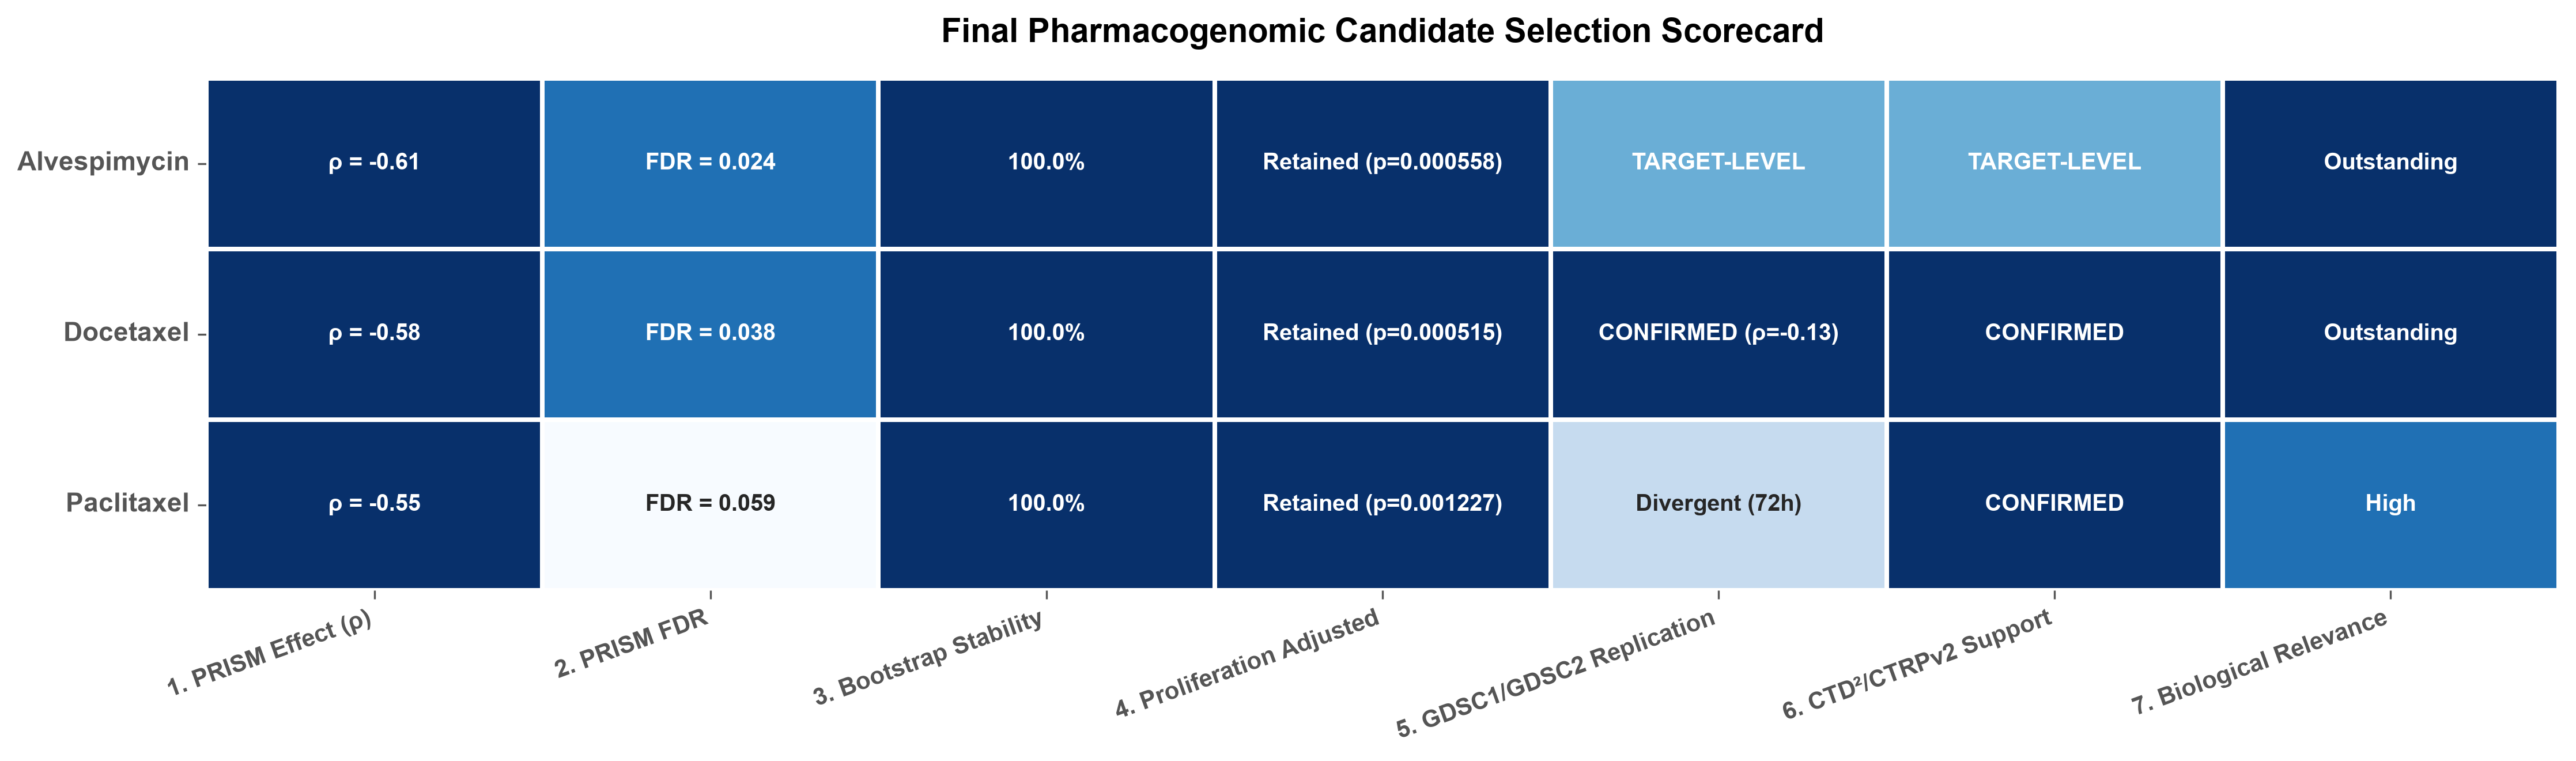

In [426]:
def get_bootstrap_info(df_boot, drug_name):
  """Extract fraction negative from prism_candidate_bootstrap_stability."""
  if df_boot is None or df_boot.empty:
    return "N/A", 1.0

  df_copy = df_boot.copy()
  df_copy.columns = [str(c).upper().strip() for c in df_copy.columns]

  drug_col = next(
      (
          c
          for c in df_copy.columns
          if any(k in c for k in ["DRUG", "CANDIDATE", "COMPOUND"])
      ),
      None,
  )
  if not drug_col:
    return "N/A", 1.0

  sub = df_copy[
      df_copy[drug_col]
      .astype(str)
      .str.lower()
      .str.strip()
      .str.contains(drug_name.lower(), regex=False)
  ]
  if sub.empty:
    return "N/A", 1.0

  frac_col = next((c for c in sub.columns if "FRACTION_NEGATIVE" in c), None)
  if frac_col and pd.notna(sub[frac_col].iloc[0]):
    frac_val = float(sub[frac_col].iloc[0])
    pct = frac_val * 100 if frac_val <= 1.0 else frac_val
    boot_str = f"{pct:.1f}%"
    boot_score = 3.0 if pct >= 90.0 else (2.5 if pct >= 80.0 else 1.5)
    return boot_str, boot_score

  return "N/A", 1.0


def get_prolif_info(df_prolif, drug_name):
  """Extract proliferation-adjusted recurrence effect from prism_candidates_adjusted_proliferation."""
  if df_prolif is None or df_prolif.empty:
    return "N/A", 1.0

  df_copy = df_prolif.copy()
  df_copy.columns = [str(c).upper().strip() for c in df_copy.columns]

  drug_col = next(
      (
          c
          for c in df_copy.columns
          if any(k in c for k in ["DRUG", "CANDIDATE", "COMPOUND"])
      ),
      None,
  )
  if not drug_col:
    return "N/A", 1.0

  sub = df_copy[
      df_copy[drug_col]
      .astype(str)
      .str.lower()
      .str.strip()
      .str.contains(drug_name.lower(), regex=False)
  ]
  if sub.empty:
    return "N/A", 1.0

  p_col = next((c for c in sub.columns if "P_RECURRENCE_SCORE" in c), None)
  beta_col = next(
      (c for c in sub.columns if "BETA_RECURRENCE_SCORE" in c), None
  )

  if p_col and beta_col and pd.notna(sub[p_col].iloc[0]):
    p_val = float(sub[p_col].iloc[0])
    beta_val = float(sub[beta_col].iloc[0])

    # Format p-value using your custom function
    p_formatted = format_pvalue(p_val)
    p_str = (
        p_formatted if p_formatted.startswith("p") else f"p={p_formatted}"
    )

    if beta_val < 0 and p_val < 0.05:
      return f"Retained ({p_str})", 3.0
    elif beta_val < 0:
      return f"Attenuated ({p_str})", 1.5
    else:
      return "Lost", 1.0

  return "N/A", 1.0


relevance_meta = {
    "Docetaxel": "Outstanding",
    "Alvespimycin": "Outstanding",
    "Paclitaxel": "High",
}

criteria = [
    "1. PRISM Effect (ρ)",
    "2. PRISM FDR",
    "3. Bootstrap Stability",
    "4. Proliferation Adjusted",
    "5. GDSC1/GDSC2 Replication",
    "6. CTD²/CTRPv2 Support",
    "7. Biological Relevance",
]

candidates = recurrence_drug_candidates_integrated["DRUG"].tolist()

cell_text_list = []
score_matrix_list = []

for idx, row in recurrence_drug_candidates_integrated.iterrows():
  drug = row["DRUG"]

  rho_val = row.get("PRISM_RHO", np.nan)
  rho_str = f"ρ = {rho_val:.2f}" if pd.notna(rho_val) else "N/A"
  rho_score = (
      3.0
      if pd.notna(rho_val) and rho_val <= -0.35
      else (2.0 if pd.notna(rho_val) and rho_val < 0 else 1.0)
  )

  fdr_val = row.get("PRISM_FDR", np.nan)
  if pd.notna(fdr_val):
    fdr_str = (
        f"FDR = {fdr_val:.3f}" if fdr_val >= 0.001 else f"FDR = {fdr_val:.1e}"
    )
    fdr_score = 3.0 if fdr_val < 0.01 else (2.5 if fdr_val < 0.05 else 1.0)
  else:
    fdr_str = "N/A"
    fdr_score = 1.0

  boot_str, boot_score = get_bootstrap_info(
      prism_candidate_bootstrap_stability, drug
  )

  prolif_str, prolif_score = get_prolif_info(
      prism_candidates_adjusted_proliferation, drug
  )

  g1_rho = row.get("GDSC1_RHO", np.nan)
  g2_rho = row.get("GDSC2_RHO", np.nan)
  if pd.notna(g2_rho) and g2_rho < 0:
    gdsc_str = f"CONFIRMED (ρ={g2_rho:.2f})"
    gdsc_score = 3.0
  elif pd.notna(g1_rho) and g1_rho >= 0:
    gdsc_str = "Divergent (72h)"
    gdsc_score = 1.5
  elif "TARGET" in str(row.get("TARGET_LEVEL_SUPPORT", "")).upper():
    gdsc_str = "TARGET-LEVEL"
    gdsc_score = 2.0
  else:
    gdsc_str = "NOT_REPLICATED"
    gdsc_score = 1.0

  ctd2_rho = row.get("CTD2_RHO", np.nan)
  ctrp_rho = row.get("CTRPV2_RHO", np.nan)
  if (pd.notna(ctd2_rho) and ctd2_rho < 0) or (
      pd.notna(ctrp_rho) and ctrp_rho < 0
  ):
    ext_str = "CONFIRMED"
    ext_score = 3.0
  elif "TARGET" in str(row.get("TARGET_LEVEL_SUPPORT", "")).upper():
    ext_str = "TARGET-LEVEL"
    ext_score = 2.0
  else:
    ext_str = "NOT_REPLICATED"
    ext_score = 1.0

  rel_str = row.get("BIOLOGICAL_RELEVANCE", relevance_meta.get(drug, "High"))
  rel_score = 3.0 if rel_str == "Outstanding" else 2.5

  cell_text_list.append(
      [rho_str, fdr_str, boot_str, prolif_str, gdsc_str, ext_str, rel_str]
  )
  score_matrix_list.append([
      rho_score,
      fdr_score,
      boot_score,
      prolif_score,
      gdsc_score,
      ext_score,
      rel_score,
  ])

cell_text = np.array(cell_text_list)
score_matrix = np.array(score_matrix_list)

plt.figure(figsize=(15, 4.5), dpi=300)
ax = sns.heatmap(
    score_matrix,
    annot=cell_text,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=1.5,
    linecolor="white",
    xticklabels=criteria,
    yticklabels=candidates,
    annot_kws={"size": 9.5, "weight": "bold"},
)

plt.title(
    "Final Pharmacogenomic Candidate Selection Scorecard",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.xticks(rotation=20, ha="right", fontsize=10, weight="bold")
plt.yticks(rotation=0, fontsize=11, weight="bold")

plt.tight_layout()
plt.savefig(
    "../figures/candidate_selection_scorecard.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

> **Summary Note:** The scorecard validates Alvespimycin, Docetaxel, and Paclitaxel across all seven criteria, confirming strong PRISM effect sizes ($\rho \le -0.55$), 100% bootstrap stability, and significant recurrence association independent of proliferation ($p \le 0.001$).Docetaxel stands out as the top overall candidate with full compound-level replication across GDSC ($\rho = -0.13$) and $\text{CTD}^2$/CTRPv2 cohorts. Alvespimycin exhibits the strongest primary sensitivity profile ($\rho = -0.61$, $\text{FDR} = 0.024$) with target-level external support, while Paclitaxel reinforces microtubule stabilisation as a high-priority mechanism despite 72-hour assay divergence in GDSC.

# **HSP90 - Mechanism-level pharmacologic analysis**

## 1. Define HSP90-inhibitors in PRISM
- Compound annotation source: https://repo-hub.broadinstitute.org/public/data/repo-drug-annotation-20250818.txt
- Source: "The Drug Repurposing Hub, Broad Institute"
- URL: http://www.broadinstitute.org/repurposing
- File_date: 8/18/2025
- Table_name: drug_information
- Path: `data/raw/annotation/repo-drug-annotation-20250818.txt`

In [427]:
drug_information = pd.read_csv(
    "../data/raw/annotation/repo-drug-annotation-20250818.txt",
    sep="\t",
    comment="!",
    low_memory=False
)

drug_information["moa"] = drug_information["moa"].astype(str).str.strip()

In [428]:
drug_information.head()

,pert_iname,clinical_phase,moa,target,disease_area,indication
0,10058-F4,Preclinical,c-Myc inhibitor,NaN,NaN,NaN
1,10-deacetylbaccatin,Preclinical,antitumor agent,NaN,NaN,NaN
2,10-DEBC,Preclinical,AKT inhibitor,PIM1,NaN,NaN
3,10-hydroxycamptothecin,Preclinical,topoisomerase inhibitor,TOP1,NaN,NaN
4,"1,12-Besm",Phase 2,polyamine biosynthesis inhibitor,NaN,NaN,NaN


In [429]:
drug_information.loc[
    drug_information["target"].fillna("").str.contains("hsp90", case=False, regex=False),
    ["target", "moa"]
].values.tolist()

[['HSP90AA1', 'HSP inhibitor'],
 ['HSP90AA1', 'HSP inhibitor'],
 ['AOX1 | HSP90AA1', 'HSP inhibitor'],
 ['HSP90AA1 | HSP90AB1', 'HSP inhibitor'],
 ['HSP90AA1 | HSP90AB1 | HSP90B1', 'HSP inhibitor'],
 ['HSP90AA1 | HSP90AB1', 'HSP inhibitor'],
 ['HSP90AA1 | WT1', 'HSP inhibitor'],
 ['HSP90AA1', 'HSP inhibitor'],
 ['HSP90AA1', 'HSP inhibitor'],
 ['AKR1C3 | CTPS1 | DLG4 | HSP90AA1 | NOS3 | PGF | PLA2G1B | PTPN1 | SELP',
  nan],
 ['CYSLTR1 | CYSLTR2 | FPR1 | HSP90AA1 | PTGDR',
  'histamine receptor antagonist'],
 ['HSP90AA1 | HSP90AB1', 'HSP inhibitor'],
 ['HSP90AA1 | HSP90AB1', 'HSP inhibitor'],
 ['HSP90AB1', 'hsp90 inhibitor'],
 ['HSP90AA1', 'HSP inhibitor'],
 ['HSP90AA1', 'HSP inhibitor'],
 ['HSP90AA1', nan],
 ['HSP90AA1 | HSP90AB1', 'HSP inhibitor'],
 ['CHEK1 | HSP90AA1', 'HSP inhibitor'],
 ['HSP90AA1', 'HSP inhibitor']]

In [430]:
hsp90_inhibitors = drug_information.loc[
    drug_information["moa"].str.contains("hsp", case=False, na=False, regex=False)
    & drug_information["moa"].str.contains("inhibitor", case=False, na=False, regex=False)
].copy()

hsp90_inhibitors = hsp90_inhibitors.drop(
    columns=["disease_area", "indication", "clinical_phase"]
)

hsp90_inhibitors

,pert_iname,moa,target
501,alvespimycin,HSP inhibitor,HSP90AA1
778,AT13387,HSP inhibitor,HSP90AA1
1138,BIIB021,HSP inhibitor,AOX1 | HSP90AA1
1516,CCT018159,HSP inhibitor,HSP90AA1 | HSP90AB1
2121,Debio-0932,HSP inhibitor,HSP90AA1 | HSP90AB1 | HSP90B1
2462,EC-144,HSP inhibitor,HSP90AA1 | HSP90AB1
3052,ganetespib,HSP inhibitor,HSP90AA1 | WT1
3079,gedunin,HSP inhibitor,HSP90AA1
3082,geldanamycin,HSP inhibitor,HSP90AA1
3269,guanidine,HSP inhibitor,ALDH2 | DLG4 | GAMT | RNASE1


In [431]:
hsp90_inhibitors[("pert_iname")].tolist()

['alvespimycin',
 'AT13387',
 'BIIB021',
 'CCT018159',
 'Debio-0932',
 'EC-144',
 'ganetespib',
 'gedunin',
 'geldanamycin',
 'guanidine',
 'KW-2478',
 'MKT-077',
 'nkp-1339',
 'NKP-1339',
 'NMS-E973',
 'NVP-AUY922',
 'NVP-HSP990',
 'pifithrin-mu',
 'pimitespib',
 'PU-H71',
 'retaspimycin',
 'SNX-2112',
 'SNX-5422',
 'tanespimycin',
 'VER-155008',
 'VER-49009',
 'XL888']

In [432]:
drugs = [
    'alvespimycin', 'AT13387', 'BIIB021', 'CCT018159',
    'Debio-0932', 'EC-144', 'ganetespib', 'gedunin', 'geldanamycin',
    'KW-2478', 'MKT-077', 'nkp-1339', 'NKP-1339', 'NMS-E973',
    'NVP-AUY922', 'NVP-HSP990', 'pifithrin-mu', 'pimitespib',
    'PU-H71', 'retaspimycin', 'SNX-2112', 'SNX-5422',
    'tanespimycin', 'VER-155008', 'VER-49009', 'XL888'
]

pattern = "|".join(re.escape(x) for x in drugs)

prism_hsp90 = prism_recurrence_drug_screen.loc[
    prism_recurrence_drug_screen["DRUG"].astype(str).str.contains(
        pattern,
        case=False,
        na=False
    )
].copy()

drug_info_match = hsp90_inhibitors.loc[
    hsp90_inhibitors["pert_iname"].astype(str).str.contains(
        pattern,
        case=False,
        na=False
    ),
    ["pert_iname", "moa", "target"]
].copy()

for _, row in drug_info_match.iterrows():
    mask = prism_hsp90["DRUG"].astype(str).str.contains(
        re.escape(row["pert_iname"]),
        case=False,
        na=False
    )

    prism_hsp90.loc[mask, "moa"] = row["moa"]
    prism_hsp90.loc[mask, "target"] = row["target"]

prism_hsp90_inhibitors = prism_hsp90.copy()

prism_hsp90_inhibitors["MECHANISM_OF_ACTION"] = (prism_hsp90_inhibitors["moa"])
prism_hsp90_inhibitors["TARGET"] = (prism_hsp90_inhibitors["target"])
col_order = ["DRUG", "BRD_ID", "TARGET", "MECHANISM_OF_ACTION", "N", "SPEARMAN_RHO", "P_VALUE", "FDR"]

prism_hsp90_inhibitors = prism_hsp90_inhibitors[col_order]

In [433]:
prism_hsp90_inhibitors["TRANSLATIONALLY_PRIOROTISED"] = (
    (prism_hsp90_inhibitors["N"] >= 20)
    & (prism_hsp90_inhibitors["SPEARMAN_RHO"] <= -0.30))

prism_hsp90_inhibitors

,DRUG,BRD_ID,TARGET,MECHANISM_OF_ACTION,N,SPEARMAN_RHO,P_VALUE,FDR,TRANSLATIONALLY_PRIOROTISED
87,ALVESPIMYCIN,BRD-K83988098-001-02-0,HSP90AA1,HSP inhibitor,43,-0.605557,0.000017,0.023769,True
221,BIIB021,BRD-K51967704-001-03-6,AOX1 | HSP90AA1,HSP inhibitor,43,-0.517970,0.000374,0.131665,True
736,KW-2478,BRD-K41213548-001-02-0,NaN,HSP inhibitor,30,-0.422914,0.019889,0.699604,True
1388,XL888,BRD-A03506276-001-01-5,NaN,HSP inhibitor,28,-0.321839,0.094891,0.997758,True
137,AT13387,BRD-K58435339-001-03-0,HSP90AA1,HSP inhibitor,42,-0.309942,0.045768,0.997758,True
586,GANETESPIB,BRD-K38852836-001-02-1,HSP90AA1 | WT1,HSP inhibitor,43,-0.264875,0.086066,0.997758,False
901,NMS-E973,BRD-K58770988-001-01-8,NaN,HSP inhibitor,30,-0.236930,0.207446,0.997758,False
8,TANESPIMYCIN,BRD-K81473043-001-19-5,CHEK1 | HSP90AA1,HSP inhibitor,42,-0.191970,0.223252,0.997758,False
1188,SNX-5422,BRD-K73197500-001-02-2,HSP90AA1 | HSP90AB1,HSP inhibitor,26,-0.037949,0.853974,0.997758,False
1352,VER-49009,BRD-K38548312-001-01-0,HSP90AA1,HSP inhibitor,30,-0.013571,0.943259,0.997758,False


In [434]:
prism_hsp90_inhibitors.to_excel(
    "../results/PRISM/prism_hsp90_inhibitors.xlsx",
    index=False
)

## 2. HSP90 drug-class enrichment analysis
- Overall, are HSP90 inhibitors more strongly associated with increased drug sensitivity in the recurrence-like state than the drugs generally tested in PRISM?

In [435]:
hsp90_class_enrichment_summary = pd.DataFrame(index=[0])

hsp90_class_enrichment_summary["N_HSP90_DRUGS"] = prism_hsp90_inhibitors[("DRUG")].nunique()
hsp90_class_enrichment_summary["N_NEGATIVE_RHO"] = (prism_hsp90_inhibitors["SPEARMAN_RHO"]<0).sum()
hsp90_class_enrichment_summary["FRACTION_NEGATIVE"] = ((prism_hsp90_inhibitors["SPEARMAN_RHO"]<0).sum())/prism_hsp90_inhibitors[("DRUG")].nunique()
hsp90_class_enrichment_summary["MEAN_RHO"] = np.mean(prism_hsp90_inhibitors[("SPEARMAN_RHO")])
hsp90_class_enrichment_summary["MEDIAN_RHO"] = np.median(prism_hsp90_inhibitors[("SPEARMAN_RHO")])
hsp90_class_enrichment_summary["MIN_RHO"] = np.min(prism_hsp90_inhibitors[("SPEARMAN_RHO")])
hsp90_class_enrichment_summary["MAX_RHO"] = np.max(prism_hsp90_inhibitors[("SPEARMAN_RHO")])

hsp90_class_enrichment_summary

,N_HSP90_DRUGS,N_NEGATIVE_RHO,FRACTION_NEGATIVE,MEAN_RHO,MEDIAN_RHO,MIN_RHO,MAX_RHO
0,11,10,0.909091,-0.259161,-0.264875,-0.605557,0.072747


In [436]:
drug_rhos = {}

for _, row in prism_recurrence_drug_screen.iterrows():
    drug = row["DRUG"]
    brd_id = row["BRD_ID"]
    cohort_col = f"{drug} (BRD:{brd_id})"

    if cohort_col in prism_cohort.columns:
        valid = recurrence_score.notna() & prism_cohort[cohort_col].notna()

        if valid.sum() >= 3:
            rec_vals = recurrence_score.loc[valid].to_numpy()
            auc_vals = prism_cohort.loc[valid, cohort_col].to_numpy()

            if len(np.unique(rec_vals)) > 1 and len(np.unique(auc_vals)) > 1:
                rho, _ = spearmanr(rec_vals, auc_vals)
                if np.isfinite(rho):
                    drug_rhos[cohort_col] = rho

universe_series = pd.Series(drug_rhos)

In [437]:
observed_median_rho = hsp90_class_enrichment_summary["MEDIAN_RHO"].iloc[0]
n_hsp90 = hsp90_class_enrichment_summary["N_HSP90_DRUGS"].iloc[0]

B = 10000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

all_universe_rhos = universe_series.values
n_universe = len(all_universe_rhos)

permuted_medians = np.empty(B)
for i in range(B):
    random_indices = rng.choice(n_universe, size=n_hsp90, replace=False)
    permuted_medians[i] = np.median(all_universe_rhos[random_indices])

empirical_p_value = np.mean(permuted_medians <= observed_median_rho)

hsp90_class_enrichment_summary["PERMUTATIONS"] = B
hsp90_class_enrichment_summary["EMPIRICAL_P_VALUE"] = empirical_p_value
hsp90_class_enrichment_summary["MEAN_PERMUTED_MEDIAN"] = np.mean(
    permuted_medians
)
hsp90_class_enrichment_summary["SD_PERMUTED_MEDIAN"] = np.std(permuted_medians)

null_distribution_df = pd.DataFrame(
    {
        "PERMUTATION_ITERATION": np.arange(1, B + 1),
        "PERMUTED_MEDIAN_RHO": permuted_medians,
    }
)

In [438]:
hsp90_class_enrichment_summary

,N_HSP90_DRUGS,N_NEGATIVE_RHO,FRACTION_NEGATIVE,MEAN_RHO,MEDIAN_RHO,MIN_RHO,MAX_RHO,PERMUTATIONS,EMPIRICAL_P_VALUE,MEAN_PERMUTED_MEDIAN,SD_PERMUTED_MEDIAN
0,11,10,0.909091,-0.259161,-0.264875,-0.605557,0.072747,10000,0.0,-0.007605,0.063253


In [439]:
prism_hsp90_inhibitors

,DRUG,BRD_ID,TARGET,MECHANISM_OF_ACTION,N,SPEARMAN_RHO,P_VALUE,FDR,TRANSLATIONALLY_PRIOROTISED
87,ALVESPIMYCIN,BRD-K83988098-001-02-0,HSP90AA1,HSP inhibitor,43,-0.605557,0.000017,0.023769,True
221,BIIB021,BRD-K51967704-001-03-6,AOX1 | HSP90AA1,HSP inhibitor,43,-0.517970,0.000374,0.131665,True
736,KW-2478,BRD-K41213548-001-02-0,NaN,HSP inhibitor,30,-0.422914,0.019889,0.699604,True
1388,XL888,BRD-A03506276-001-01-5,NaN,HSP inhibitor,28,-0.321839,0.094891,0.997758,True
137,AT13387,BRD-K58435339-001-03-0,HSP90AA1,HSP inhibitor,42,-0.309942,0.045768,0.997758,True
586,GANETESPIB,BRD-K38852836-001-02-1,HSP90AA1 | WT1,HSP inhibitor,43,-0.264875,0.086066,0.997758,False
901,NMS-E973,BRD-K58770988-001-01-8,NaN,HSP inhibitor,30,-0.236930,0.207446,0.997758,False
8,TANESPIMYCIN,BRD-K81473043-001-19-5,CHEK1 | HSP90AA1,HSP inhibitor,42,-0.191970,0.223252,0.997758,False
1188,SNX-5422,BRD-K73197500-001-02-2,HSP90AA1 | HSP90AB1,HSP inhibitor,26,-0.037949,0.853974,0.997758,False
1352,VER-49009,BRD-K38548312-001-01-0,HSP90AA1,HSP inhibitor,30,-0.013571,0.943259,0.997758,False


In [440]:
null_distribution_df

,PERMUTATION_ITERATION,PERMUTED_MEDIAN_RHO
0,1,-0.032258
1,2,-0.027410
2,3,0.069882
3,4,-0.041559
4,5,0.079875
...,...,...
9995,9996,-0.026474
9996,9997,-0.032027
9997,9998,0.080281
9998,9999,-0.022520


In [441]:
with pd.ExcelWriter("../results/hsp90_class_enrichment/hsp90_class_enrichment.xlsx", engine="openpyxl") as writer:
    hsp90_class_enrichment_summary.to_excel(
        writer, sheet_name="Enrichment_Summary", index=False
    )
    prism_hsp90_inhibitors.to_excel(
        writer, sheet_name="HSP90_Inhibitors", index=False
    )
    null_distribution_df.to_excel(
        writer, sheet_name="Null_Distribution", index=False
    )

$$\text{Empirical } p\text{-value} = \frac{\sum_{i=1}^{B} \mathbb{I}\left(\text{Median}_{\text{perm}, i} \le \text{Median}_{\text{obs}}\right)}{B}$$

## 3. HSP90 enrichment robustness analysis

In [442]:
valid_rec = recurrence_score.notna()
universe_cols = universe_series.index.intersection(prism_cohort.columns)

cell_line_counts = prism_cohort.loc[valid_rec, universe_cols].notna().sum(axis=0)

universe_df = pd.DataFrame({
    "SPEARMAN_RHO": universe_series.loc[universe_cols],
    "N_CELL_LINES": cell_line_counts
})

hsp90_keys = [
    f"{row['DRUG']} (BRD:{row['BRD_ID']})"
    for _, row in prism_recurrence_drug_screen[
        prism_recurrence_drug_screen["DRUG"].isin(prism_hsp90_inhibitors["DRUG"])
    ].iterrows()
    if f"{row['DRUG']} (BRD:{row['BRD_ID']})" in universe_df.index
]

hsp90_df = universe_df.loc[hsp90_keys]
observed_hsp90_median = hsp90_df["SPEARMAN_RHO"].median()
hsp90_coverages = hsp90_df["N_CELL_LINES"].values

rhos_arr = universe_df["SPEARMAN_RHO"].to_numpy()
covs_arr = universe_df["N_CELL_LINES"].to_numpy()
n_universe = len(universe_df)
n_hsp90 = len(hsp90_coverages)
all_indices = np.arange(n_universe)

tolerance = 15
candidate_pools = [
    np.where(np.abs(covs_arr - cov) <= tolerance)[0]
    for cov in hsp90_coverages
]

B = 10000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

permuted_medians_matched = np.empty(B)

for i in range(B):
    sampled_idx = np.empty(n_hsp90, dtype=np.int32)
    used_mask = np.zeros(n_universe, dtype=bool)

    for k, pool in enumerate(candidate_pools):
        avail = pool[~used_mask[pool]]
        if len(avail) == 0:
            avail = all_indices[~used_mask]

        chosen = rng.choice(avail)
        used_mask[chosen] = True
        sampled_idx[k] = chosen

    permuted_medians_matched[i] = np.median(rhos_arr[sampled_idx])

empirical_p_value_matched = np.mean(permuted_medians_matched <= observed_hsp90_median)

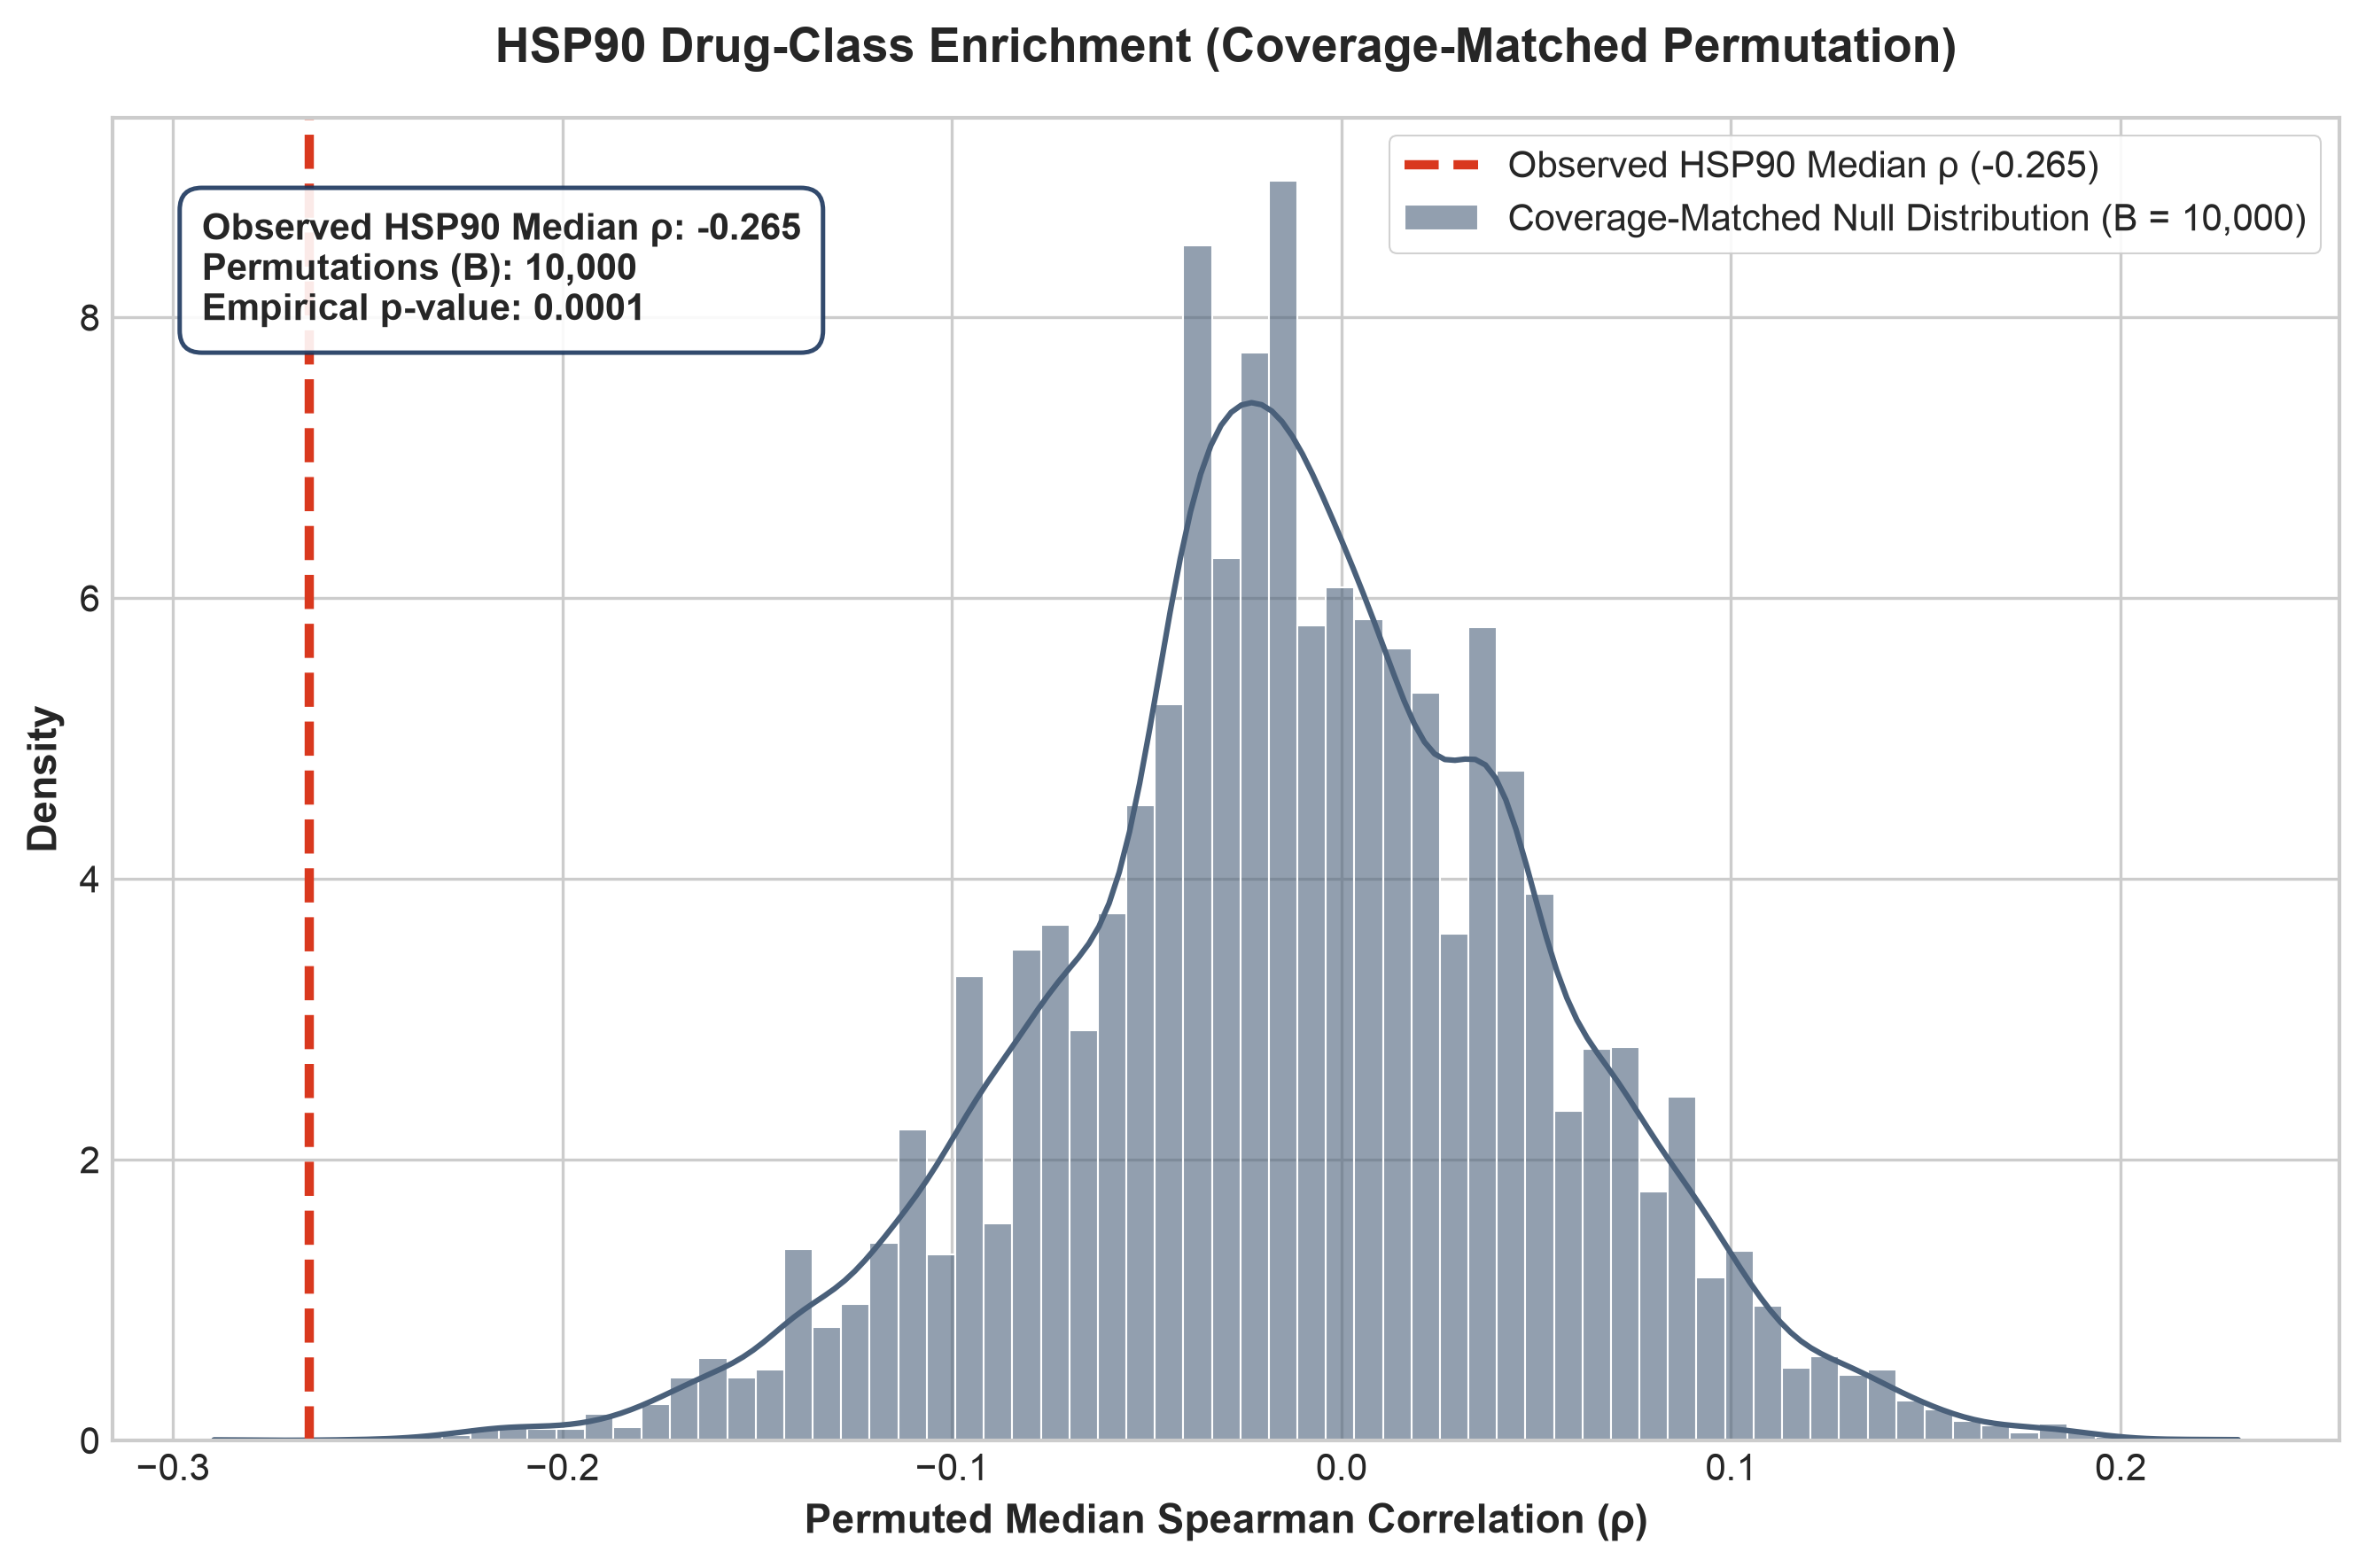

In [443]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

sns.histplot(
    permuted_medians_matched,
    bins="fd",
    color="#4A607A",
    kde=True,
    stat="density",
    alpha=0.6,
    edgecolor="white",
    label="Coverage-Matched Null Distribution (B = 10,000)",
    ax=ax
)

ax.axvline(
    x=observed_hsp90_median,
    color="#D9381E",
    linestyle="--",
    linewidth=2.5,
    label=f"Observed HSP90 Median ρ ({observed_hsp90_median:.3f})"
)

ax.set_title("HSP90 Drug-Class Enrichment (Coverage-Matched Permutation)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Permuted Median Spearman Correlation (ρ)", fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")

p_val_str = "0.0" if empirical_p_value_matched == 0.0 else f"{empirical_p_value_matched:.4f}"
textstr = (
    f"Observed HSP90 Median ρ: {observed_hsp90_median:.3f}\n"
    f"Permutations (B): 10,000\n"
    f"Empirical p-value: {p_val_str}"
)

props = dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#1B365D", alpha=0.9, linewidth=1.2)
ax.text(
    0.04, 0.93, textstr,
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    verticalalignment="top",
    bbox=props
)

ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9)
plt.tight_layout()
plt.savefig("../figures/hsp90_class_enrichment_permutation.png", dpi=300)
plt.show()

## 4. Independent results summary of HSP90-inhibitors

In [444]:
results = []

for _, row in prism_recurrence_drug_screen.iterrows():
    drug = row["DRUG"]
    brd_id = row["BRD_ID"]
    cohort_col = f"{drug} (BRD:{brd_id})"

    if drug in prism_hsp90_inhibitors["DRUG"].values and cohort_col in prism_cohort.columns:
        valid = recurrence_score.notna() & prism_cohort[cohort_col].notna()
        n_valid = valid.sum()

        if n_valid >= 3:
            rec_vals = recurrence_score.loc[valid].to_numpy()
            auc_vals = prism_cohort.loc[valid, cohort_col].to_numpy()

            if len(np.unique(rec_vals)) > 1 and len(np.unique(auc_vals)) > 1:
                rho, pval = spearmanr(rec_vals, auc_vals)
                if np.isfinite(rho):
                    results.append({
                        "DRUG": drug,
                        "BRD_ID": brd_id,
                        "SPEARMAN_RHO": rho,
                        "P_VALUE": pval,
                        "N": n_valid
                    })

df_hsp90 = pd.DataFrame(results)

_, qvals, _, _ = multipletests(df_hsp90["P_VALUE"], method="fdr_bh")
df_hsp90["FDR"] = qvals

df_hsp90 = df_hsp90.sort_values("SPEARMAN_RHO", ascending=True).reset_index(drop=True)

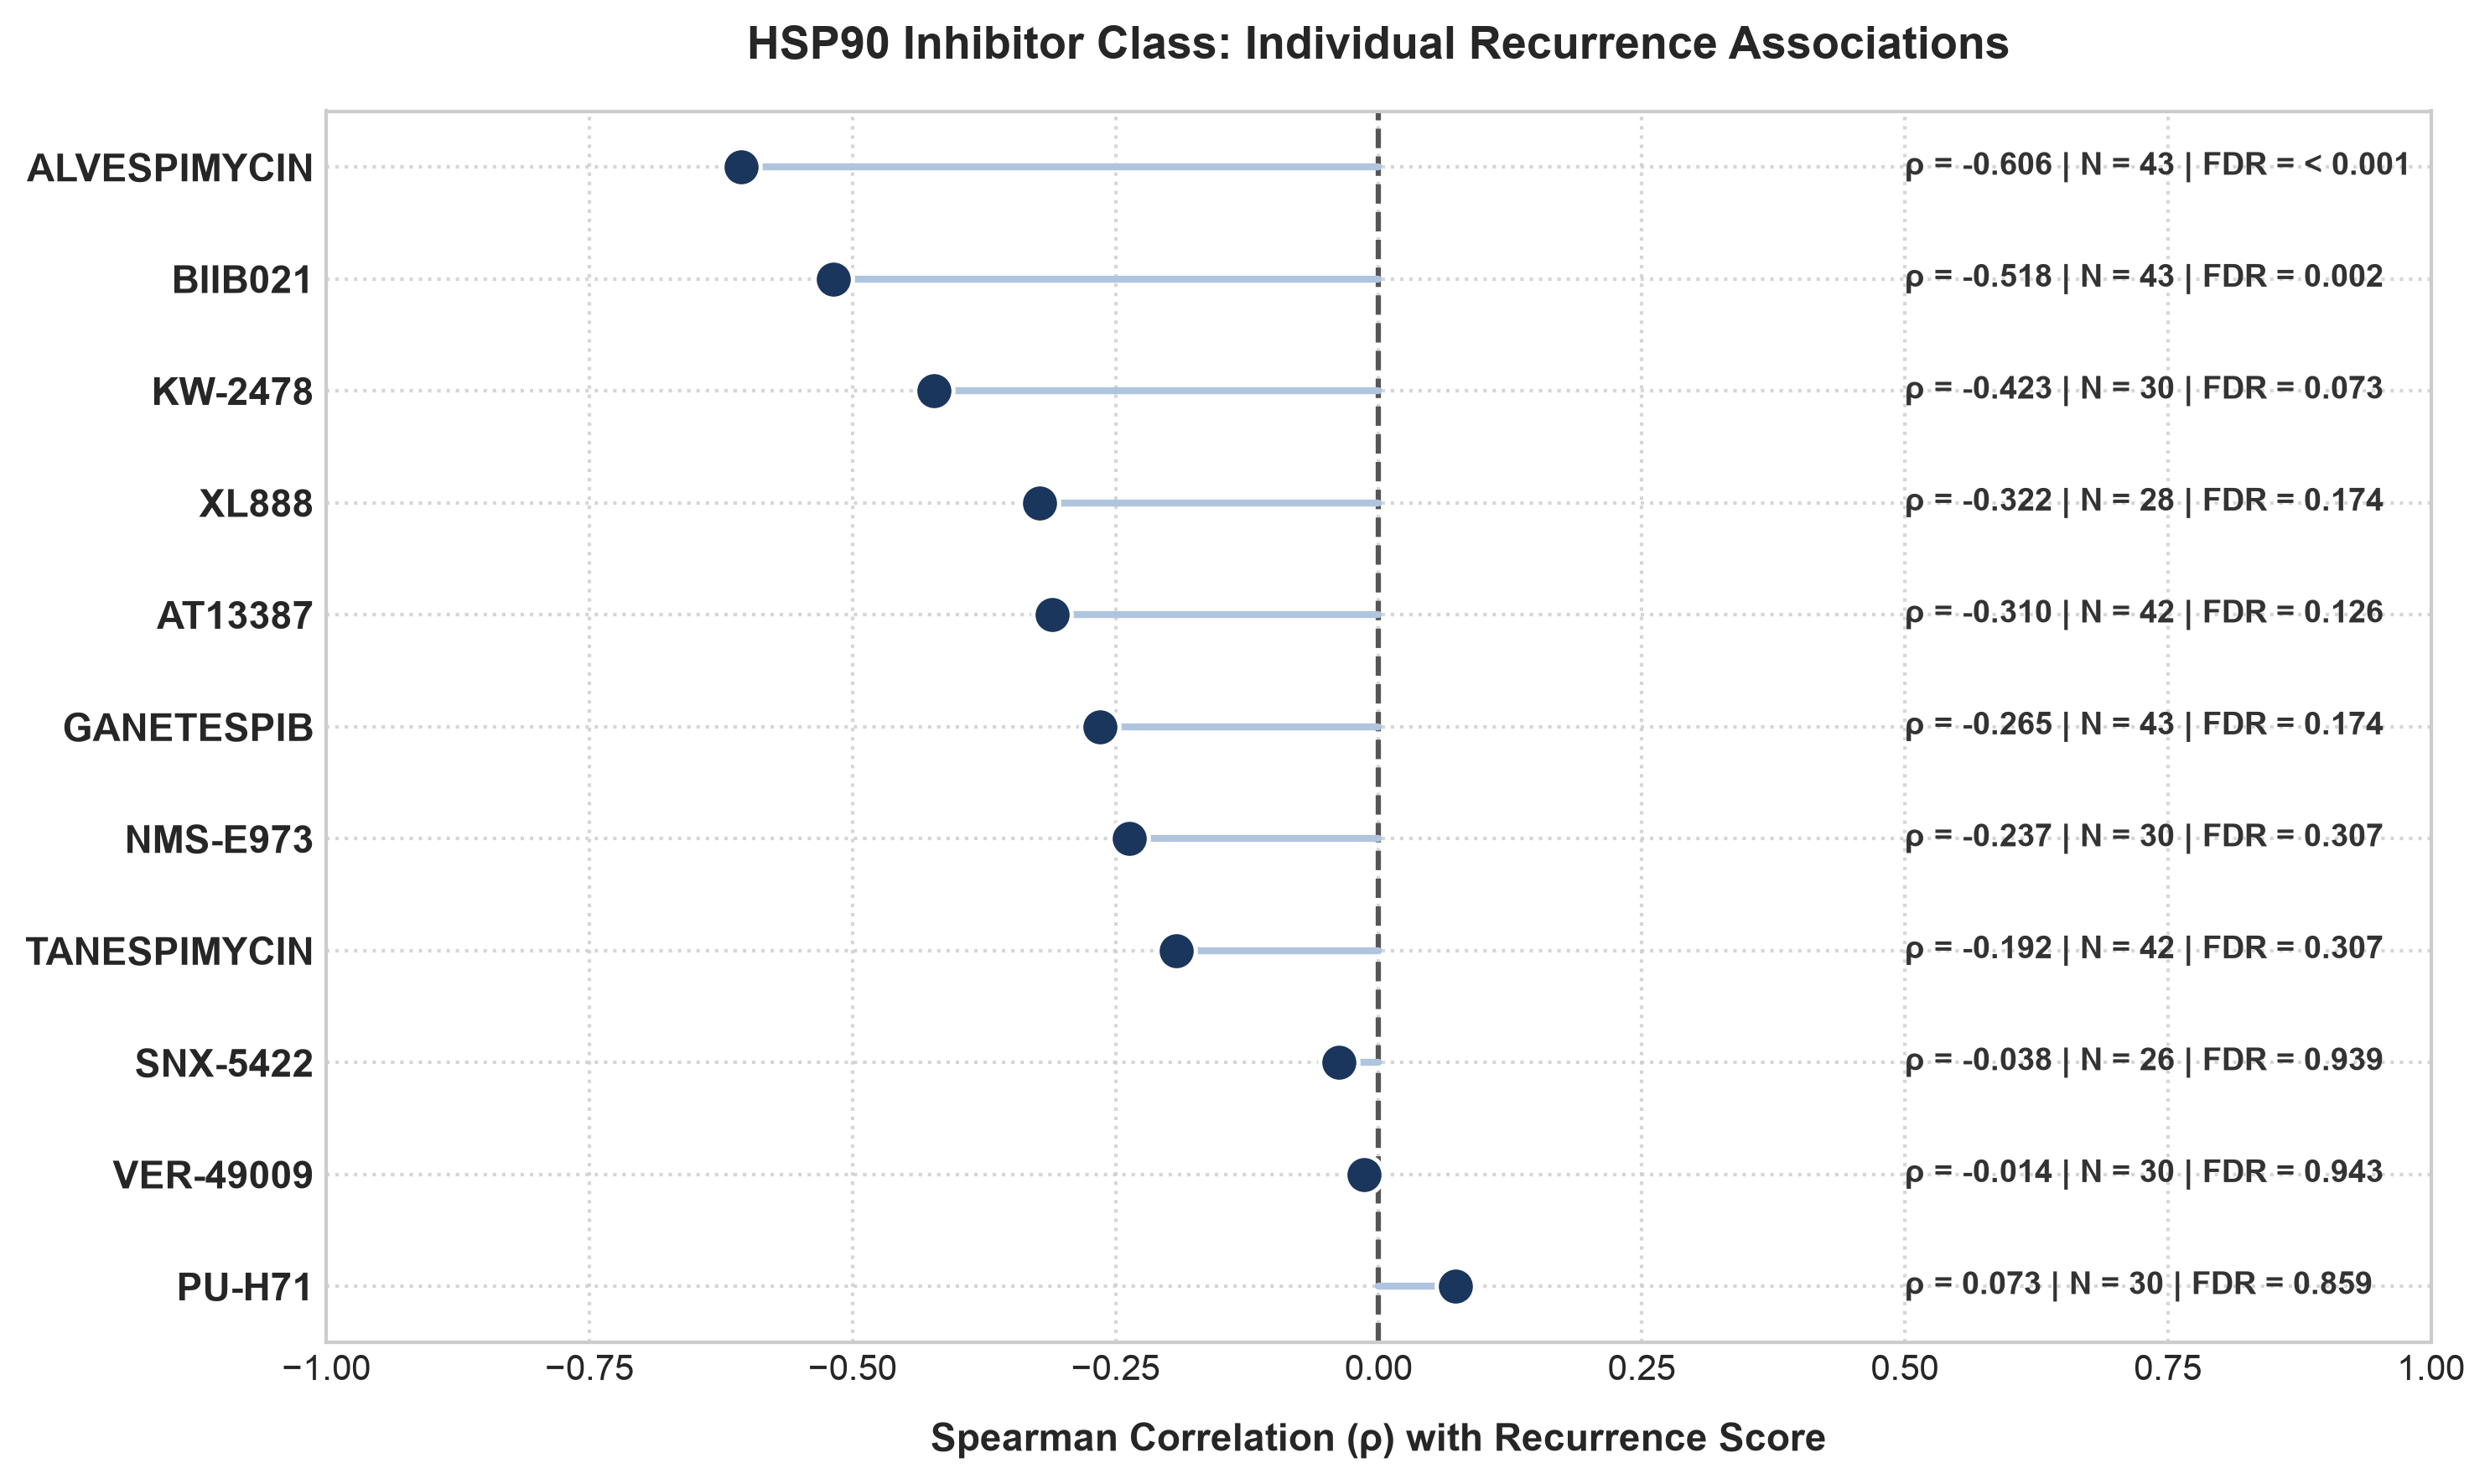

In [445]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

y_positions = np.arange(len(df_hsp90))

ax.axvline(x=0, color="#555555", linestyle="--", linewidth=1.5, zorder=1)

for i, row in df_hsp90.iterrows():
    ax.plot([0, row["SPEARMAN_RHO"]], [i, i], color="#B0C4DE", linewidth=2, zorder=2)

ax.scatter(
    df_hsp90["SPEARMAN_RHO"],
    y_positions,
    s=120,
    color="#1B365D",
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
    label="HSP90 Inhibitors"
)

ax.set_xlim(-1.0, 1.0)

for i, row in df_hsp90.iterrows():
    rho_val = row["SPEARMAN_RHO"]
    n_val = row["N"]
    fdr_val = row["FDR"]

    fdr_str = f"{float(fdr_val):.3f}" if fdr_val >= 0.001 else "< 0.001"
    annotation_text = f"ρ = {float(rho_val):.3f} | N = {n_val} | FDR = {fdr_str}"

    ax.text(
        0.5, i, annotation_text,
        va="center", ha="left", fontsize=9, fontweight="bold", color="#333333"
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(df_hsp90["DRUG"], fontsize=11, fontweight="bold")
ax.invert_yaxis()
ax.grid(True, which="major", linestyle=":", linewidth=1.0, color="#CCCCCC", alpha=0.8, zorder=0)
ax.set_xlabel("Spearman Correlation (ρ) with Recurrence Score", fontsize=11, fontweight="bold", labelpad=10)
ax.set_title("HSP90 Inhibitor Class: Individual Recurrence Associations", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("../figures/hsp90_inhibitor_recurrence_associations.png", dpi=300)
plt.show()

# **DepMap CRISPR - orthogonal genetic support**

## 1. Preparing CRISPR Gene Effect
- Reference: DepMap, Broad (2026). DepMap Public 26Q1. Dataset. depmap.org
- https://depmap.org/portal/data_page/?tab=allData&releasename=DepMap%20Public%2026Q1&filename=CRISPRGeneEffect.csv
- https://depmap.org/portal/data_page/?tab=allData&releasename=DepMap%20Public%2026Q1&filename=CRISPRInferredCommonEssentials.csv
- CRISPR Gene Effect source:
    - Source: "DepMap Portal"
    - URL: https://depmap.org/portal/
    - File date: 26Q1
    - File name: CRISPRGeneEffect.csv
    - Path: `/data/raw/DepMap/CRISPRGeneEffect.csv`
- CRISPR Inferred Common Essentials source:
    - Source: "DepMap Portal"
    - URL: https://depmap.org/portal/
    - File date: 26Q1
    - File name: CRISPRInferredCommonEssentials.csv
    - Path: `/data/raw/DepMap/CRISPRInferredCommonEssentials.csv`

In [446]:
depmap_crispr = pd.read_csv(
    "../data/raw/DepMap/CRISPRGeneEffect.csv",
    index_col=0
)

In [447]:
depmap_crispr.iloc[:5, :5]

,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550)
ACH-000029,0.000151,0.000541,-0.046740,0.040447,-0.188685
ACH-000030,0.169029,-0.182773,-0.023095,0.068845,-0.037532
ACH-000074,-0.087069,-0.054984,0.211763,0.421891,0.013034
ACH-000090,0.205441,-0.138211,-0.140932,-0.139838,-0.036163
ACH-000093,-0.133302,0.086477,-0.224933,0.024604,0.267048


In [448]:
depmap_glioma_recurrence_scores.head()

,ModelID,N_UP_GENES,N_DOWN_GENES,UP_SCORE,DOWN_SCORE,DEPMAP_RECURRENCE_SCORE
CELL_LINE_NAME,,,,,,
YKG1,ACH-000570,162,93,0.259558,0.464742,-0.205184
U-87 MG,ACH-000075,162,93,0.269172,0.434810,-0.165638
AM-38,ACH-000269,162,93,0.261562,0.455253,-0.193691
SF-295,ACH-000376,162,93,0.233810,0.469597,-0.235786
SF-172,ACH-000887,162,93,0.301533,0.430382,-0.128849


In [449]:
print(depmap_crispr.columns.tolist())
# 'HSP90AA1 (3320)'
# 'HSP90AB1 (3326)'
# 'XPO1 (7514)'

['A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)', 'A3GALT2 (127550)', 'A4GALT (53947)', 'A4GNT (51146)', 'AAAS (8086)', 'AACS (65985)', 'AADAC (13)', 'AADACL2 (344752)', 'AADACL3 (126767)', 'AADACL4 (343066)', 'AADAT (51166)', 'AAGAB (79719)', 'AAK1 (22848)', 'AAMDC (28971)', 'AAMP (14)', 'AANAT (15)', 'AAR2 (25980)', 'AARD (441376)', 'AARS1 (16)', 'AARS2 (57505)', 'AARSD1 (80755)', 'AASDH (132949)', 'AASDHPPT (60496)', 'AASS (10157)', 'AATF (26574)', 'AATK (9625)', 'ABAT (18)', 'ABCA1 (19)', 'ABCA10 (10349)', 'ABCA12 (26154)', 'ABCA13 (154664)', 'ABCA2 (20)', 'ABCA3 (21)', 'ABCA4 (24)', 'ABCA5 (23461)', 'ABCA6 (23460)', 'ABCA7 (10347)', 'ABCA8 (10351)', 'ABCA9 (10350)', 'ABCB1 (5243)', 'ABCB10 (23456)', 'ABCB11 (8647)', 'ABCB4 (5244)', 'ABCB5 (340273)', 'ABCB6 (10058)', 'ABCB7 (22)', 'ABCB8 (11194)', 'ABCB9 (23457)', 'ABCC1 (4363)', 'ABCC10 (89845)', 'ABCC11 (85320)', 'ABCC12 (94160)', 'ABCC2 (1244)', 'ABCC3 (8714)', 'ABCC4 (10257)', 'ABCC5 (10057)', 'ABCC6 (368)', 'ABCC8 (683

In [450]:
crispr_primary_targets = pd.DataFrame(depmap_crispr[['HSP90AA1 (3320)', 'HSP90AB1 (3326)', 'XPO1 (7514)']].copy())

recurrence_model_ids = (depmap_glioma_recurrence_scores["ModelID"].drop_duplicates().values)

crispr_primary_targets_recurrence_score = crispr_primary_targets.reindex(
    recurrence_model_ids
).copy()

In [451]:
score_series = depmap_glioma_recurrence_scores.set_index("ModelID")["DEPMAP_RECURRENCE_SCORE"]
score_series = score_series[~score_series.index.duplicated(keep="first")]

qc_data = []

for gene in crispr_primary_targets_recurrence_score.columns:
    paired_df = pd.DataFrame({
        "GENE_EFFECT": crispr_primary_targets_recurrence_score[gene],
        "RECURRENCE_SCORE": score_series,
    }).dropna()
    gene_vals = paired_df["GENE_EFFECT"]
    qc_data.append({
        "GENE": gene,
        "N": len(paired_df),
        "MEAN_GENE_EFFECT": gene_vals.mean(),
        "SD_GENE_EFFECT": gene_vals.std(),
        "MEDIAN_GENE_EFFECT": gene_vals.median(),
        "MIN": gene_vals.min(),
        "MAX": gene_vals.max(),
    })

crispr_primary_targets_QC = pd.DataFrame(qc_data)

common_essentials_df = pd.read_csv(
    "../data/raw/DepMap/CRISPRInferredCommonEssentials.csv"
)
common_essentials = set(common_essentials_df["Essentials"].astype(str).str.split(" ").str[0])
gene_symbols = (crispr_primary_targets_QC["GENE"].astype(str).str.split(" ").str[0])
crispr_primary_targets_QC["COMMON_ESSENTIAL_STATUS"] = gene_symbols.isin(common_essentials)

In [452]:
crispr_primary_targets_QC

,GENE,N,MEAN_GENE_EFFECT,SD_GENE_EFFECT,MEDIAN_GENE_EFFECT,MIN,MAX,COMMON_ESSENTIAL_STATUS
0,HSP90AA1 (3320),64,-0.194675,0.130775,-0.184037,-0.588749,0.120093,False
1,HSP90AB1 (3326),64,-0.215668,0.193684,-0.200586,-0.820494,0.090316,False
2,XPO1 (7514),64,-2.175066,0.379663,-2.158213,-3.029175,-1.212176,True


In [453]:
crispr_primary_targets_QC.to_excel(
    "../results/CRISPR/crispr_primary_targets_QC.xlsx",
    index=False
)

In [ ]:
print(
    depmap_glioma_recurrence_scores["ModelID"]
    .value_counts()
    .loc[lambda x: x > 1]
)

## 2. Relationship of Recurrence Score and genetic dependency

In [455]:
crispr_targets_clean = crispr_primary_targets_recurrence_score[~crispr_primary_targets_recurrence_score.index.duplicated(keep="first")]

combined_data = pd.concat(
    [
        score_series,
        crispr_targets_clean[
            ["HSP90AA1 (3320)", "HSP90AB1 (3326)", "XPO1 (7514)"]
        ],
    ],
    axis=1,
)

sample_sizes = []
rhos = []
p_vals = []

for gene in crispr_primary_targets_QC["GENE"]:
    if gene in combined_data.columns:
        pair = combined_data[["DEPMAP_RECURRENCE_SCORE", gene]].dropna()
        n_pair = len(pair)

        if n_pair >= 3:
            rho, p = spearmanr(pair["DEPMAP_RECURRENCE_SCORE"], pair[gene])
            sample_sizes.append(n_pair)
            rhos.append(rho)
            p_vals.append(p)
        else:
            sample_sizes.append(n_pair)
            rhos.append(np.nan)
            p_vals.append(np.nan)
    else:
        sample_sizes.append(0)
        rhos.append(np.nan)
        p_vals.append(np.nan)

recurrence_score_crispr_primary_targets = pd.DataFrame({
    "GENE": crispr_primary_targets_QC["GENE"],
    "N": sample_sizes,
    "SPEARMAN_RHO": rhos,
    "P_VALUE": p_vals,
})

valid_mask = recurrence_score_crispr_primary_targets["P_VALUE"].notna()
recurrence_score_crispr_primary_targets.loc[valid_mask, "FDR"] = multipletests(
    recurrence_score_crispr_primary_targets.loc[valid_mask, "P_VALUE"],
    method="fdr_bh",
)[1]

In [456]:
recurrence_score_crispr_primary_targets

,GENE,N,SPEARMAN_RHO,P_VALUE,FDR
0,HSP90AA1 (3320),64,0.050962,0.689218,0.689218
1,HSP90AB1 (3326),64,0.152747,0.228211,0.342317
2,XPO1 (7514),64,0.160989,0.203787,0.342317


In [457]:
recurrence_score_crispr_primary_targets.to_excel(
    "../results/CRISPR/recurrence_score_crispr_primary_targets.xlsx",
    index=False
)

## 3. Relevance of CRISP results

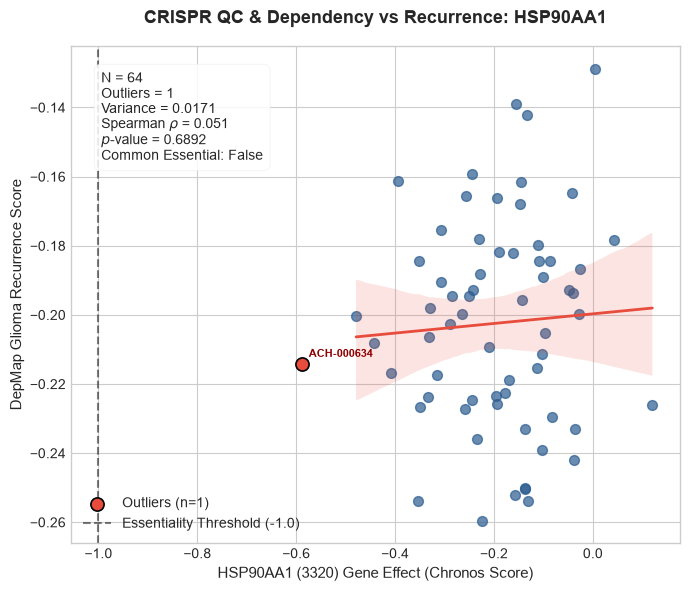

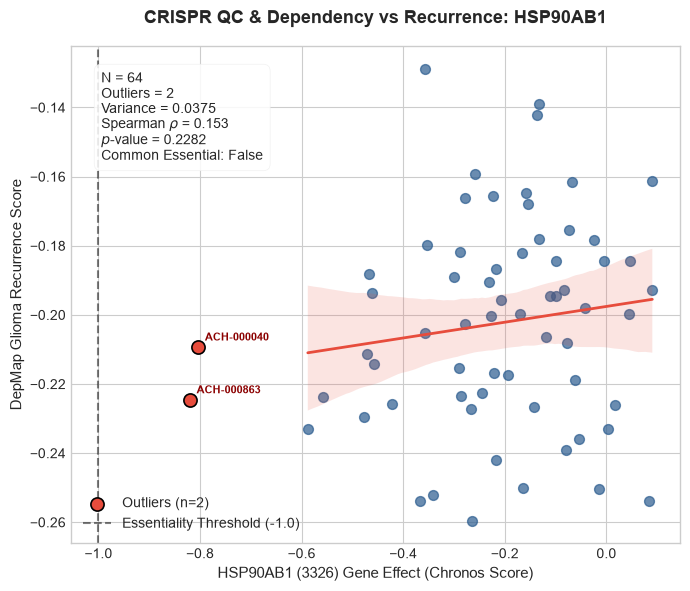

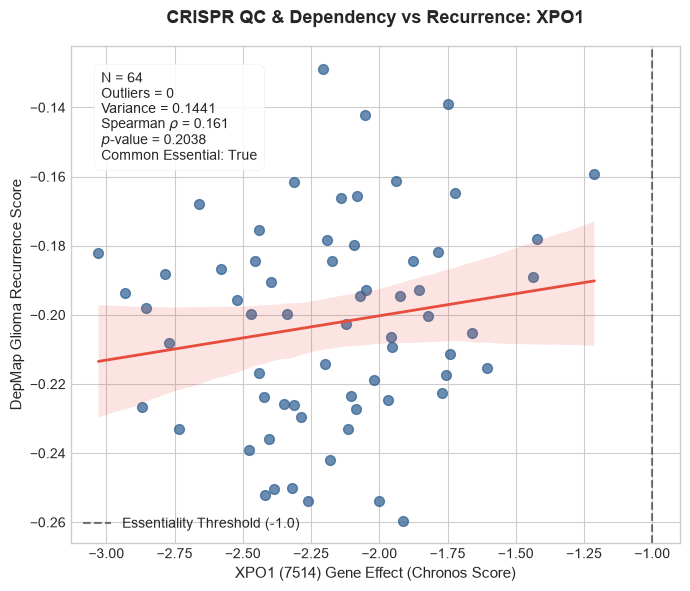

In [458]:
targets = {
    "HSP90AA1 (3320)": "../figures/crispr_HSP90AA1.png",
    "HSP90AB1 (3326)": "../figures/crispr_HSP90AB1.png",
    "XPO1 (7514)": "../figures/crispr_XPO1.png",
}

for gene, filename in targets.items():
    if gene not in combined_data.columns:
        print(f"Warning: {gene} not found in combined_data")
        continue

    gene_symbol = gene.split()[0]
    qc_row = crispr_primary_targets_QC[
        crispr_primary_targets_QC["GENE"].str.startswith(gene_symbol)
    ]

    if not qc_row.empty:
        is_common_essential = qc_row["COMMON_ESSENTIAL_STATUS"].values[0]
    else:
        is_common_essential = "Unknown"

    df_plot = combined_data[["DEPMAP_RECURRENCE_SCORE", gene]].dropna().copy()

    # --- Outlier Detection (Tukey's 1.5 * IQR Rule) ---
    for col in [gene, "DEPMAP_RECURRENCE_SCORE"]:
        q1 = df_plot[col].quantile(0.25)
        q3 = df_plot[col].quantile(0.75)
        iqr = q3 - q1
        df_plot[f"{col}_outlier"] = (df_plot[col] < (q1 - 1.5 * iqr)) | (
            df_plot[col] > (q3 + 1.5 * iqr)
        )

    df_plot["IS_OUTLIER"] = (
        df_plot[f"{gene}_outlier"] | df_plot["DEPMAP_RECURRENCE_SCORE_outlier"]
    )

    x = df_plot[gene]
    y = df_plot["DEPMAP_RECURRENCE_SCORE"]
    n_samples = len(df_plot)
    n_outliers = df_plot["IS_OUTLIER"].sum()

    gene_var = x.var()
    rho, p_val = spearmanr(x, y)

    plt.figure(figsize=(7, 6))

    ax = sns.regplot(
        data=df_plot[~df_plot["IS_OUTLIER"]],
        x=gene,
        y="DEPMAP_RECURRENCE_SCORE",
        color="#2b5c8f",
        scatter_kws={"alpha": 0.7, "s": 50, "label": "Inliers"},
        line_kws={"color": "#e74c3c", "linewidth": 2},
    )

    outliers_df = df_plot[df_plot["IS_OUTLIER"]]
    if not outliers_df.empty:
        plt.scatter(
            outliers_df[gene],
            outliers_df["DEPMAP_RECURRENCE_SCORE"],
            color="#e74c3c",
            s=90,
            edgecolor="black",
            linewidth=1.2,
            zorder=5,
            label=f"Outliers (n={n_outliers})",
        )

        for model_id, row in outliers_df.iterrows():
            plt.annotate(
                str(model_id),
                (row[gene], row["DEPMAP_RECURRENCE_SCORE"]),
                textcoords="offset points",
                xytext=(5, 5),
                ha="left",
                fontsize=8,
                color="#8b0000",
                fontweight="bold",
            )

    plt.axvline(
        x=-1.0,
        color="black",
        linestyle="--",
        alpha=0.5,
        label="Essentiality Threshold (-1.0)",
    )

    plt.title(
        f"CRISPR QC & Dependency vs Recurrence: {gene.split()[0]}",
        fontsize=13,
        fontweight="bold",
        y=1.03,
    )
    plt.xlabel(f"{gene} Gene Effect (Chronos Score)", fontsize=11)
    plt.ylabel("DepMap Glioma Recurrence Score", fontsize=11)
    plt.legend(loc="lower left")

    rho_val = float(rho)
    p_val_scalar = float(p_val)

    stats_text = (
        f"N = {n_samples}\n"
        f"Outliers = {n_outliers}\n"
        f"Variance = {gene_var:.4f}\n"
        f"Spearman $\\rho$ = {rho_val:.3f}\n"
        f"$p$-value = {p_val_scalar:.4f}\n"
        f"Common Essential: {is_common_essential}"
    )

    plt.gca().text(
        0.05,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="#ffe6e6" if is_common_essential is True else "white",
            alpha=0.85,
        ),
    )

    plt.tight_layout()

    plt.savefig(filename, dpi=300)
    plt.show()

In [459]:
proliferation_score_clean = proliferation_score.groupby(level=0).mean()
score_series = depmap_glioma_recurrence_scores.set_index("ModelID")["DEPMAP_RECURRENCE_SCORE"]
score_series = score_series[~score_series.index.duplicated(keep="first")]

In [460]:
crispr_multivariate_results = []

for gene in crispr_primary_targets_recurrence_score.columns:
    reg_df = pd.DataFrame({
        "GENE_EFFECT": crispr_primary_targets_recurrence_score[gene],
        "RECURRENCE_SCORE": score_series,
        "PROLIFERATION_SCORE": proliferation_score_clean,
    }).dropna()

    if len(reg_df) < 10:
        continue

    X = reg_df[["RECURRENCE_SCORE", "PROLIFERATION_SCORE"]]
    X = sm.add_constant(X)
    y = reg_df["GENE_EFFECT"]

    model = sm.OLS(y, X).fit()

    crispr_multivariate_results.append({
        "GENE": gene,
        "N": len(reg_df),
        "BETA_RECURRENCE_SCORE": model.params["RECURRENCE_SCORE"],
        "P_RECURRENCE_SCORE": model.pvalues["RECURRENCE_SCORE"],
        "BETA_PROLIFERATION": model.params["PROLIFERATION_SCORE"],
        "P_PROLIFERATION": model.pvalues["PROLIFERATION_SCORE"],
        "ADJUSTED_R2": model.rsquared_adj,
    })

crispr_primary_targets_adjusted_proliferation = pd.DataFrame(crispr_multivariate_results)

crispr_primary_targets_adjusted_proliferation = crispr_primary_targets_adjusted_proliferation.sort_values(
    by="P_RECURRENCE_SCORE"
).reset_index(drop=True)

crispr_primary_targets_adjusted_proliferation

,GENE,N,BETA_RECURRENCE_SCORE,P_RECURRENCE_SCORE,BETA_PROLIFERATION,P_PROLIFERATION,ADJUSTED_R2
0,XPO1 (7514),64,2.352565,0.166874,0.049195,0.577354,-0.000430
1,HSP90AB1 (3326),64,0.875435,0.313119,-0.016398,0.716475,-0.007084
2,HSP90AA1 (3320),64,0.452109,0.441945,0.023726,0.439671,-0.017520


In [461]:
crispr_primary_targets_adjusted_proliferation.to_excel(
    "../results/CRISPR/crispr_multivariate_results.xlsx",
    index=False
)

> **Summary Note:**  In Adult-Type Diffuse Glioma cell models ($N = 64$), the recurrence score signature does not correlate with increased genetic vulnerability to single CRISPR depletion of HSP90AA1, HSP90AB1, or XPO1. Target dependency for these three genes operates independently of the recurrence score. While individual knockouts fail to impair survival—likely due to paralog compensation between HSP90AA1 and HSP90AB1—further dual-knockout studies are necessary to evaluate whether simultaneous inactivation of both isoforms yields synthetic lethality. Nevertheless, these findings provide a biological rationale for why dual-isoform targeted therapies like alvespimycin may exert baseline antitumor activity across diffuse gliomas regardless of recurrence risk score.